In [1]:
old_wd <- getwd()

setwd("../../")

if (file.exists("renv/activate.R")) {
  source("renv/activate.R")
} else {
  stop("Could not find renv/activate.R in project root")
}

setwd(old_wd)

- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
library(fda)

Loading required package: splines

Loading required package: fds

Loading required package: rainbow

Loading required package: MASS

Loading required package: pcaPP

Loading required package: RCurl

Loading required package: deSolve


Attaching package: ‘fda’


The following object is masked from ‘package:graphics’:

    matplot


The following object is masked from ‘package:datasets’:

    gait




In [3]:
ageRng = c(1 ,18)
age = growth$age
agefine = seq(1,18,len =501)

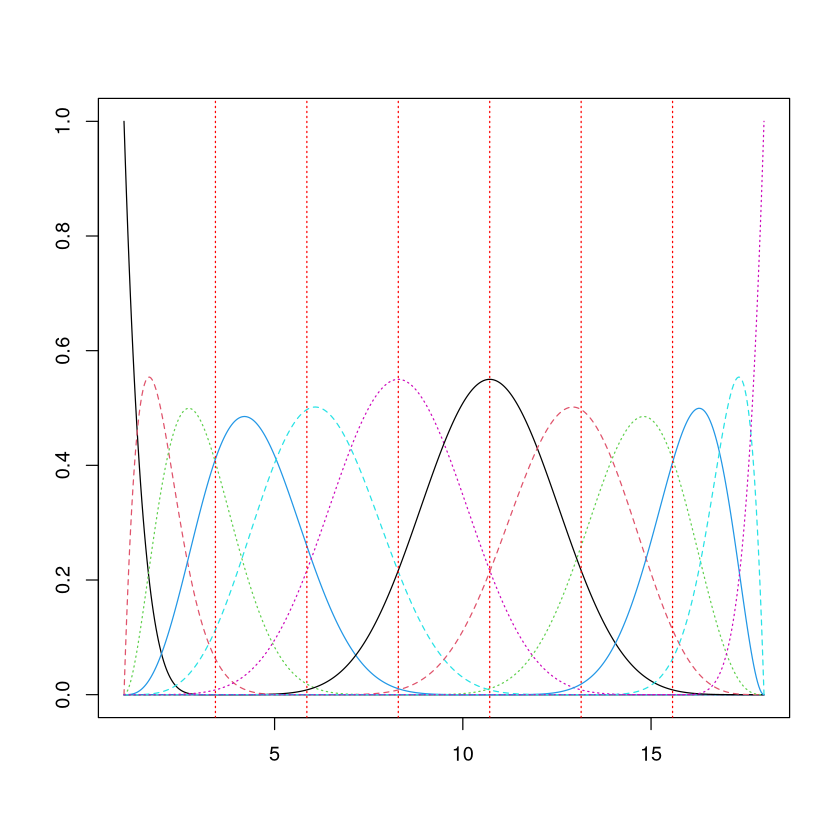

In [4]:
# set up order 6 spline basis with 12 basis functions for
# fitting the growth data so as to estimate acceleration

nbasis = 12
norder = 6
heightbasis12 = create.bspline.basis(ageRng , nbasis , norder)
plot(heightbasis12)

[1] "done"

List of 3
 $ coefs  : num [1:12, 1:54] 76.3 84.9 90.6 104.4 117.5 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:12] "bspl6.1" "bspl6.2" "bspl6.3" "bspl6.4" ...
  .. ..$ : chr [1:54] "Y1" "Y2" "Y3" "Y4" ...
 $ basis  :List of 10
  ..$ call       : language basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params,      dropind = dropind, quadvals = qu| __truncated__
  ..$ type       : chr "bspline"
  ..$ rangeval   : num [1:2] 1 18
  ..$ nbasis     : num 12
  ..$ params     : num [1:6] 3.43 5.86 8.29 10.71 13.14 ...
  ..$ dropind    : NULL
  ..$ quadvals   : NULL
  ..$ values     : list()
  ..$ basisvalues: list()
  ..$ names      : chr [1:12] "bspl6.1" "bspl6.2" "bspl6.3" "bspl6.4" ...
  ..- attr(*, "class")= chr "basisfd"
 $ fdnames:List of 3
  ..$ : chr "Age (years)"
  ..$ : chr "Child"
  ..$ : chr "Height (cm)"
 - attr(*, "class")= chr "fd"


[1] "coefs"   "basis"   "fdnames"

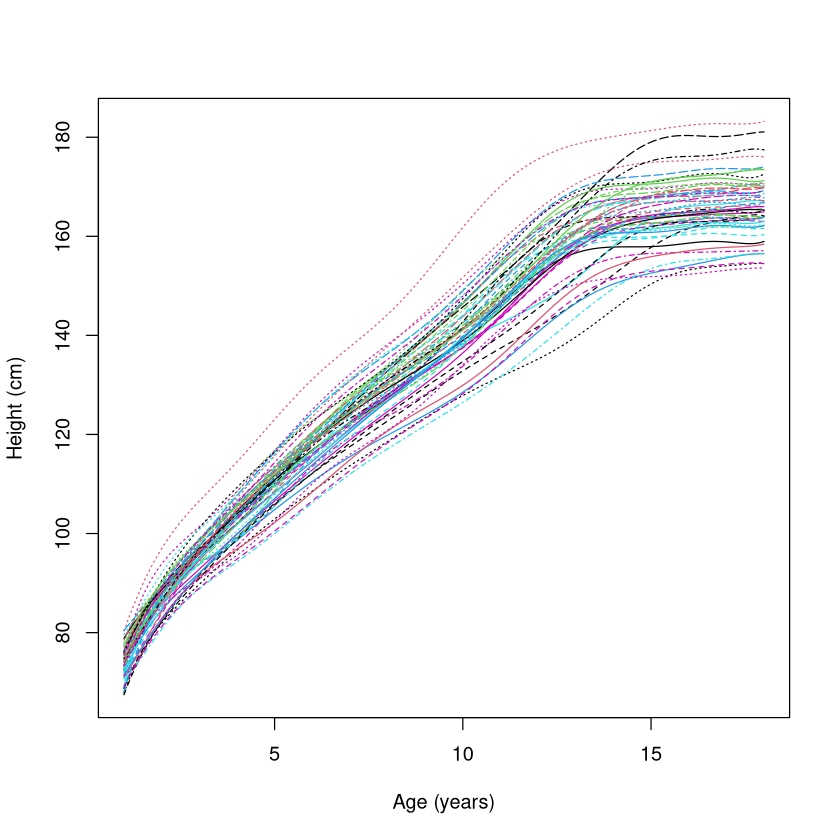

In [5]:
# fit the data by least squares

basismat = eval.basis(age , heightbasis12)
heightmat = growth$hgtf
heightcoef = lsfit(basismat , heightmat , intercept=FALSE)$coef

fdnames = vector('list', 3)
fdnames [[1]] = "Age (years)"
fdnames [[2]] = "Child"
fdnames [[3]] = "Height (cm)"
hgtfd <- fd(heightcoef , heightbasis12 , fdnames)
plot(hgtfd)
str(hgtfd)
names(hgtfd)

[1] "done"

List of 3
 $ coefs  : num [1:12, 1:54] 76.3 84.9 90.6 104.4 117.5 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:12] "bspl6.1" "bspl6.2" "bspl6.3" "bspl6.4" ...
  .. ..$ : chr [1:54] "girl01" "girl02" "girl03" "girl04" ...
 $ basis  :List of 10
  ..$ call       : language basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params,      dropind = dropind, quadvals = qu| __truncated__
  ..$ type       : chr "bspline"
  ..$ rangeval   : num [1:2] 1 18
  ..$ nbasis     : num 12
  ..$ params     : num [1:6] 3.43 5.86 8.29 10.71 13.14 ...
  ..$ dropind    : NULL
  ..$ quadvals   : NULL
  ..$ values     : list()
  ..$ basisvalues: list()
  ..$ names      : chr [1:12] "bspl6.1" "bspl6.2" "bspl6.3" "bspl6.4" ...
  ..- attr(*, "class")= chr "basisfd"
 $ fdnames:List of 3
  ..$ time  : chr [1:31] "1" "1.25" "1.5" "1.75" ...
  ..$ reps  : chr [1:54] "girl01" "girl02" "girl03" "girl04" ...
  ..$ values: chr "value"
 - attr(*, "class")= chr "fd"


[1] "coefs"   "basis"   "fdnames"

[1] 12

girl01     girl02     girl03     girl04     girl05     girl06     girl07 
0.25139227 0.79772370 0.33406519 0.30859806 0.34792720 0.19028424 0.12269091 
    girl08     girl09     girl10     girl11     girl12     girl13     girl14 
0.16314519 0.14385871 0.17643542 0.10246056 0.15199634 0.30488198 0.25164581 
    girl15     girl16     girl17     girl18     girl19     girl20     girl21 
0.91198313 0.31589444 0.30063924 0.14161089 0.87375308 0.42458149 0.12088834 
    girl22     girl23     girl24     girl25     girl26     girl27     girl28 
0.31501437 0.15735215 0.52751929 0.25967957 0.13461259 0.34627636 0.25820483 
    girl29     girl30     girl31     girl32     girl33     girl34     girl35 
0.28671285 0.47704941 0.11291067 0.35975577 0.42642733 0.28716270 0.18148292 
    girl36     girl37     girl38     girl39     girl40     girl41     girl42 
0.15962081 0.23716981 0.07944537 0.19523555 0.40284324 0.21290321 0.11246347 
    girl43     girl44     girl45     girl46     girl47     girl48     girl49 
0.37640326 0.23315923 0.14539742 0.26401554 0.52565308 0.14816316 0.13389062 
    girl50     girl51     girl52     girl53     girl54 
0.31421014 0.32956270 0.79632586 0.68010789 0.21781745

,girl01,girl02,girl03,girl04,girl05,girl06,girl07,girl08,girl09,girl10,⋯,girl45,girl46,girl47,girl48,girl49,girl50,girl51,girl52,girl53,girl54
bspl6.1,1.278977e-13,1.136868e-13,2.842171e-14,8.526513e-14,5.684342e-14,9.947598e-14,7.105427e-14,4.263256e-14,2.842171e-14,1.421085e-14,⋯,9.947598e-14,4.263256e-14,7.105427e-14,2.842171e-14,1.136868e-13,5.684342e-14,4.263256e-14,8.526513e-14,1.421085e-14,2.842171e-14
bspl6.2,0.000000e+00,-1.421085e-14,2.131628e-13,7.105427e-14,7.105427e-14,2.842171e-14,1.563194e-13,9.947598e-14,1.421085e-13,8.526513e-14,⋯,2.842171e-14,1.278977e-13,1.136868e-13,1.563194e-13,4.263256e-14,4.263256e-14,1.136868e-13,-4.263256e-14,-4.263256e-14,-1.421085e-14
bspl6.3,-3.268497e-13,-3.268497e-13,-8.526513e-13,-4.547474e-13,-7.815970e-13,-6.252776e-13,-7.673862e-13,-6.679102e-13,-7.531753e-13,-5.684342e-13,⋯,-4.547474e-13,-7.247536e-13,-6.110668e-13,-6.679102e-13,-3.552714e-13,-6.110668e-13,-6.963319e-13,-2.415845e-13,-4.405365e-13,-3.552714e-13
bspl6.4,2.330580e-12,2.430056e-12,3.041123e-12,2.614797e-12,3.026912e-12,2.827960e-12,2.913225e-12,3.083755e-12,2.955858e-12,2.813749e-12,⋯,2.472689e-12,2.700062e-12,2.657430e-12,2.629008e-12,2.472689e-12,2.657430e-12,2.771117e-12,2.216893e-12,2.600586e-12,2.373213e-12
bspl6.5,-3.780087e-12,-3.993250e-12,-4.249046e-12,-4.106937e-12,-4.305889e-12,-4.121148e-12,-4.249046e-12,-4.831691e-12,-4.405365e-12,-4.263256e-12,⋯,-3.907985e-12,-4.106937e-12,-3.964828e-12,-3.907985e-12,-4.035883e-12,-4.106937e-12,-4.263256e-12,-3.581135e-12,-4.149570e-12,-3.979039e-12
bspl6.6,2.600586e-12,2.728484e-12,2.842171e-12,3.069545e-12,2.870593e-12,2.899014e-12,3.012701e-12,3.439027e-12,3.069545e-12,2.785328e-12,⋯,2.742695e-12,2.870593e-12,2.671641e-12,2.742695e-12,2.785328e-12,2.984279e-12,2.984279e-12,2.472689e-12,2.955858e-12,2.842171e-12
bspl6.7,-2.984279e-12,-3.268497e-12,-3.041123e-12,-3.296918e-12,-3.069545e-12,-3.126388e-12,-3.097966e-12,-3.524292e-12,-3.353762e-12,-3.154810e-12,⋯,-3.097966e-12,-3.154810e-12,-2.955858e-12,-2.955858e-12,-3.126388e-12,-3.211653e-12,-3.097966e-12,-2.756906e-12,-3.296918e-12,-3.296918e-12
bspl6.8,3.211653e-12,3.325340e-12,3.211653e-12,3.410605e-12,3.240075e-12,3.268497e-12,3.211653e-12,3.780087e-12,3.581135e-12,3.524292e-12,⋯,3.240075e-12,3.240075e-12,3.382183e-12,3.126388e-12,3.410605e-12,3.524292e-12,3.325340e-12,3.097966e-12,3.751666e-12,3.552714e-12
bspl6.9,-3.154810e-12,-3.041123e-12,-3.211653e-12,-3.325340e-12,-3.240075e-12,-3.041123e-12,-3.097966e-12,-3.751666e-12,-3.240075e-12,-3.268497e-12,⋯,-3.325340e-12,-3.211653e-12,-3.240075e-12,-3.041123e-12,-3.353762e-12,-3.353762e-12,-3.126388e-12,-3.012701e-12,-3.467449e-12,-3.268497e-12
bspl6.10,5.968559e-13,5.968559e-13,6.536993e-13,6.252776e-13,6.252776e-13,5.684342e-13,5.684342e-13,7.958079e-13,7.105427e-13,6.536993e-13,⋯,5.968559e-13,6.252776e-13,6.821210e-13,5.400125e-13,6.536993e-13,6.536993e-13,4.547474e-13,4.263256e-13,7.958079e-13,5.684342e-13


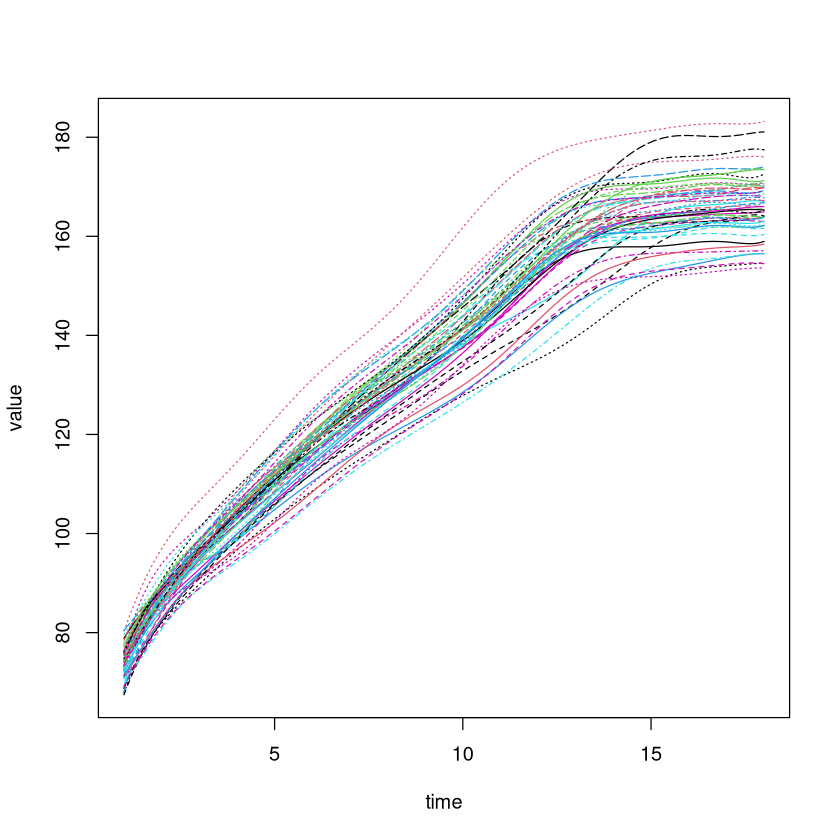

In [6]:
# fit the data using the function smooth_basis , which does the same thing.

heightList = smooth.basis(age , heightmat , heightbasis12)
heightfd = heightList$fd
plot(heightfd)
str(heightfd)
names(heightfd)

height.df = heightList$df
height.df
height.gcv = heightList$gcv
height.gcv

heightbasismat = eval.basis(age , heightbasis12)
y2cMap = solve(crossprod(heightbasismat)) %*% t(heightbasismat)

coefest <- y2cMap %*% heightmat
dcoef <- coefest - heightcoef
dcoef

In [7]:
# Hat matrix H
# Phi (Phi^T Phi)^{-1} Phi^T
# with penalty: Phi (Phi^T Phi + lambda R)^{-1} Phi^T
hatH = heightbasismat %*%
solve(crossprod(heightbasismat)) %*% t(heightbasismat)

In [8]:
# Differential operators

# The first thing we need to do is to define a linear differential operator
# (Lfd) object. This is a list of functional data objects defining the terms
# on the right hand side of
#
# D^m x + b_{m-1}(t) D^{m-1} x + ... + b_0(t) x

?Lfd

# The simplest Lfds just penalize the derivative x, and we can define
# them by

D2lfd = int2Lfd (2)
D2lfd

# This says that b_0 = b_1 = 0, which we can see by looking internally at
# D2lfd we see


$call
Lfd(nderiv = m, bwtlist = bwtlist)

$nderiv
[1] 2

$bwtlist
$bwtlist[[1]]
$coefs
     reps 1
time      0

$basis
$call
basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params, 
    dropind = dropind, quadvals = quadvals, values = values, 
    basisvalues = basisvalues)

$type
[1] "const"

$rangeval
[1] 0 1

$nbasis
[1] 1

$params
[1] 0

$dropind
numeric(0)

$quadvals
numeric(0)

$values
list()

$basisvalues
list()

$names
[1] "const"

attr(,"class")
[1] "basisfd"

$fdnames
$fdnames$args
[1] "time"

$fdnames$reps
[1] "reps 1"

$fdnames$funs
[1] "values"


attr(,"class")
[1] "fd"

$bwtlist[[2]]
$coefs
     reps 1
time      0

$basis
$call
basisfd(type = type, rangeval = rangeval, nbasis = nbasis, params = params, 
    dropind = dropind, quadvals = quadvals, values = values, 
    basisvalues = basisvalues)

$type
[1] "const"

$rangeval
[1] 0 1

$nbasis
[1] 1

$params
[1] 0

$dropind
numeric(0)

$quadvals
numeric(0)

$values
list()

$basisvalues
list()

$names
[1] 

Lfd                    package:fda                     R Documentation

_D_e_f_i_n_e _a _L_i_n_e_a_r _D_i_f_f_e_r_e_n_t_i_a_l _O_p_e_r_a_t_o_r _O_b_j_e_c_t

_D_e_s_c_r_i_p_t_i_o_n:

     A linear differential operator of order $m$ is defined, usually to
     specify a roughness penalty.

_U_s_a_g_e:

     Lfd(nderiv=0, bwtlist=vector("list", 0))
     
_A_r_g_u_m_e_n_t_s:

  nderiv: a nonnegative integer specifying the order $m$ of the highest
          order derivative in the operator

 bwtlist: a list of length $m$.  Each member contains a functional data
          object that acts as a weight function for a derivative.  The
          first member weights the function, the second the first
          derivative, and so on up to order $m-1$.

_D_e_t_a_i_l_s:

     To check that an object is of this class, use functions ‘is.Lfd’
     or ‘int2Lfd’.

     Linear differential operator objects are often used to define
   

[1] "call"    "nderiv"  "bwtlist"

[1] "done"

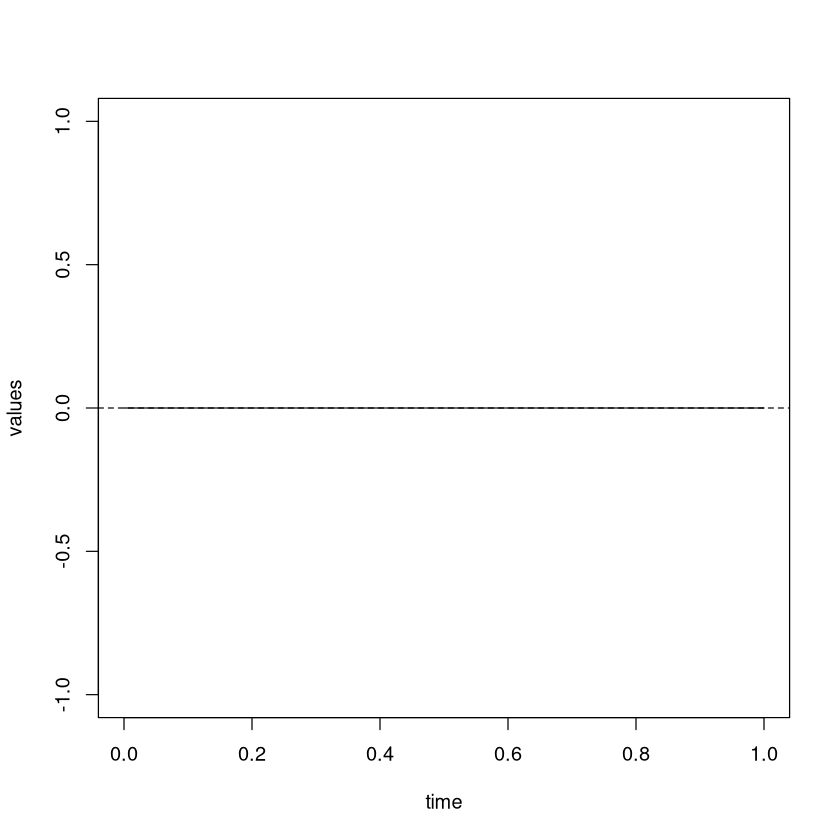

In [9]:
names(D2lfd)

plot(D2lfd$bwtlist[[2]])

[1] "done"

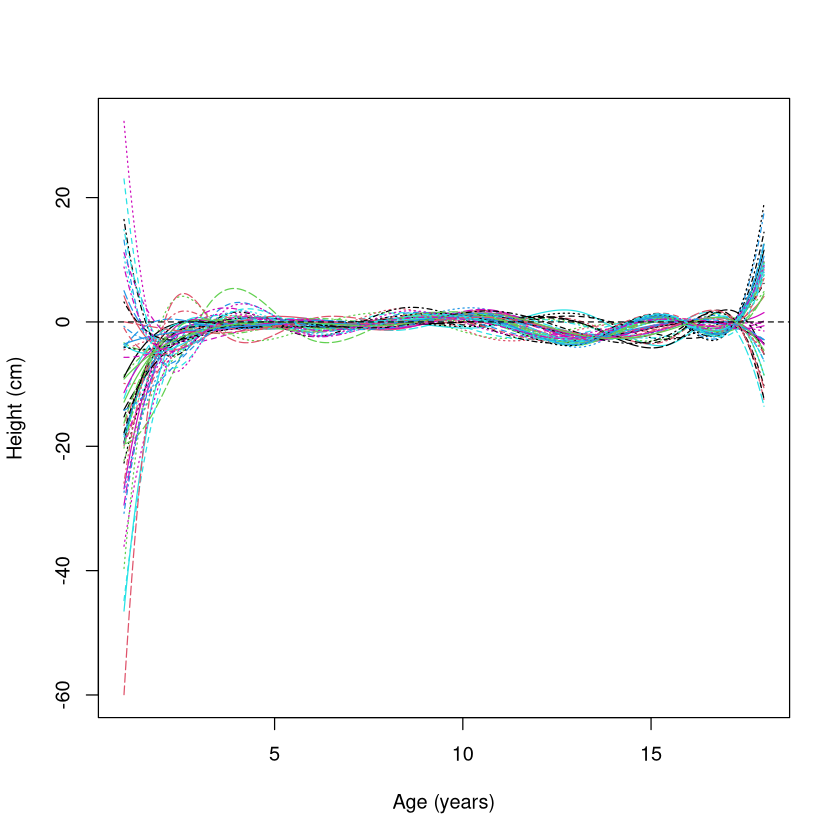

[1] "done"

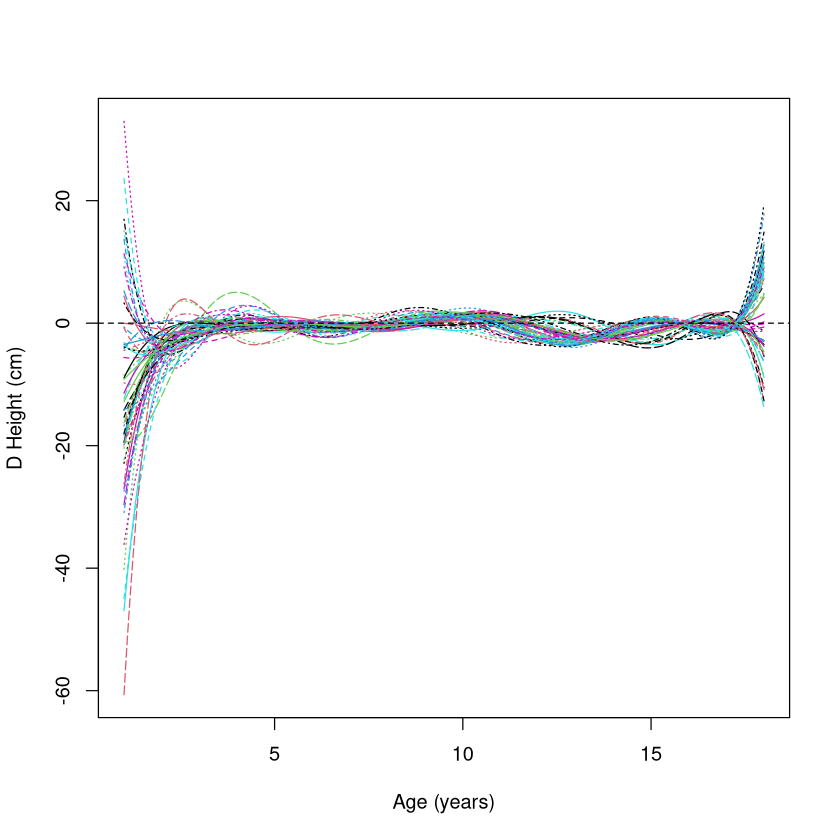

In [10]:
# Instead of evaluating a derivative, we can always evaluate an Lfd
# applied to a function

plot(hgtfd, Lfdobj=D2lfd)
plot(deriv.fd(hgtfd, 2))

In [11]:
# Now we need to do some smoothing.
# In order to set up the smoothing operator, we need to define an
# fdPar (functional parameter) object. This is just a list of various
# quantities that avoids the need for many argument values

D2fdPar = fdPar(heightbasis12, Lfdobj=int2Lfd(2), lambda=1e4)

Multiple plots:  Click in the plot to advance to the next plot


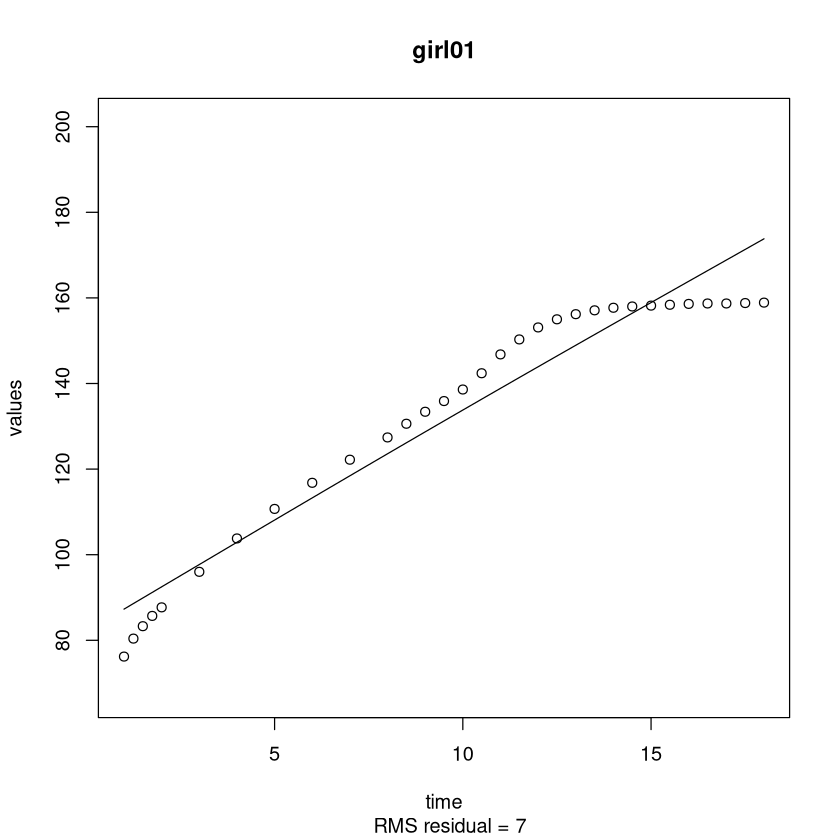

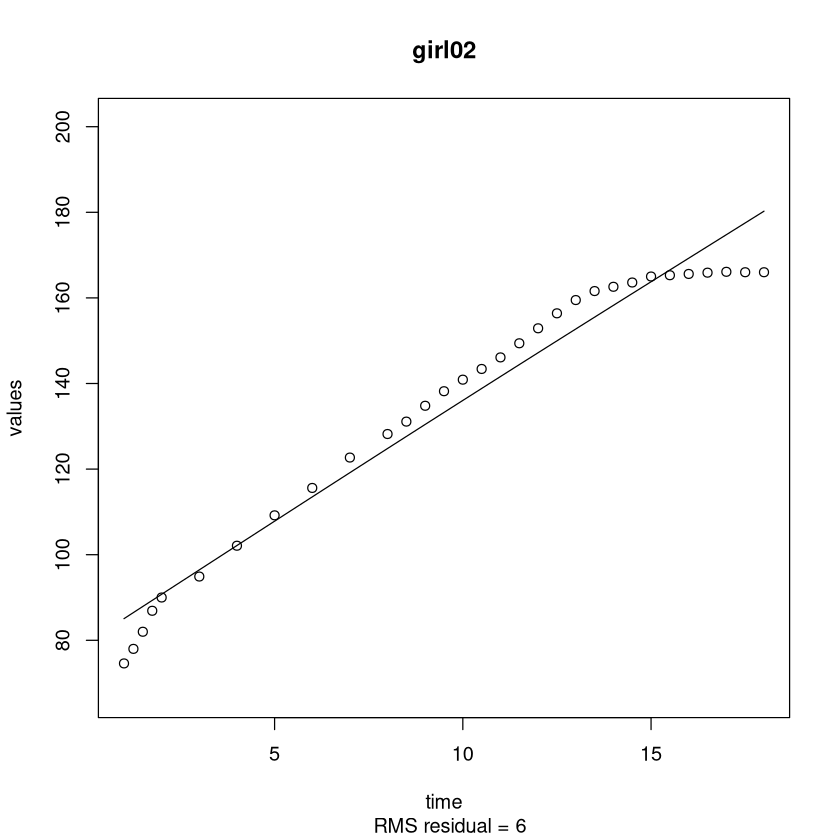

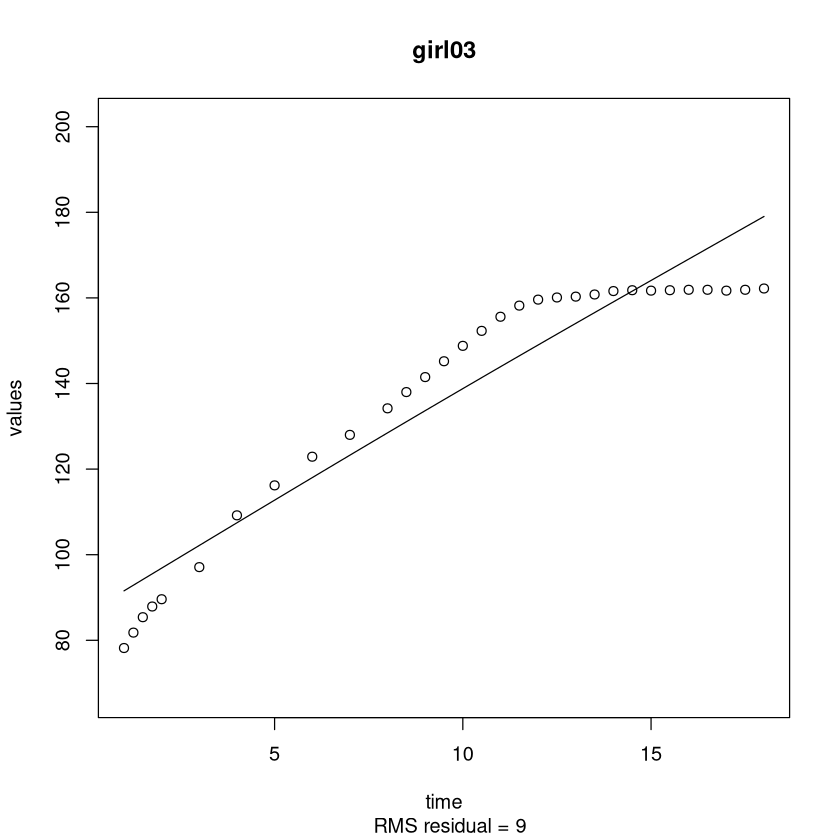

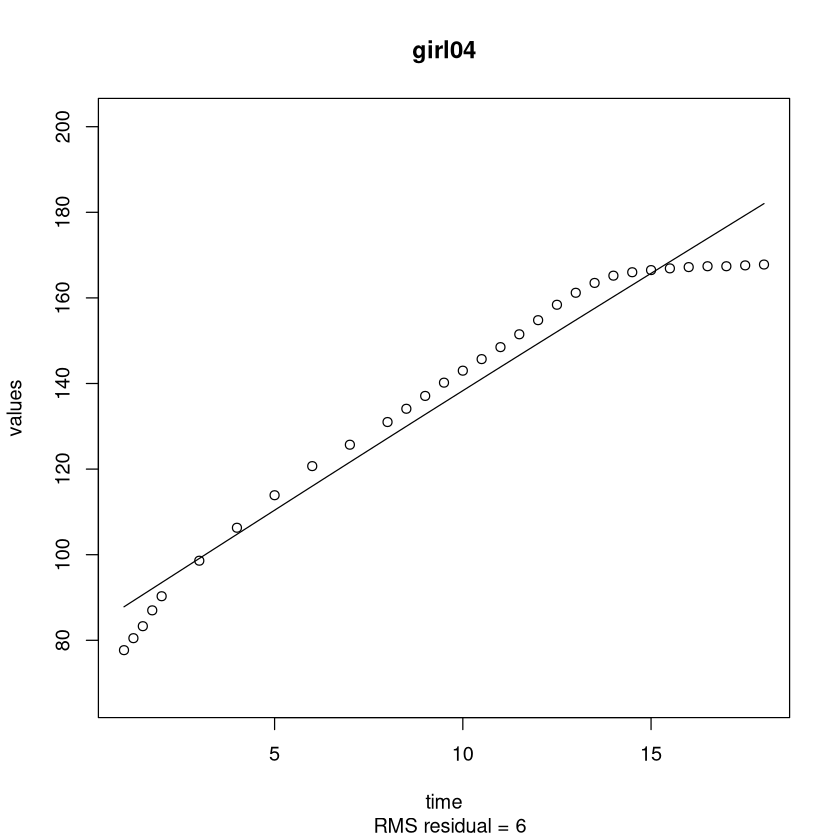

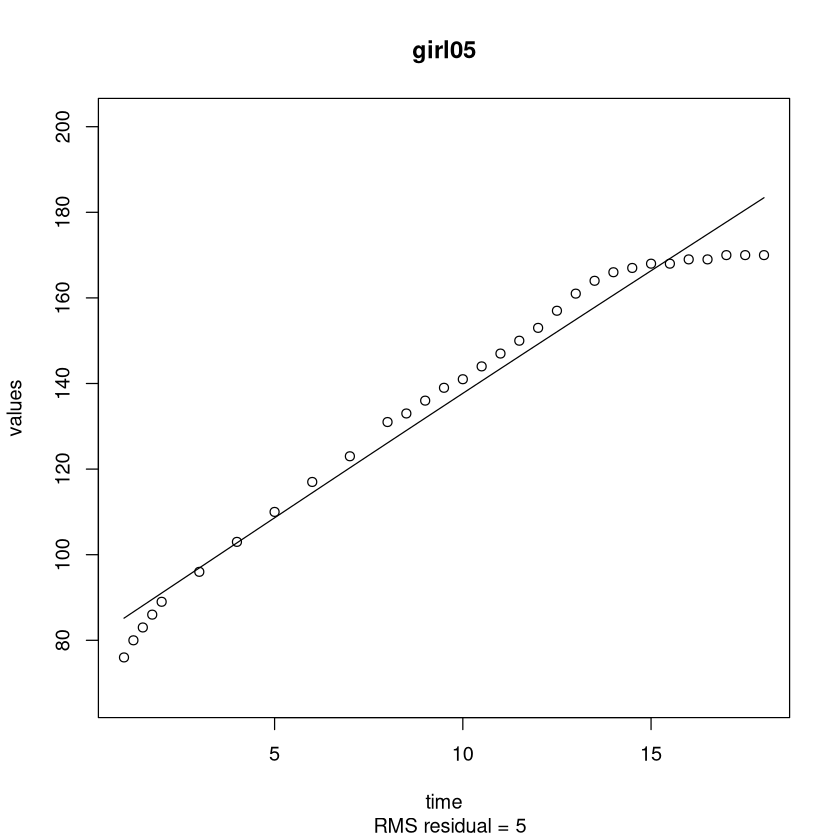

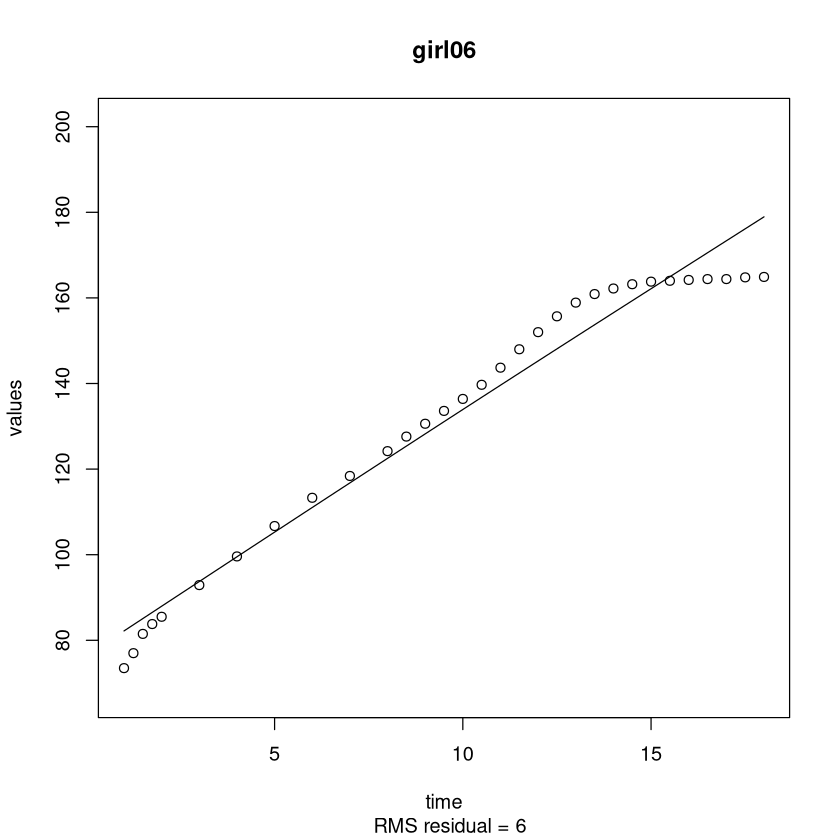

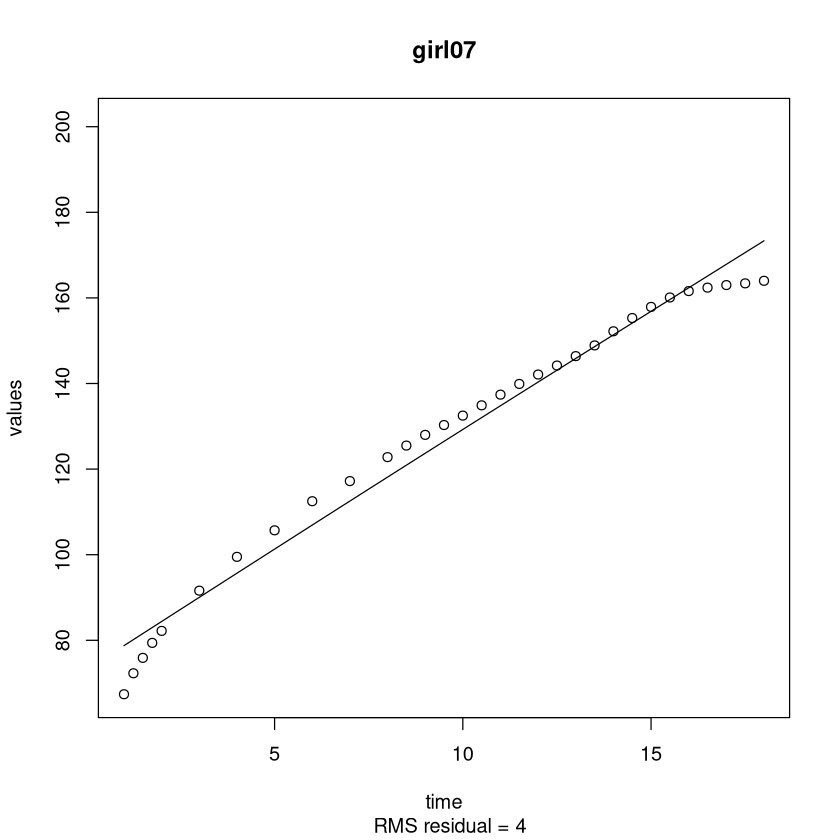

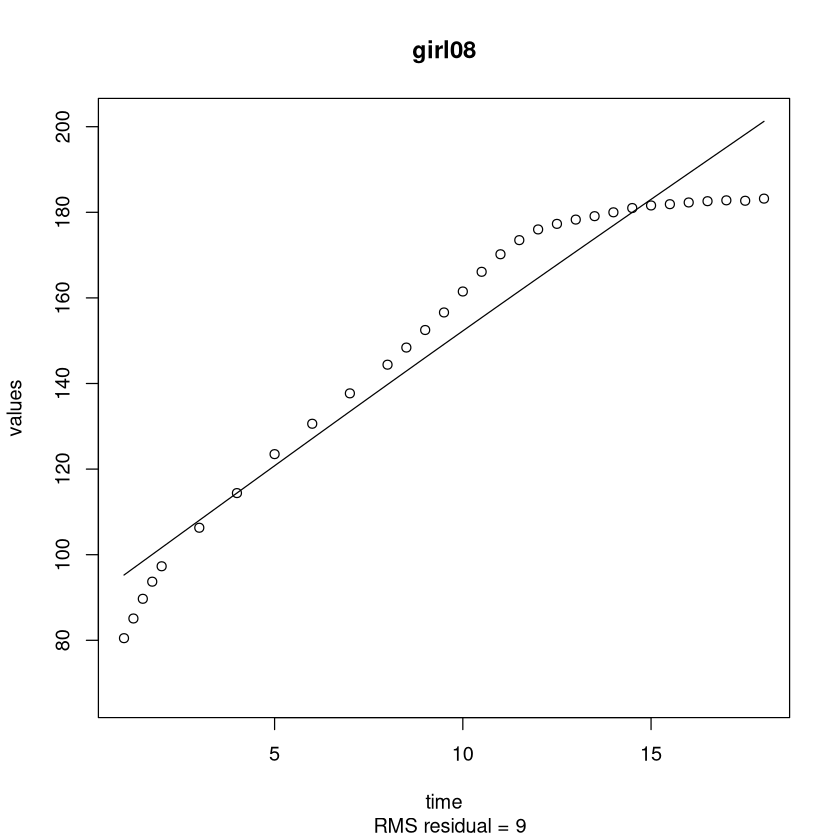

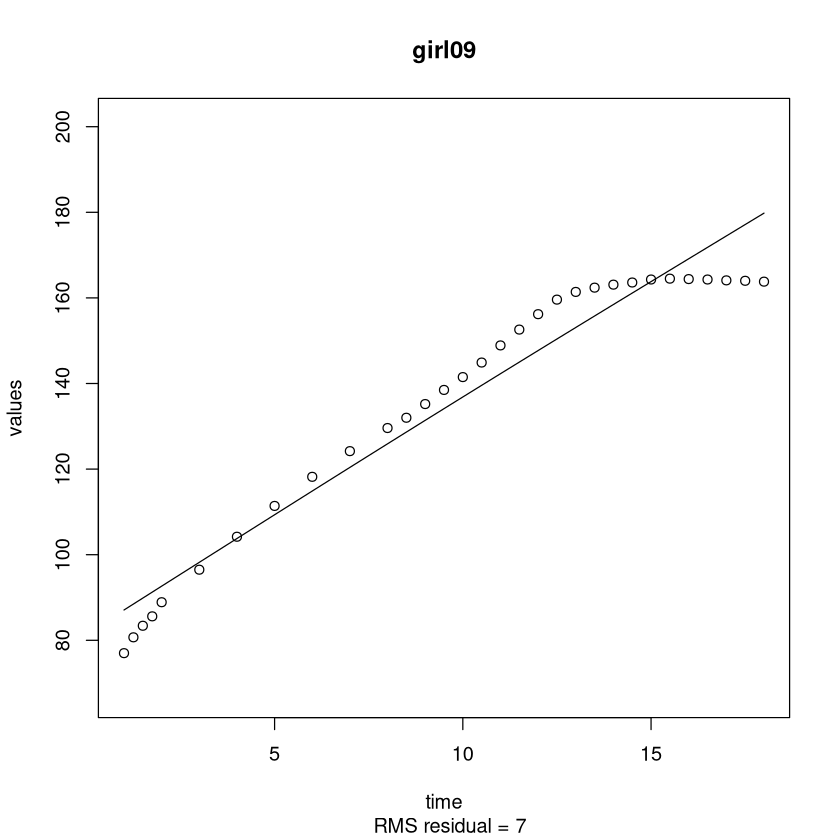

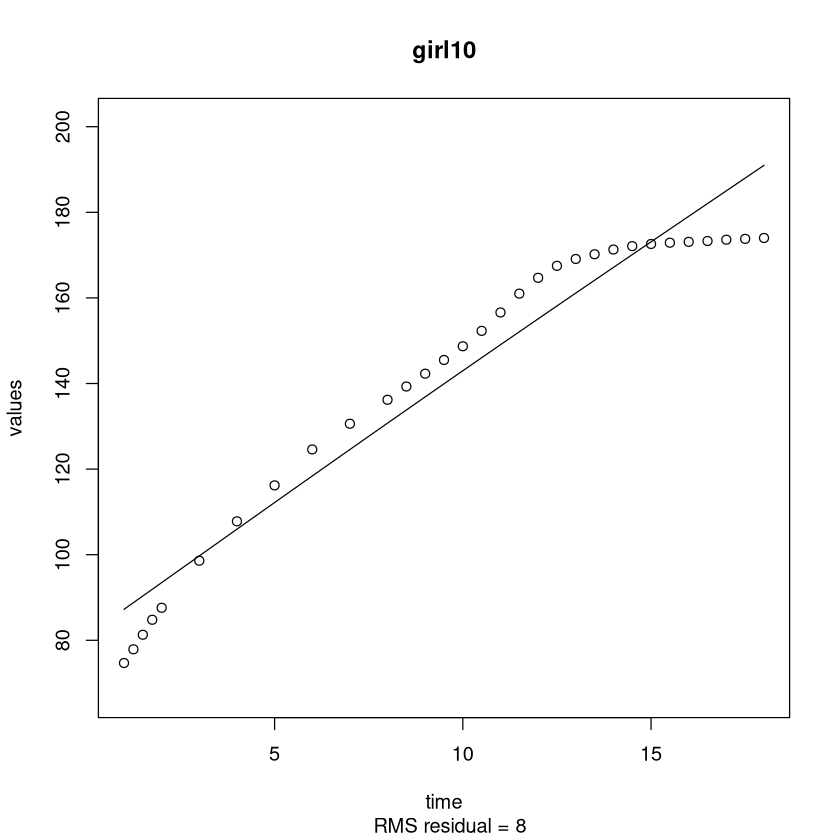

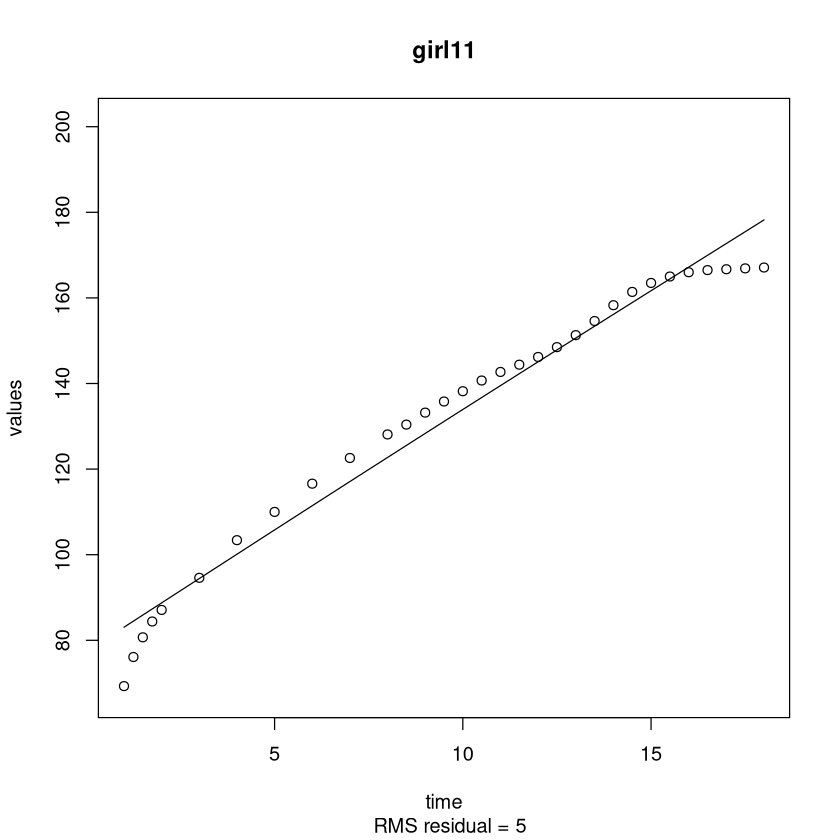

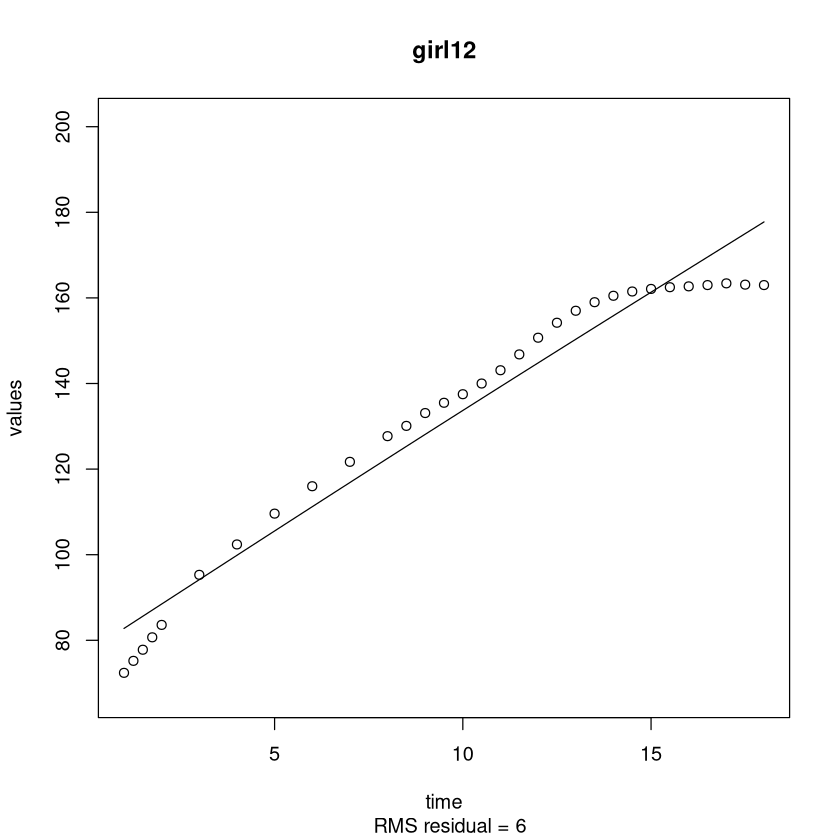

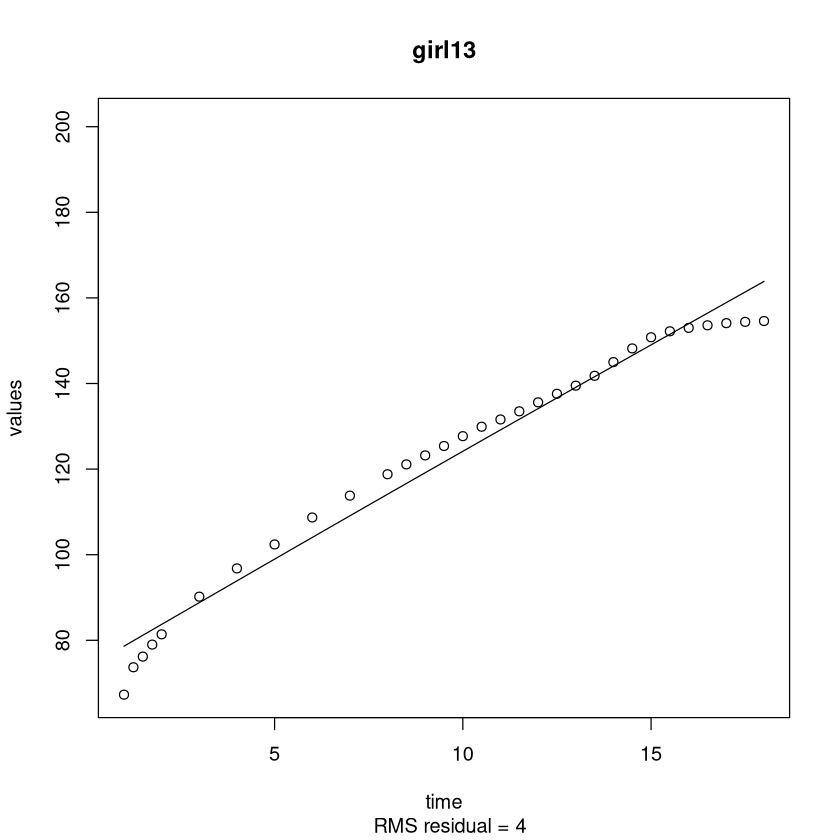

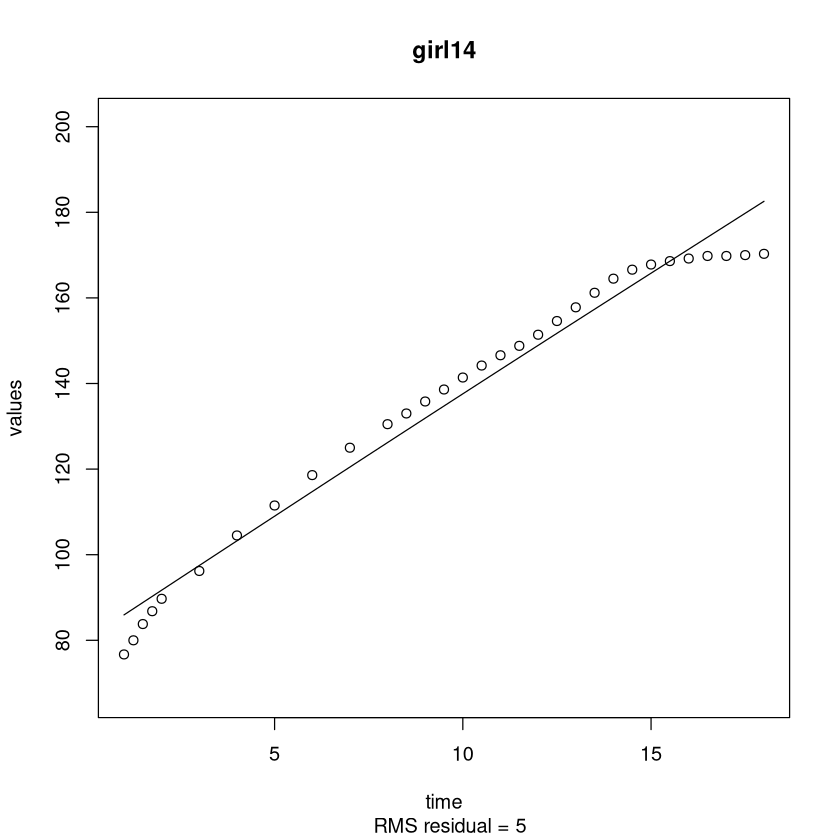

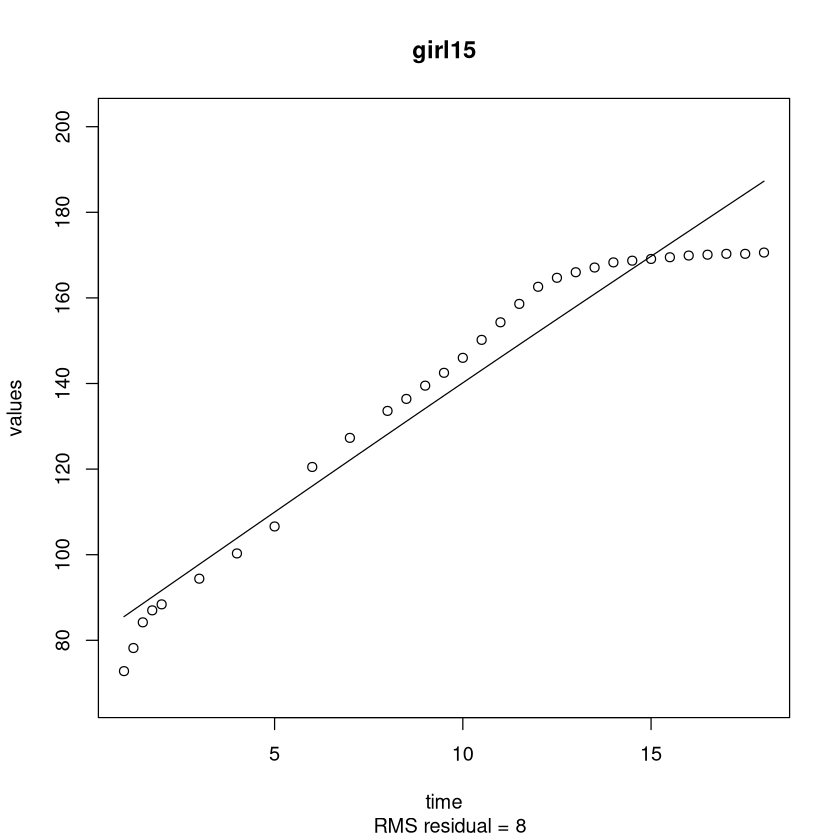

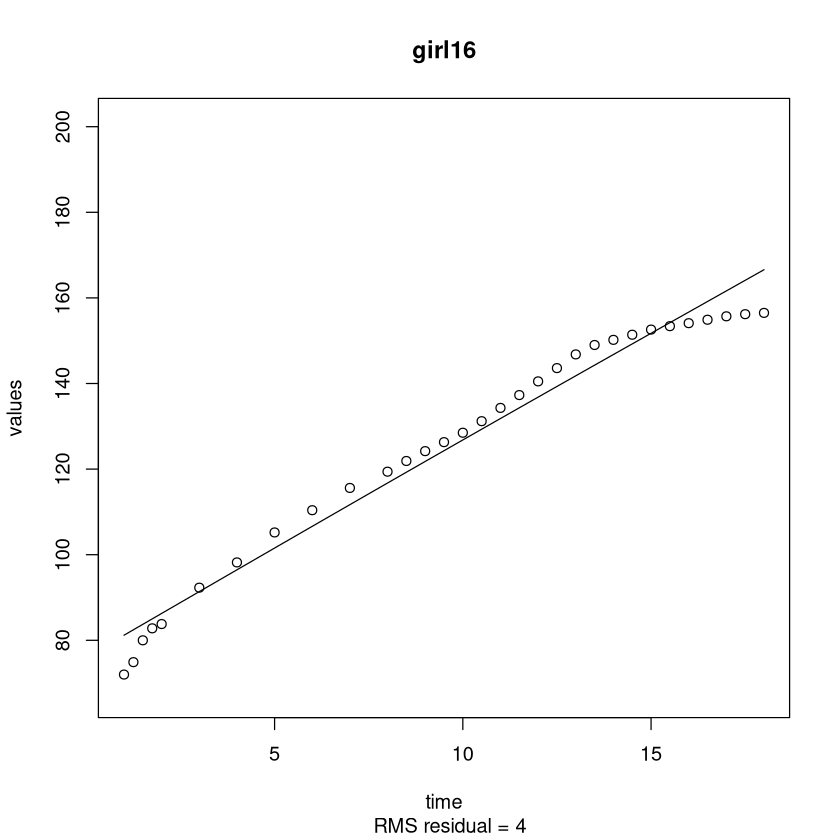

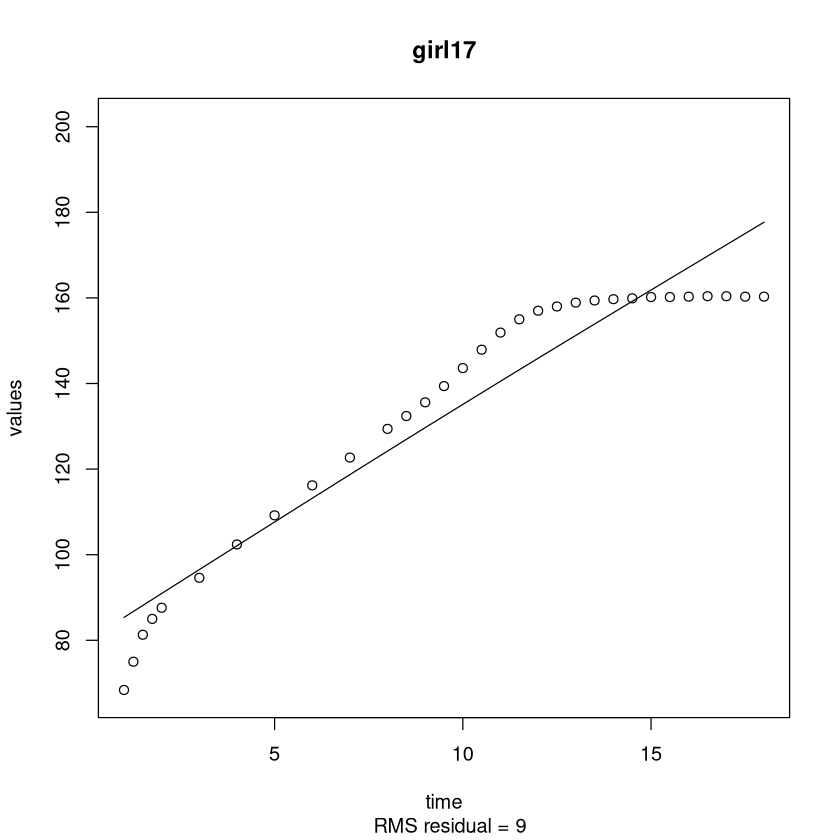

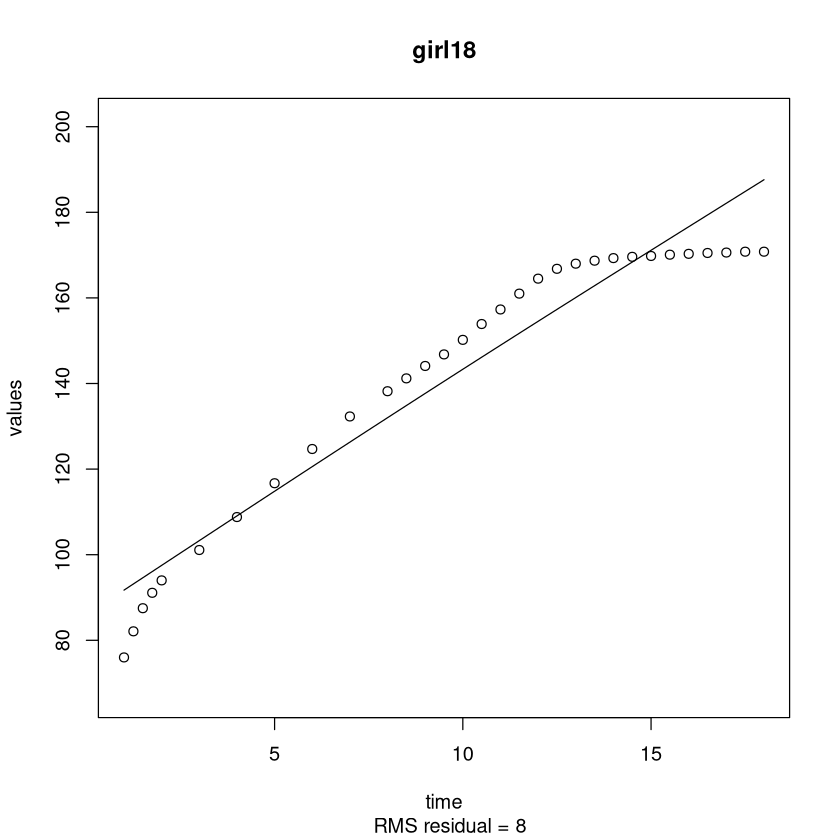

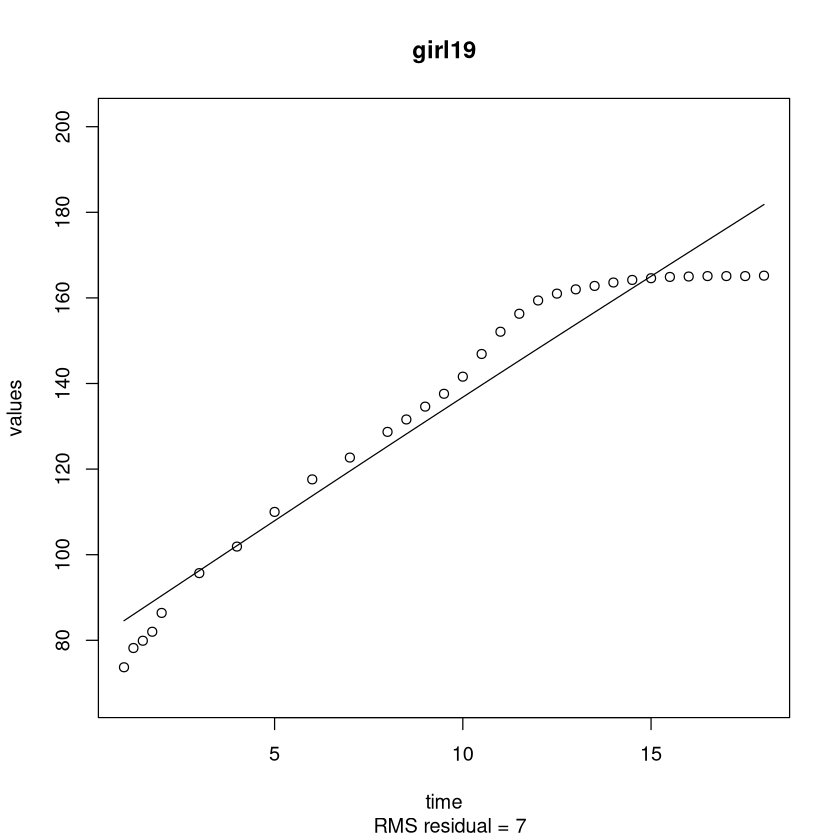

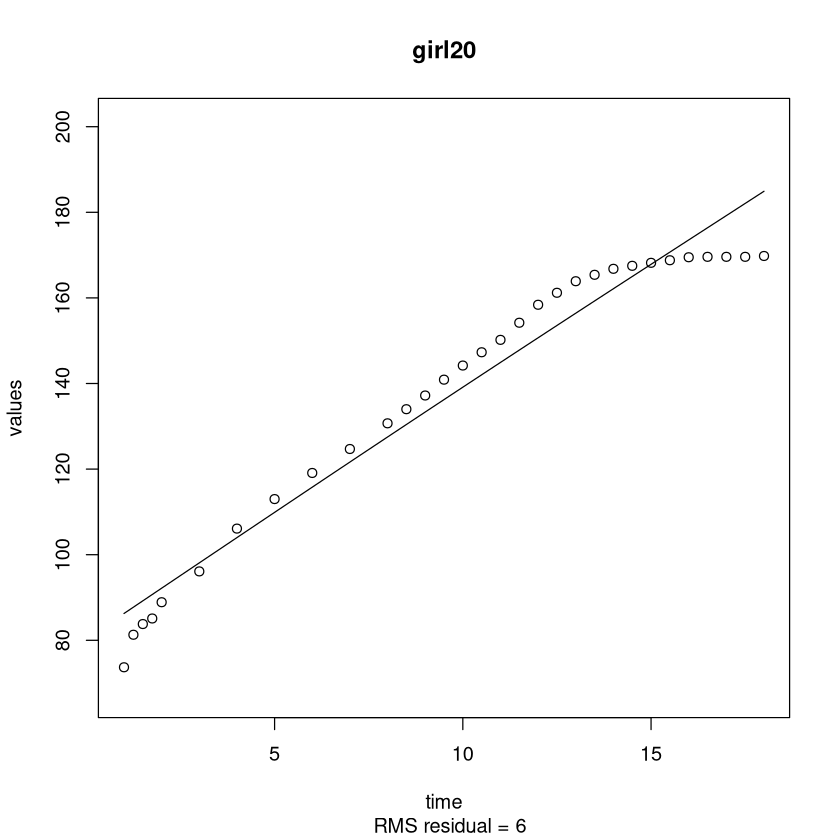

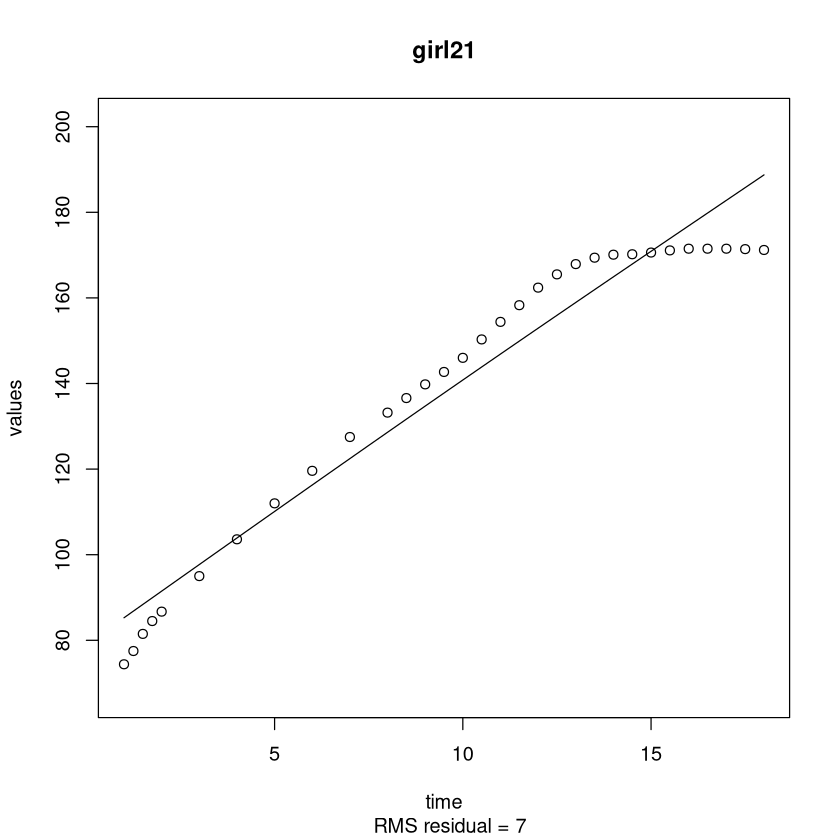

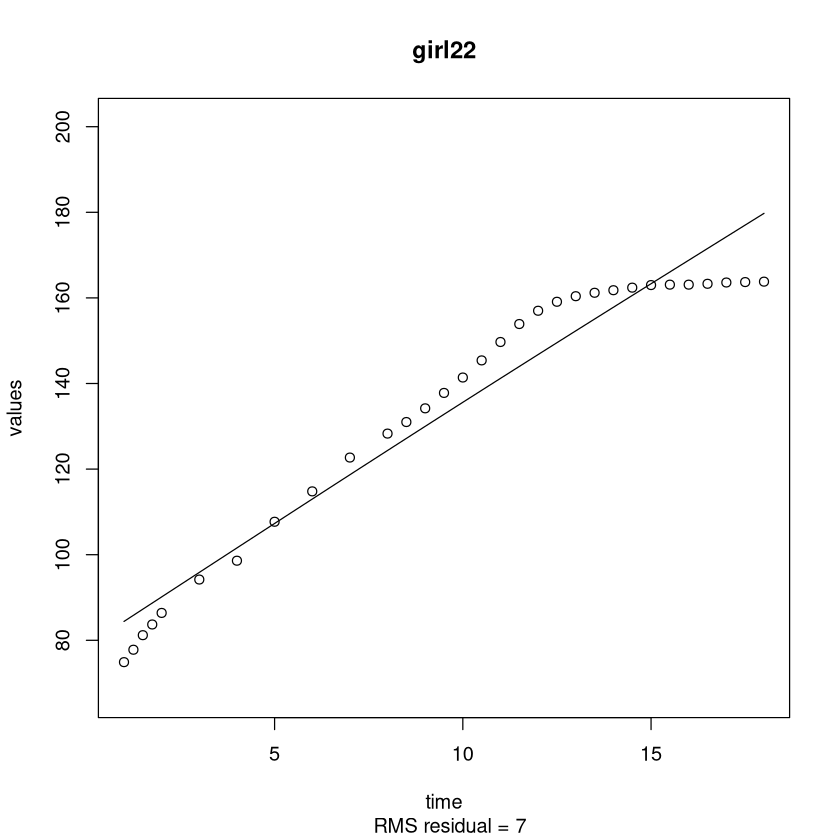

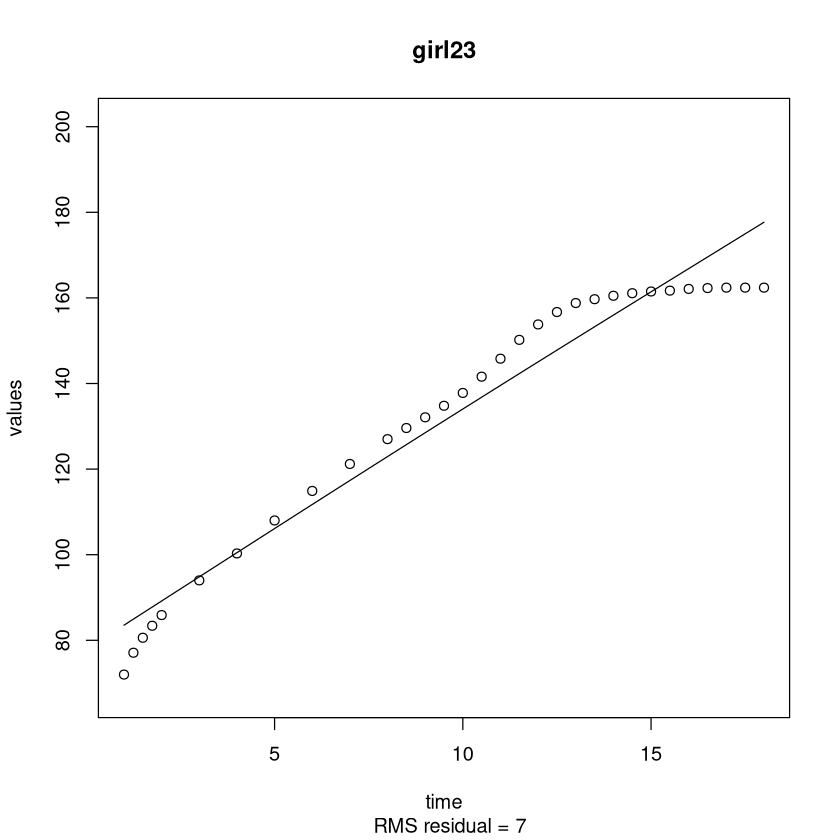

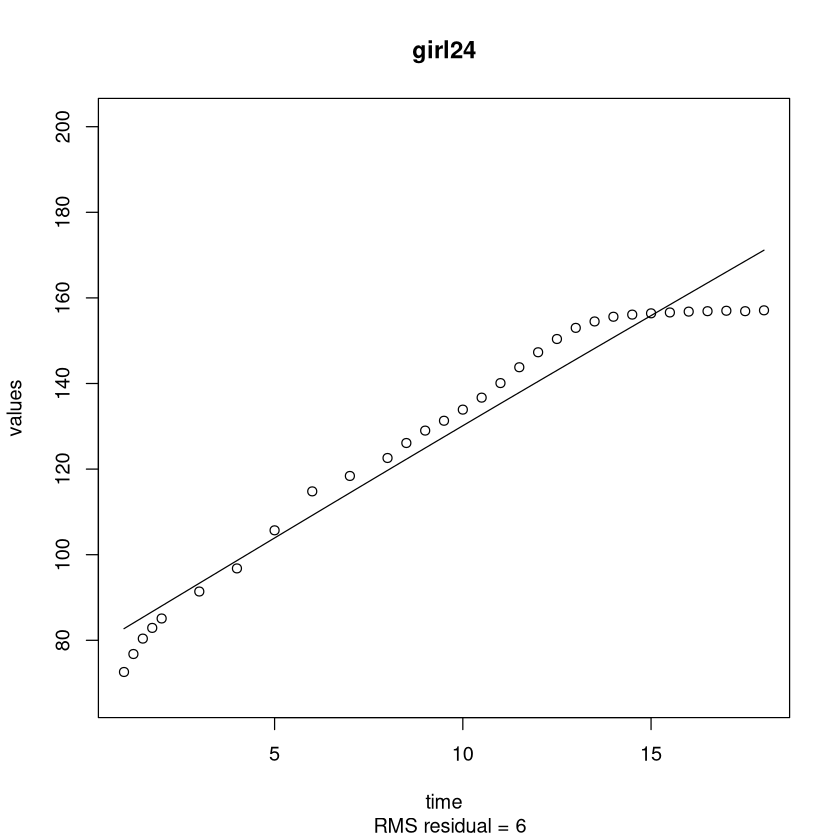

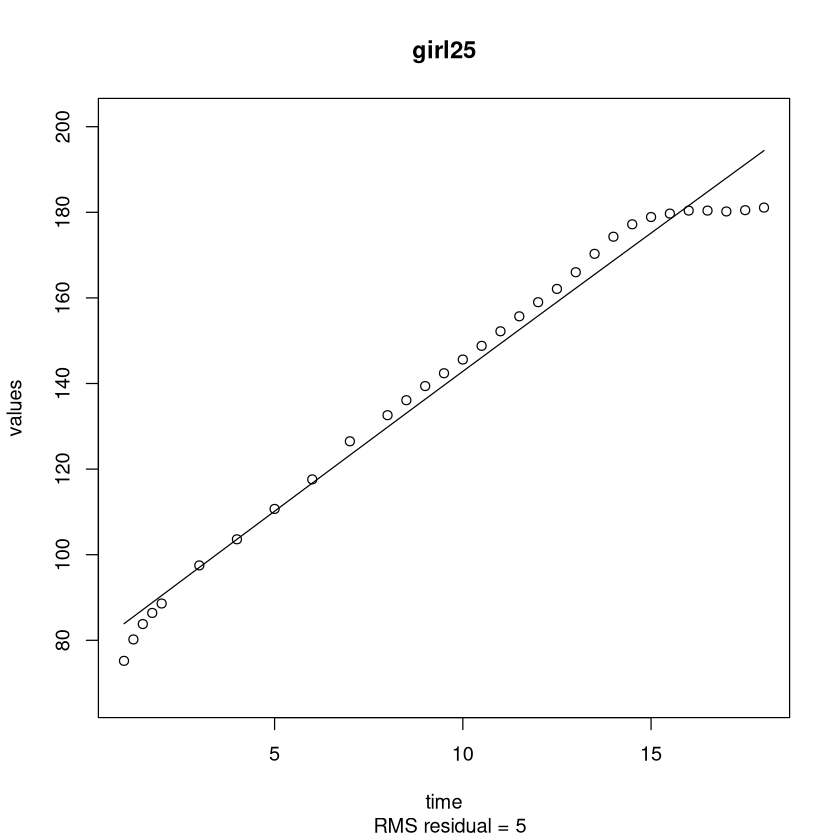

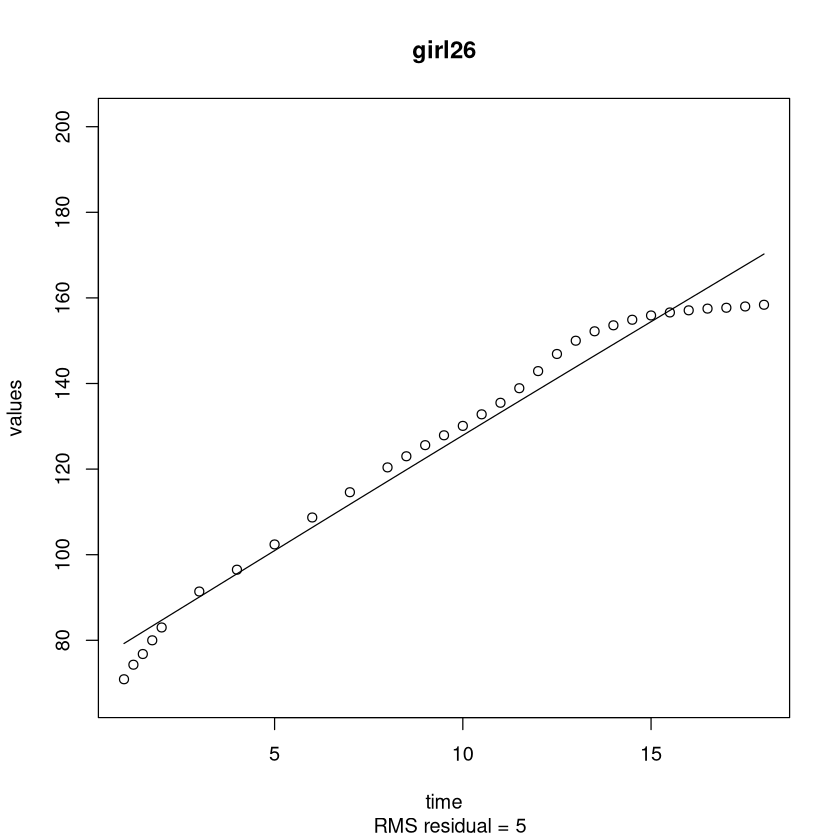

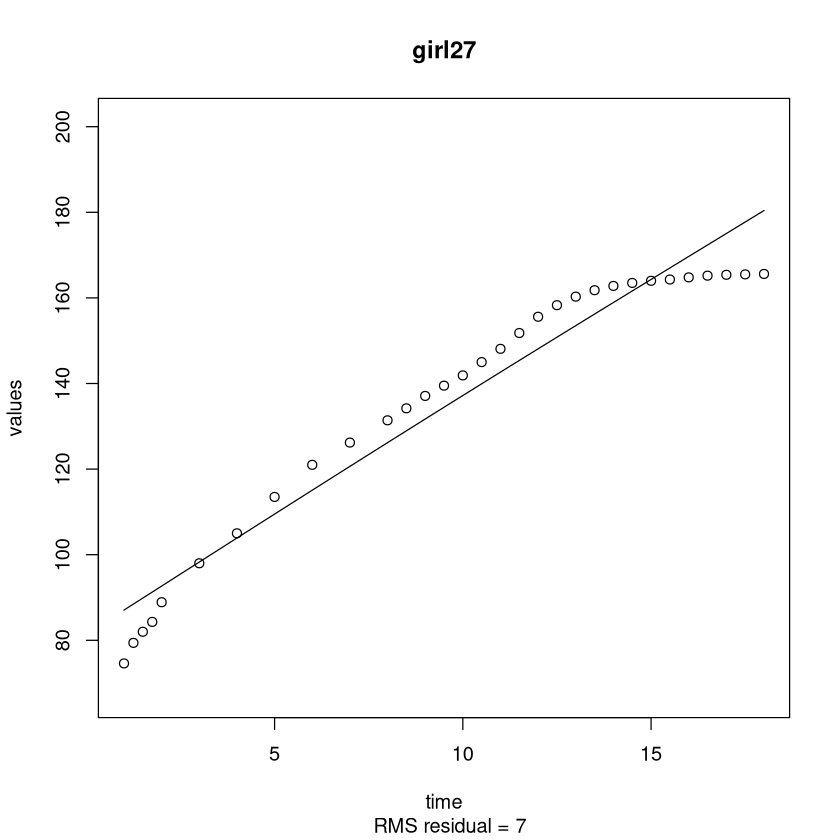

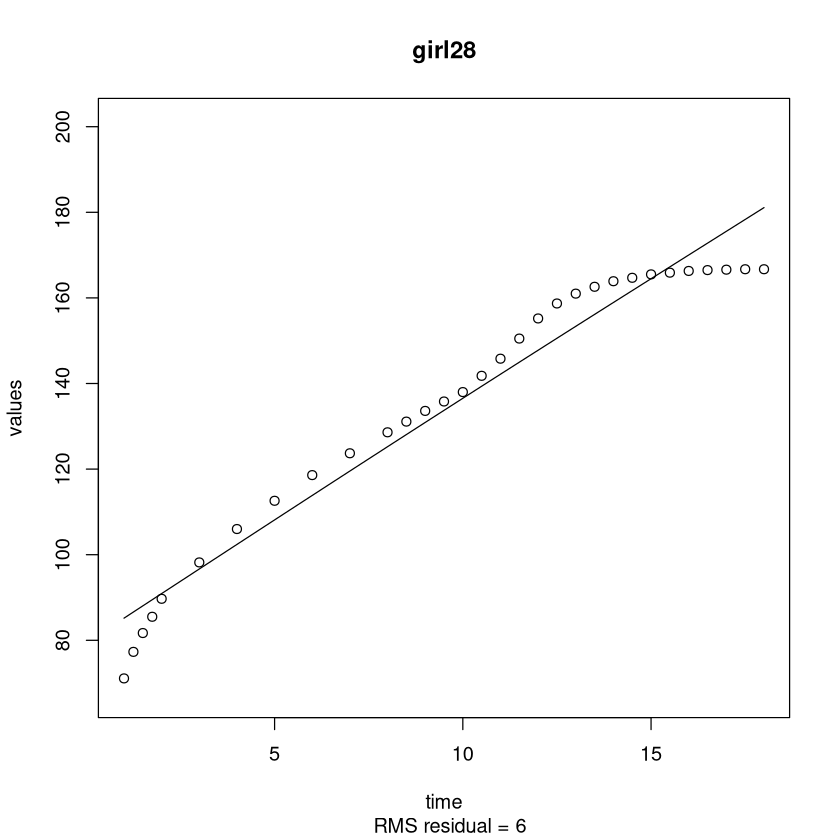

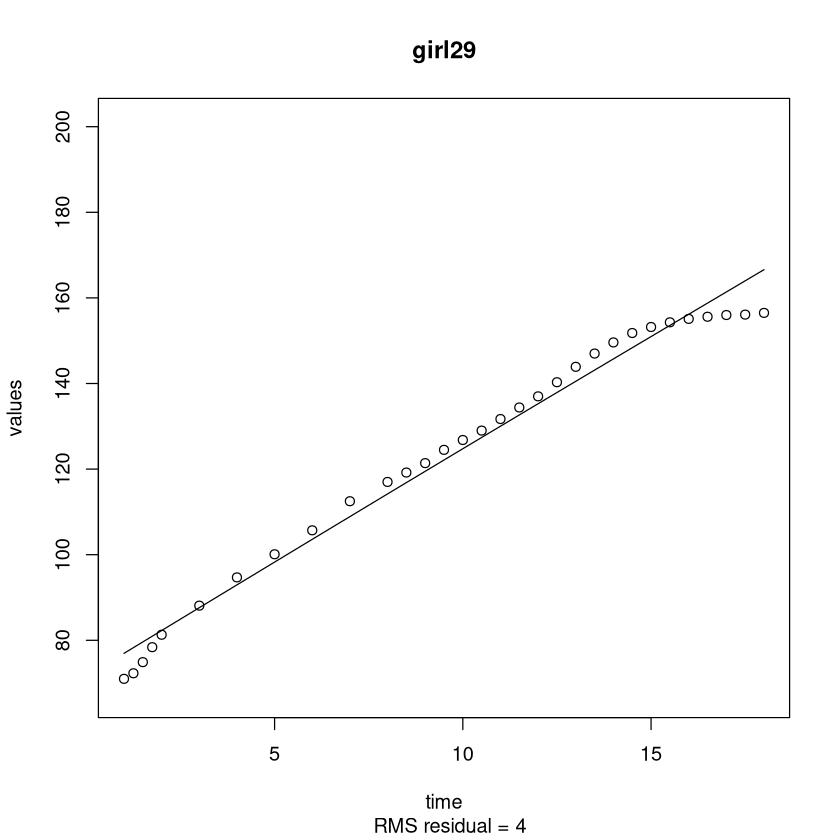

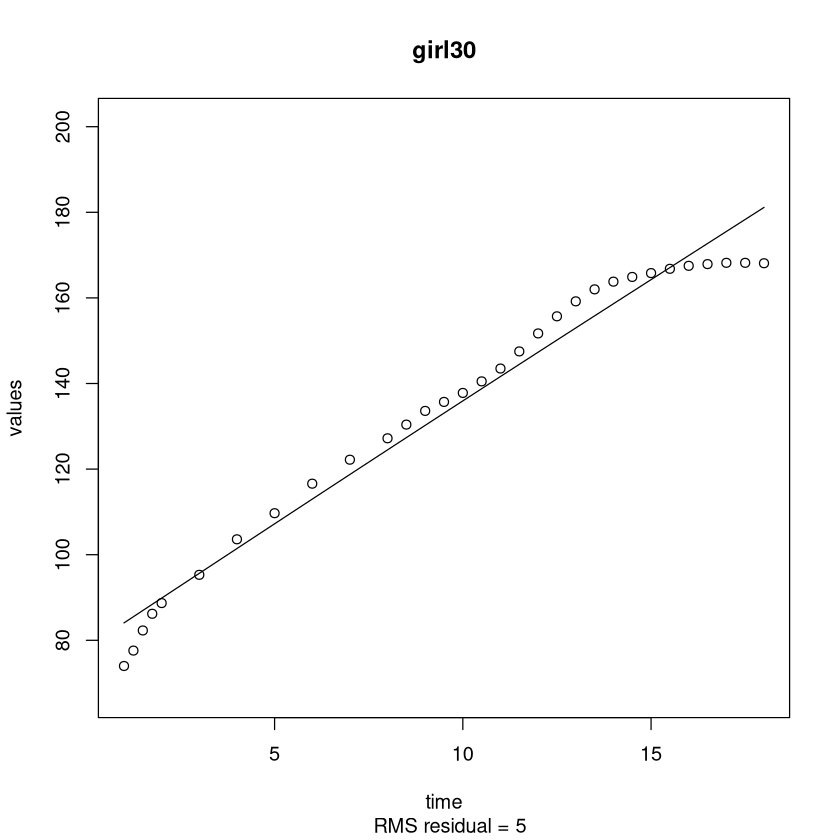

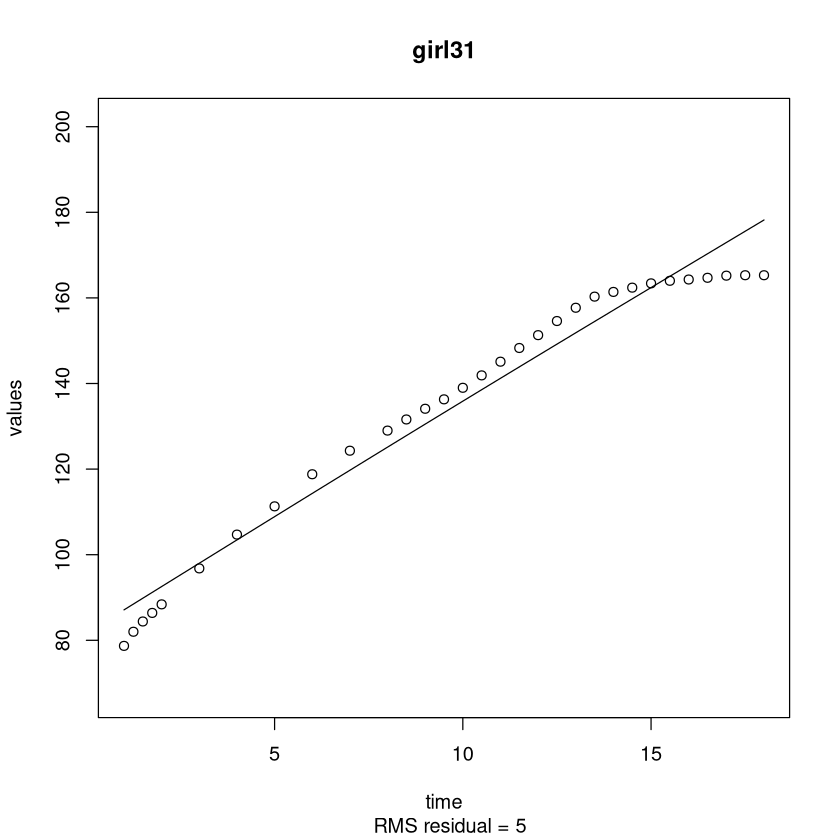

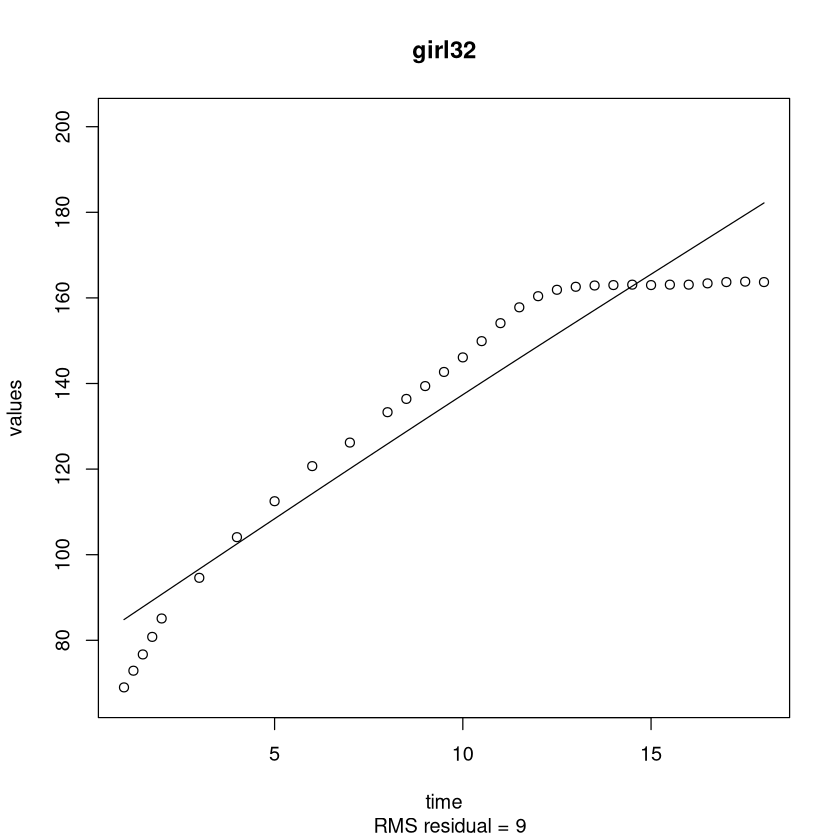

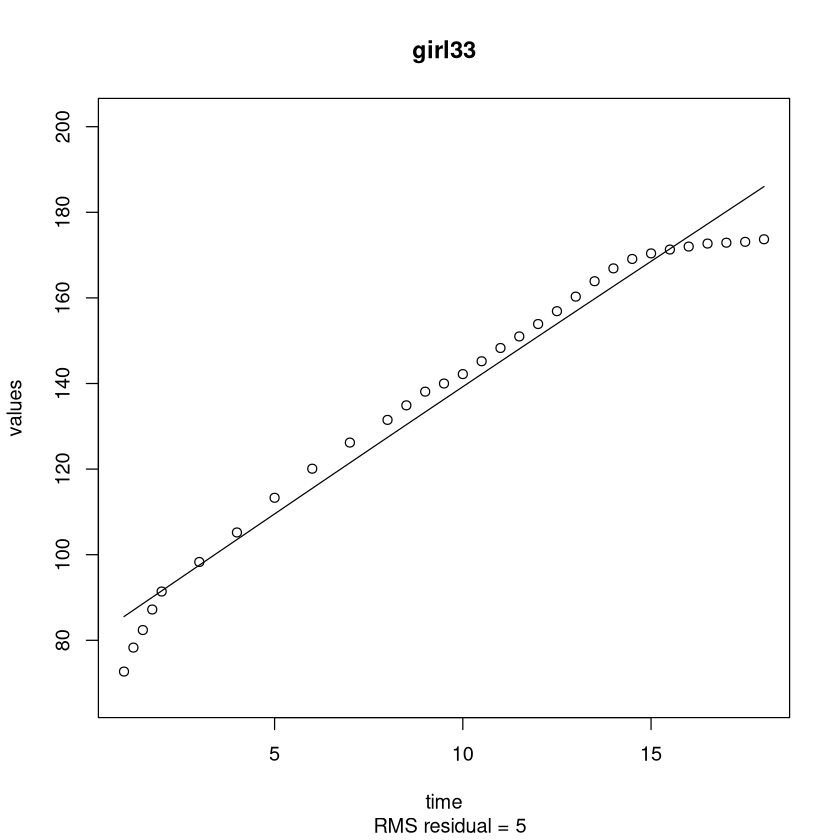

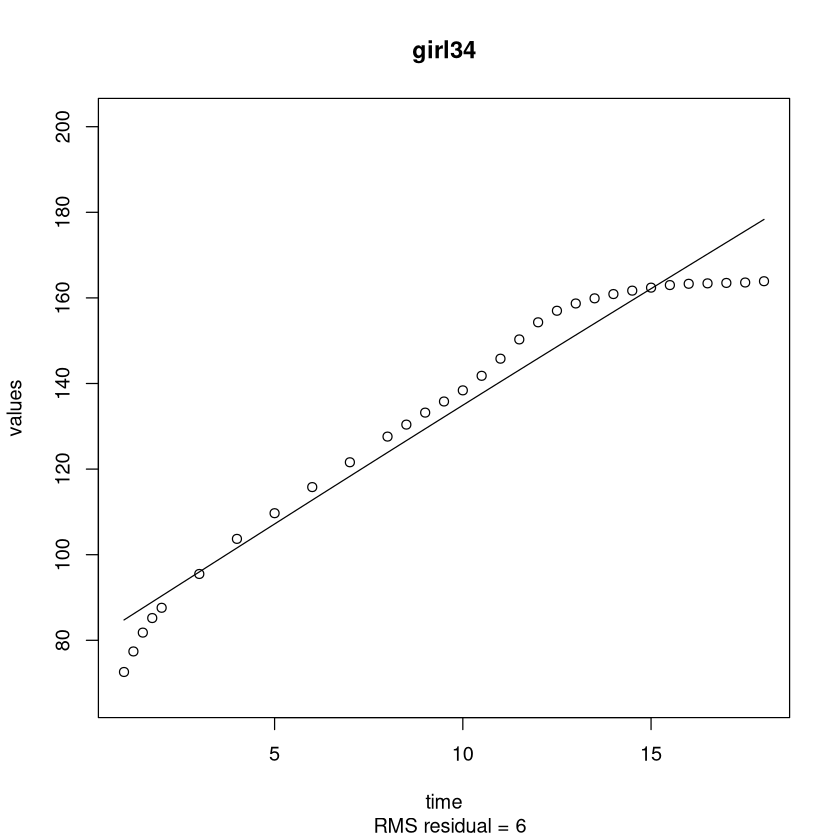

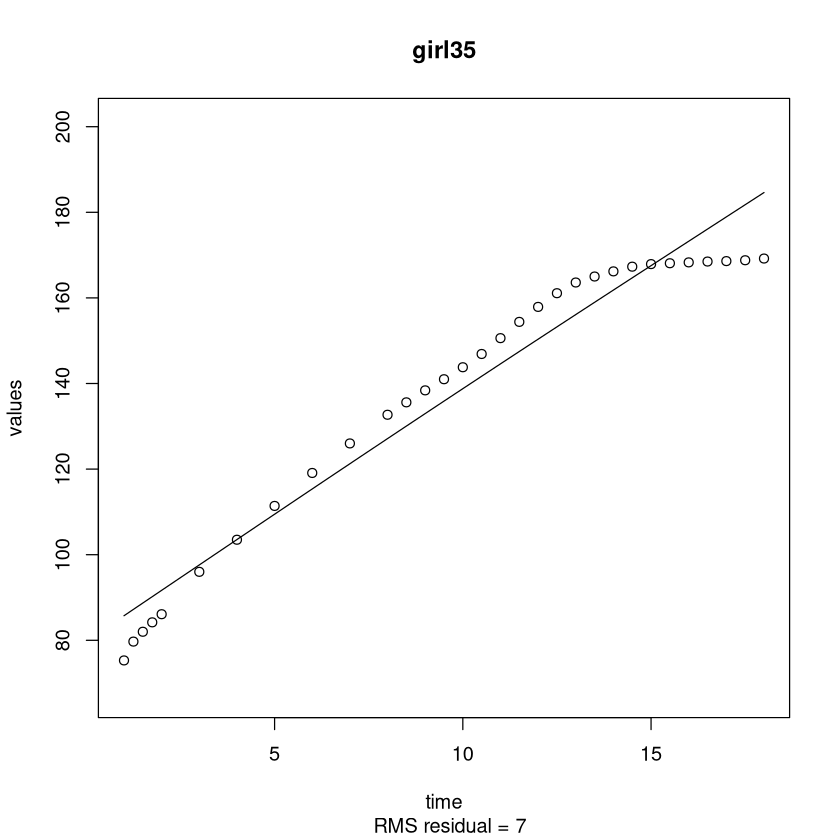

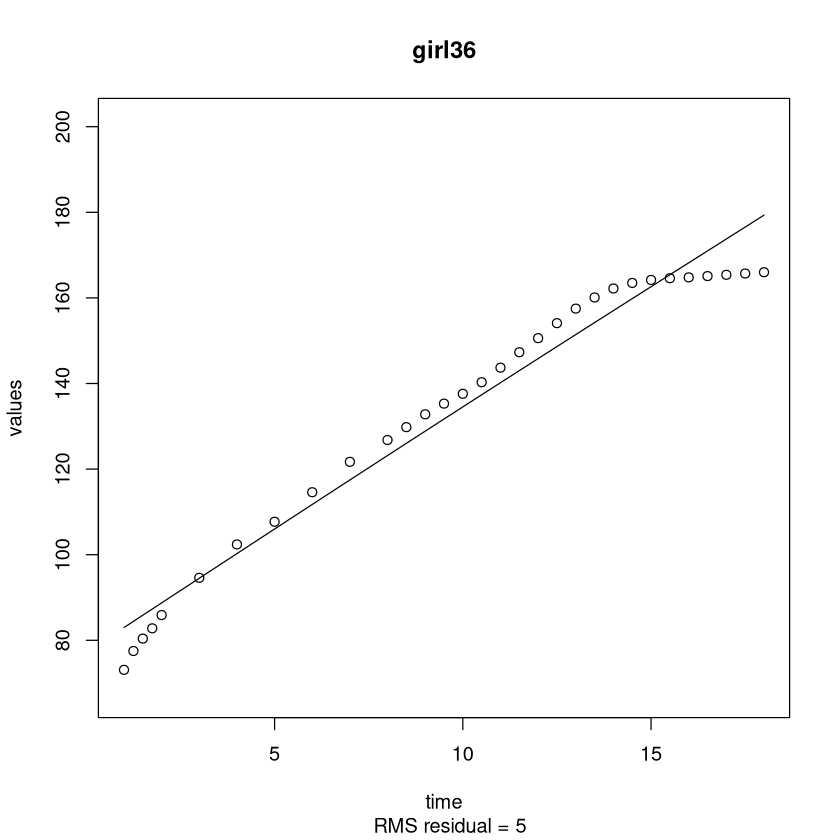

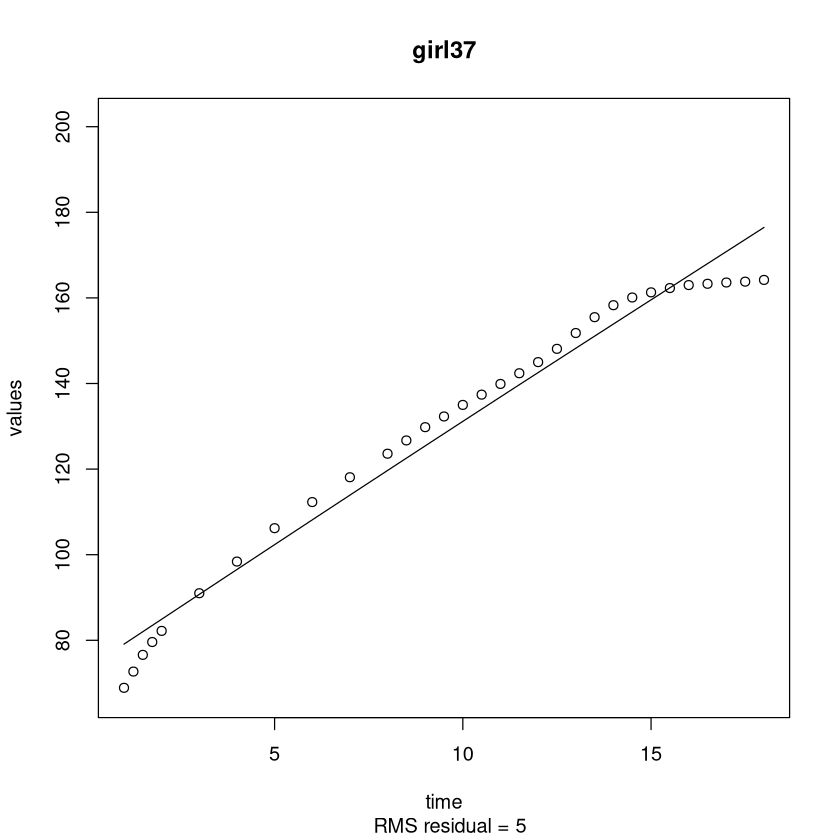

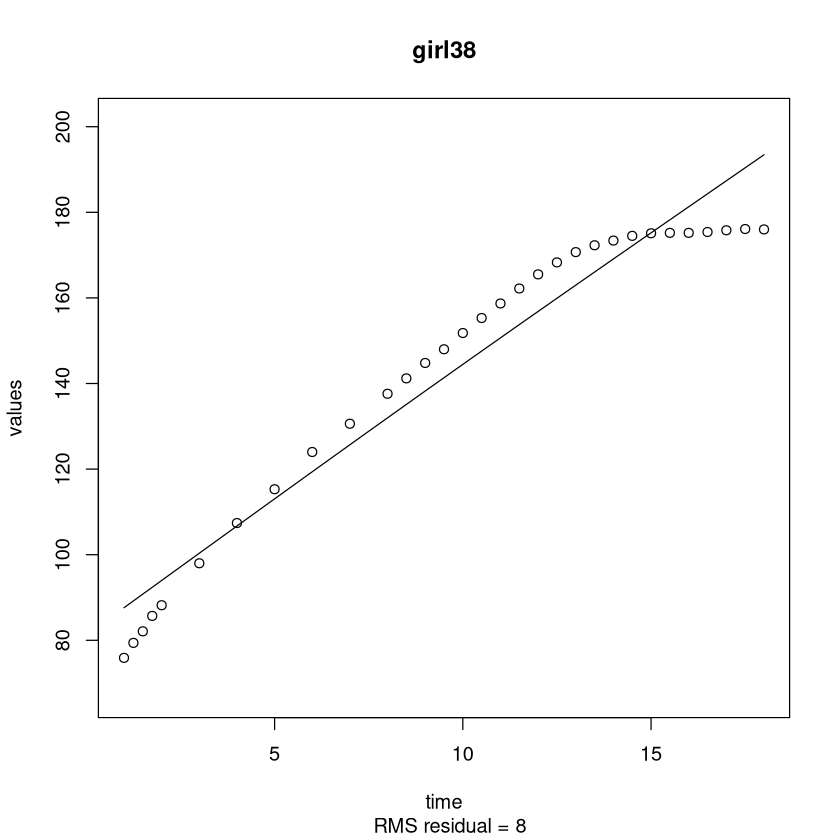

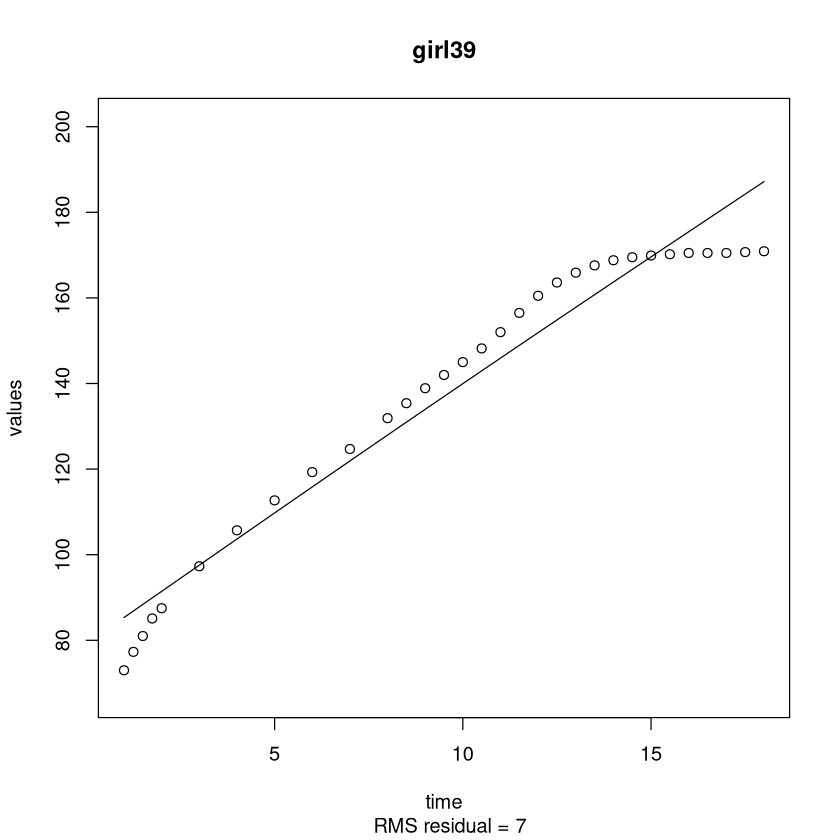

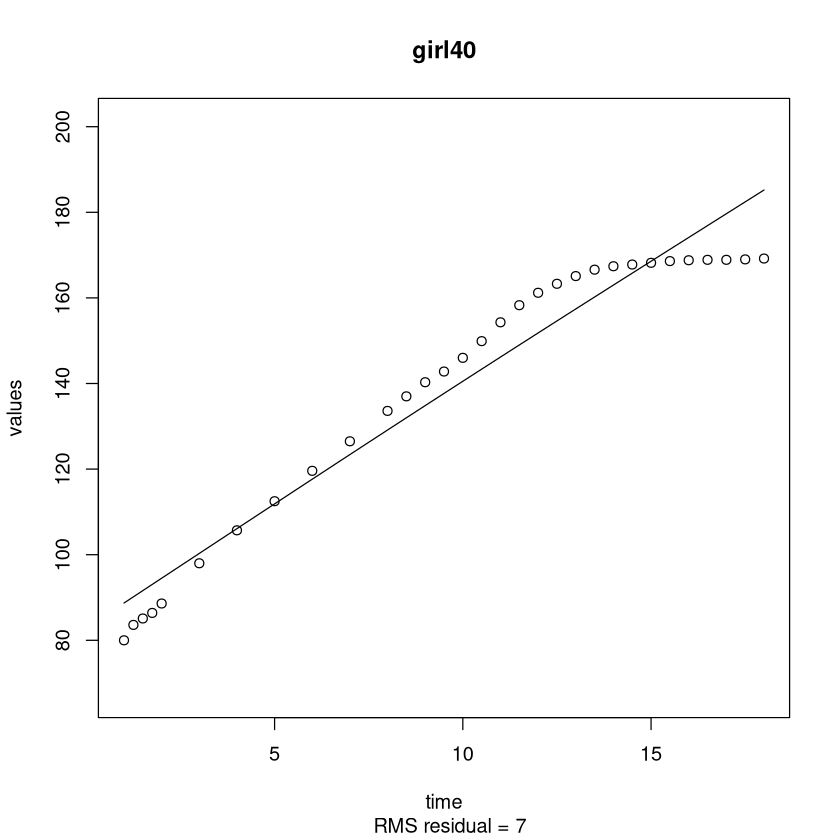

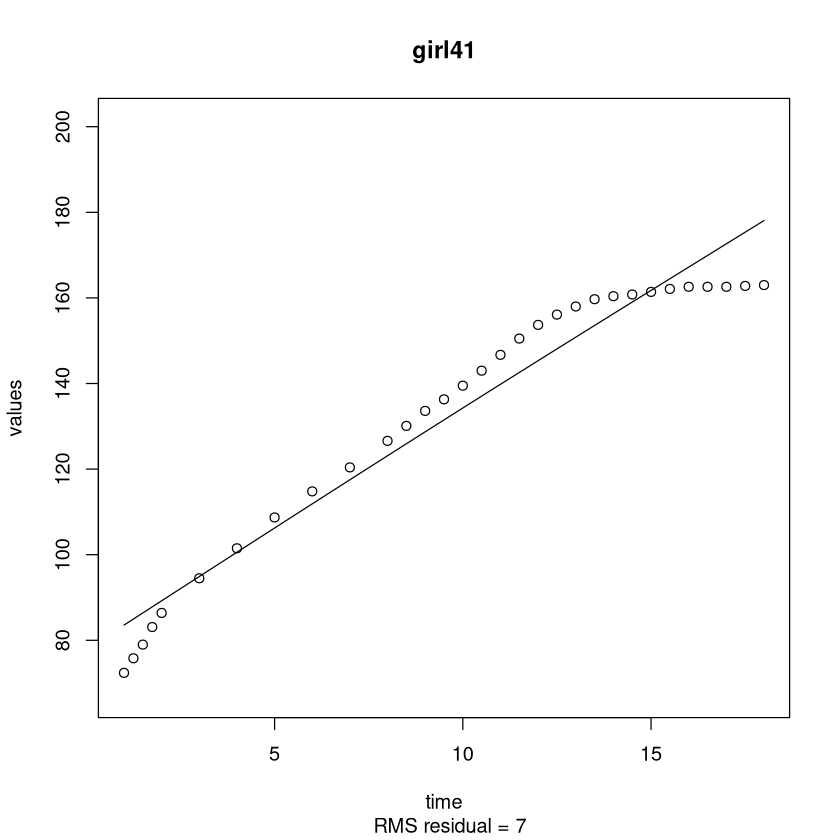

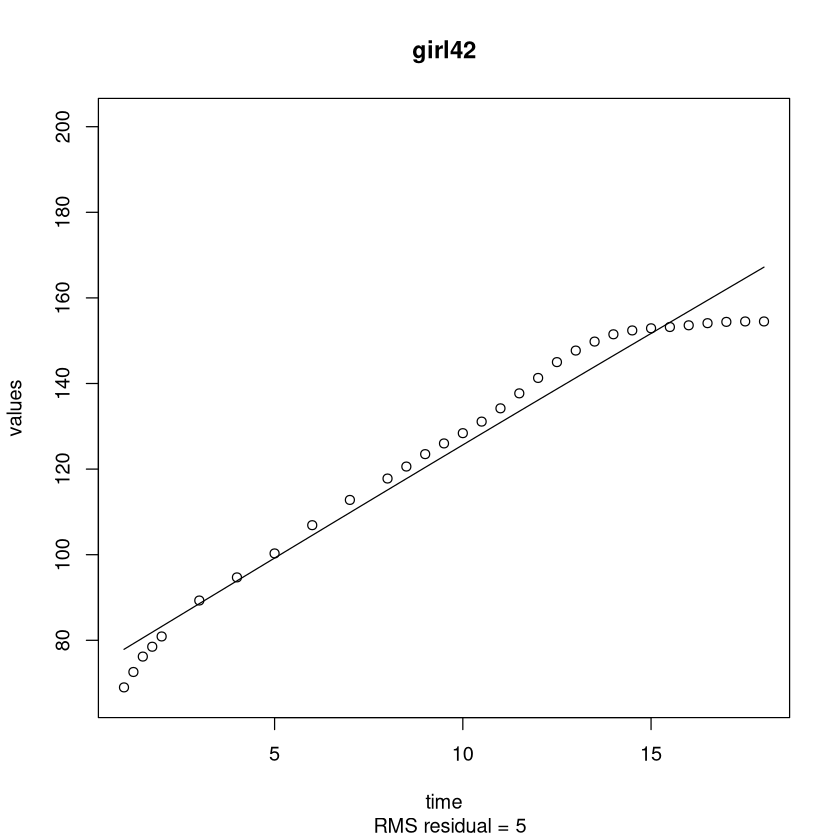

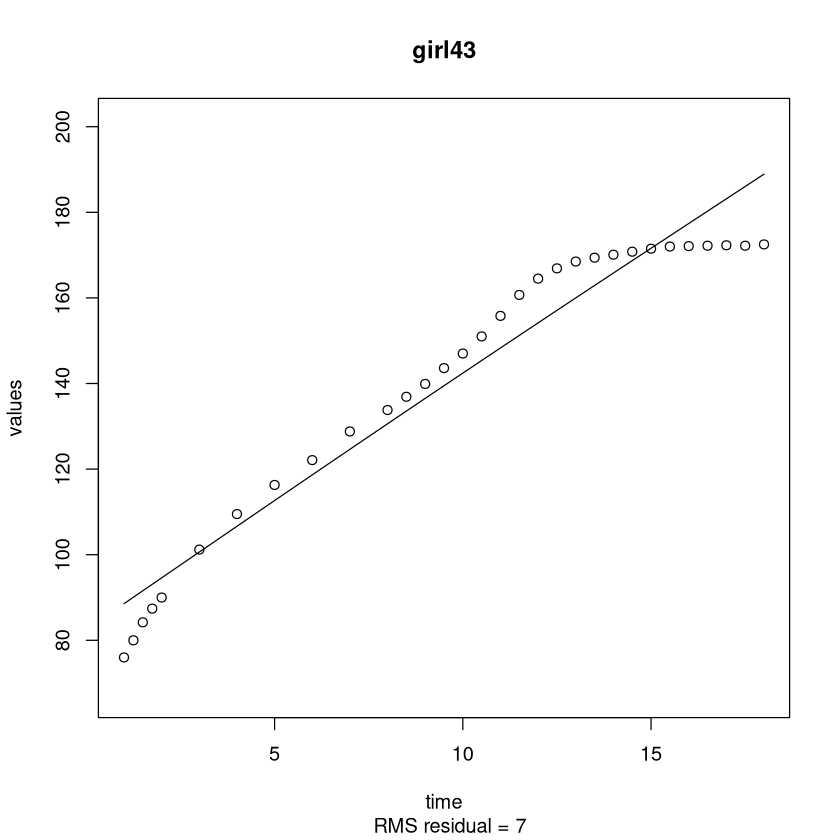

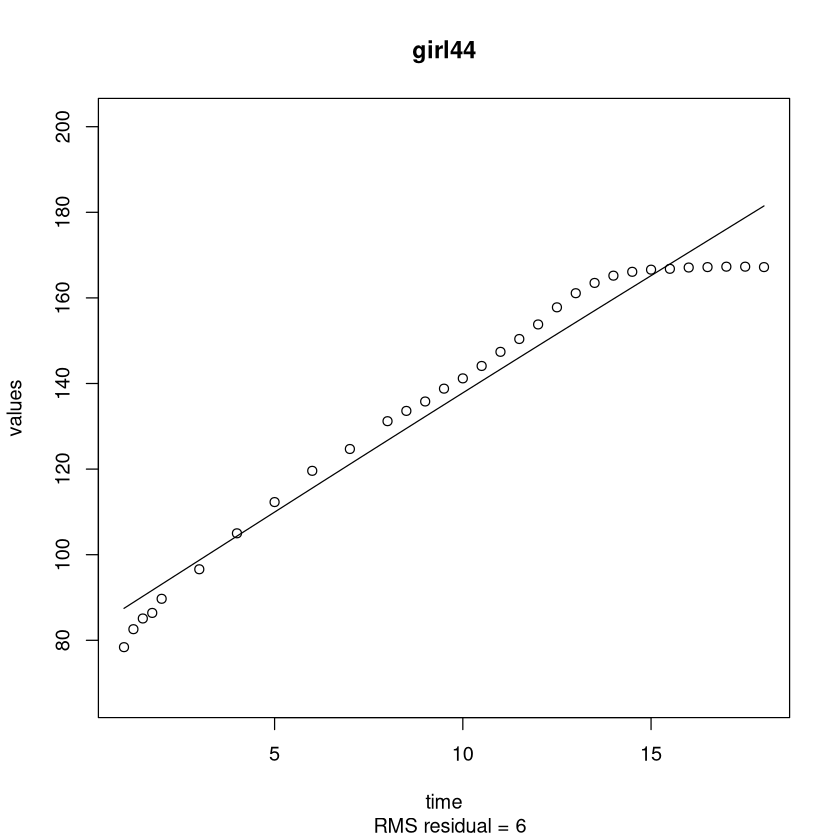

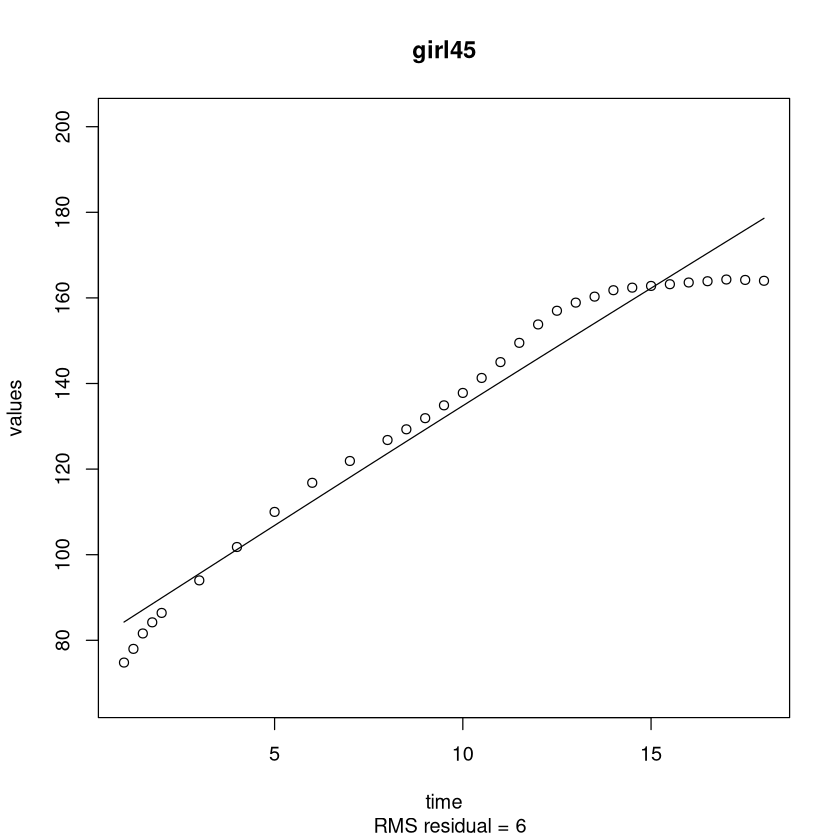

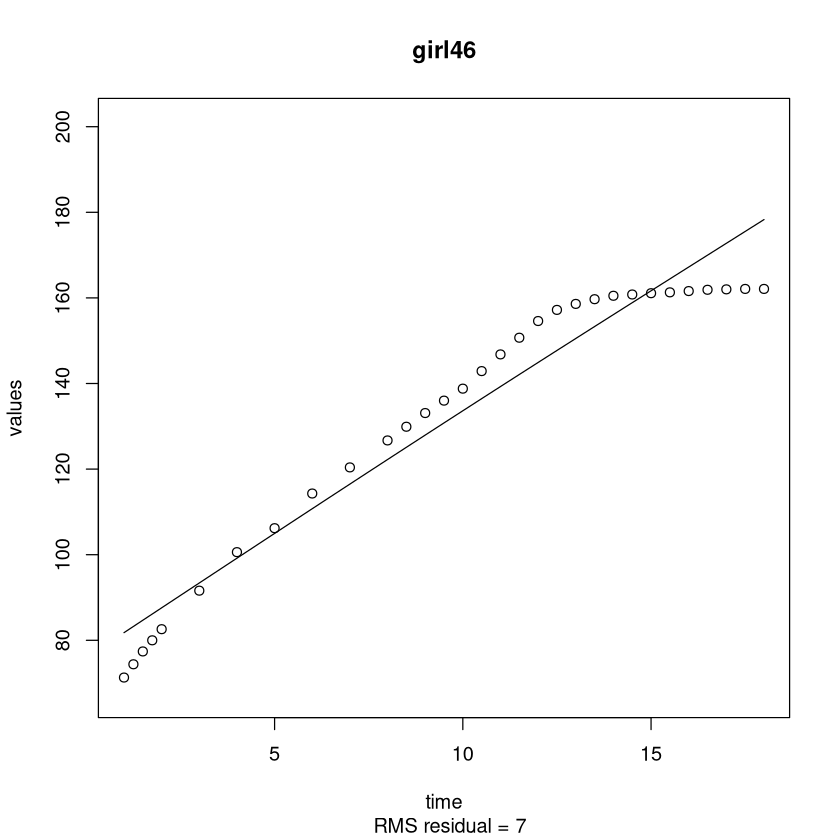

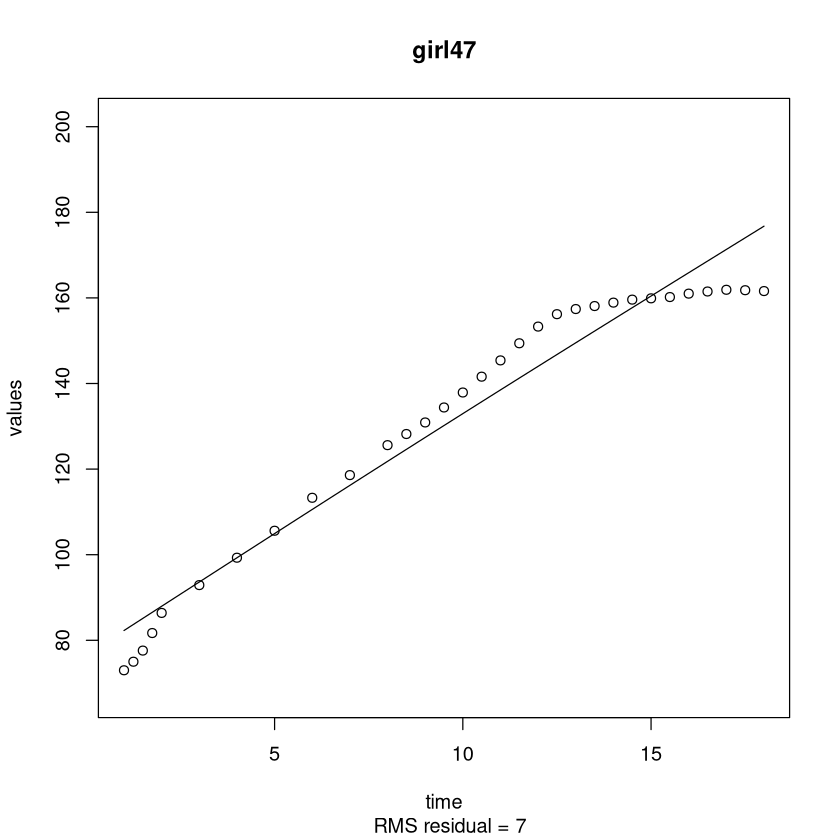

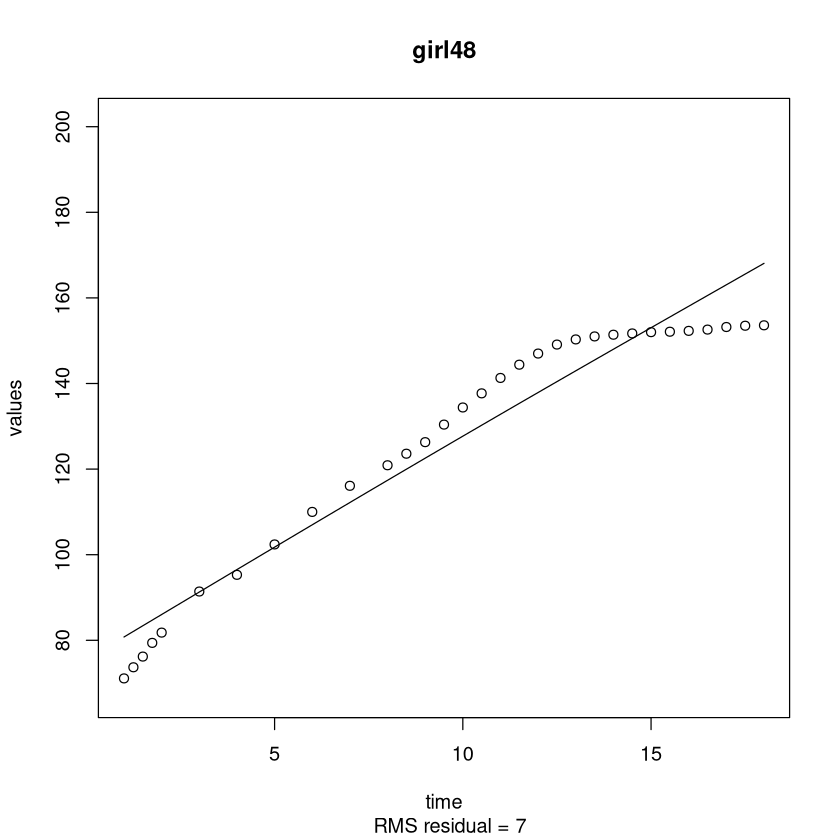

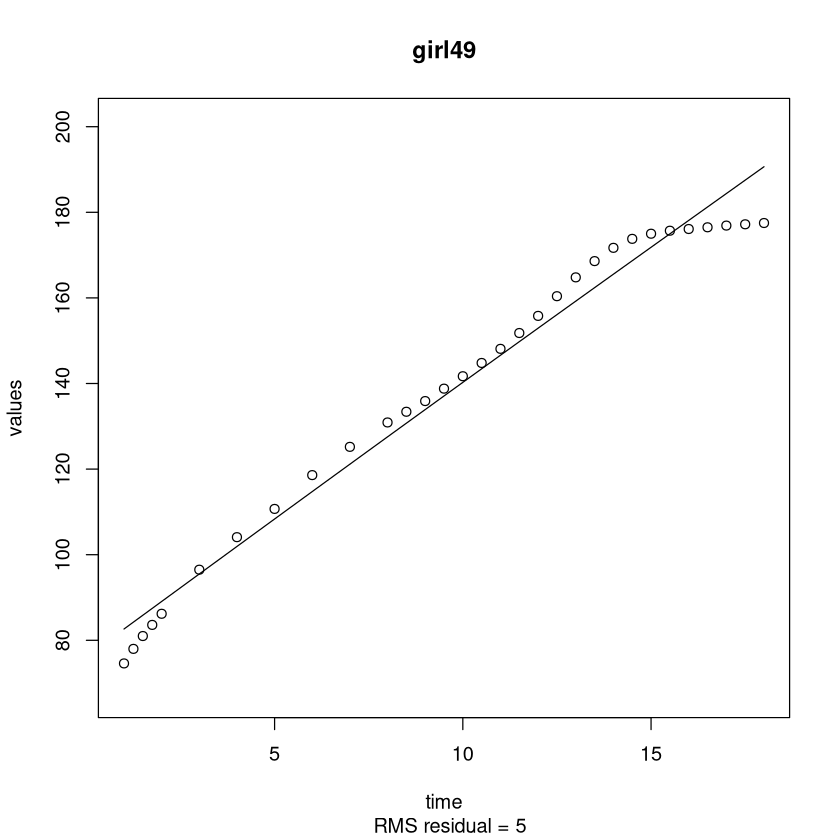

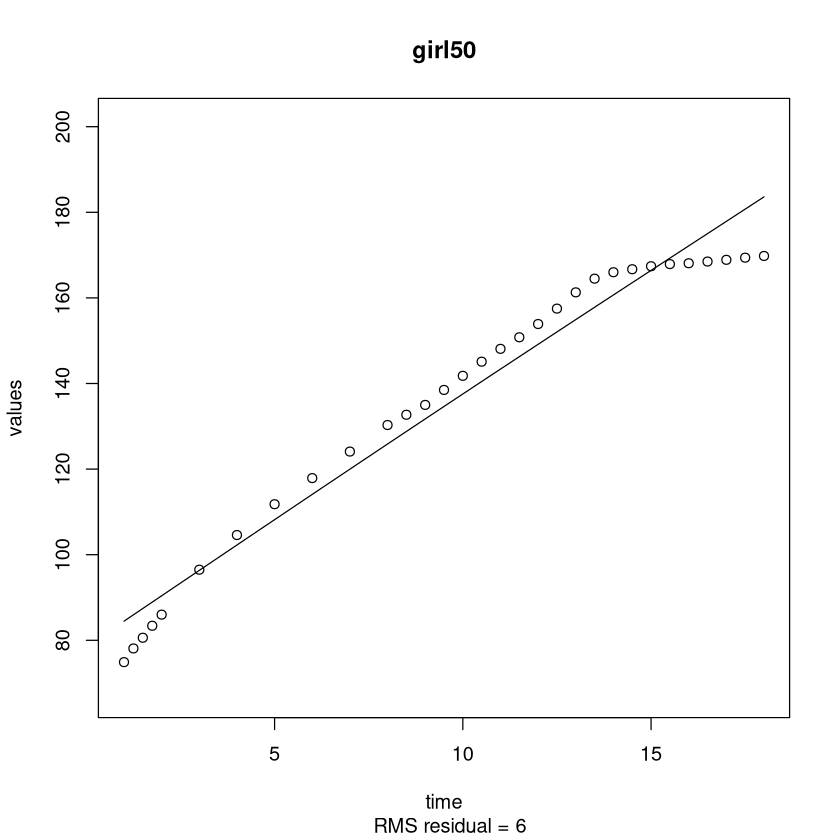

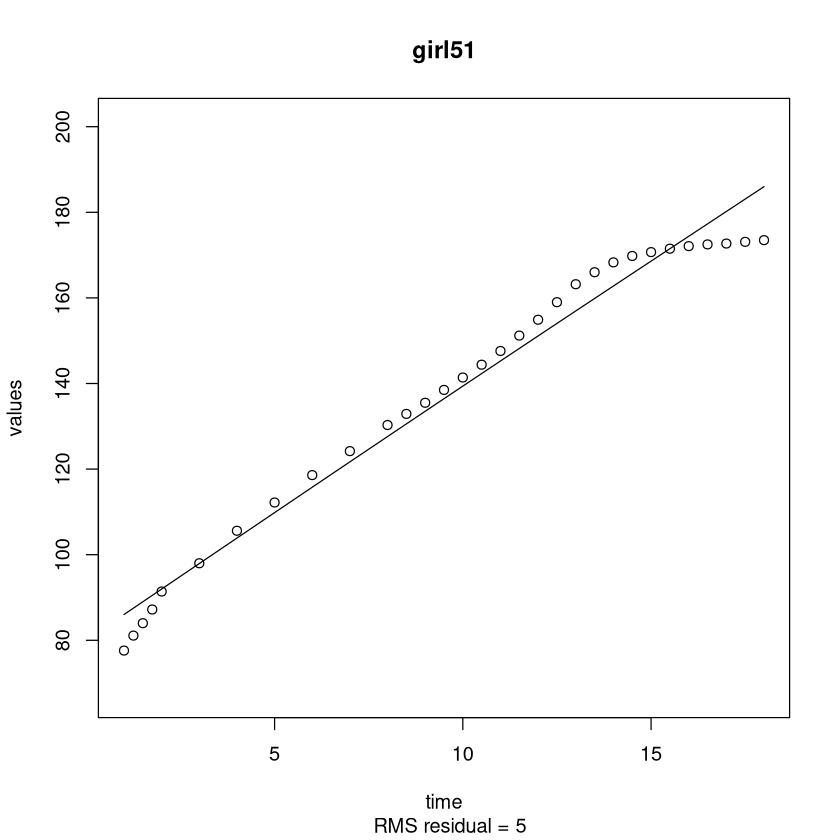

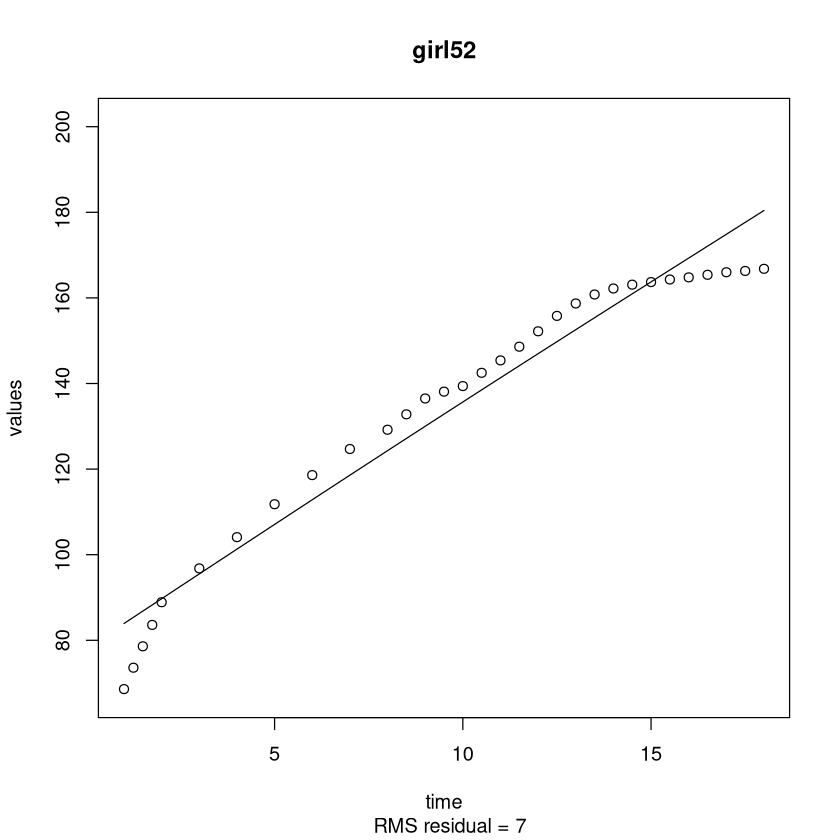

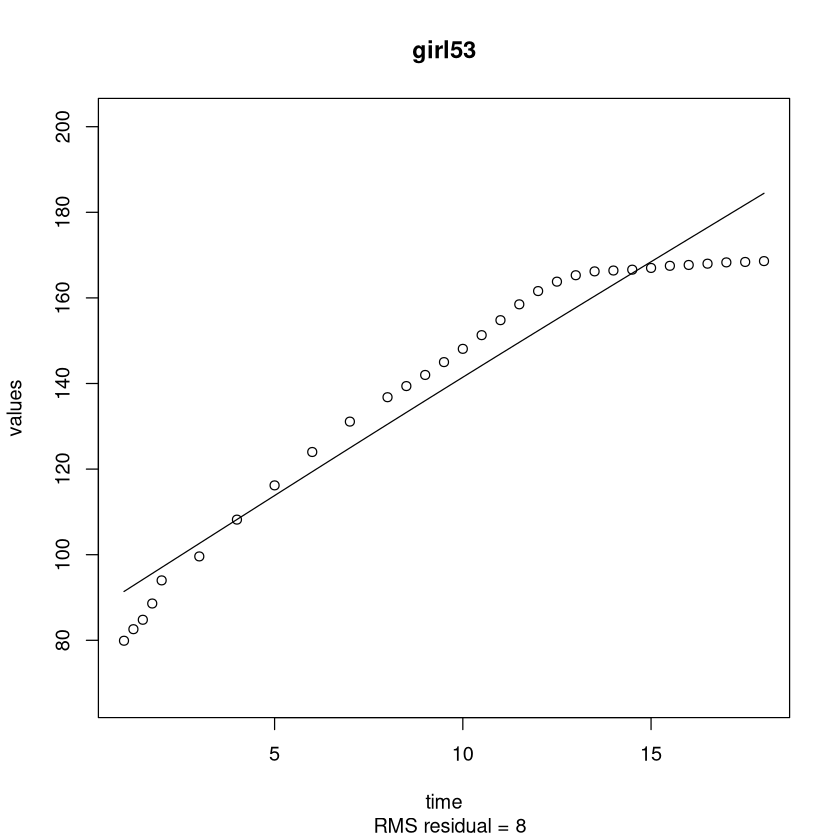

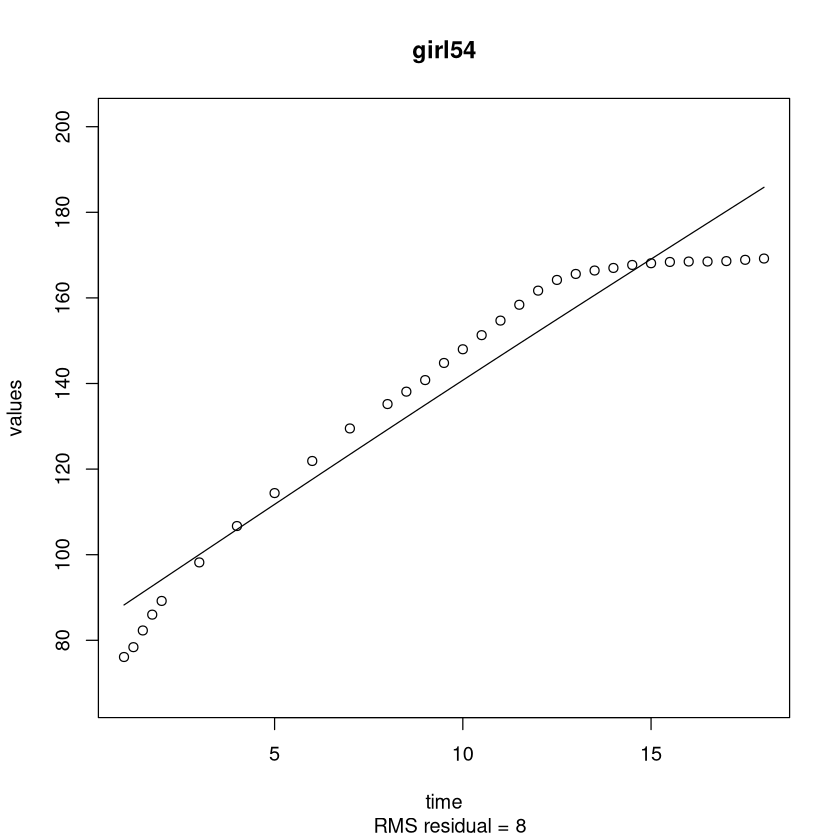

[1] "done"

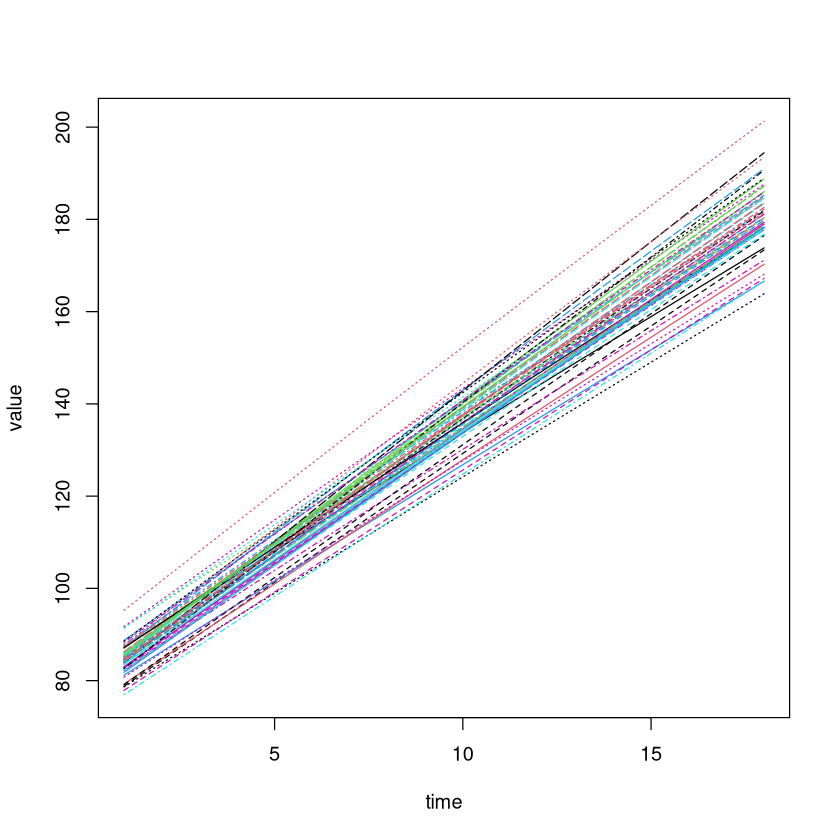

In [12]:
# The functional parameter object holds a basis, a Lfd and a value for lambda.
# We can now make a new call to

syfd = smooth.basis(age, heightmat, D2fdPar)

plotfit.fd(heightmat, age, syfd$fd)
plot(syfd) # to strait line

In [13]:
# Now we can examine how this changes with lambda. It is most useful to
# vary lambda on the logarithmic scale. Note that large values of
# lambda mean more smoothing

# We’ll also keep track of gcv, df and sse

gcv = rep(0, 21)
df = rep(0, 21)
sse = rep(0, 21)

for(i in 1:21){
  lambda = 10^{i-10}
  tD2fdPar = fdPar(heightbasis12, Lfdobj=int2Lfd(2), lambda=lambda)
  
  tyfd = smooth.basis(age, heightmat, tD2fdPar)
  
  gcv[i] = sum(tyfd$gcv)
  df[i] = tyfd$df
  sse[i] = tyfd$SSE
}

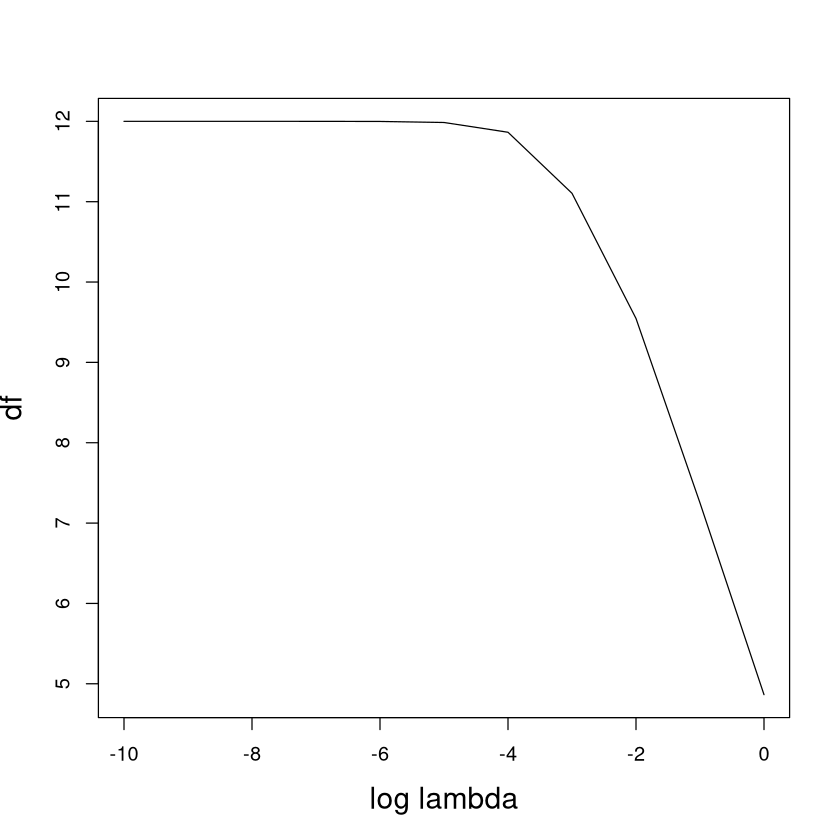

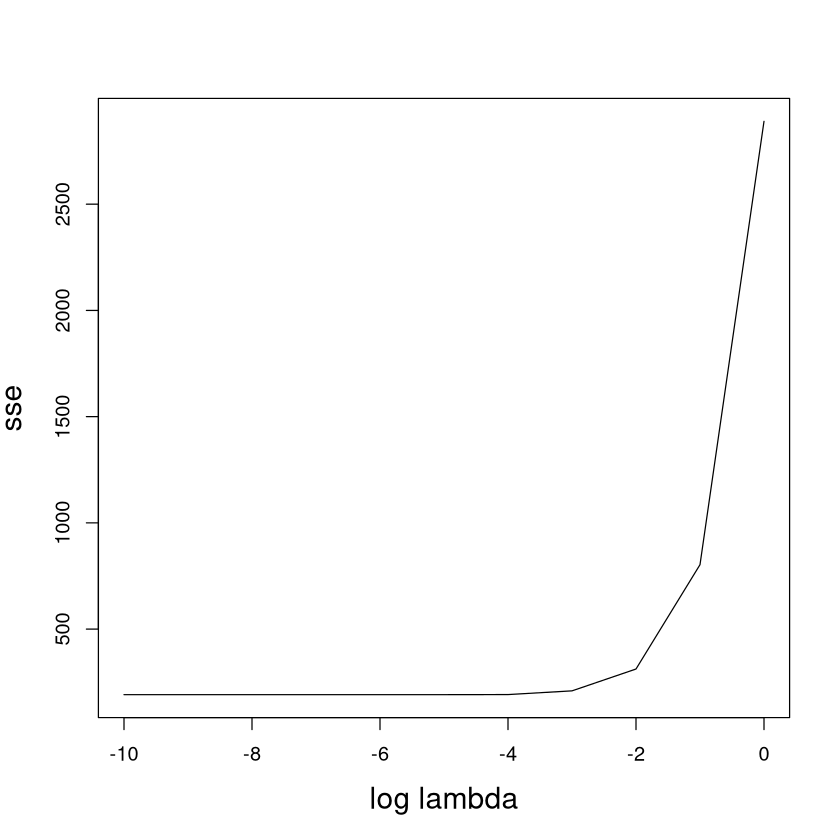

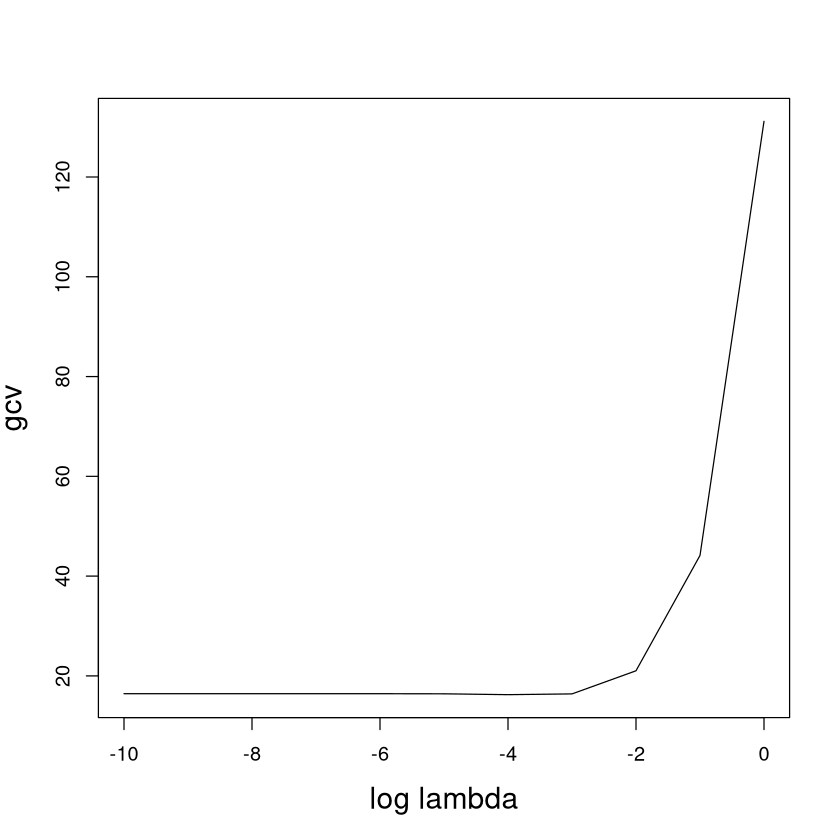

In [14]:
# And we’ll plot some results

plot(-10:0, df[1:11], type='l', xlab='log lambda', ylab='df', cex.lab=1.5)
plot(-10:0, sse[1:11], type='l', xlab='log lambda', ylab='sse', cex.lab=1.5)
plot(-10:0, gcv[1:11], type='l', xlab='log lambda', ylab='gcv', cex.lab=1.5)


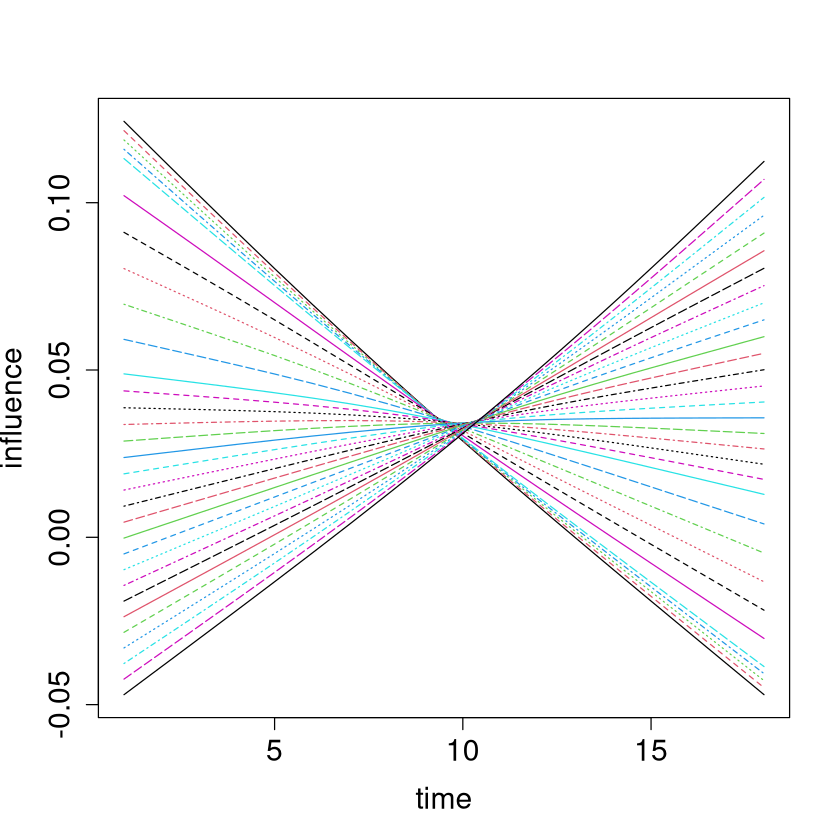

In [15]:
# Let’s look at some influence functions

y2cMap = syfd$y2cMap
bvals = eval.basis(age, heightbasis12)
hatMat = bvals%*%y2cMap

matplot(age, hatMat, type='l', xlab='time', ylab='influence', 
        cex.lab=1.5, cex.axis=1.5)

Multiple plots:  Click in the plot to advance to the next plot


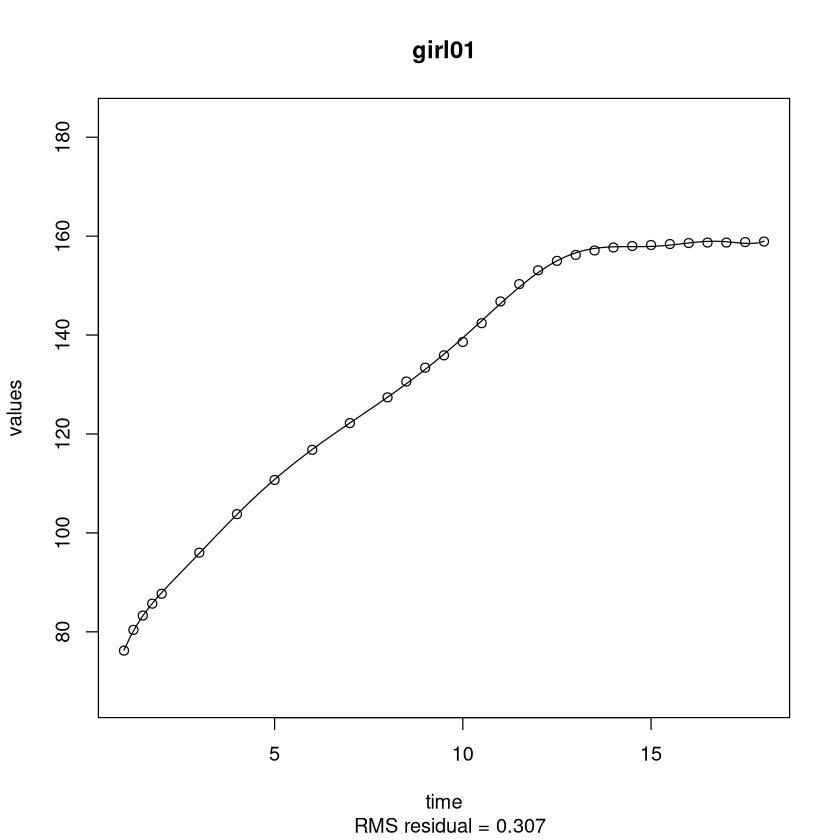

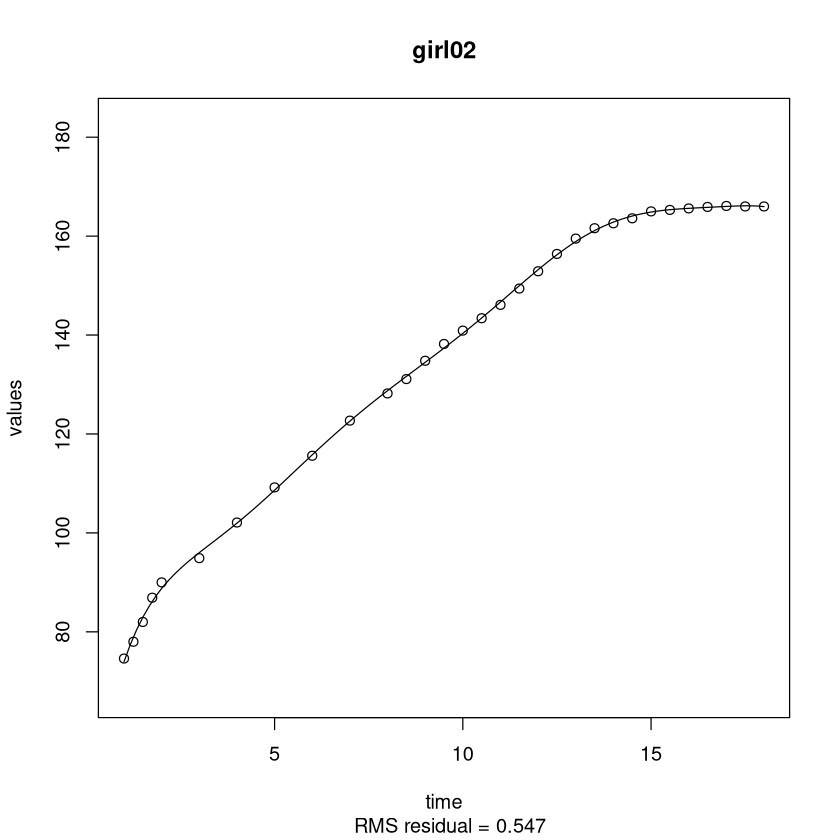

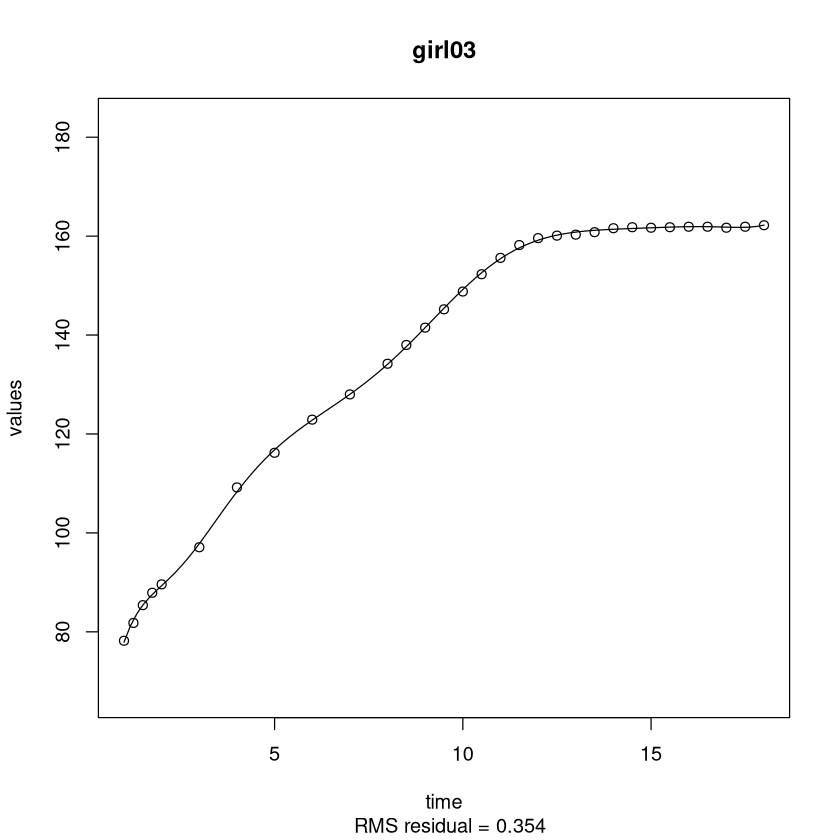

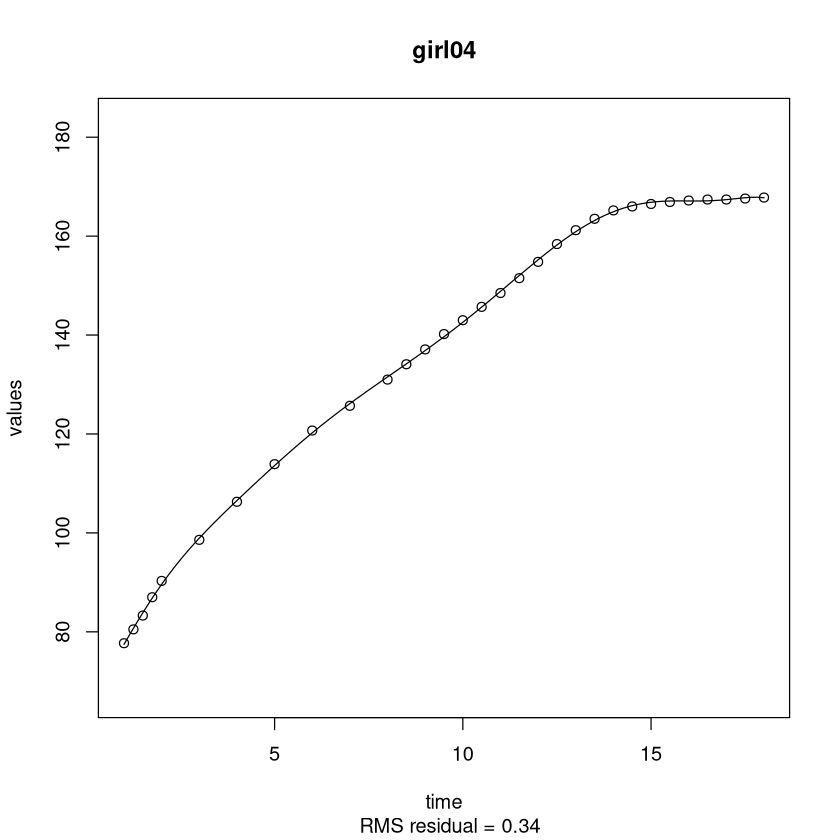

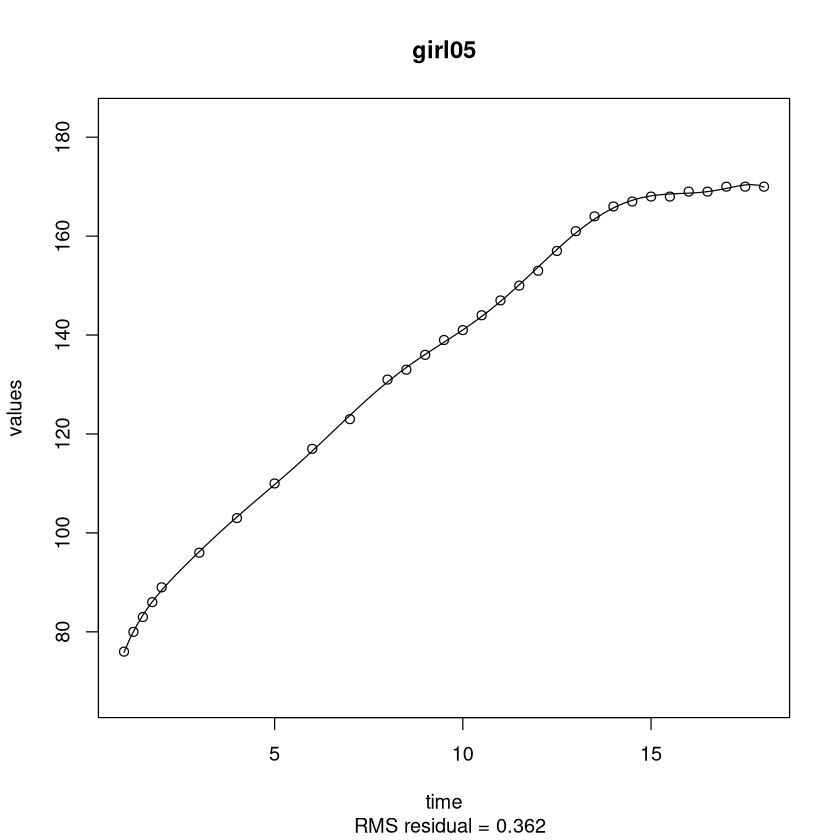

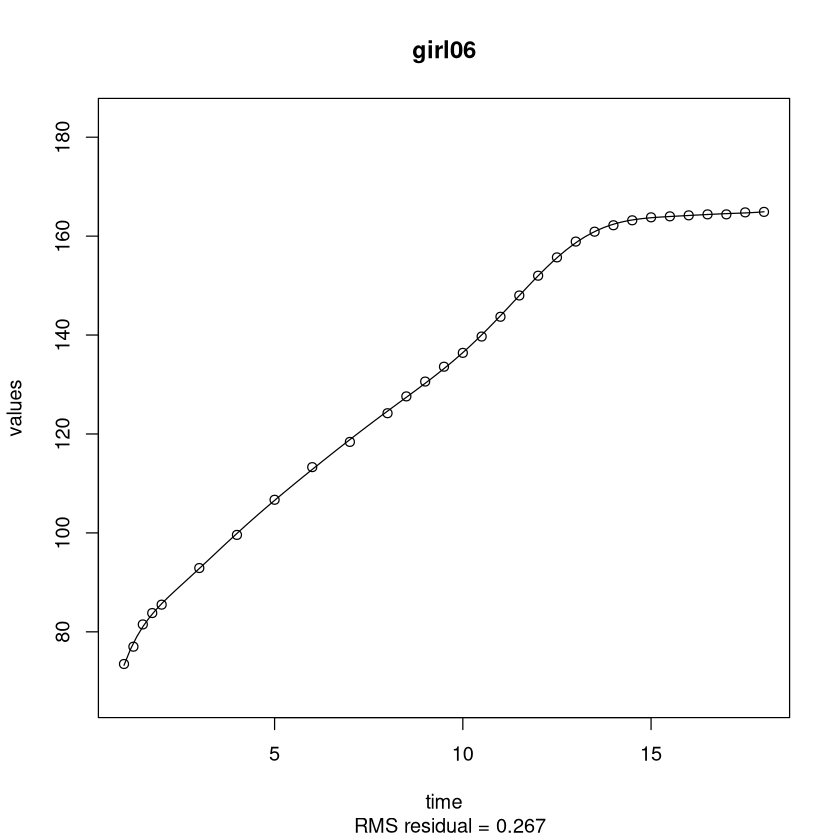

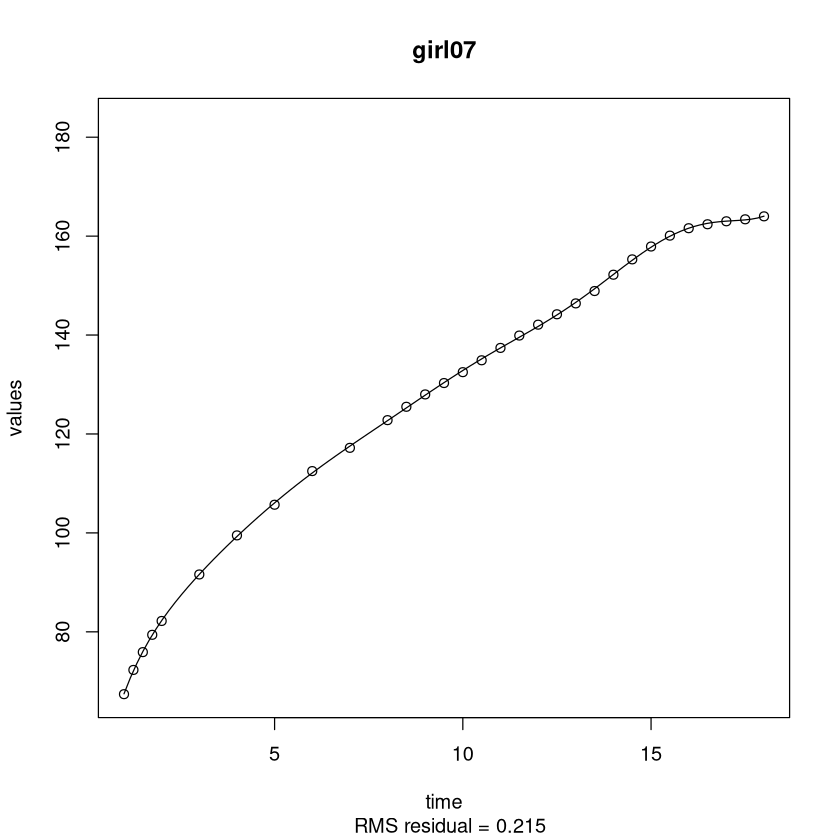

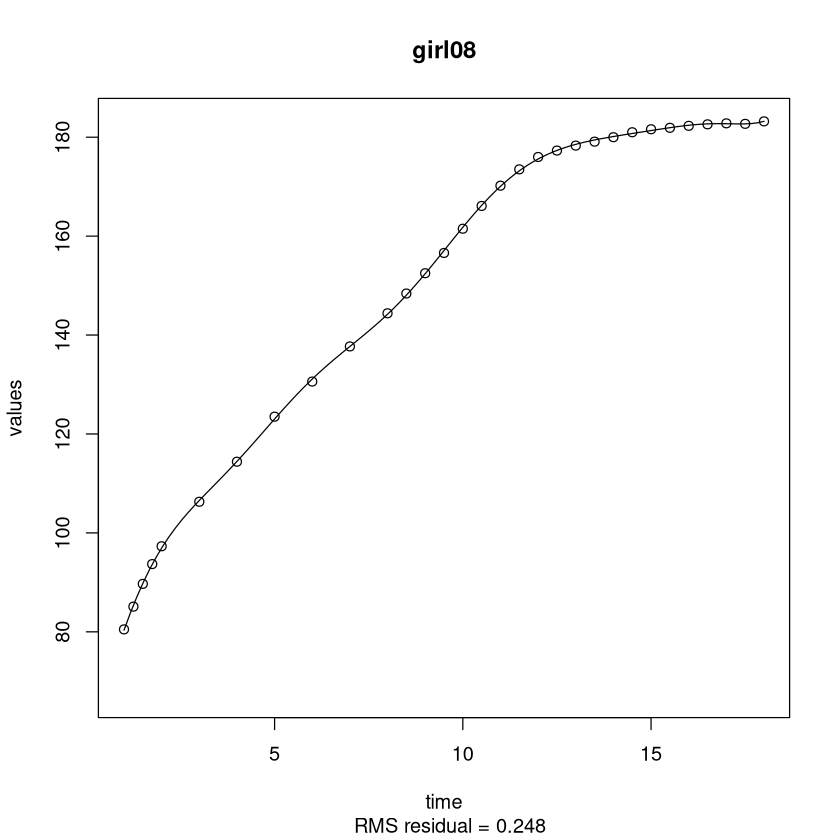

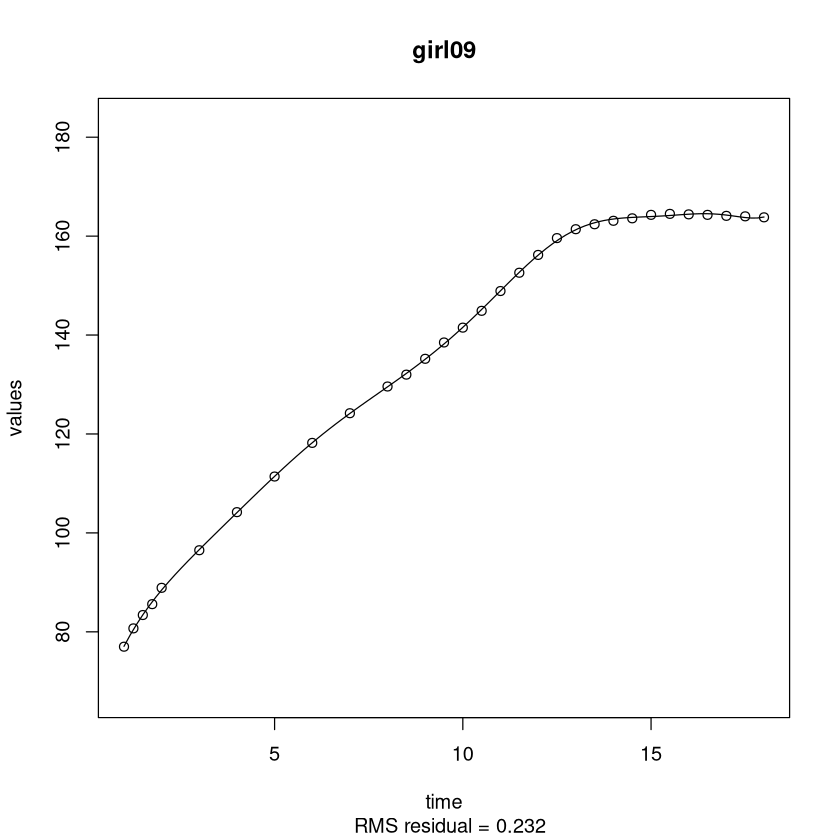

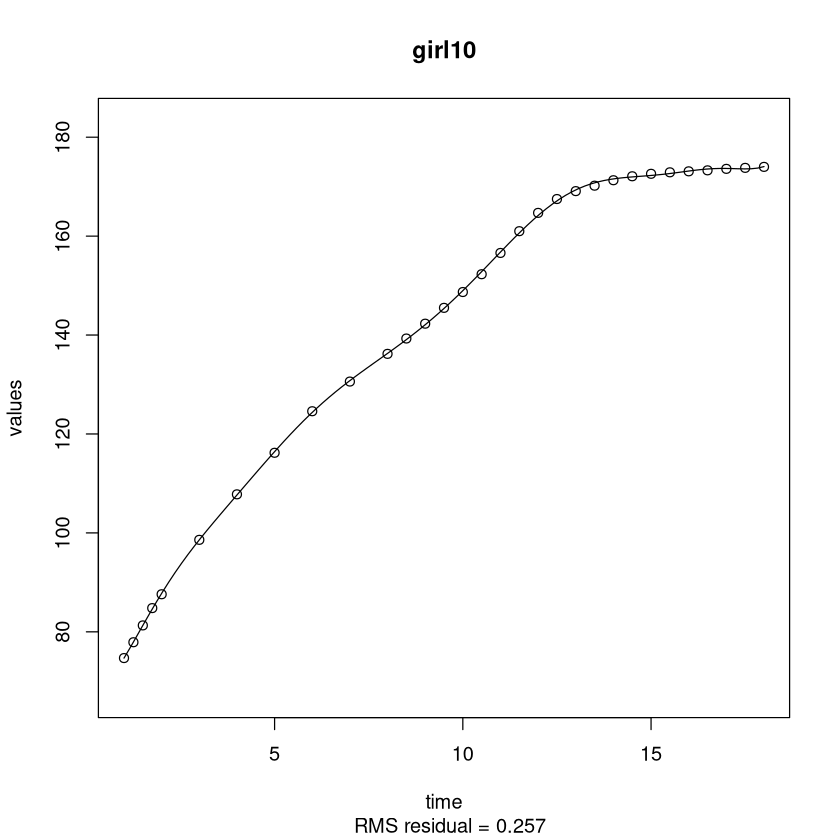

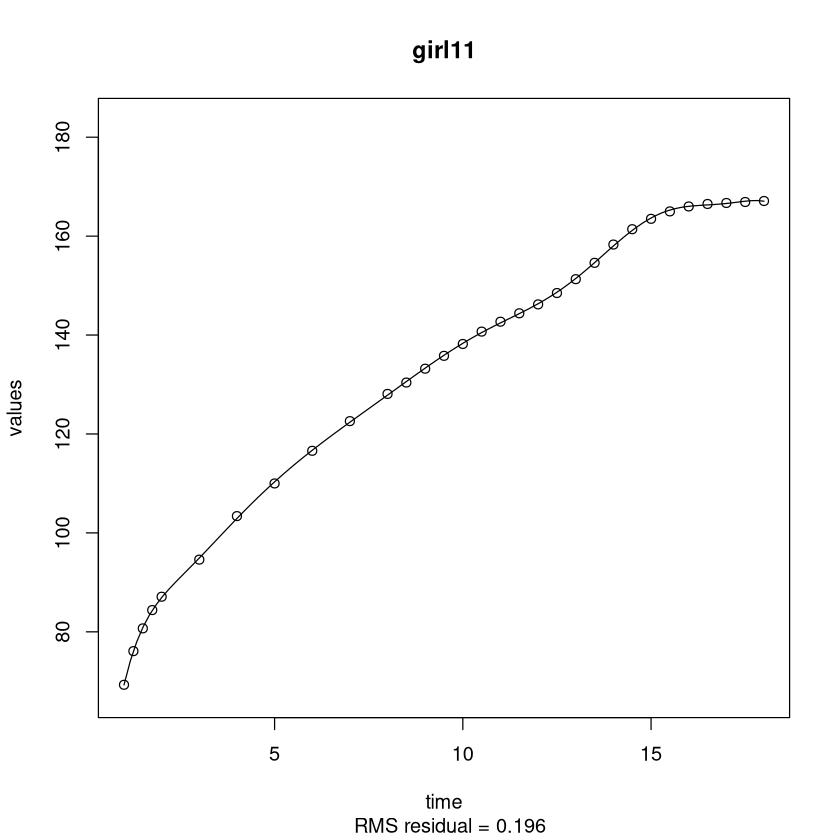

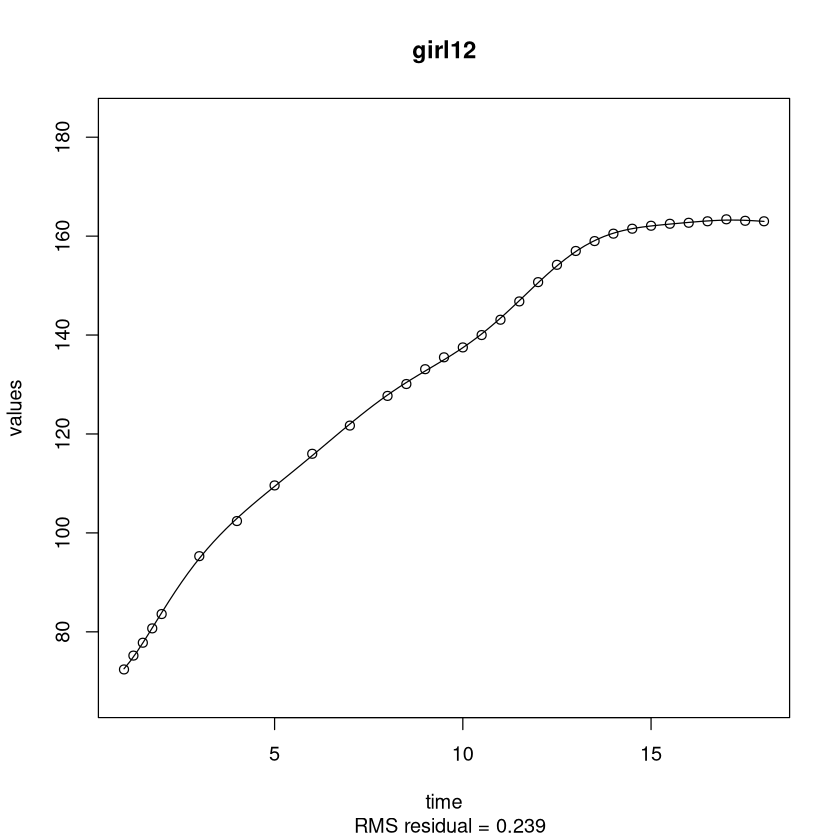

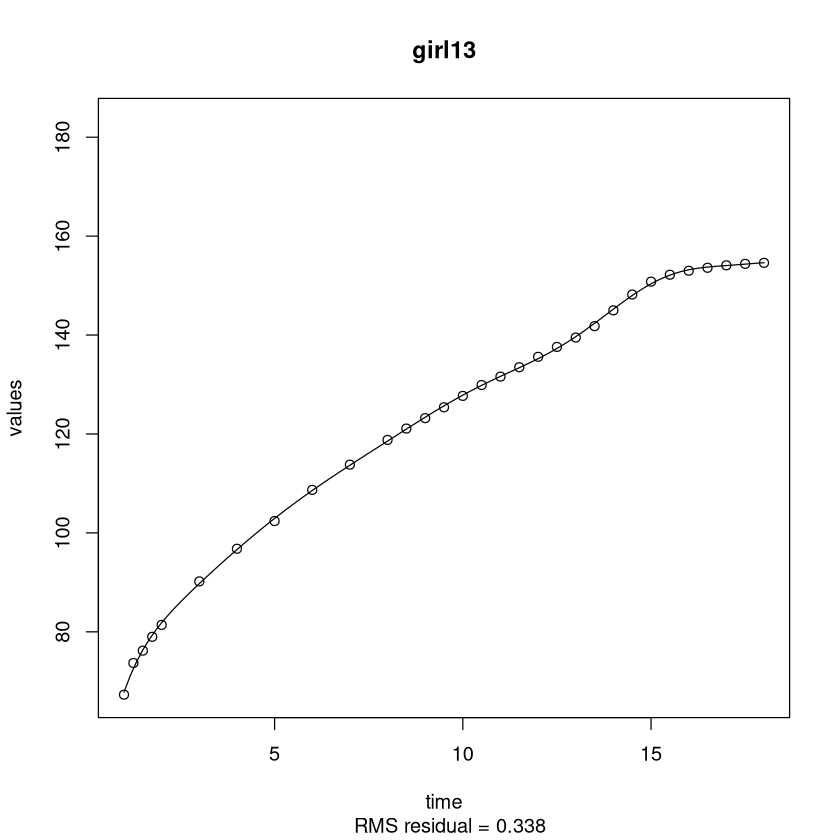

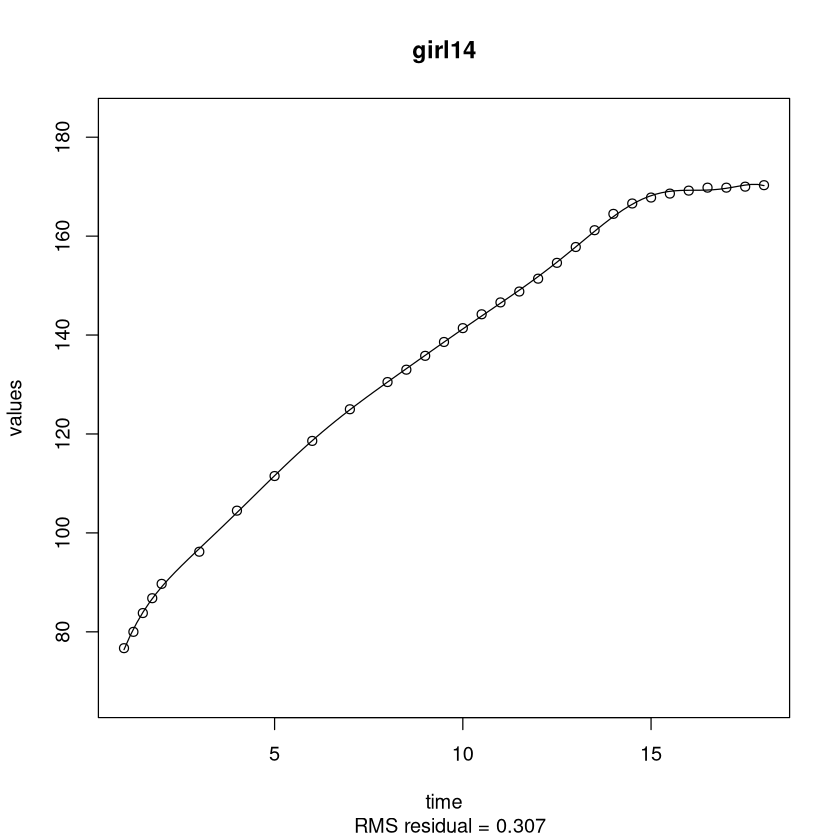

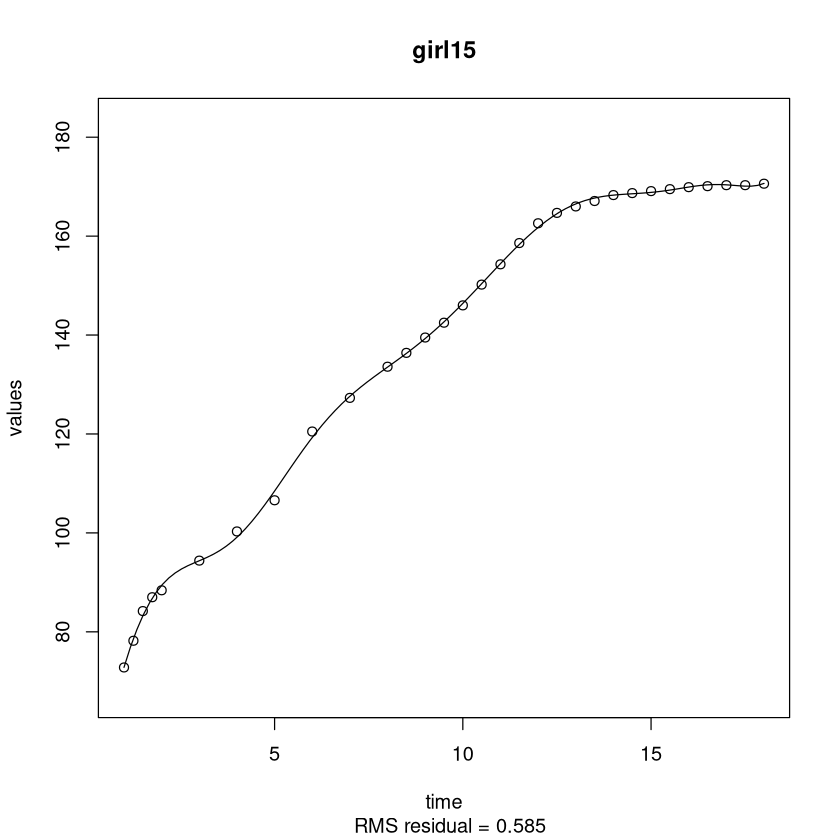

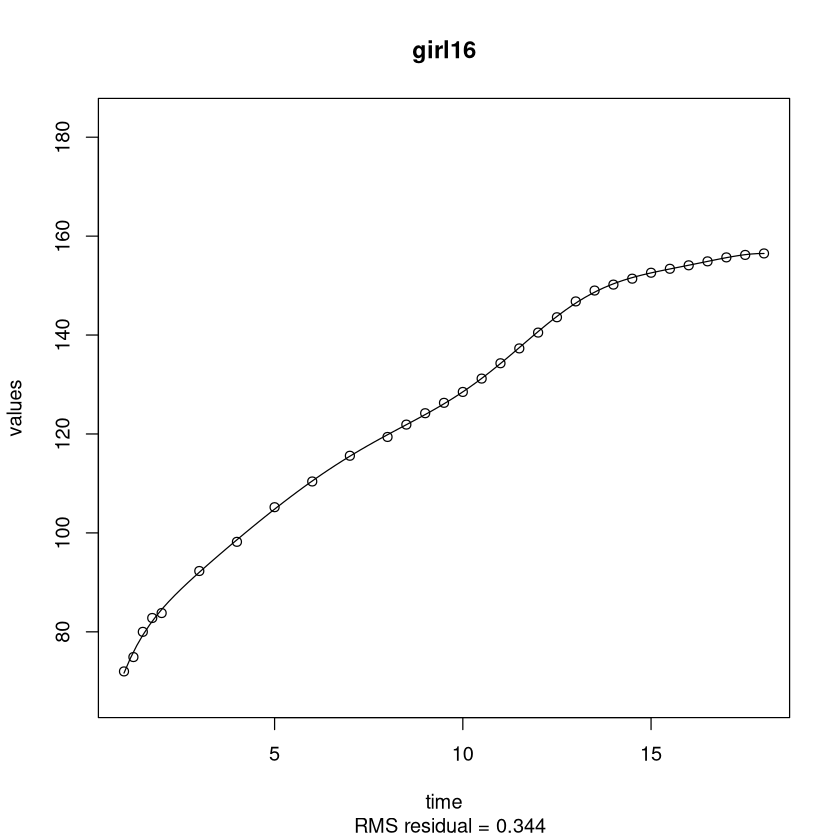

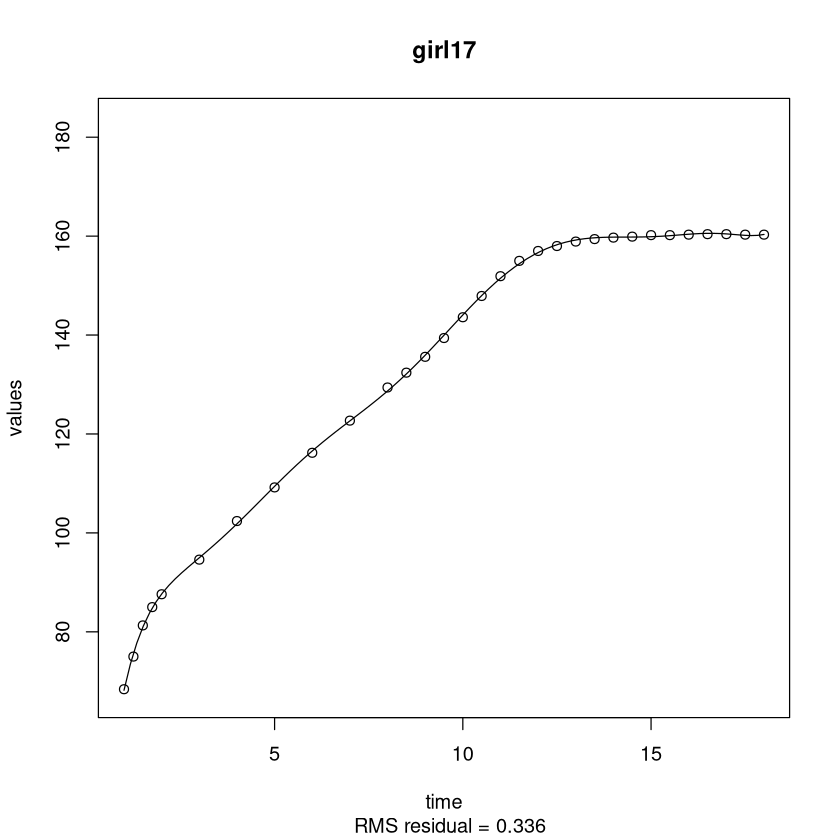

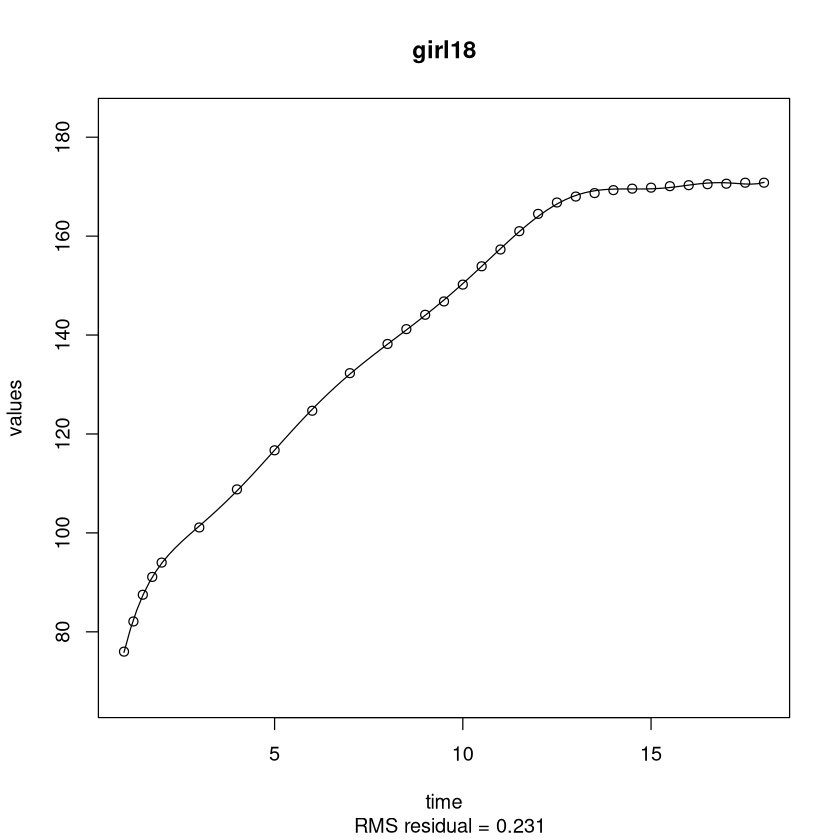

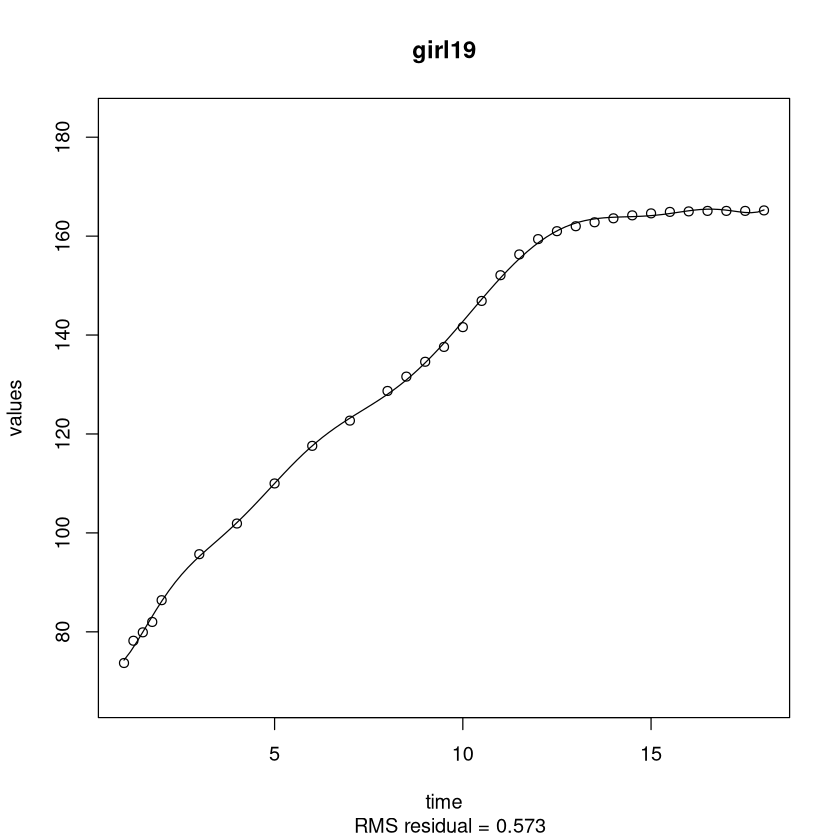

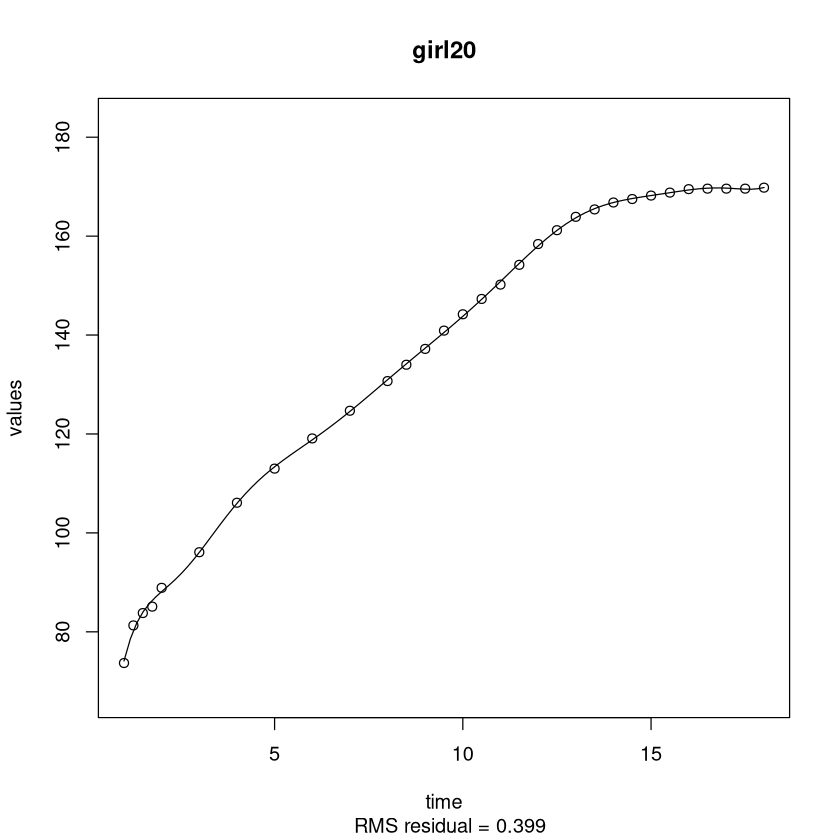

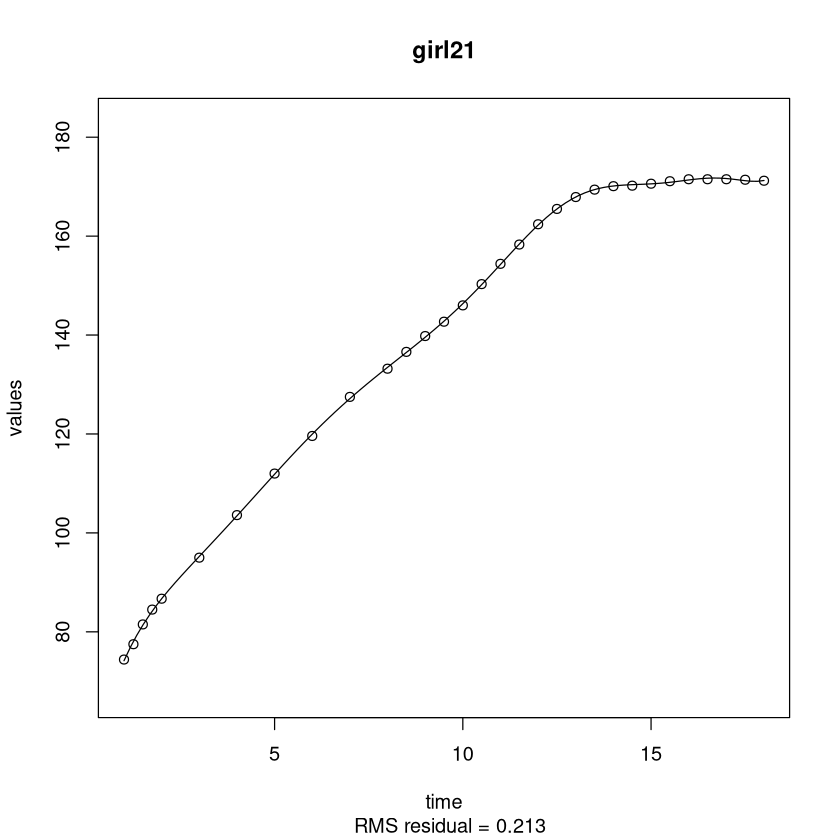

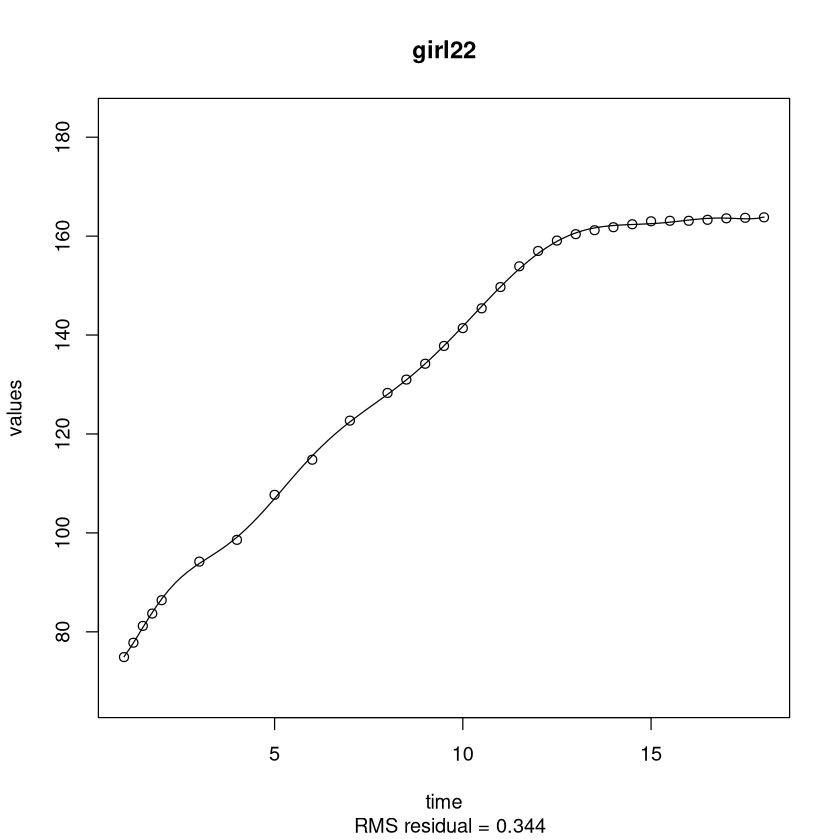

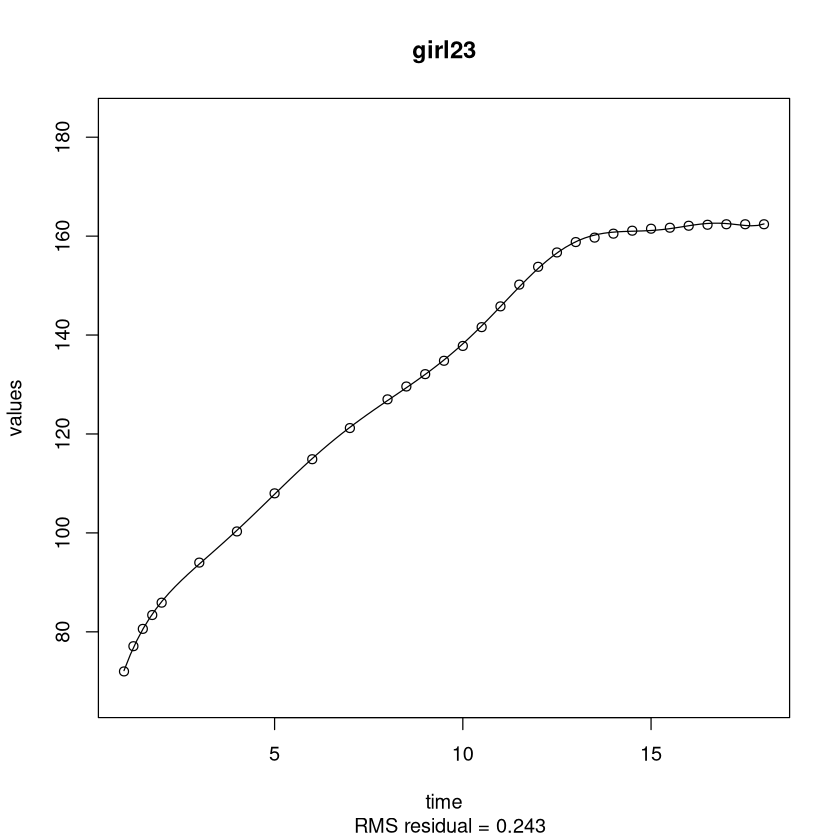

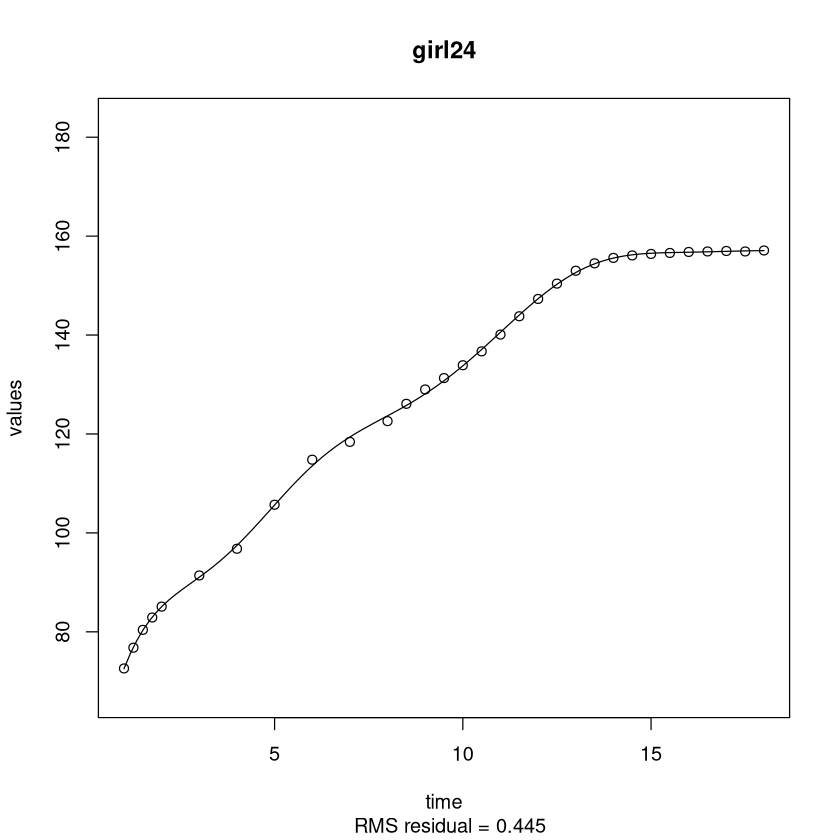

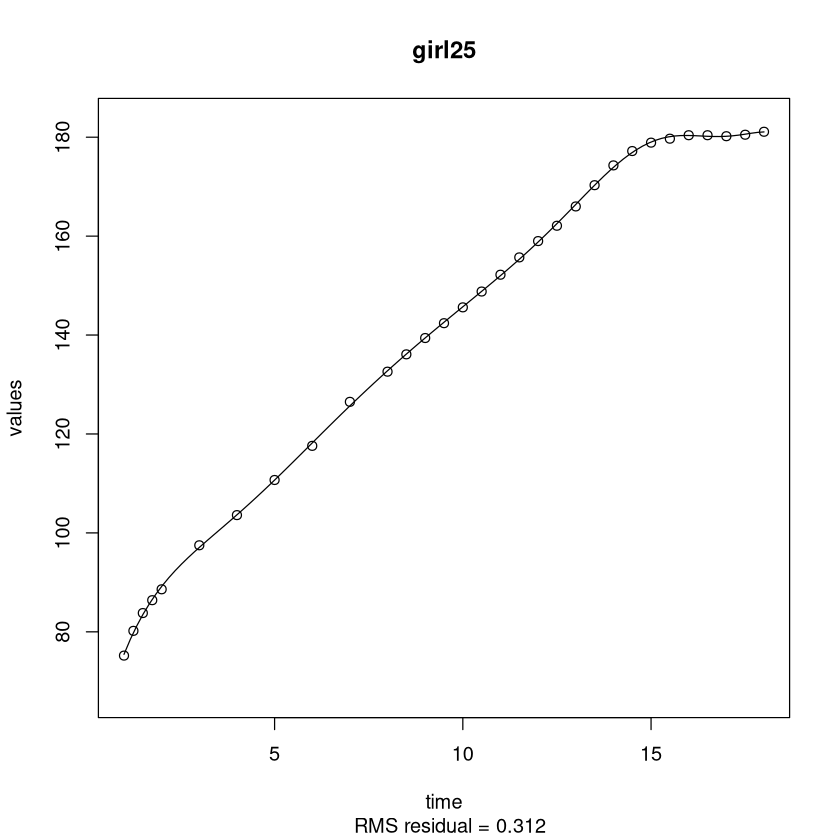

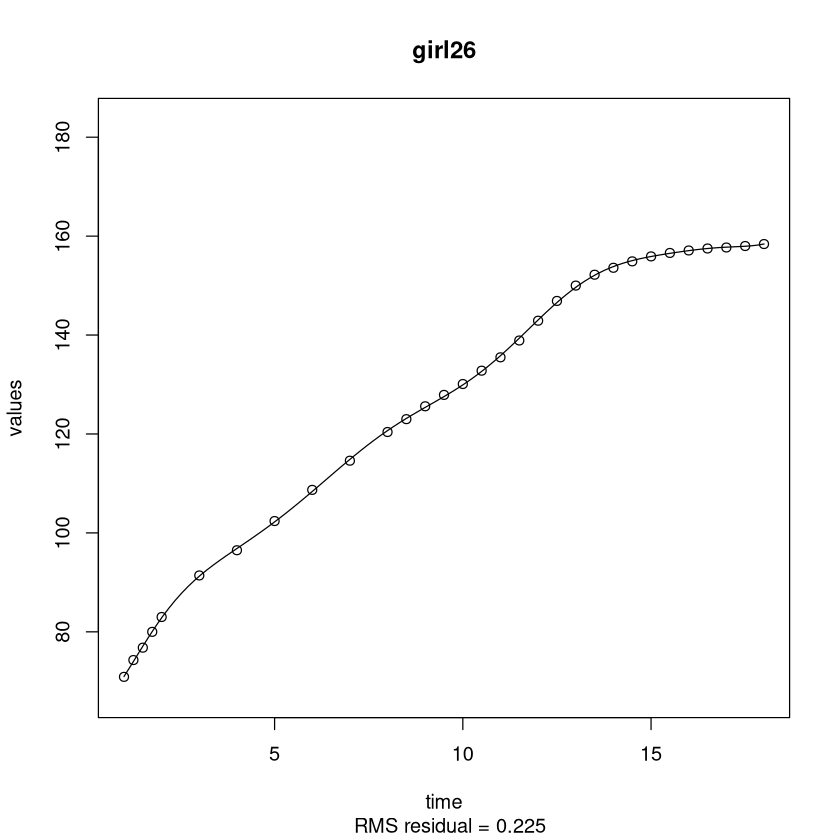

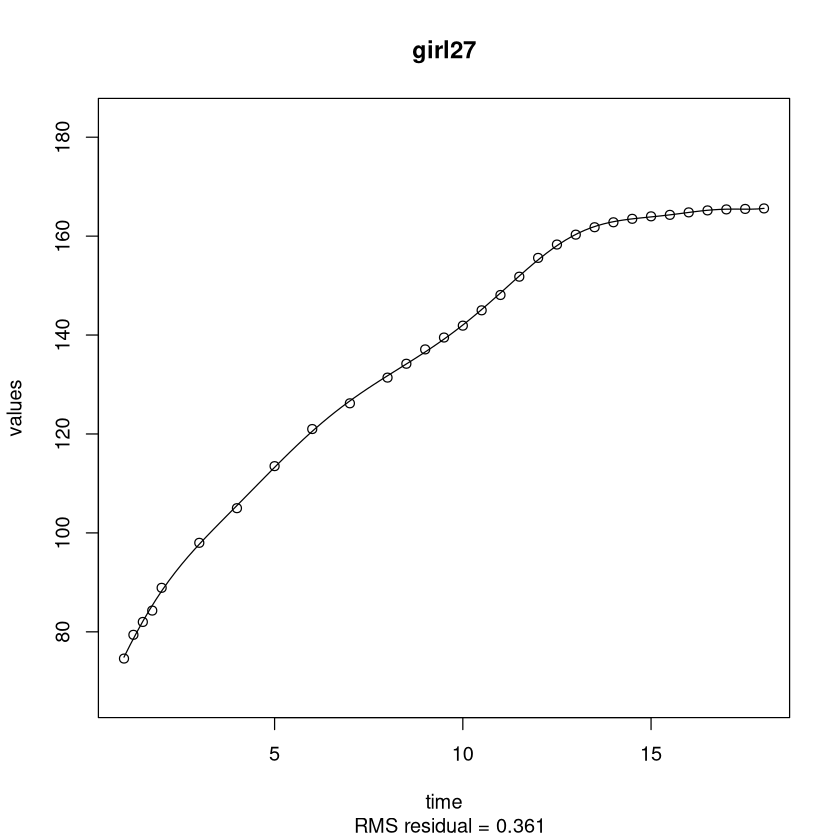

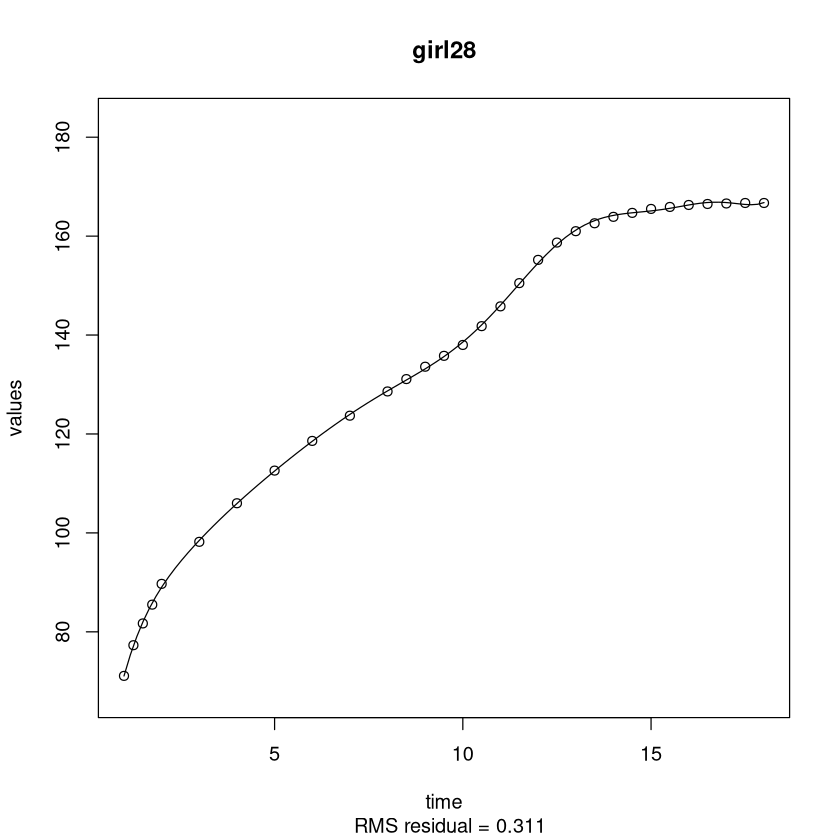

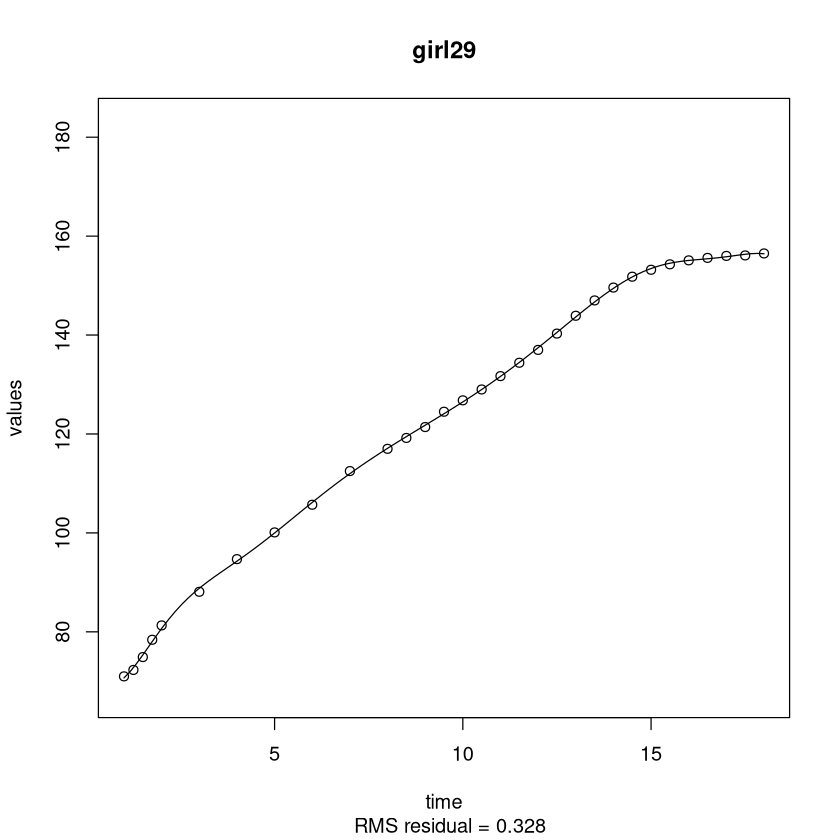

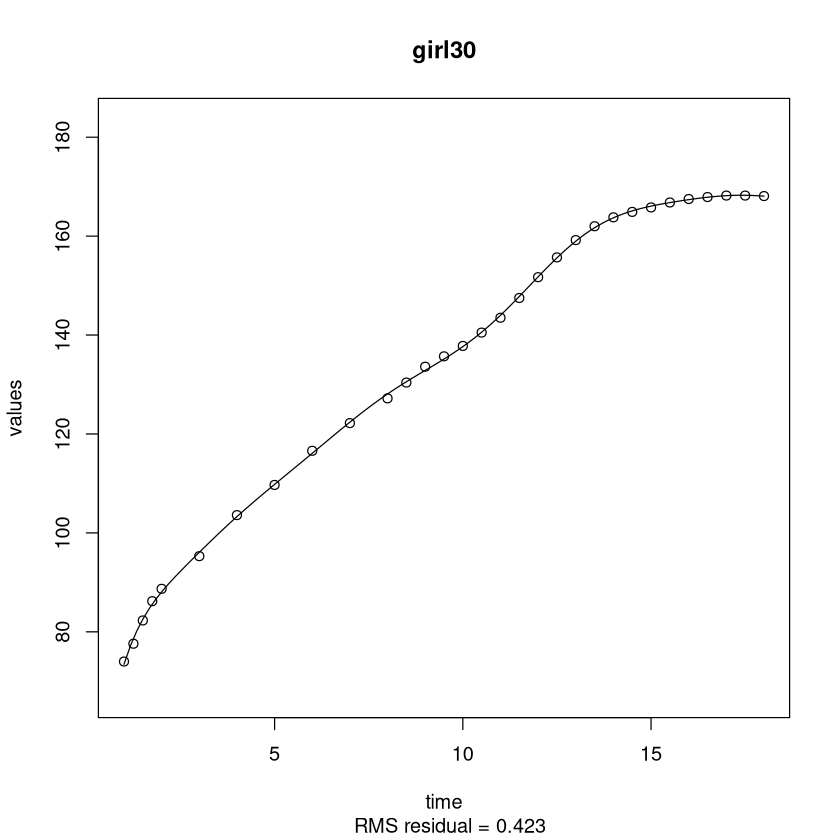

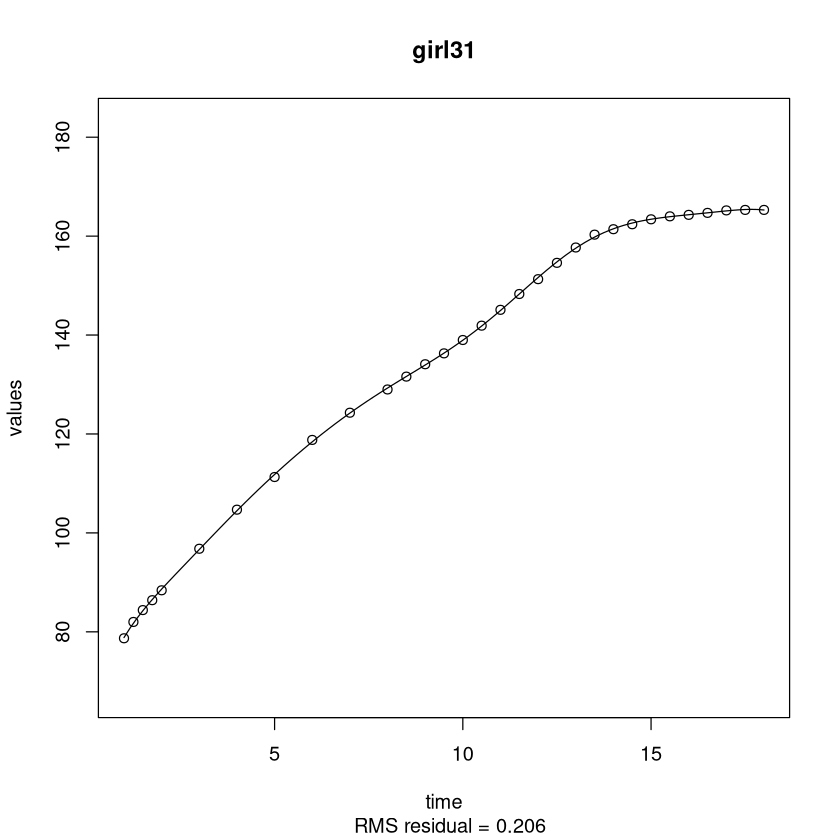

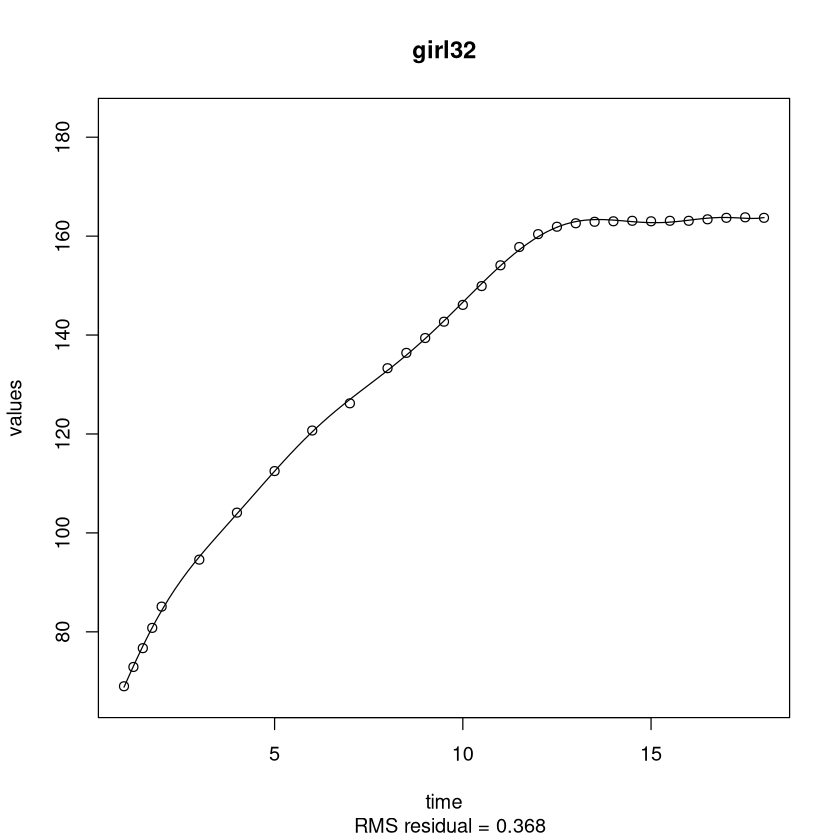

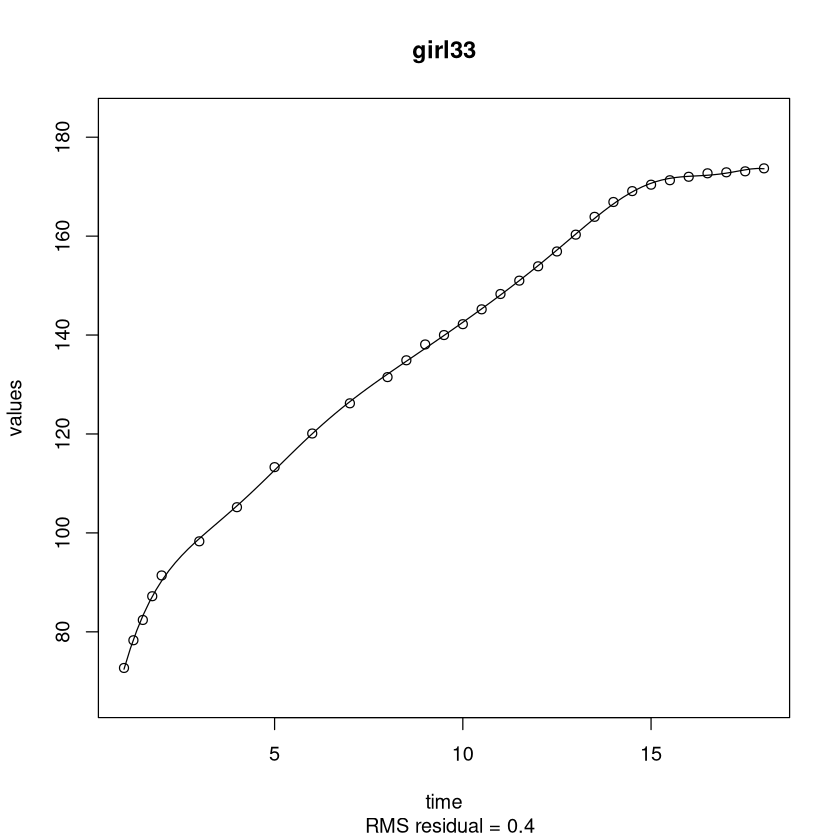

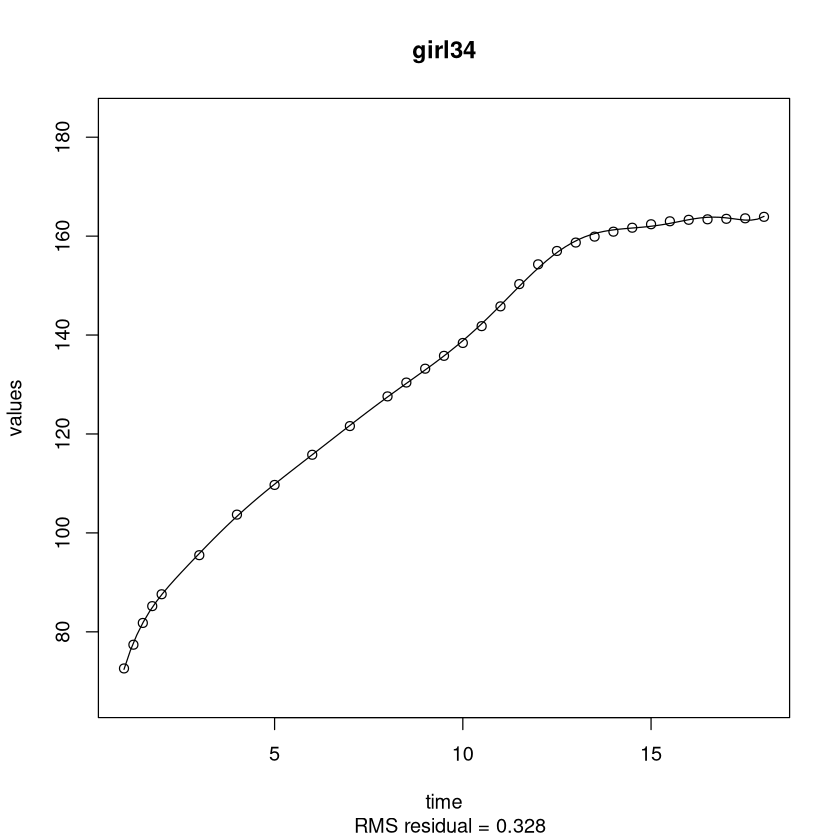

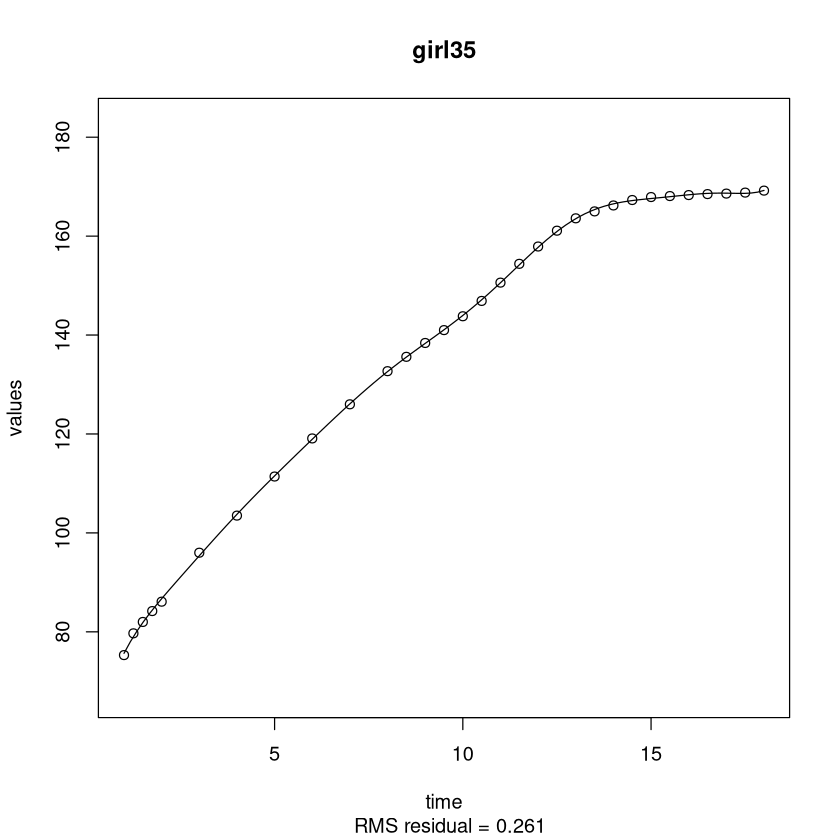

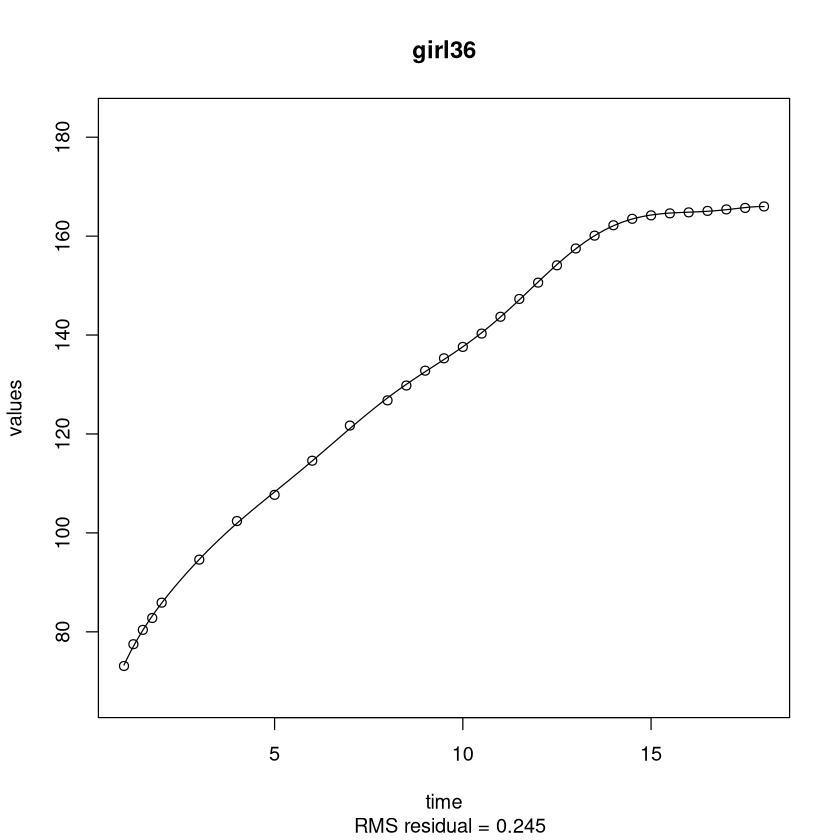

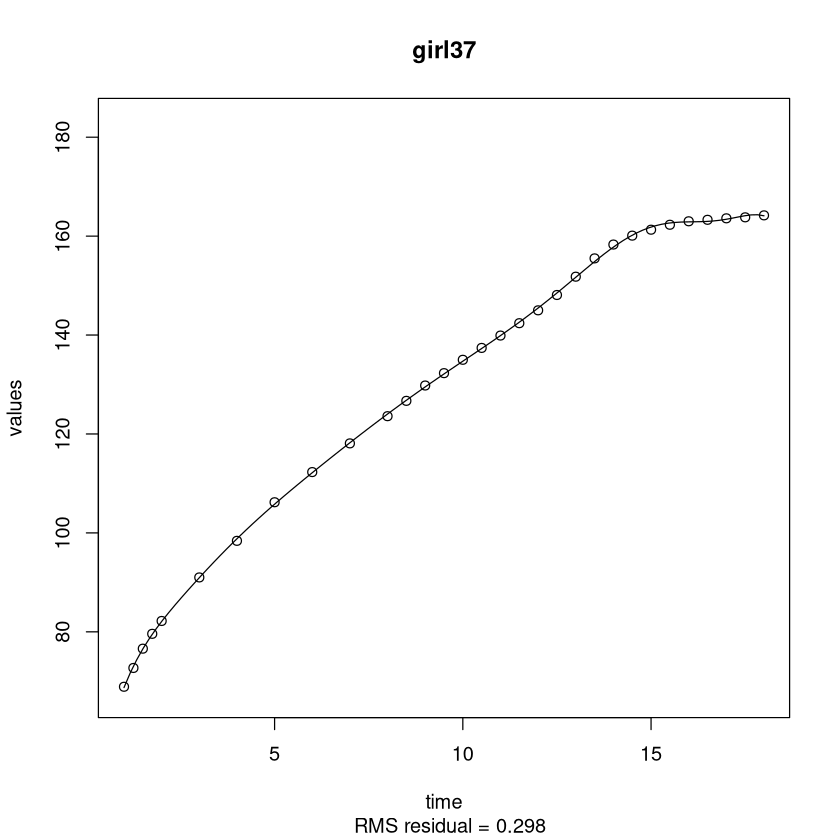

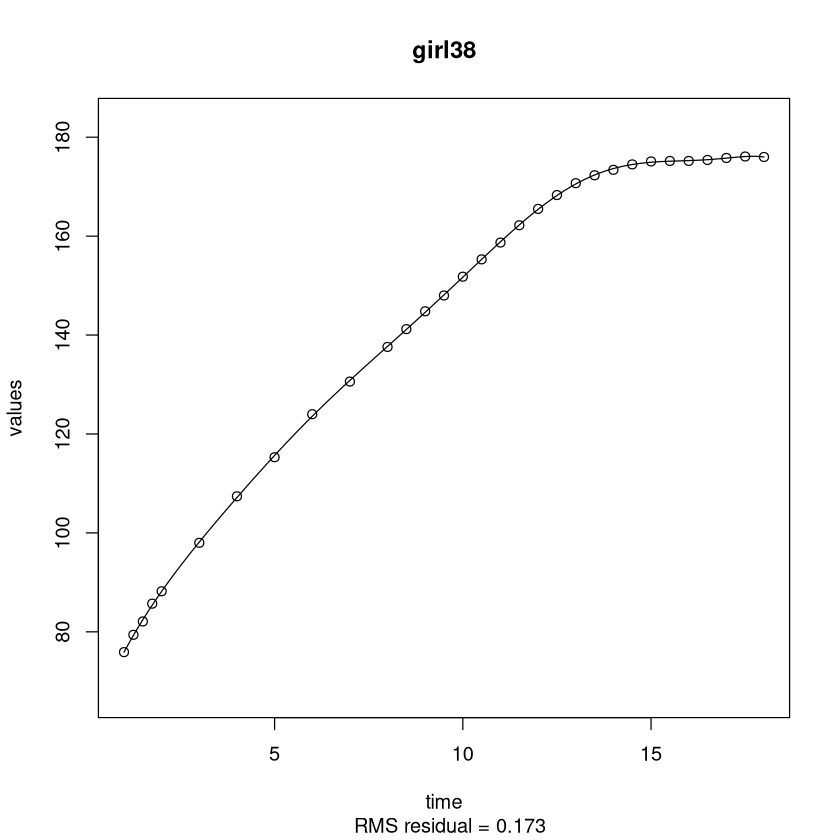

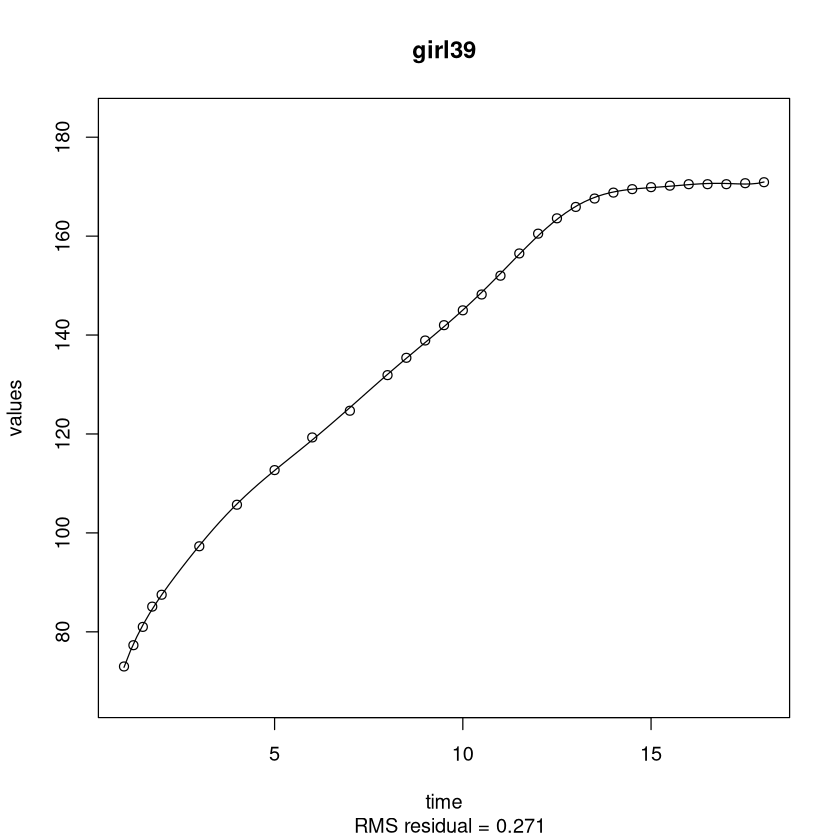

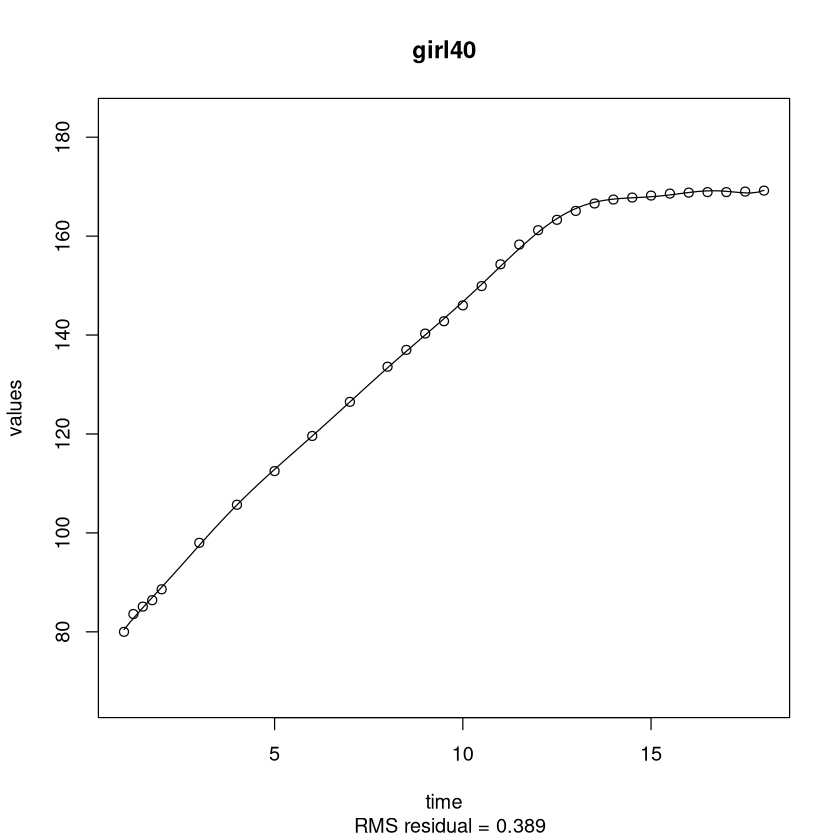

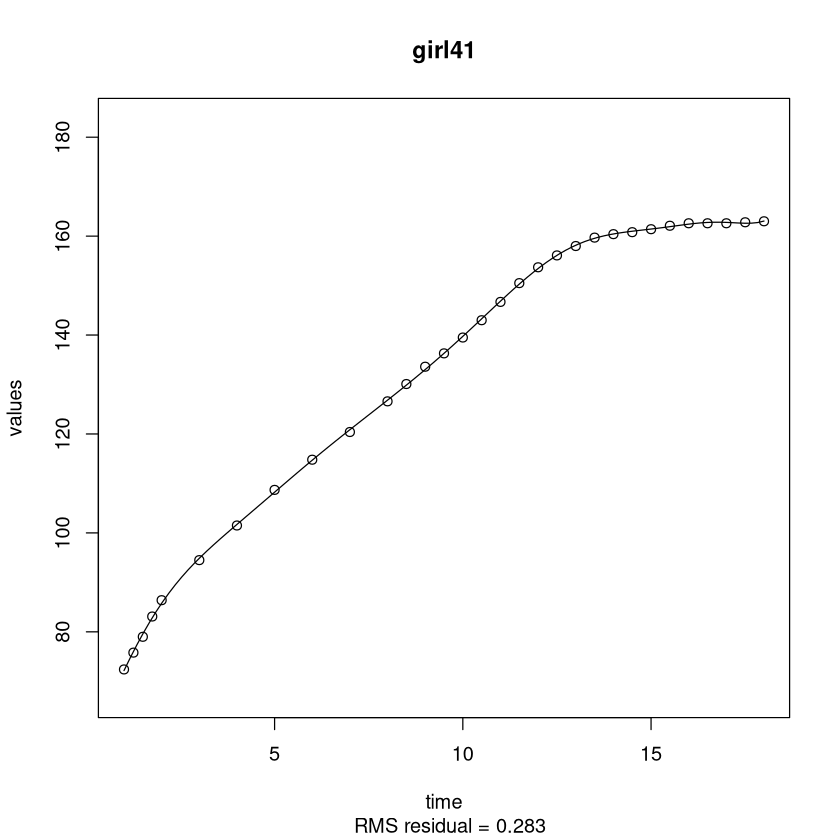

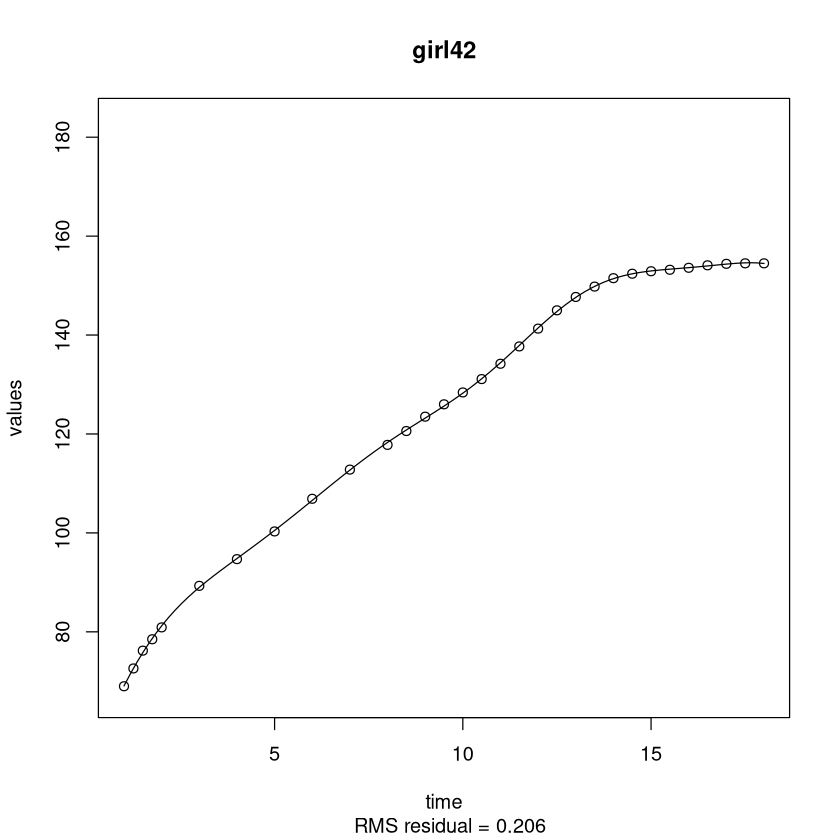

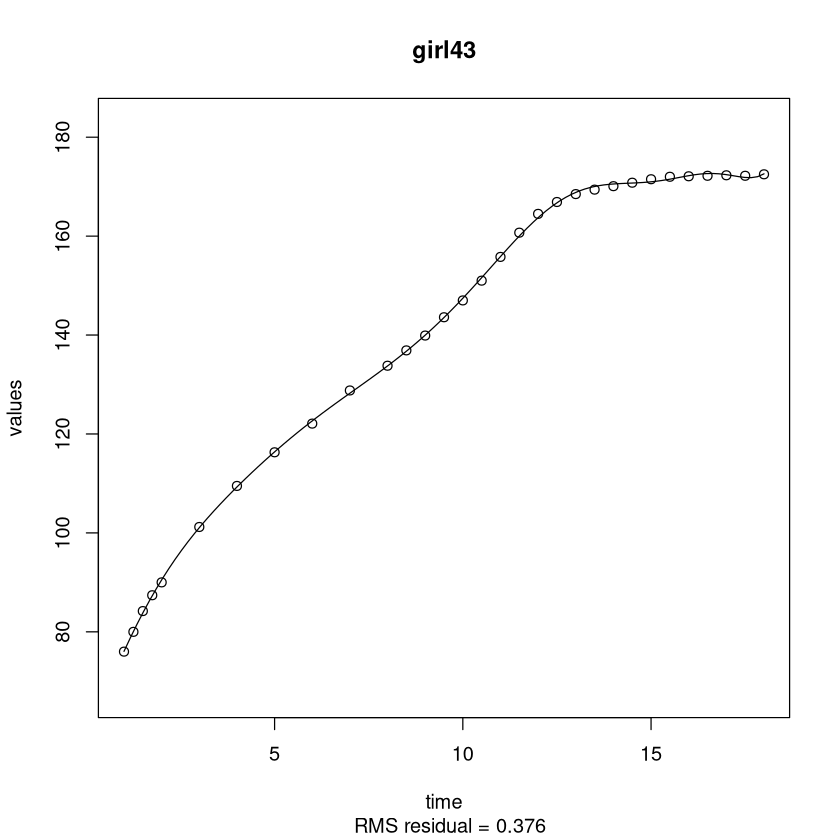

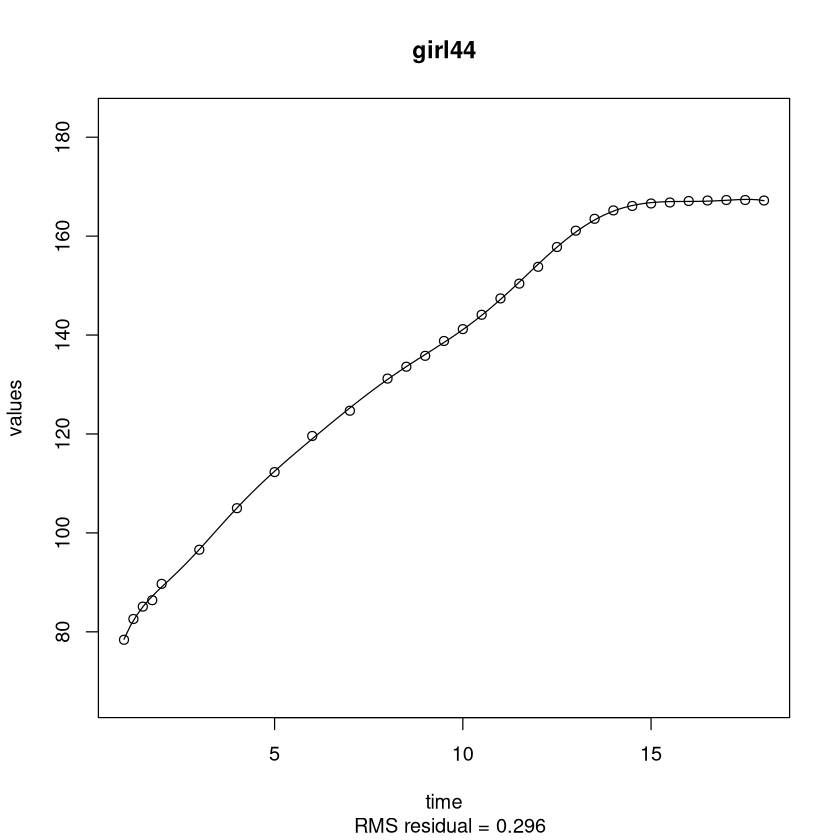

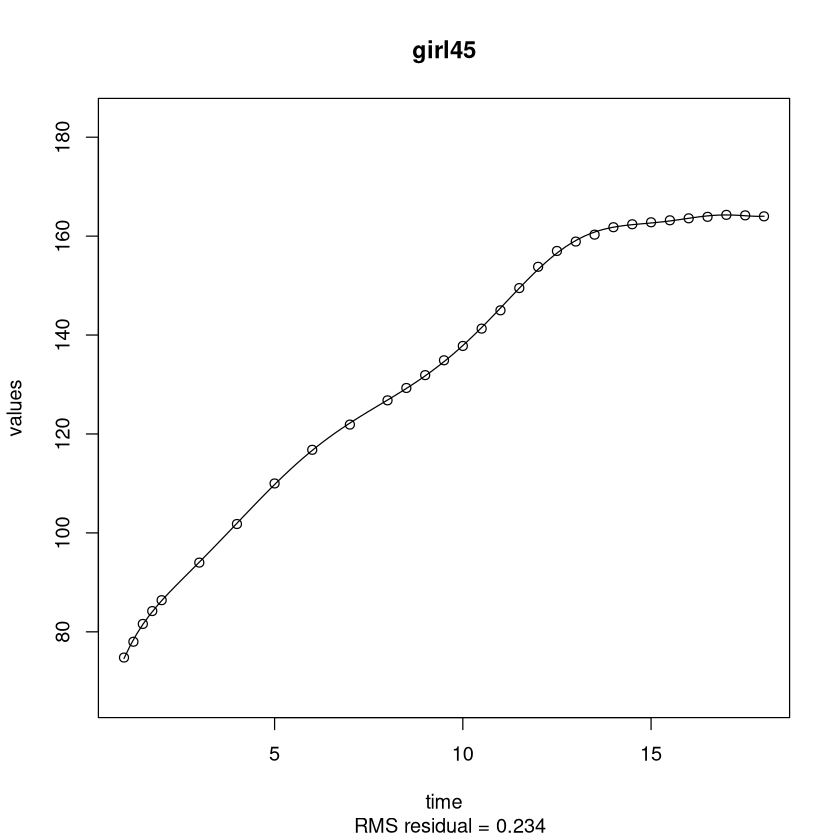

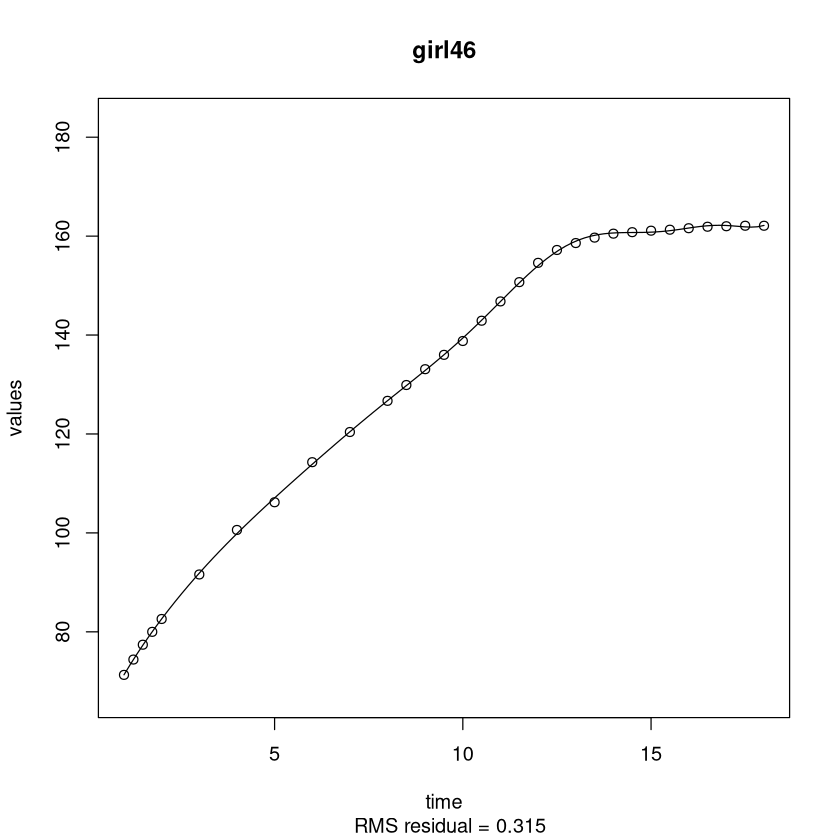

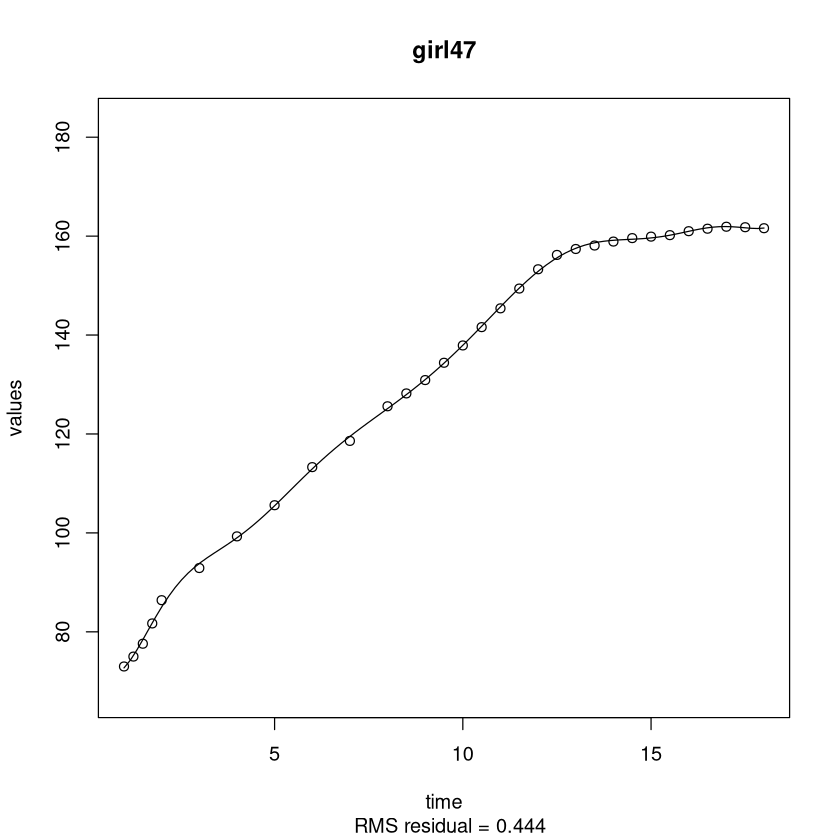

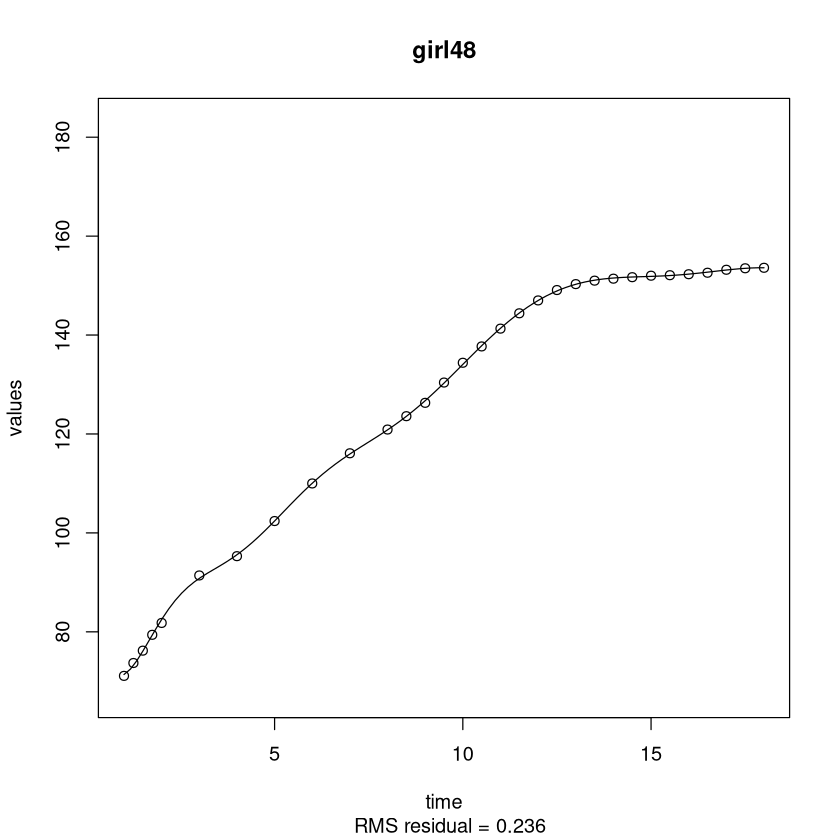

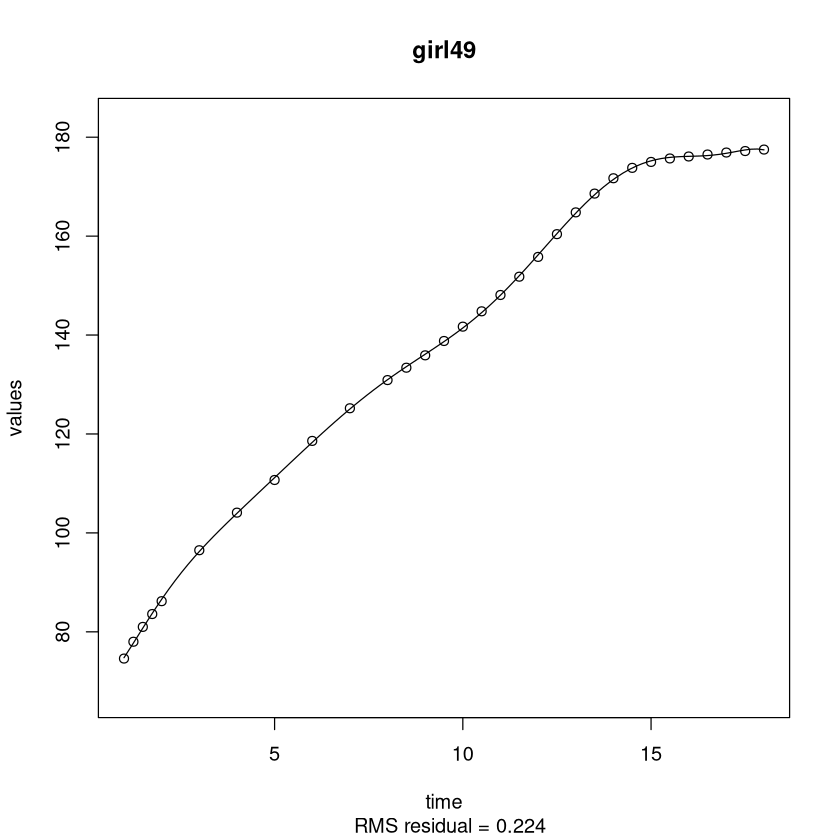

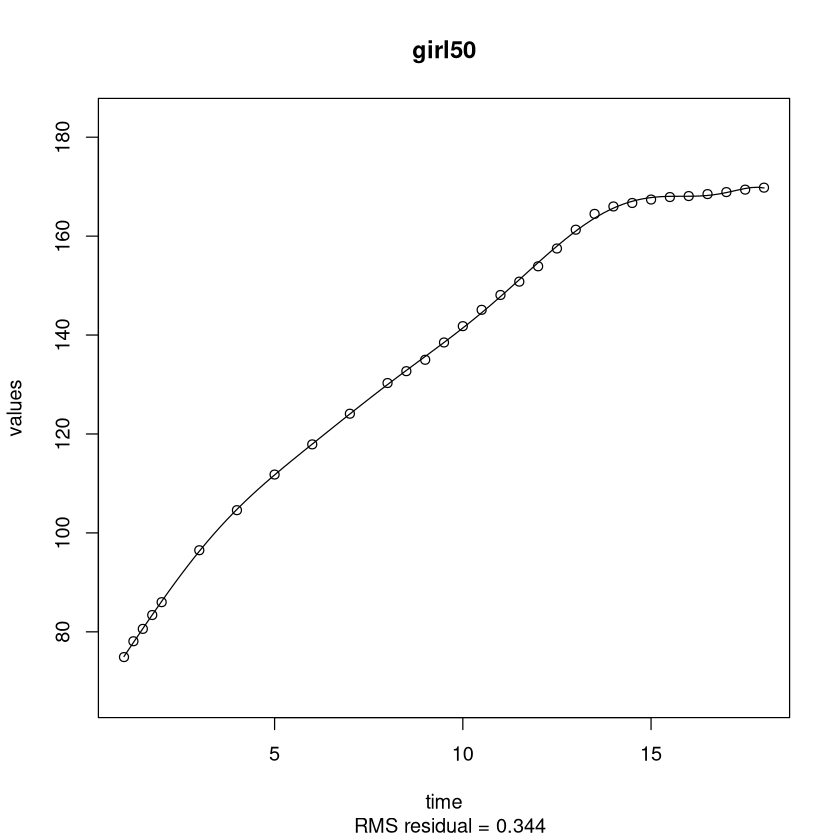

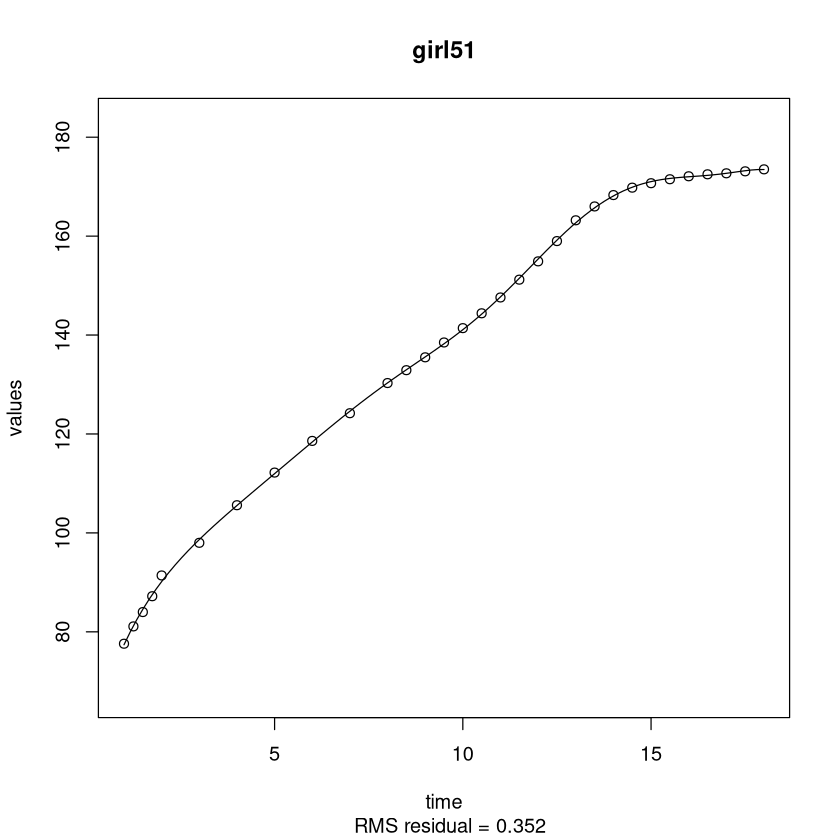

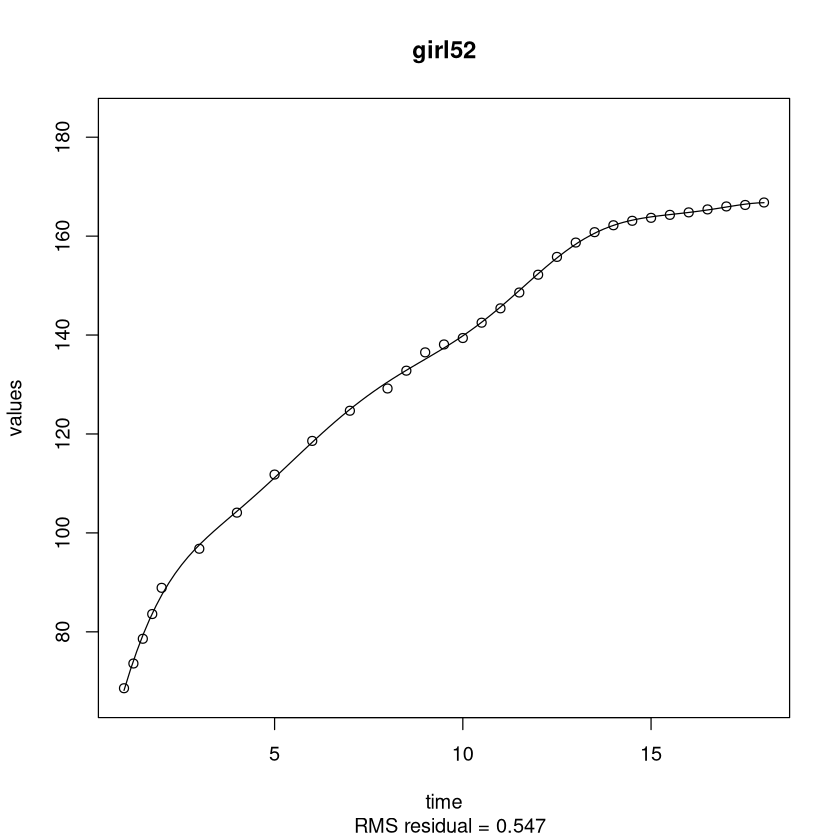

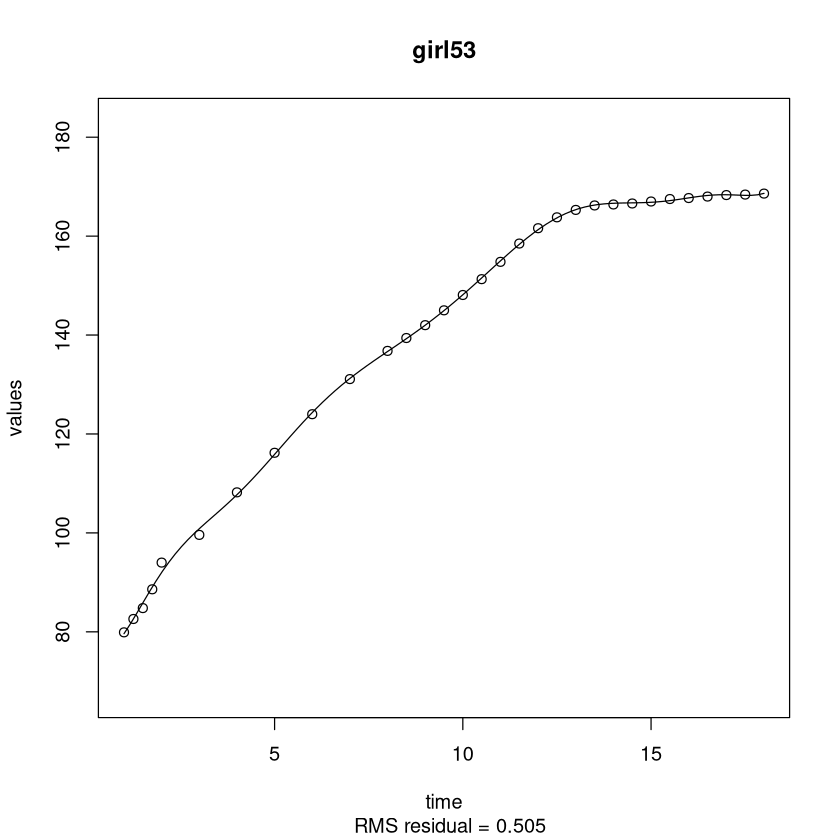

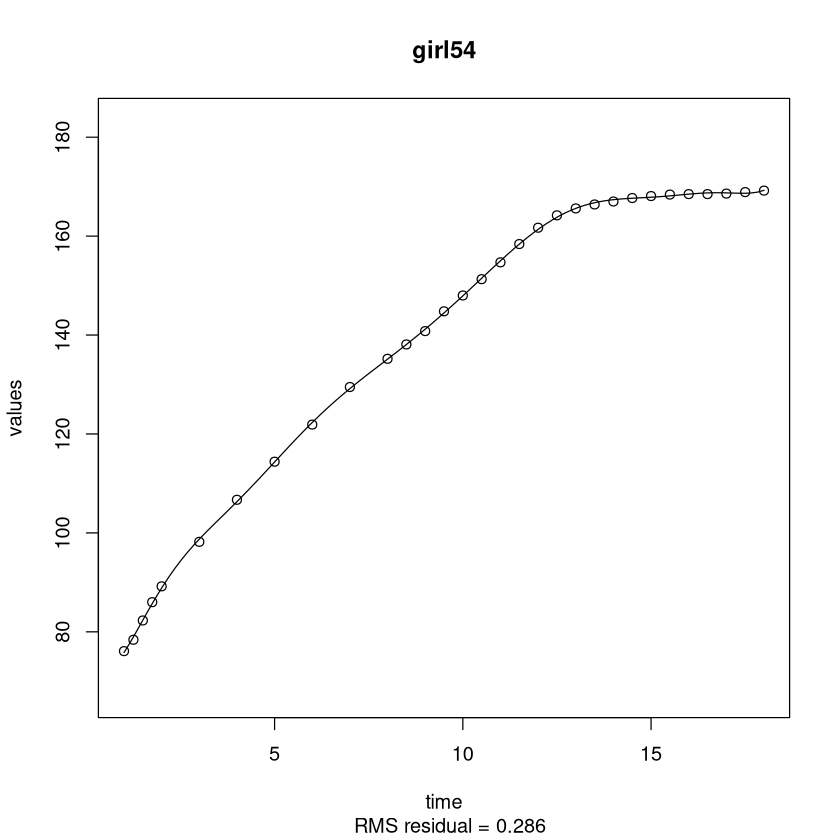

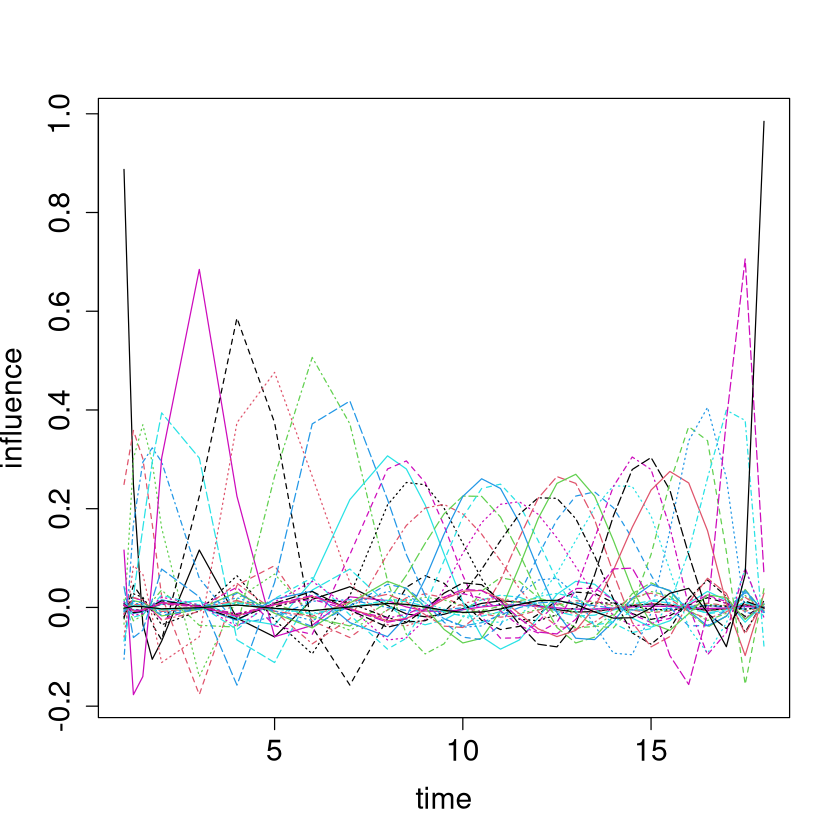

In [16]:
# We’ll do the same thing with a very small lambda

D2fdPar1 = fdPar(heightbasis12, Lfdobj=int2Lfd(2), lambda=1e-6)
syfd1 = smooth.basis(age, heightmat, D2fdPar1)
plotfit.fd(heightmat, age, syfd1$fd)

y2cMap1 = syfd1$y2cMap
hatMat1 = bvals%*%y2cMap1

matplot(age, hatMat1, type='l', xlab='time', ylab='influence', 
        cex.lab=1.5, cex.axis=1.5)

Multiple plots:  Click in the plot to advance to the next plot


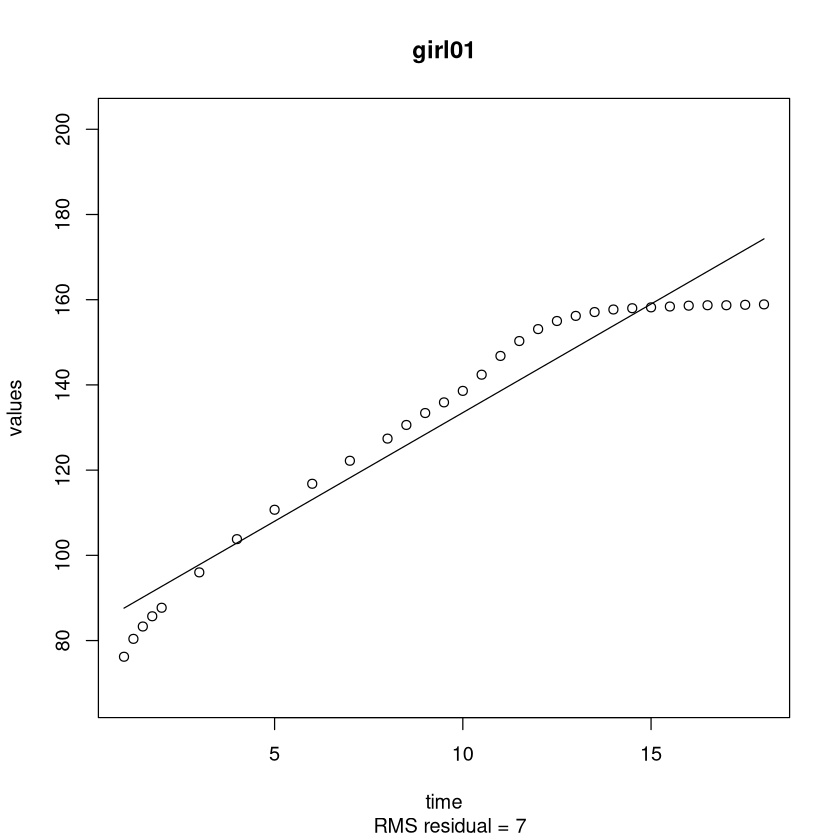

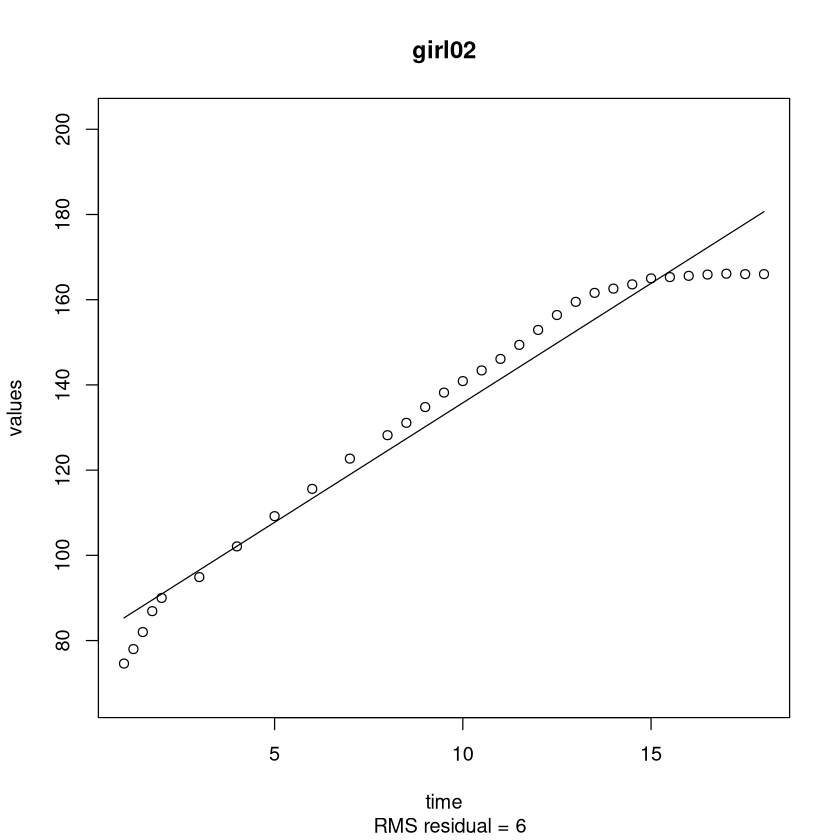

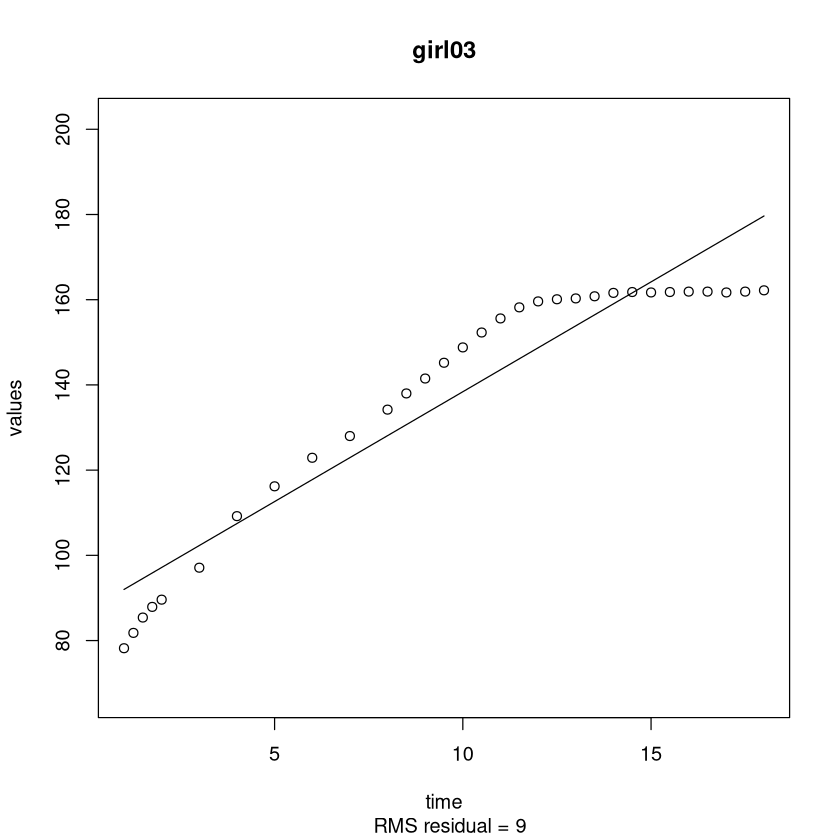

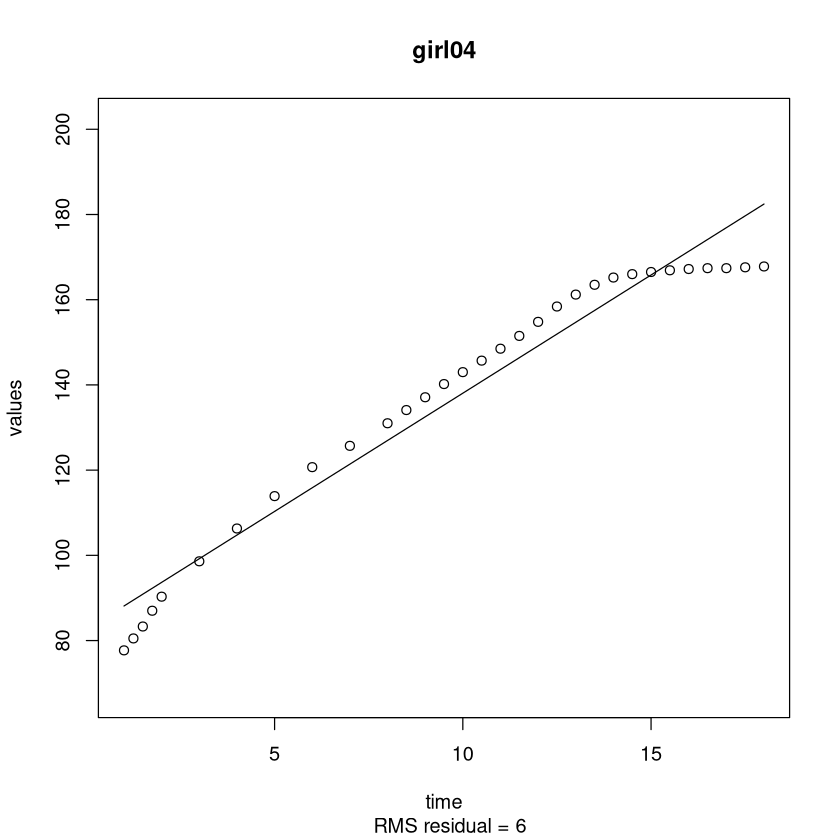

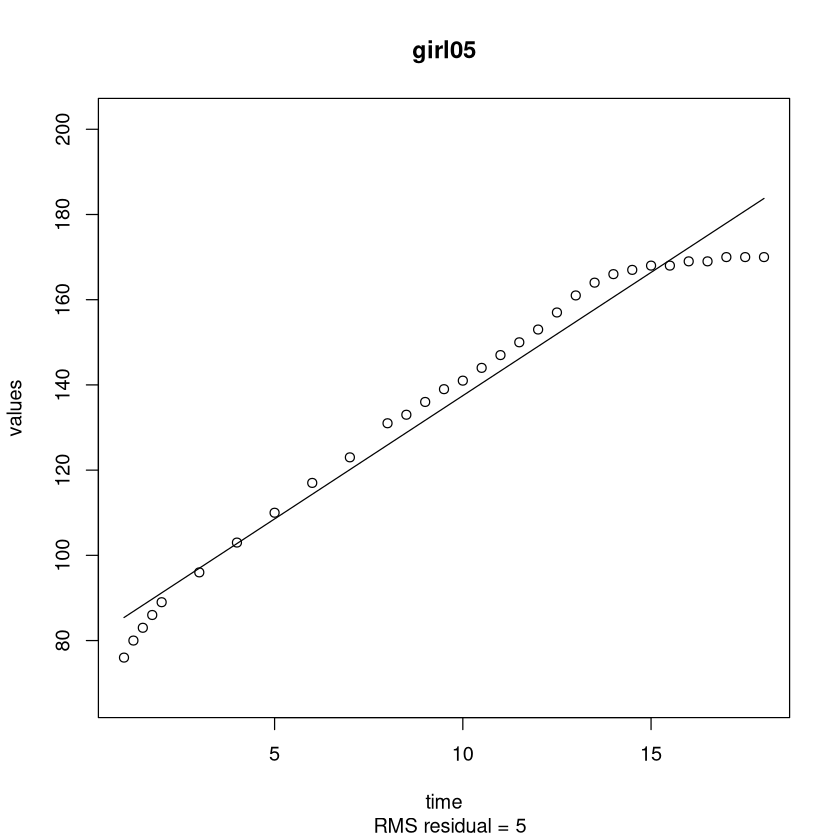

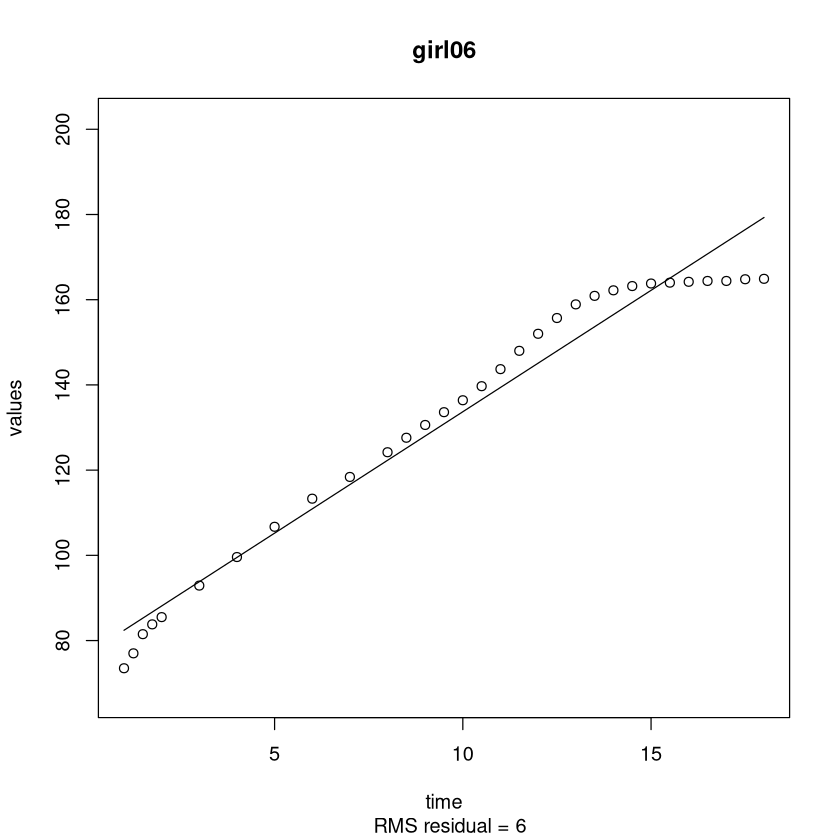

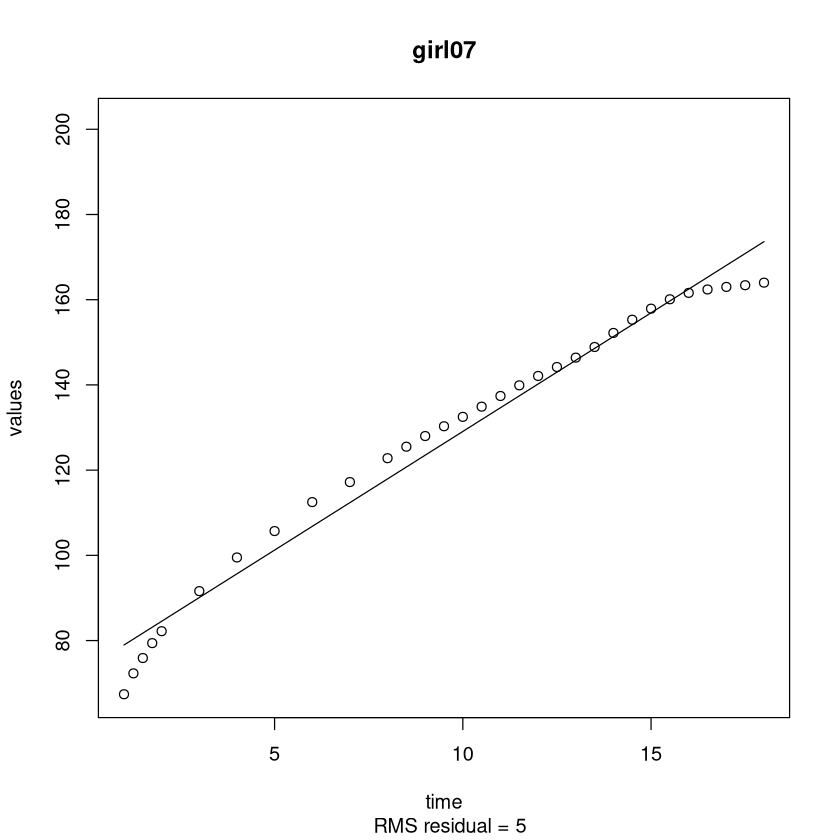

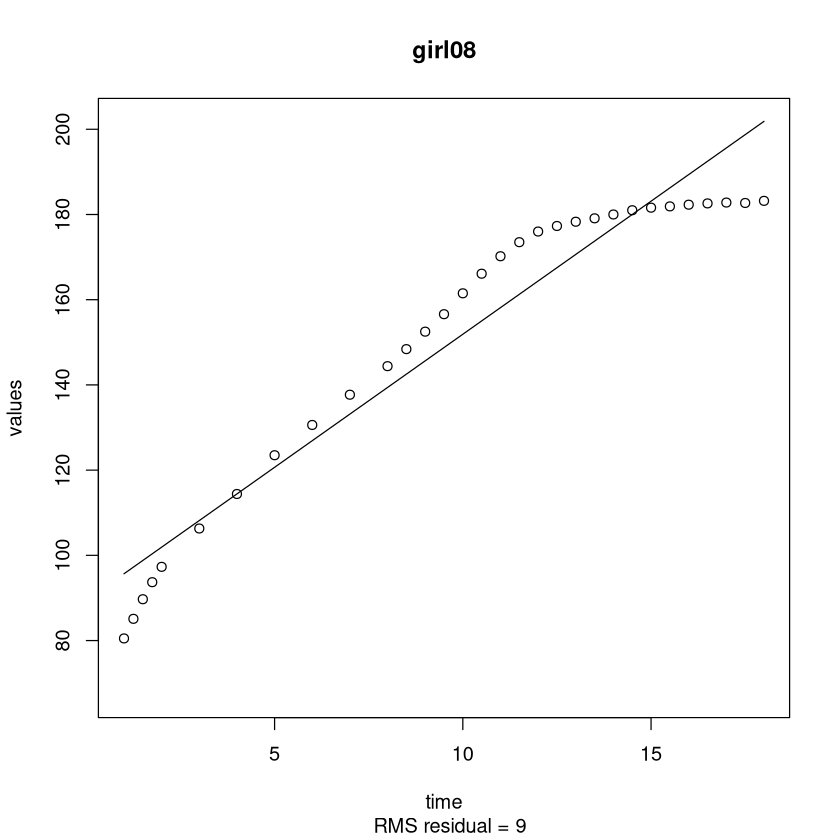

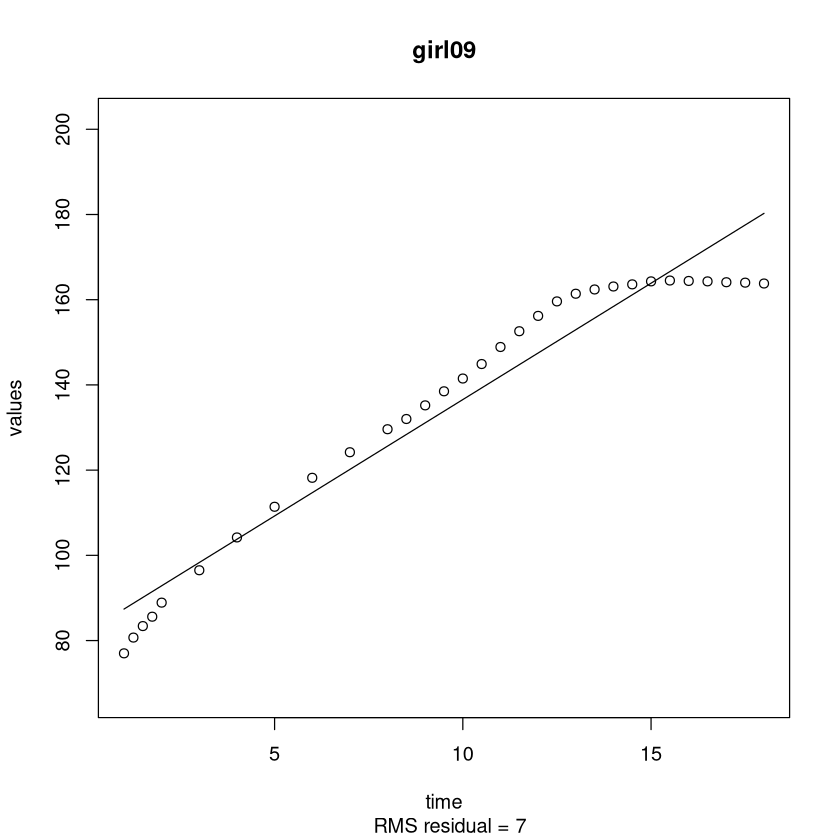

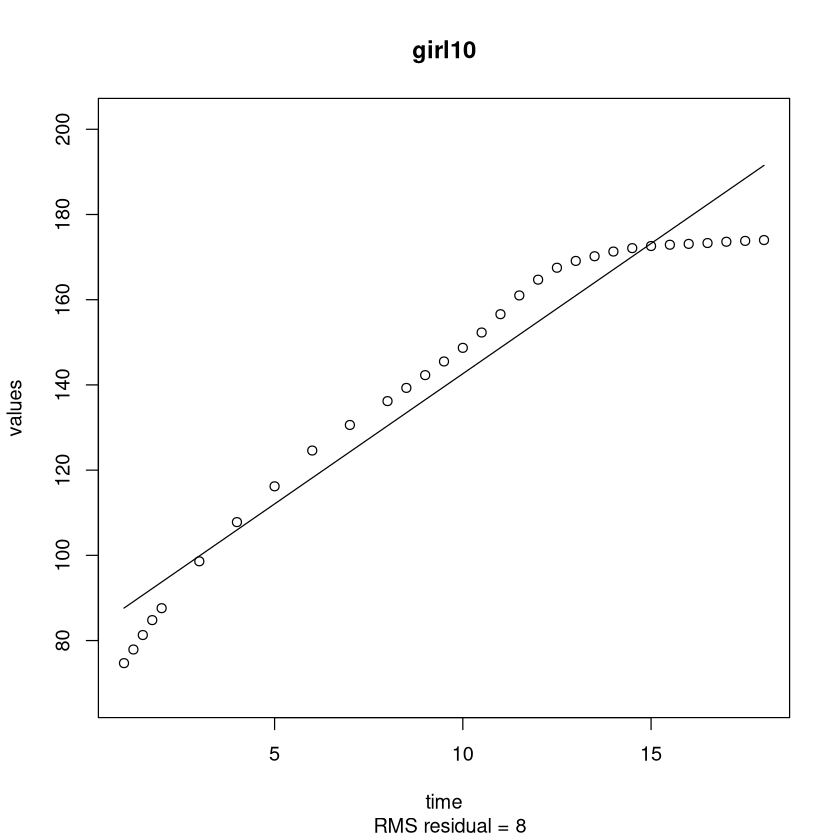

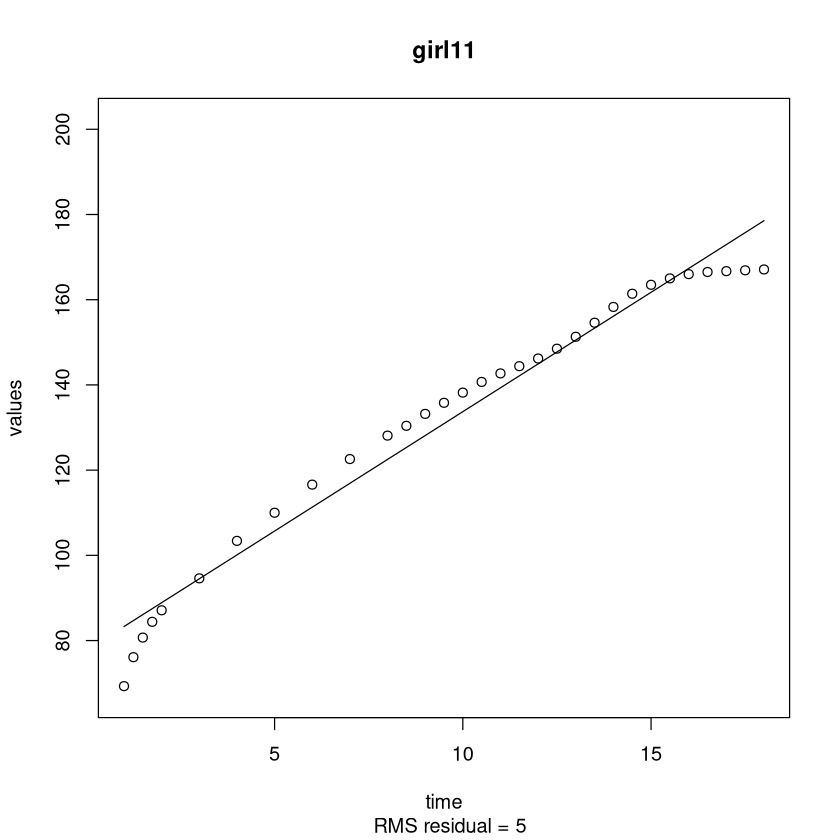

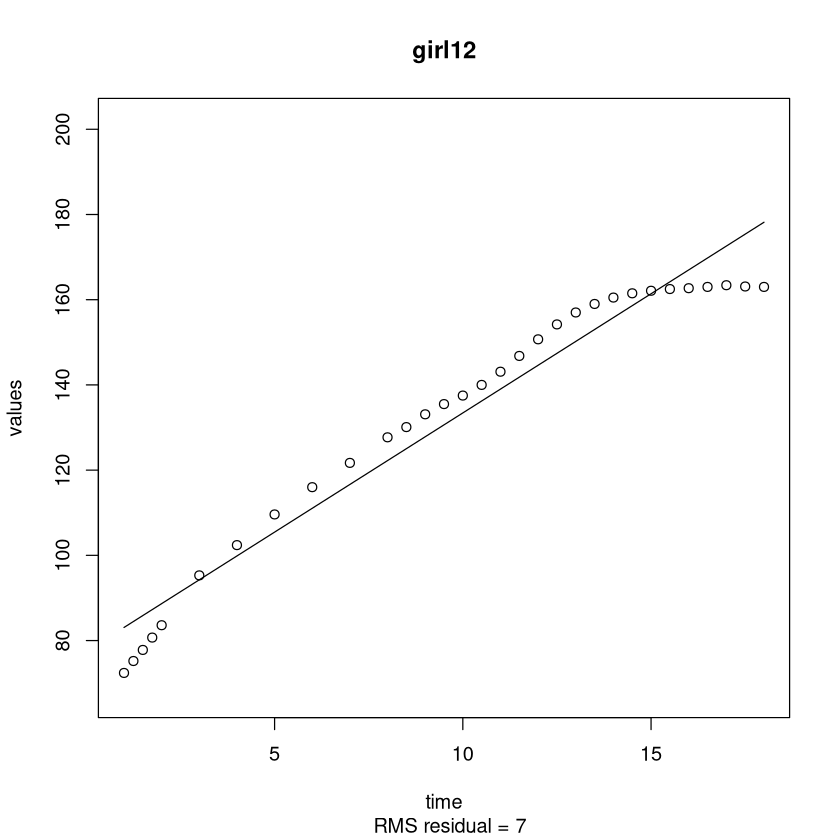

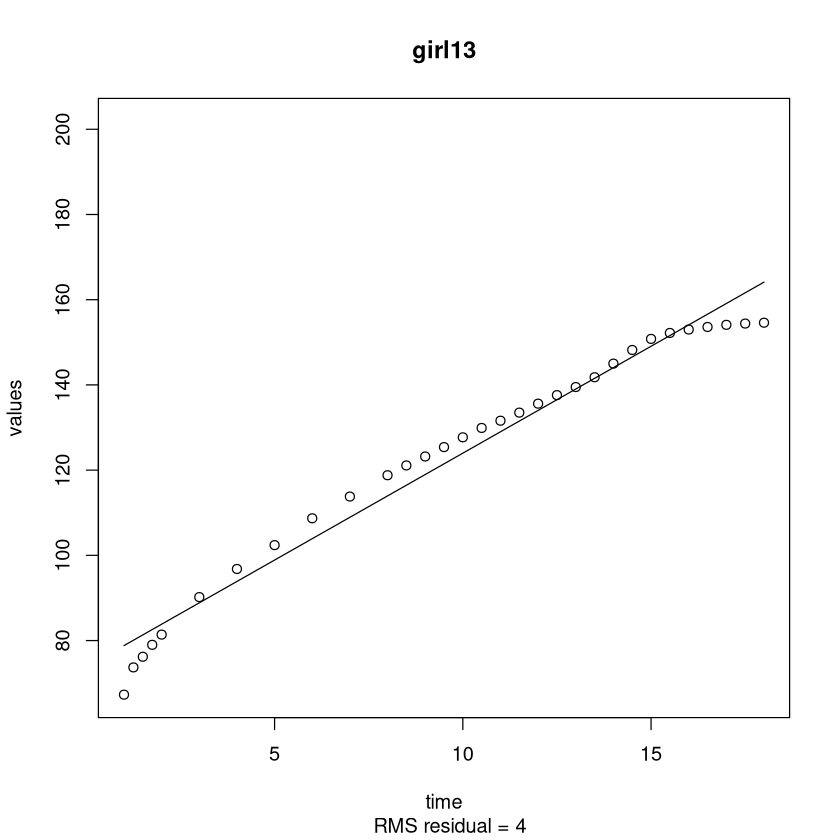

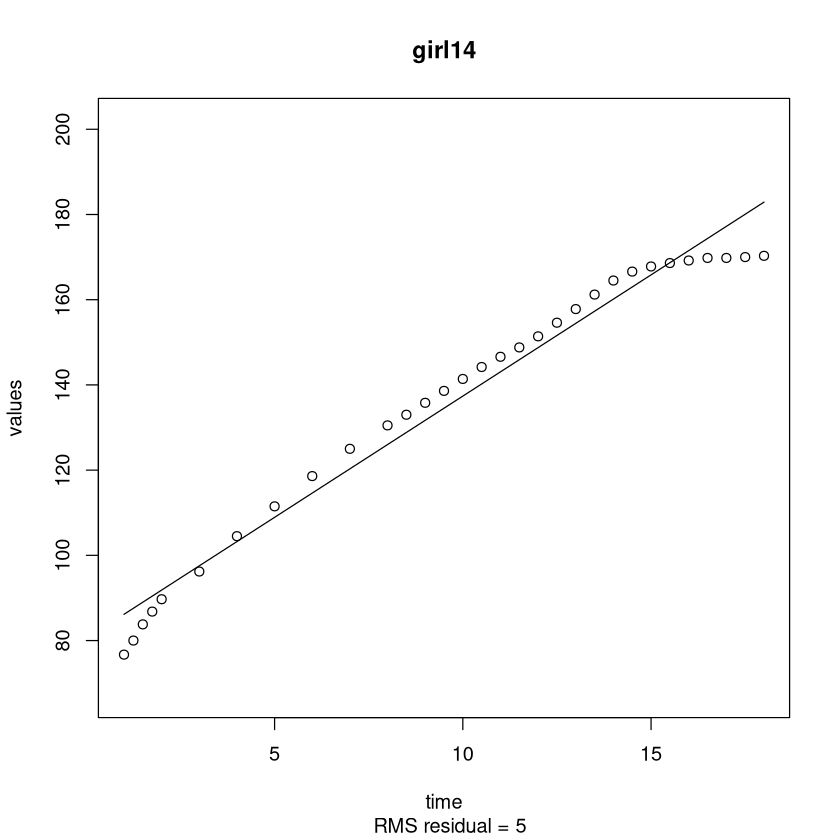

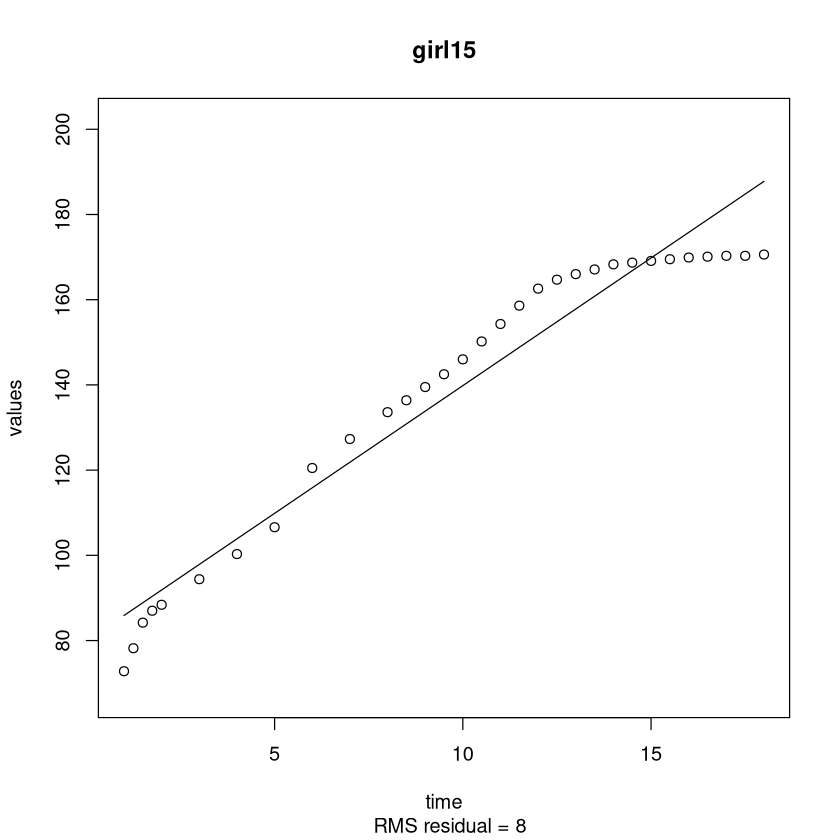

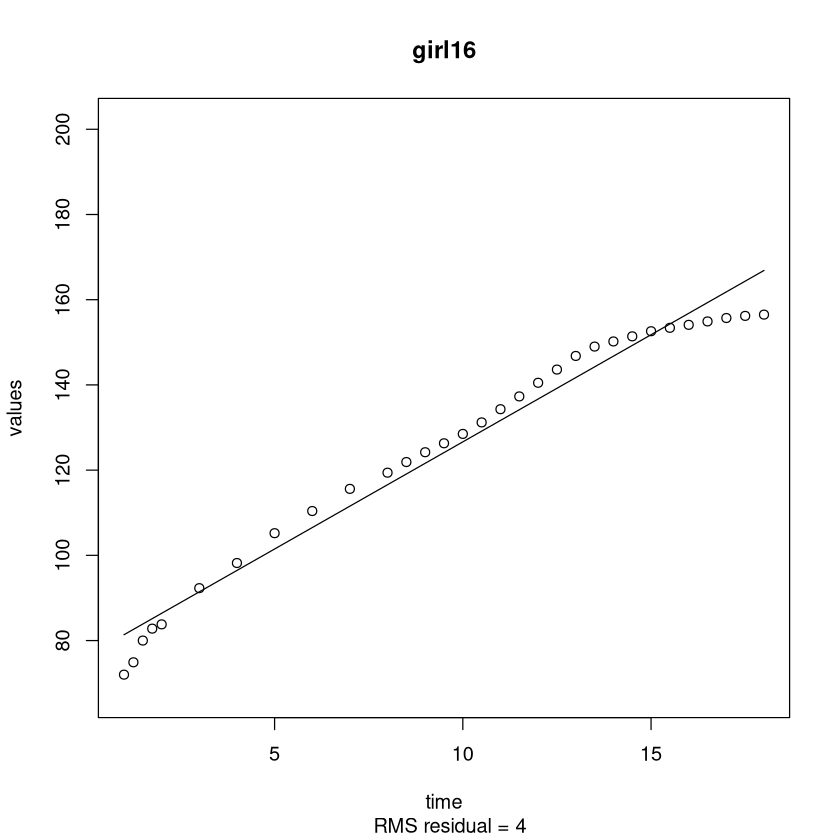

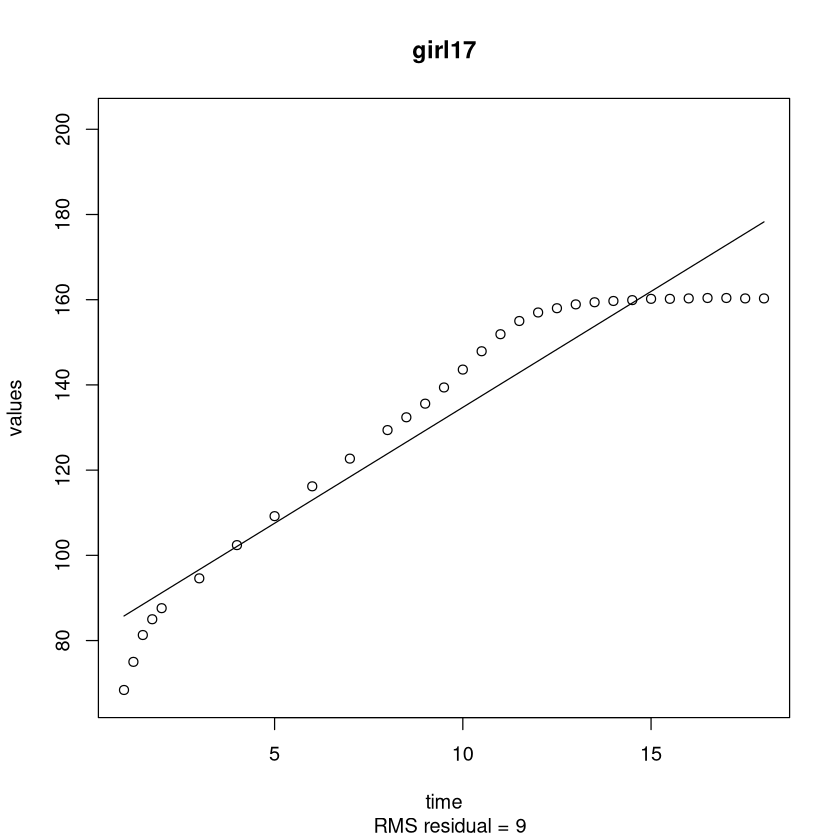

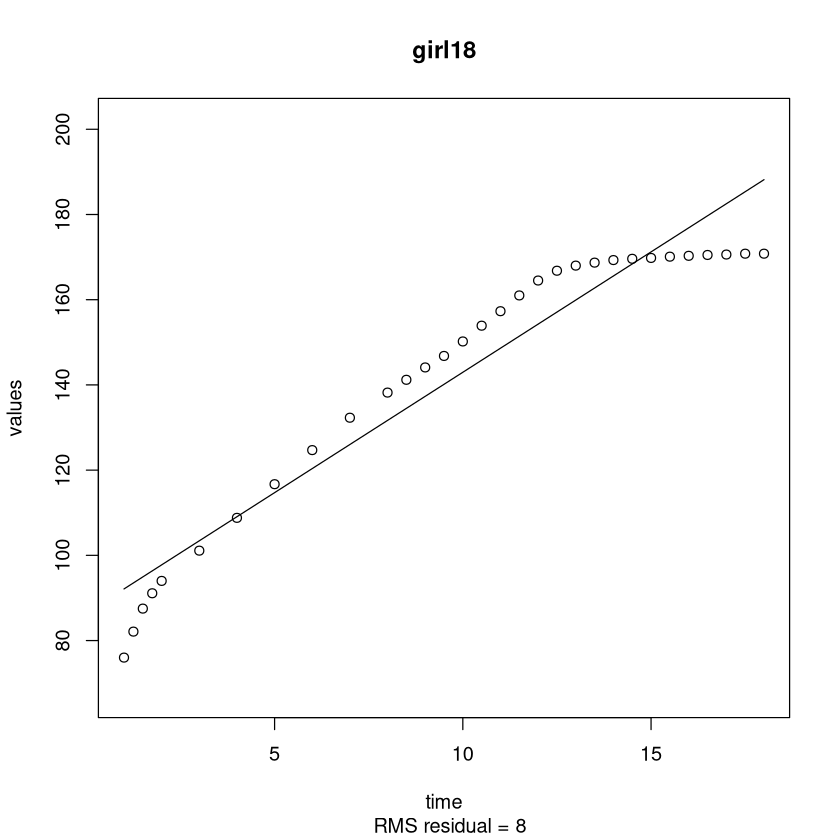

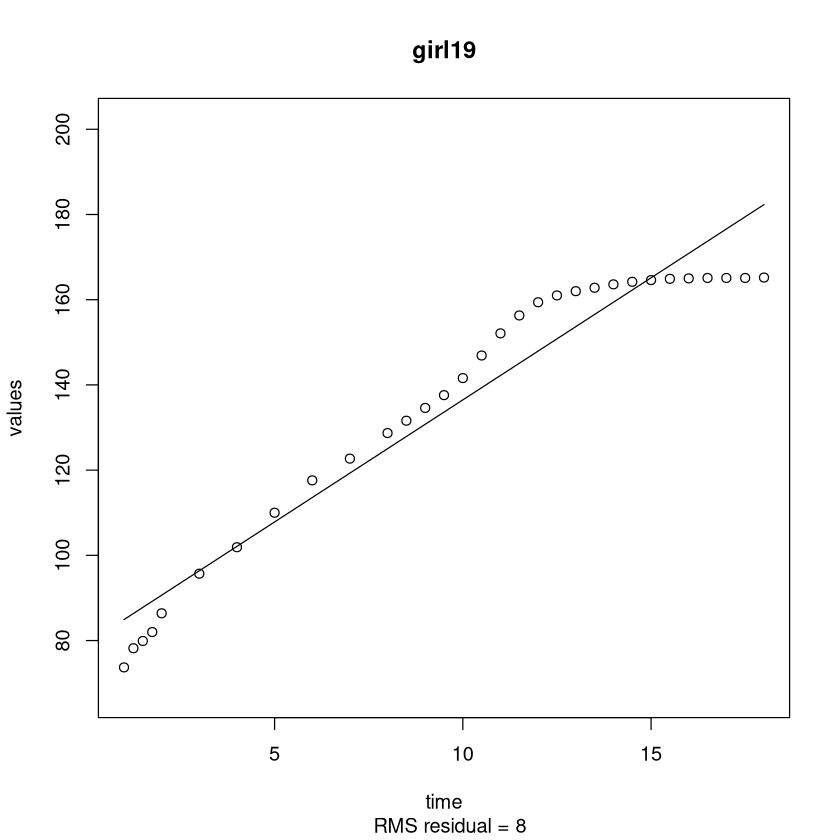

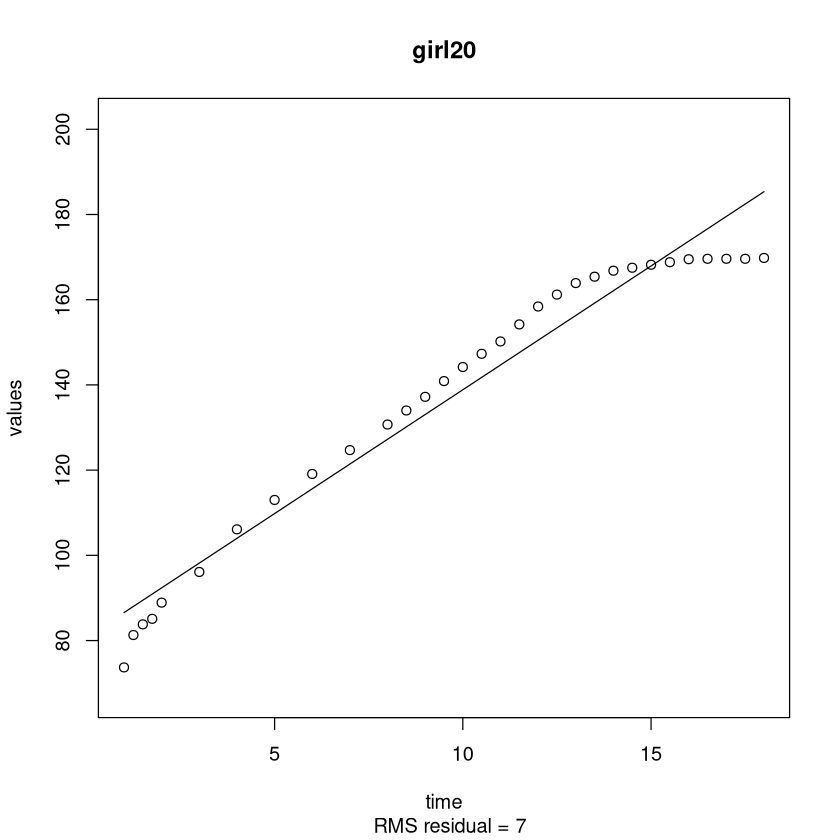

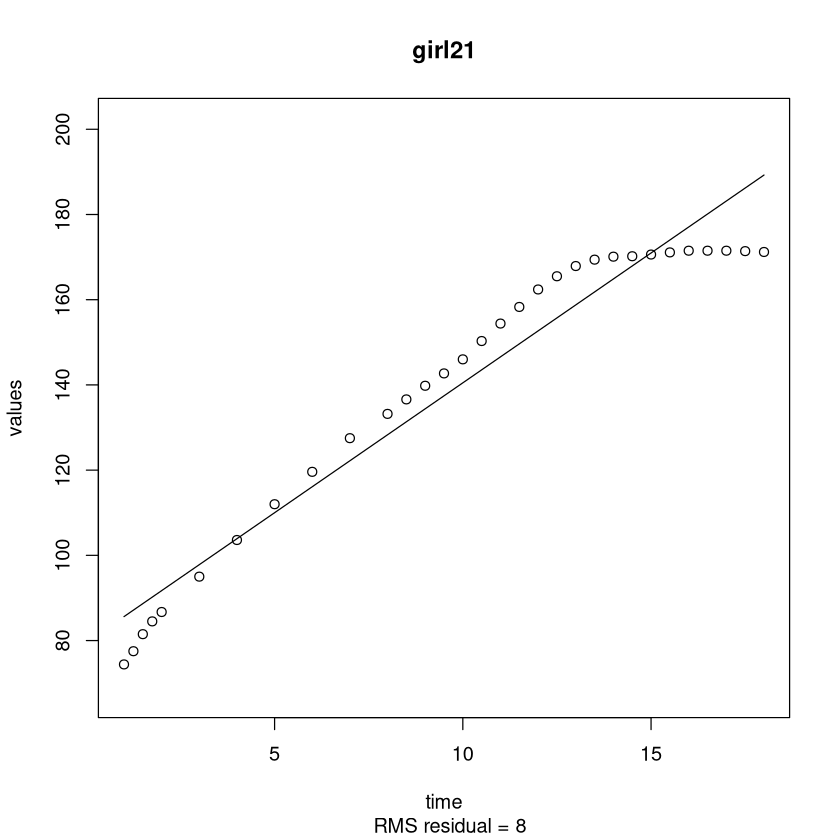

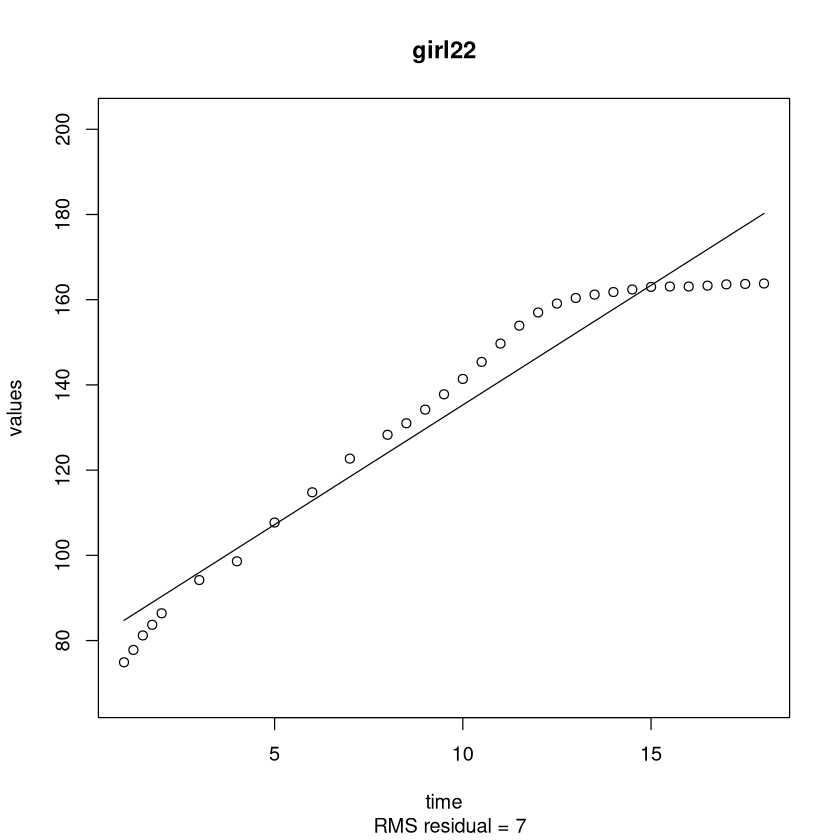

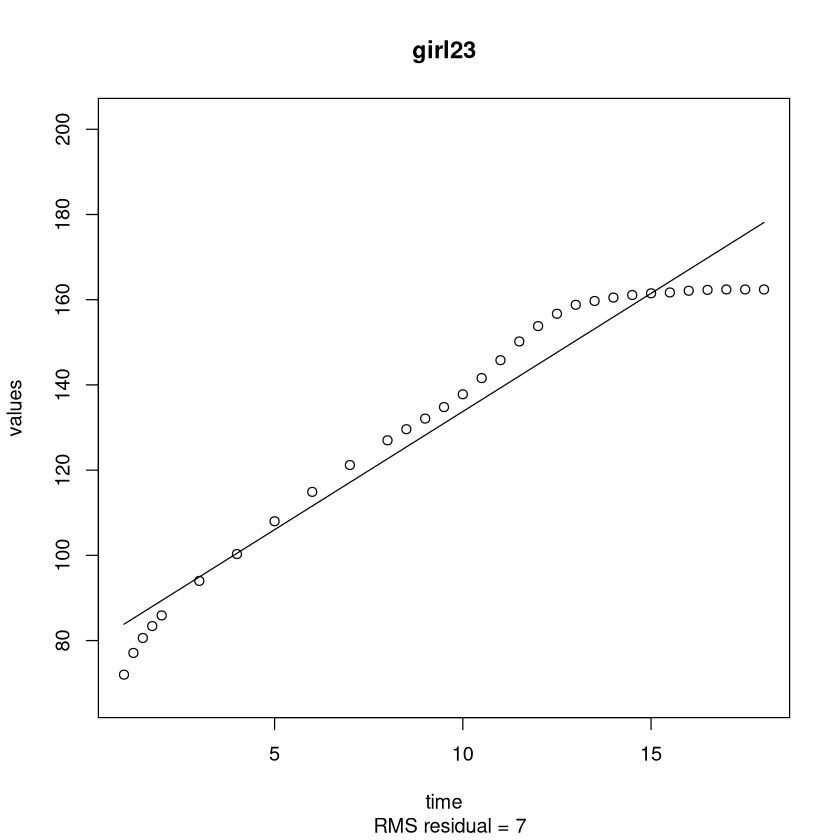

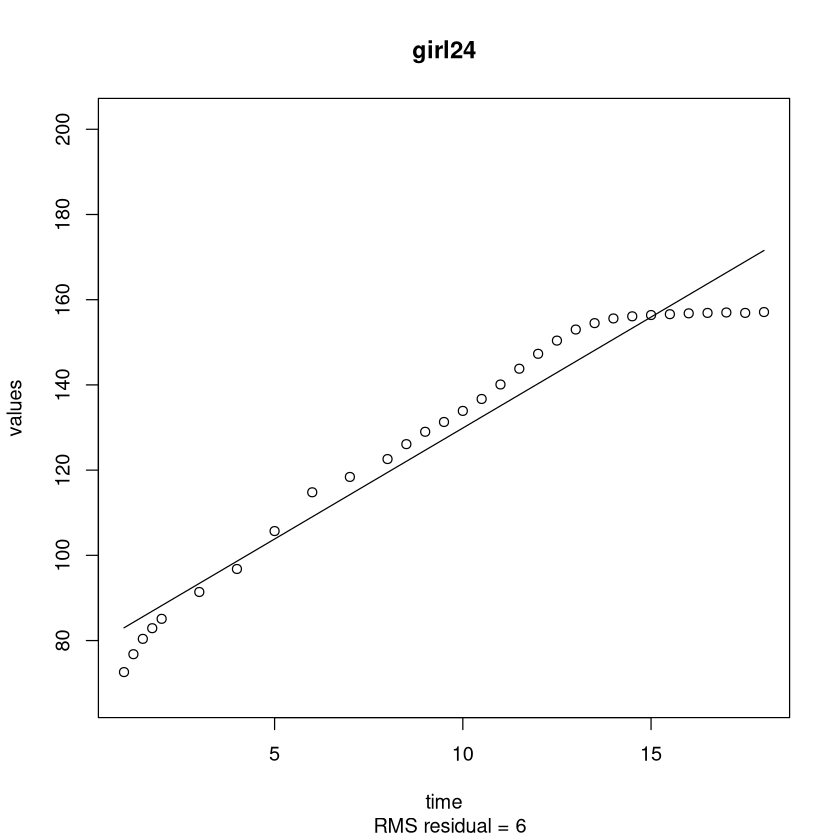

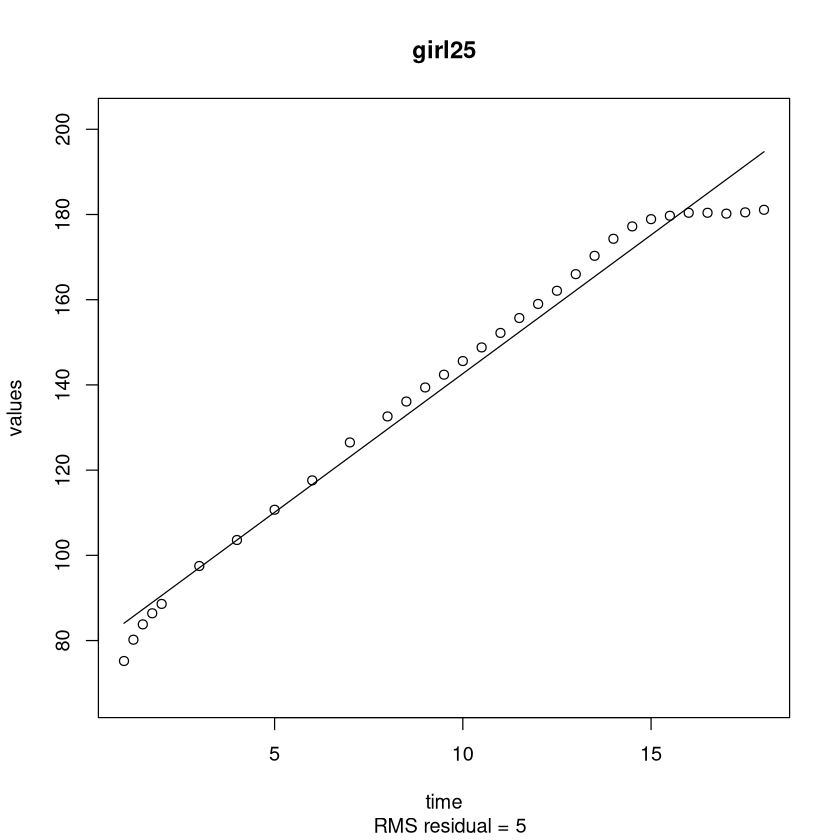

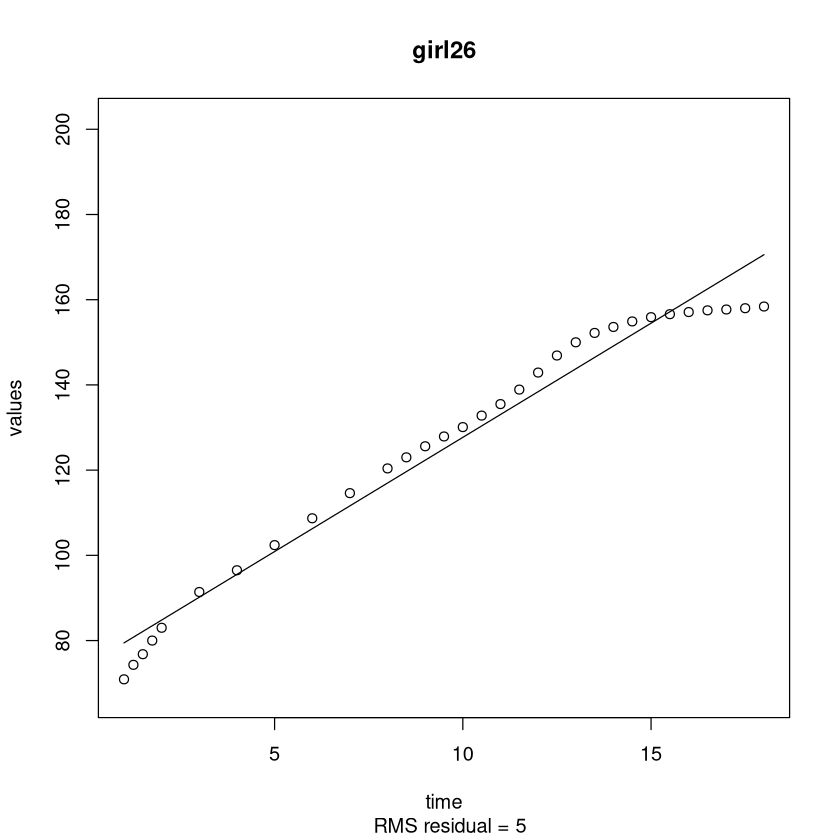

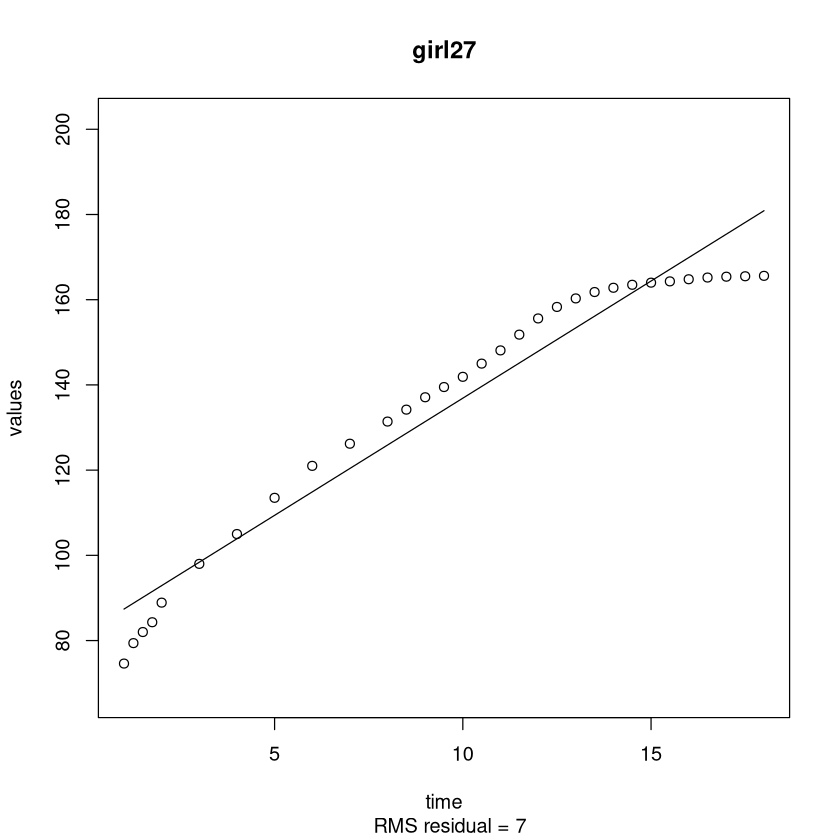

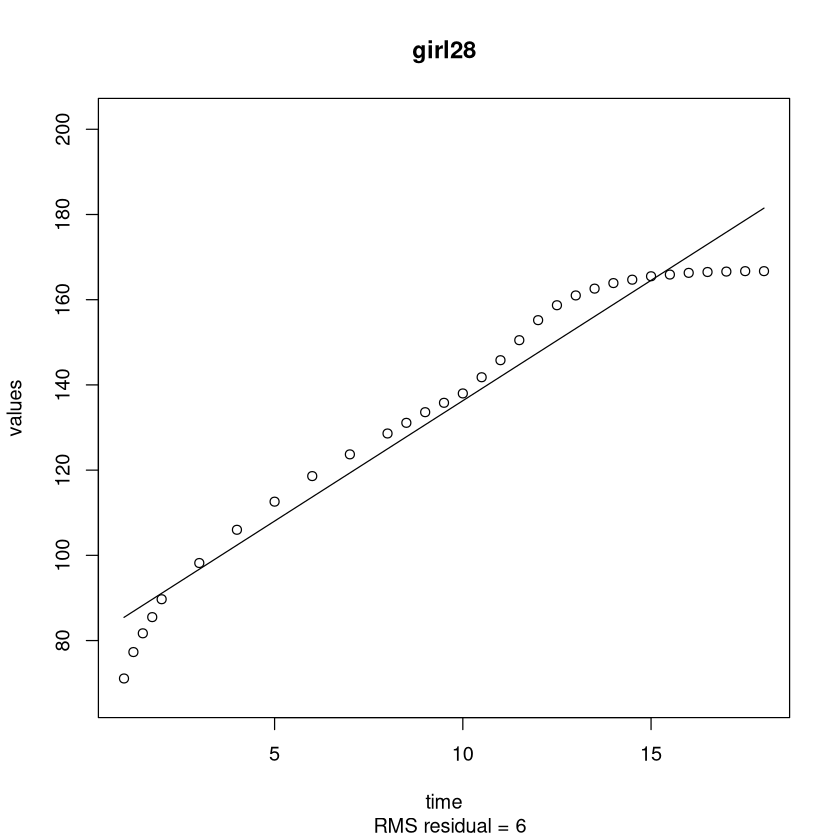

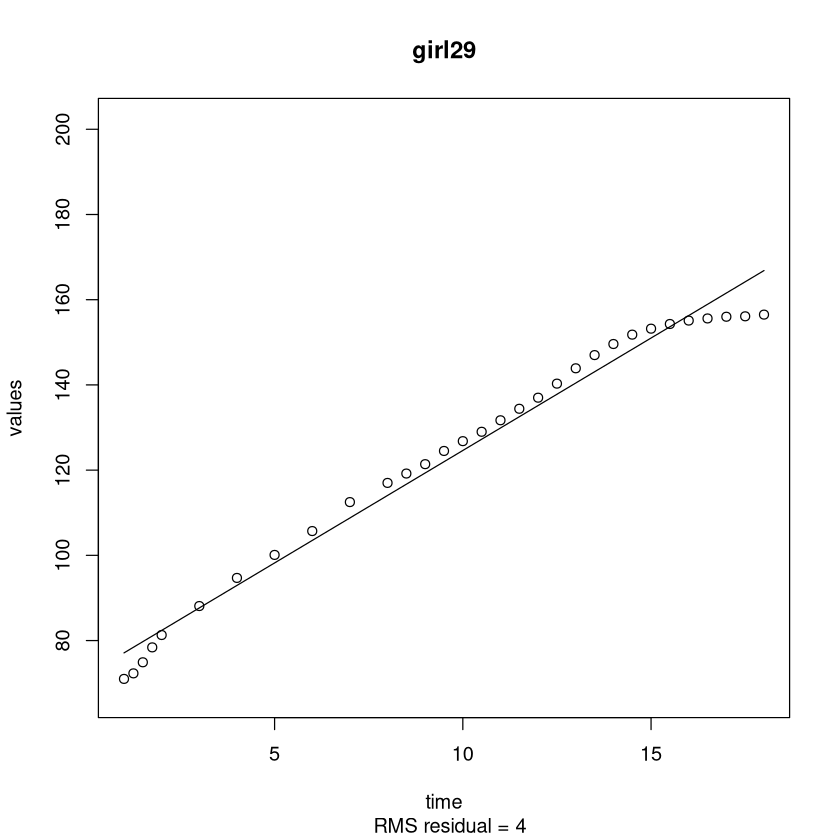

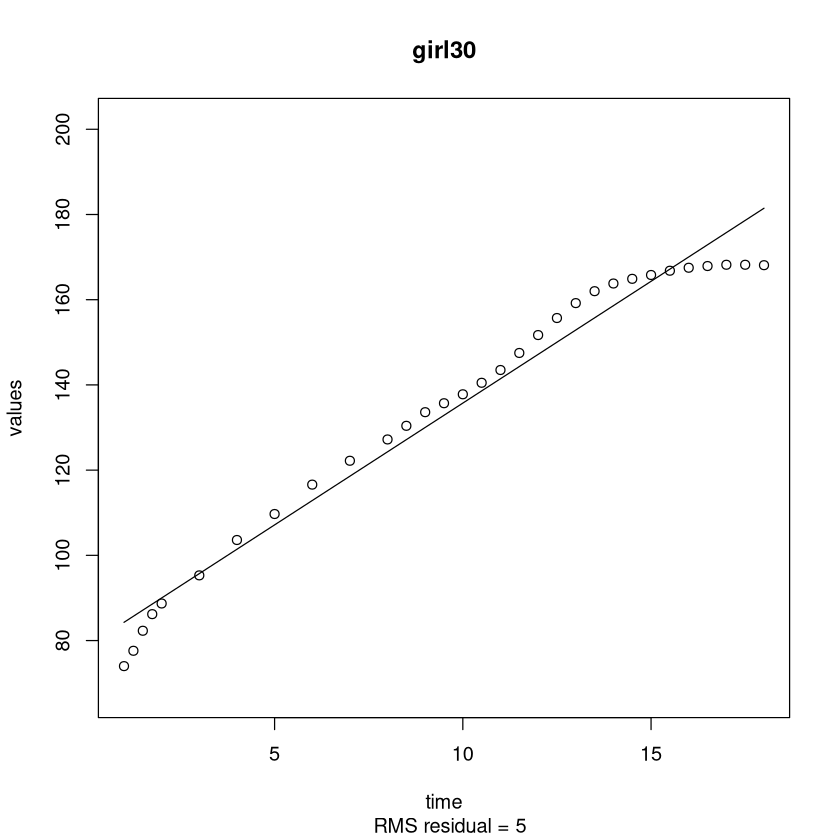

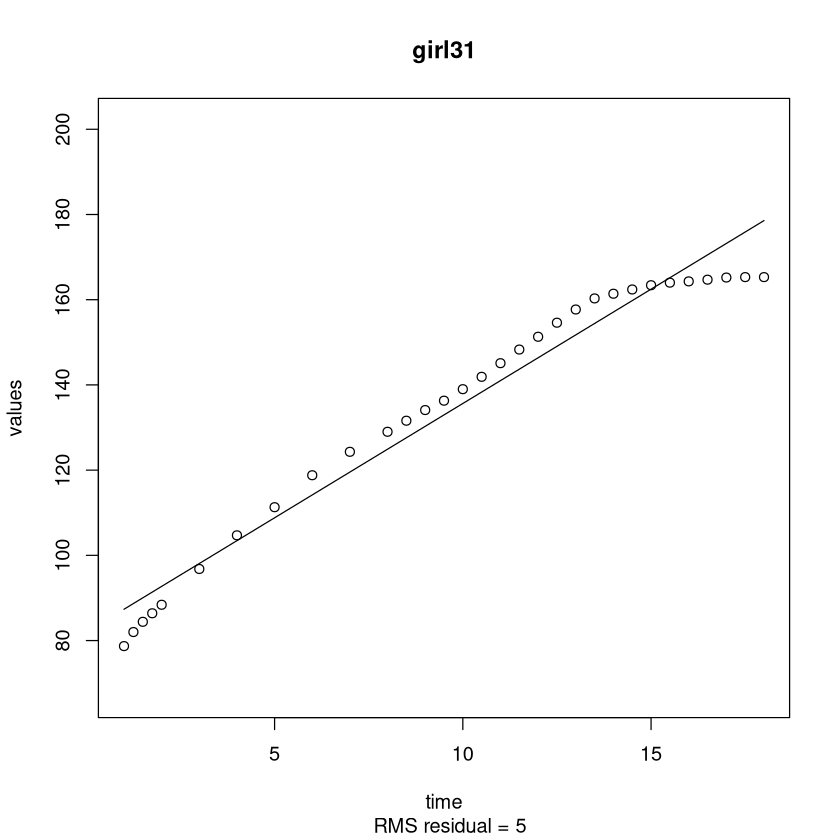

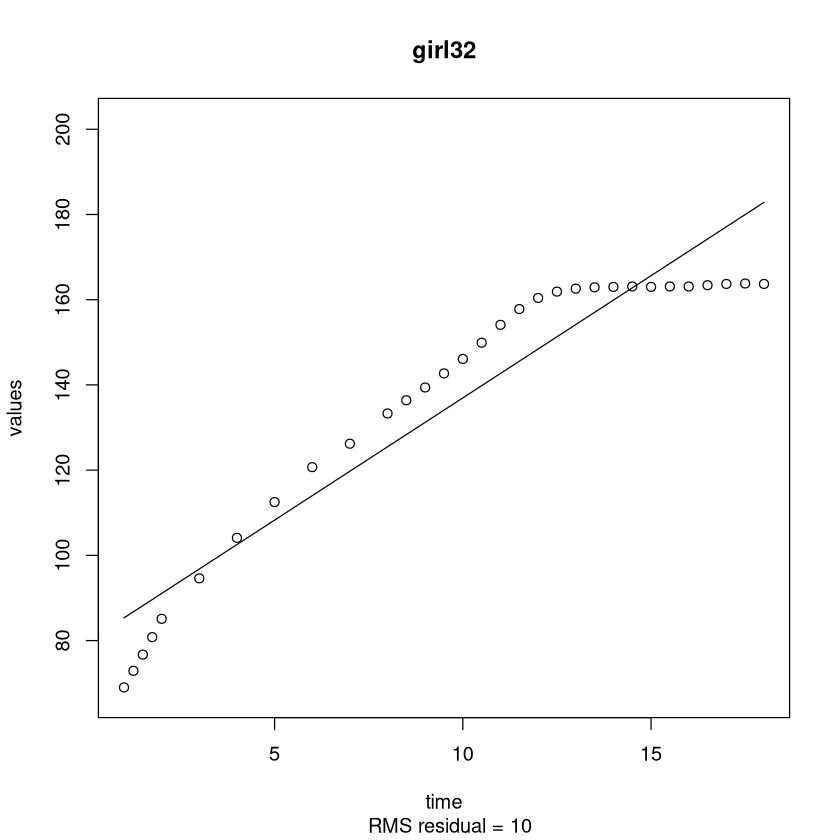

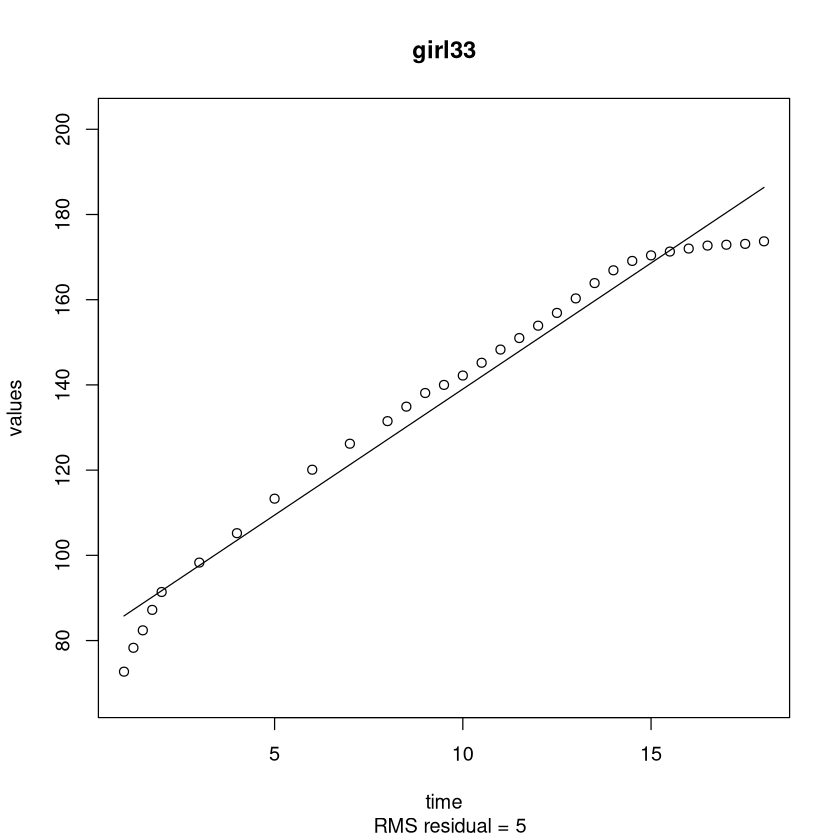

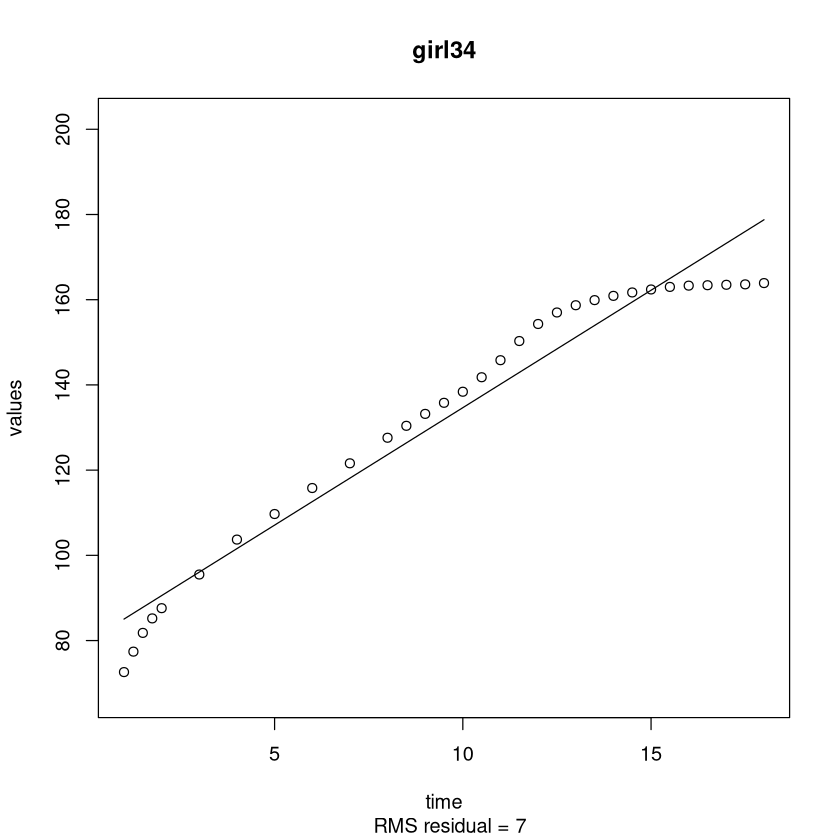

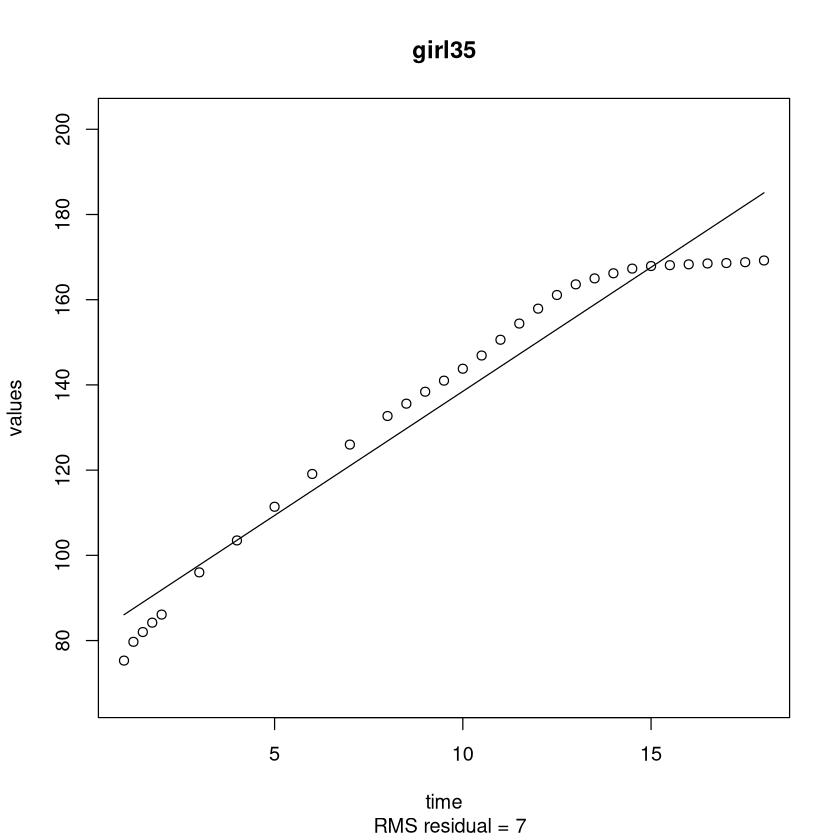

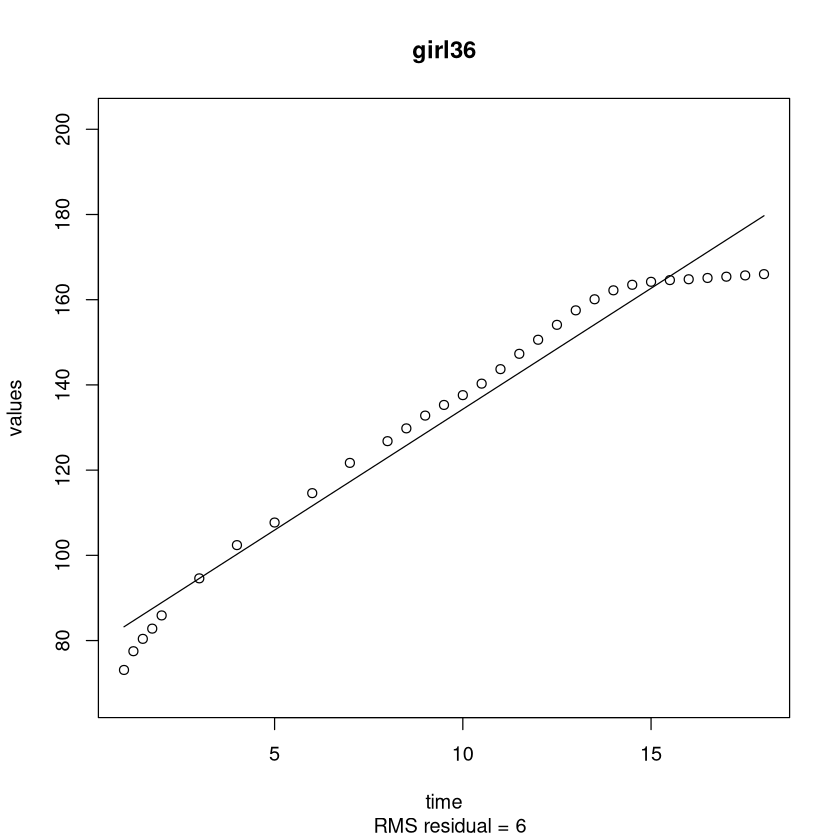

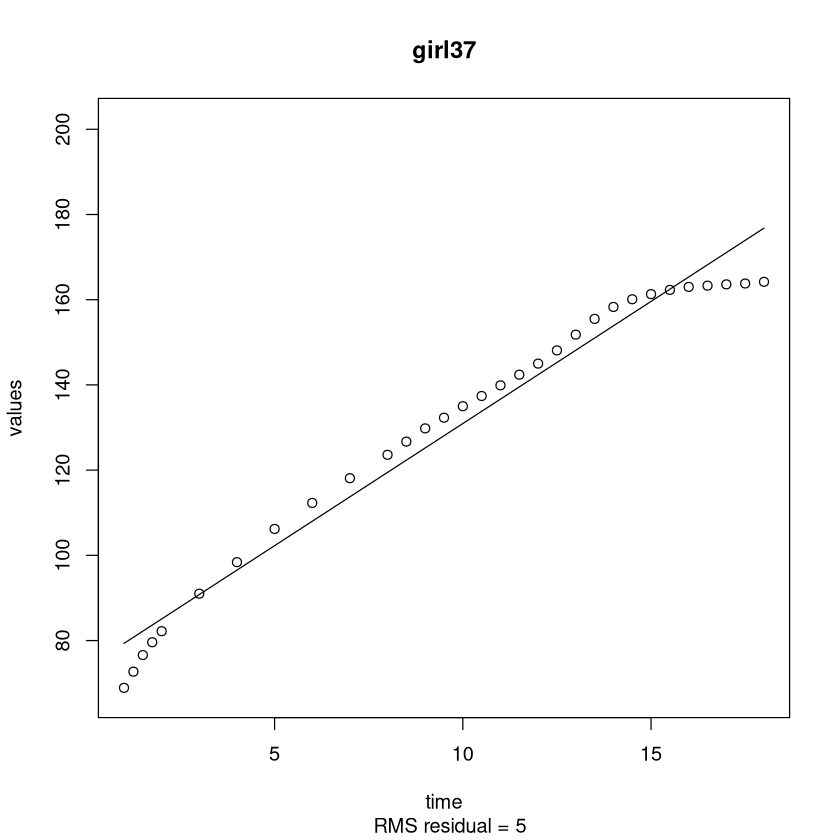

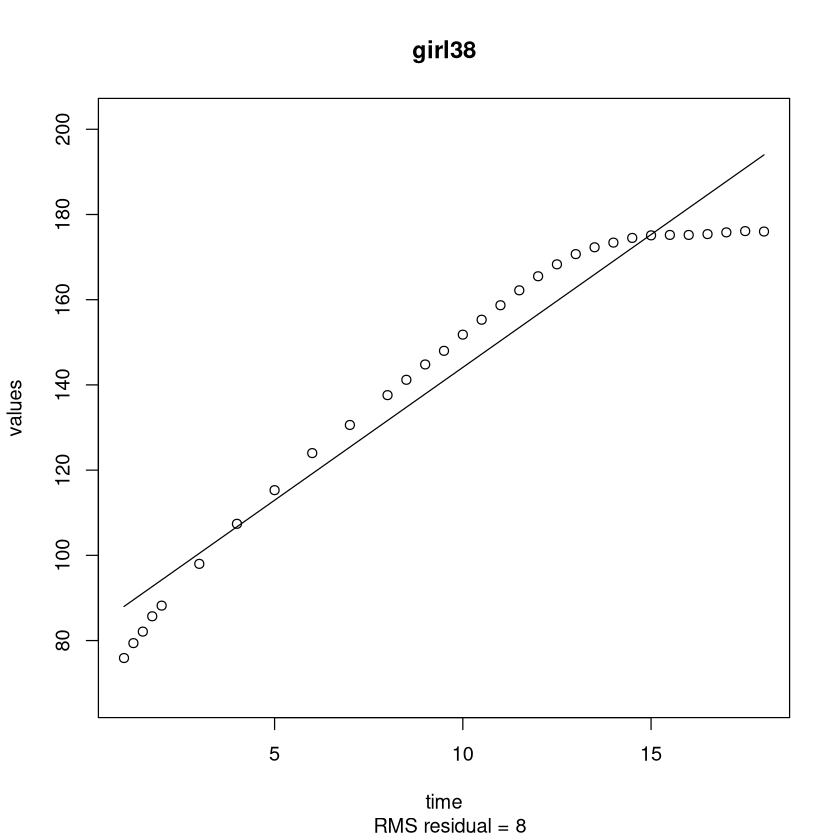

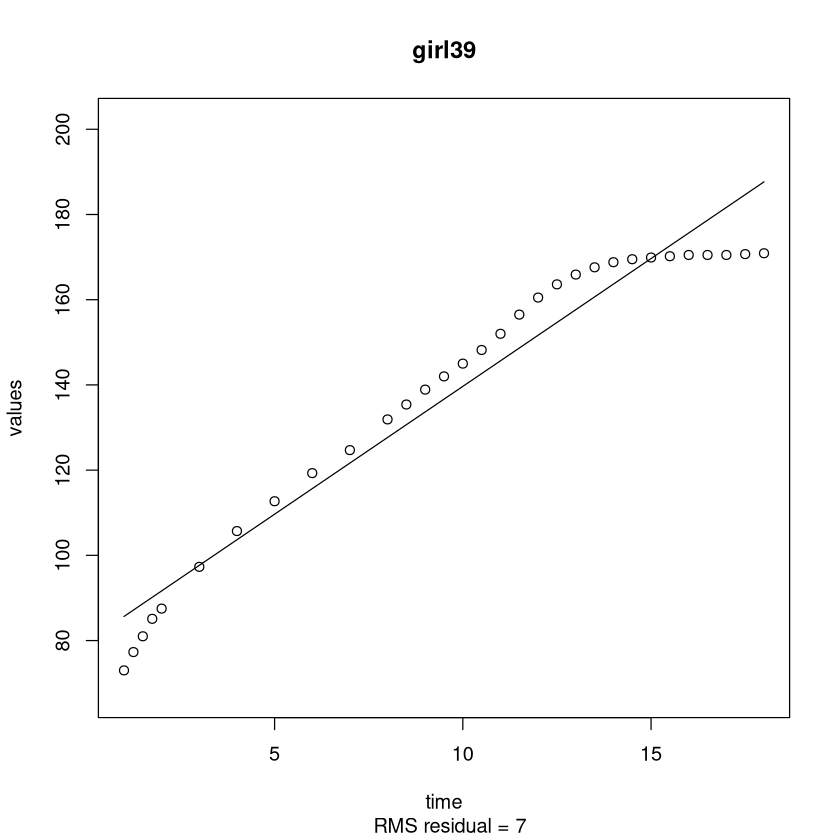

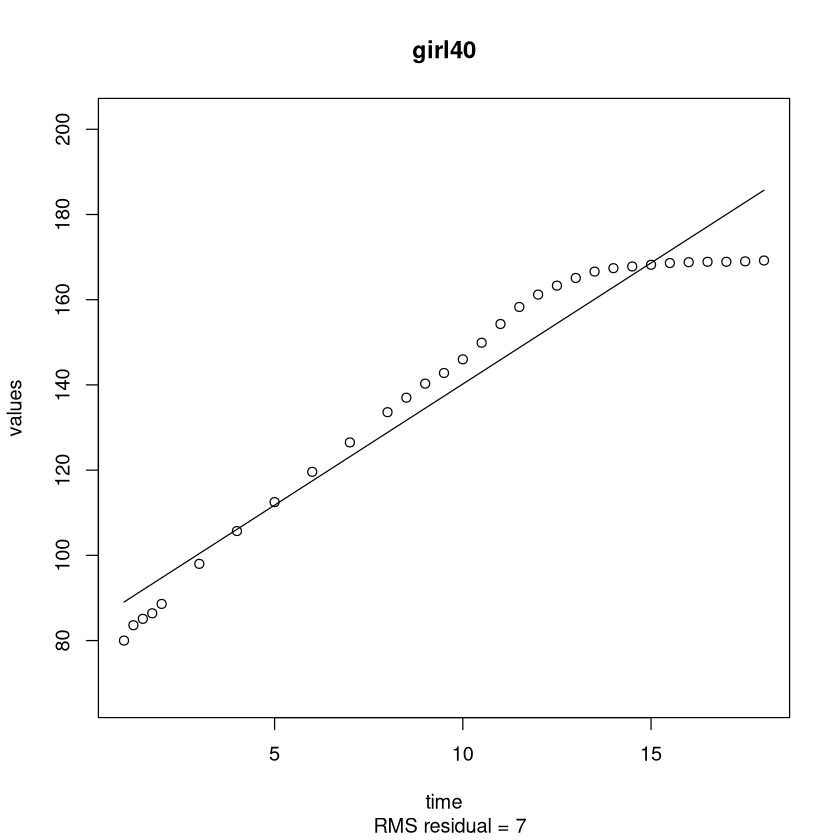

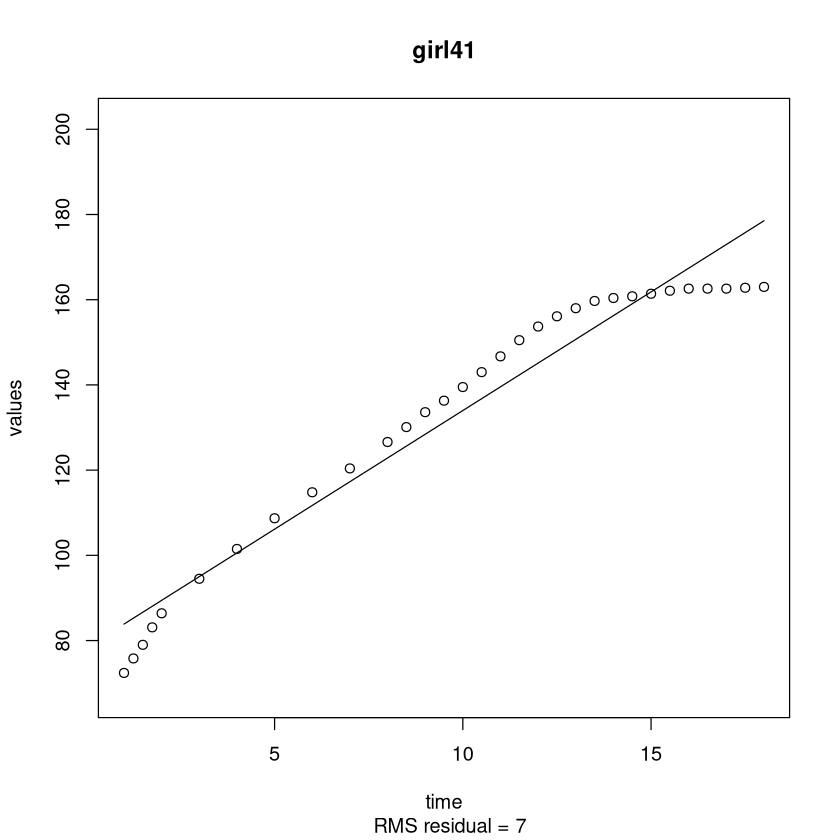

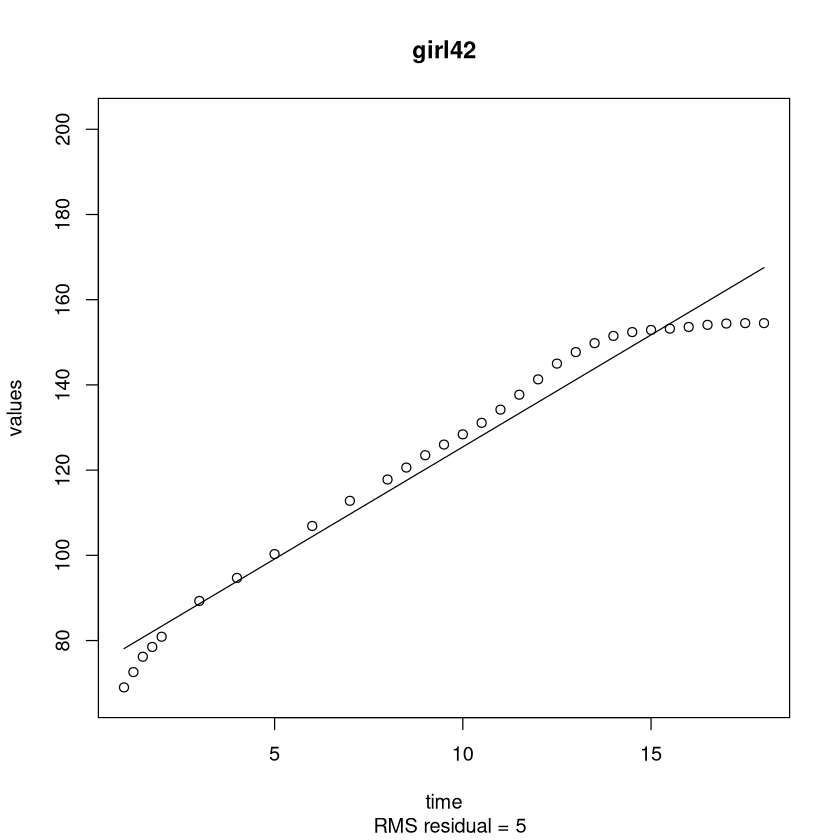

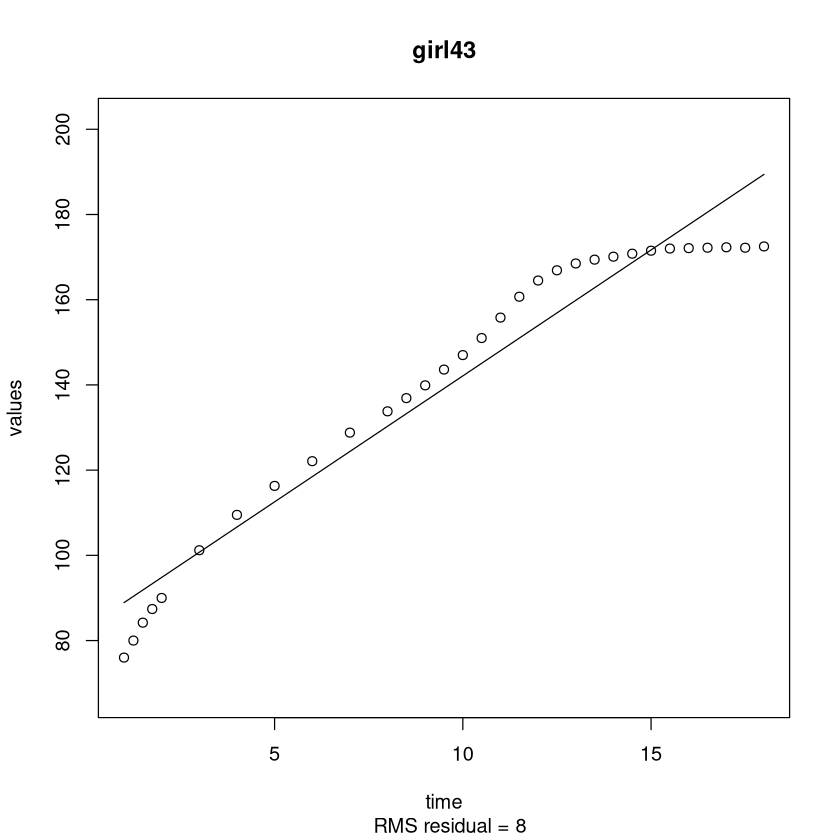

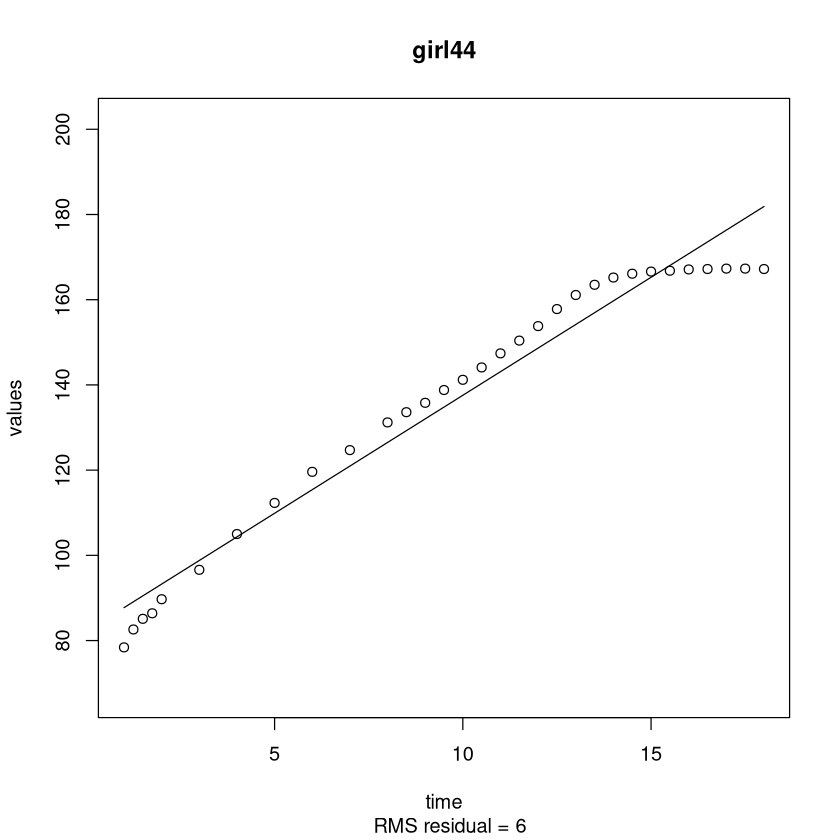

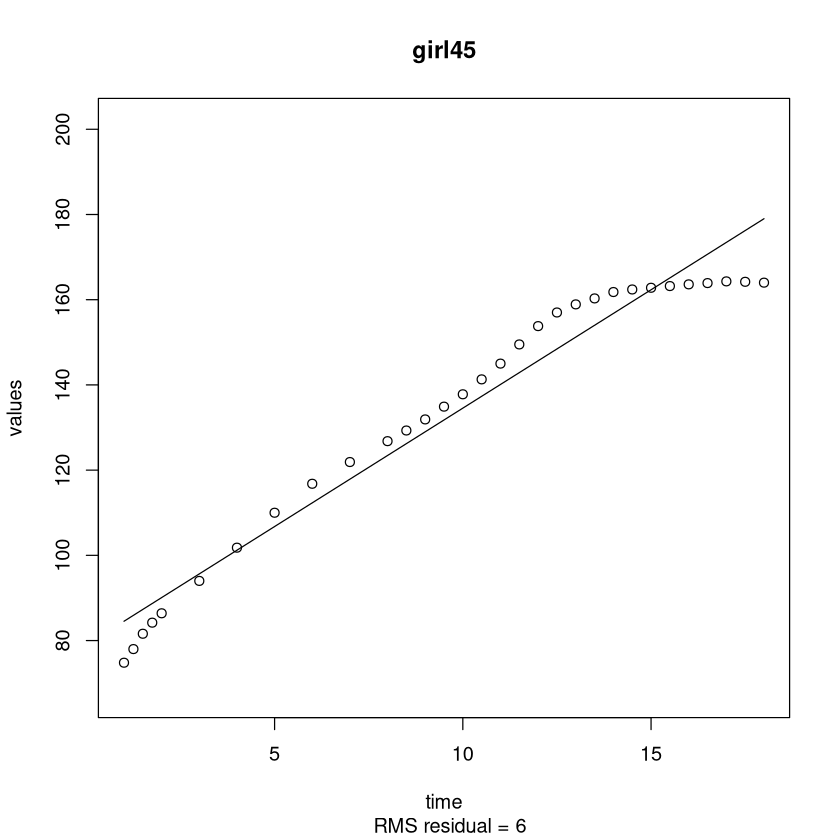

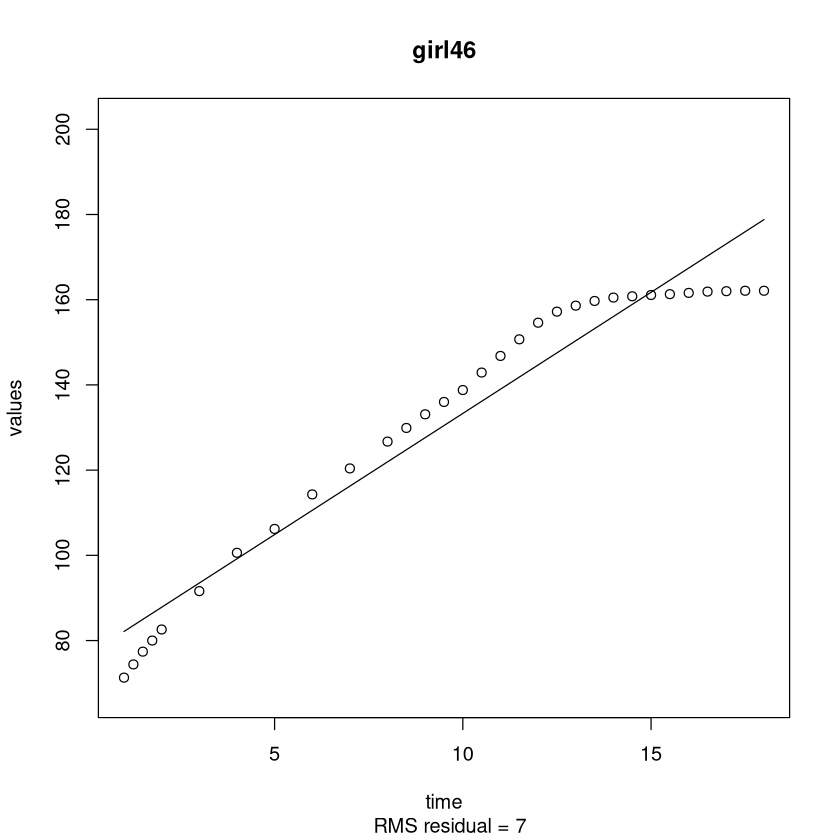

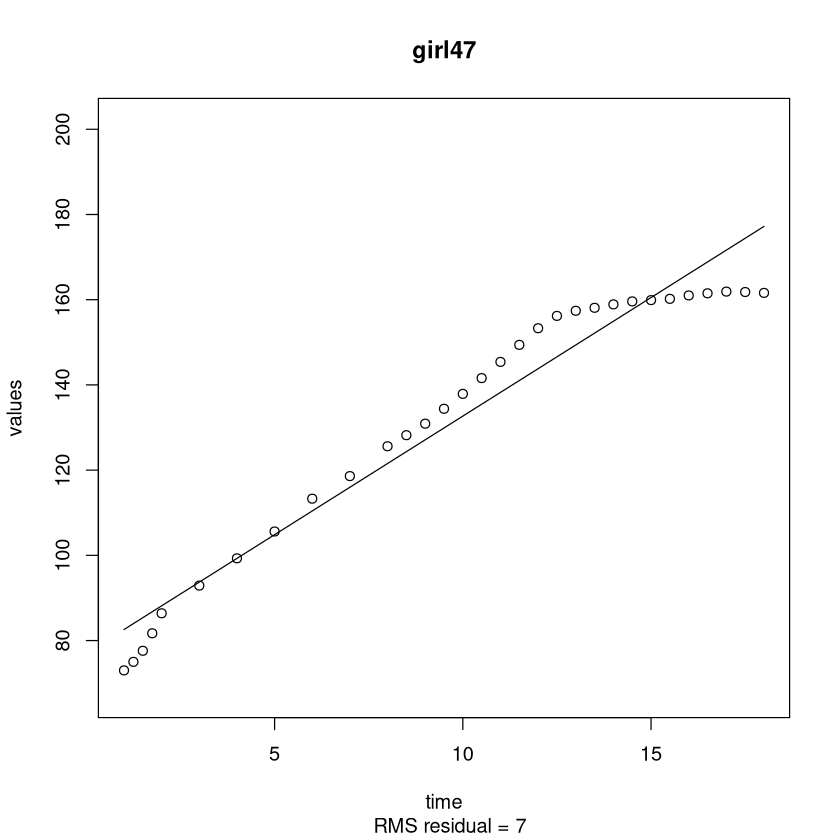

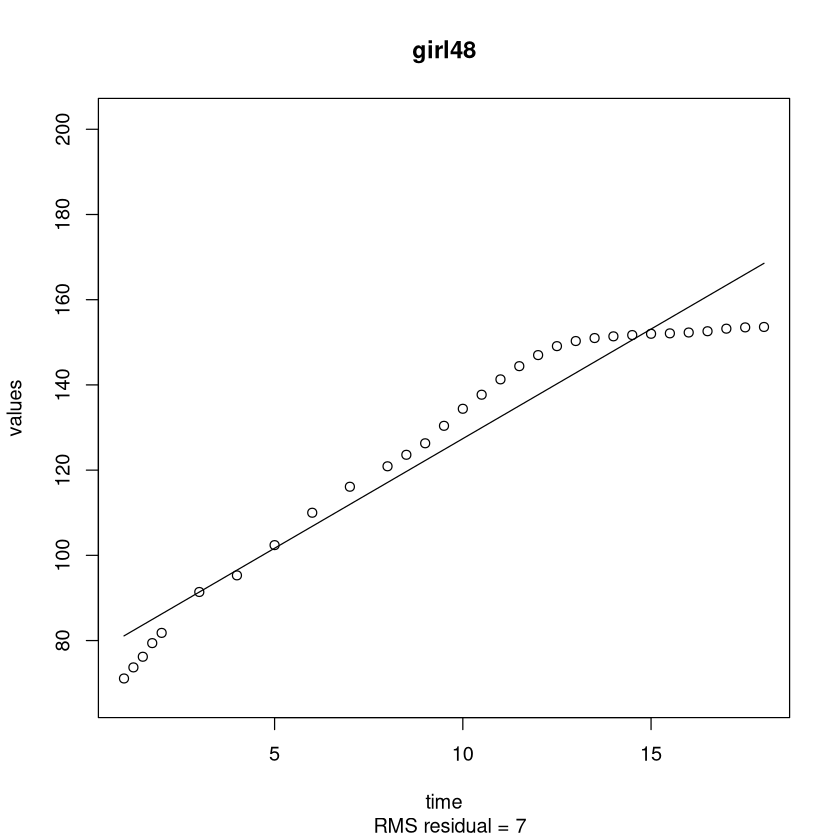

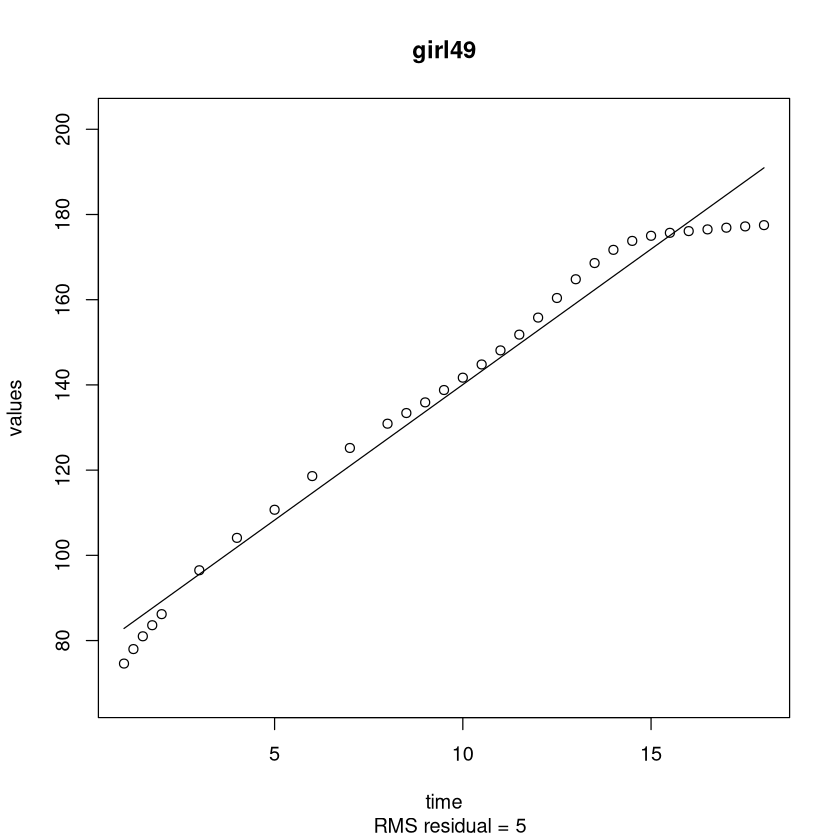

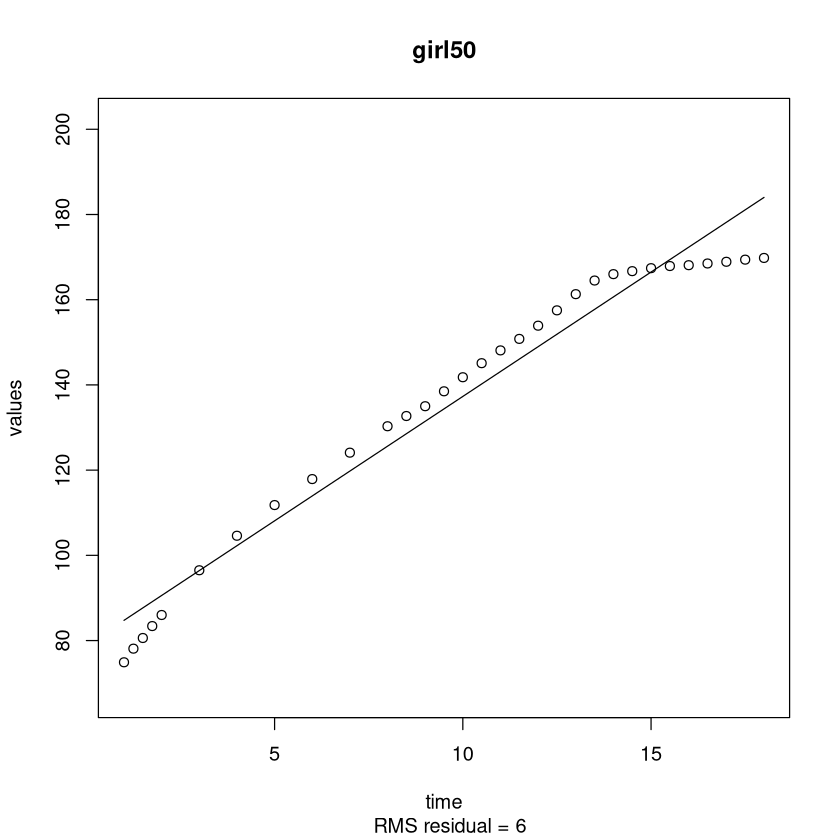

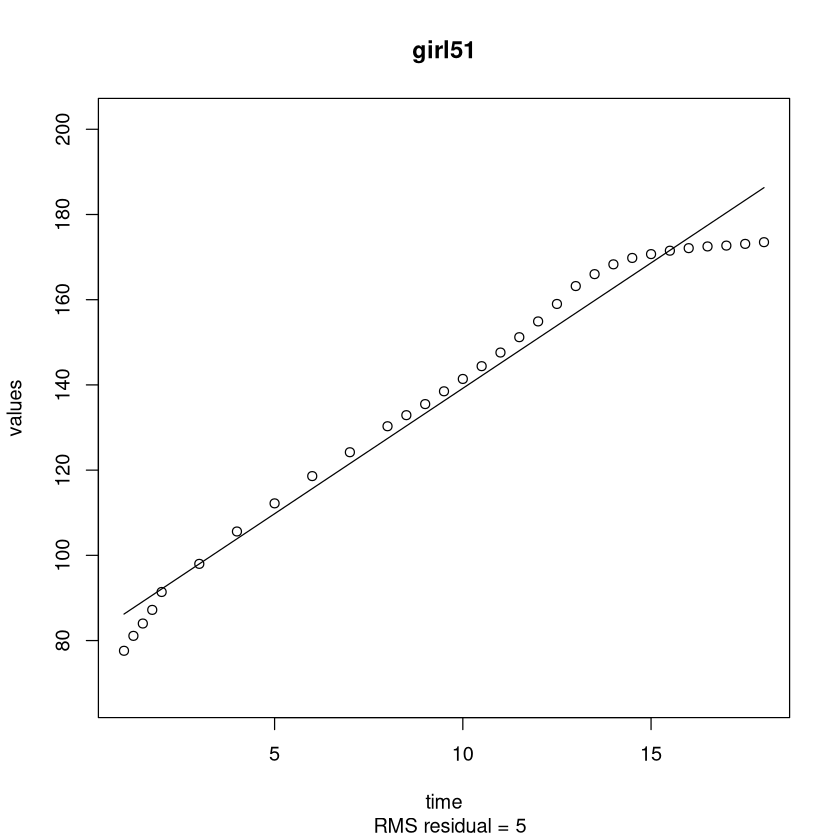

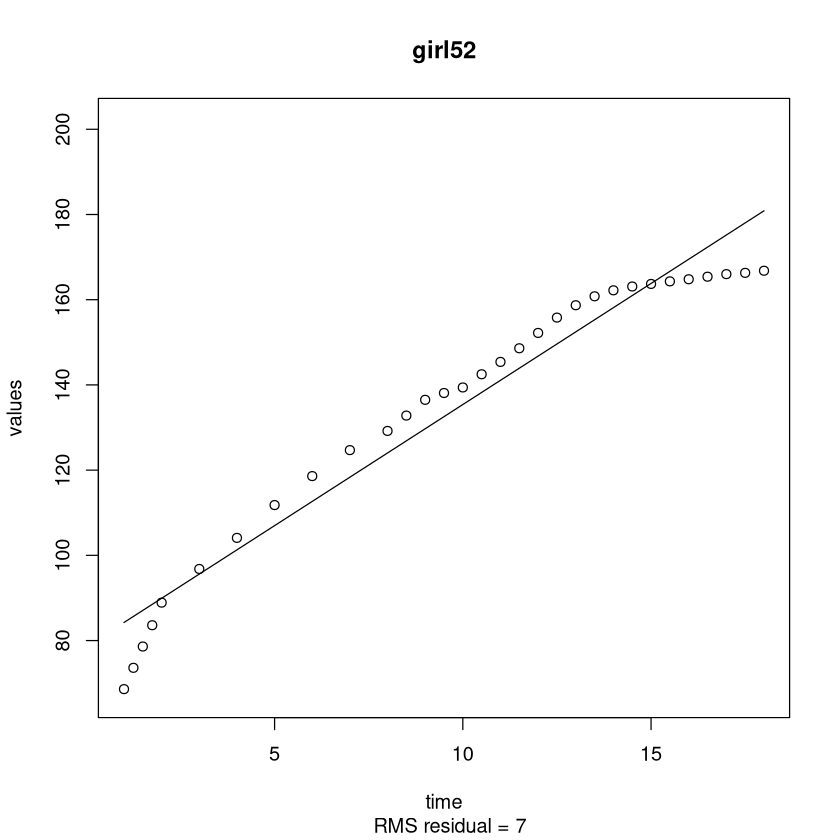

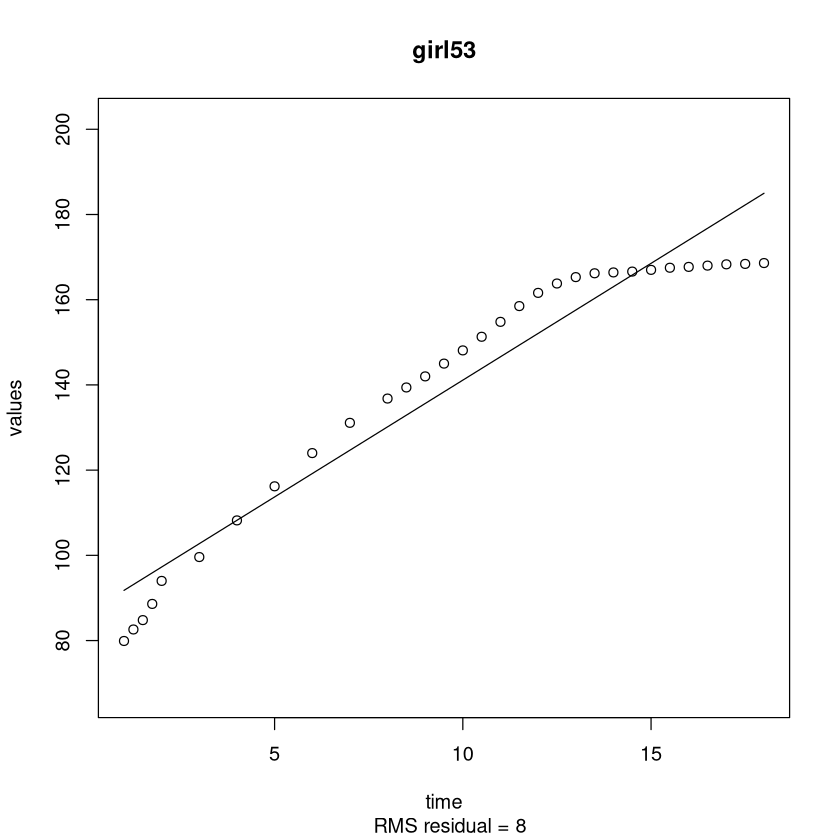

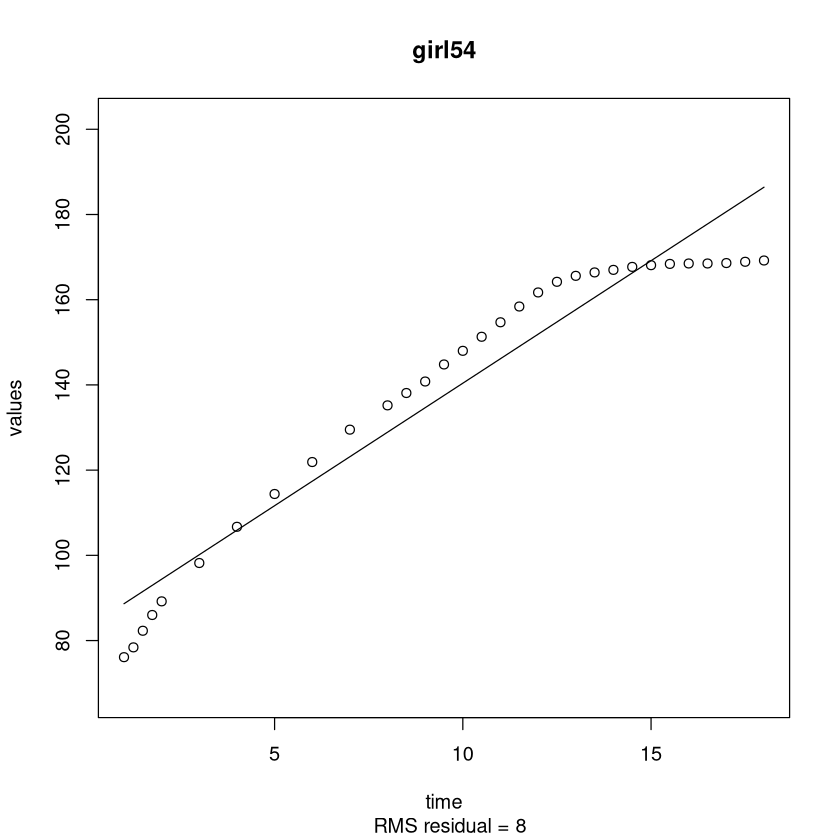

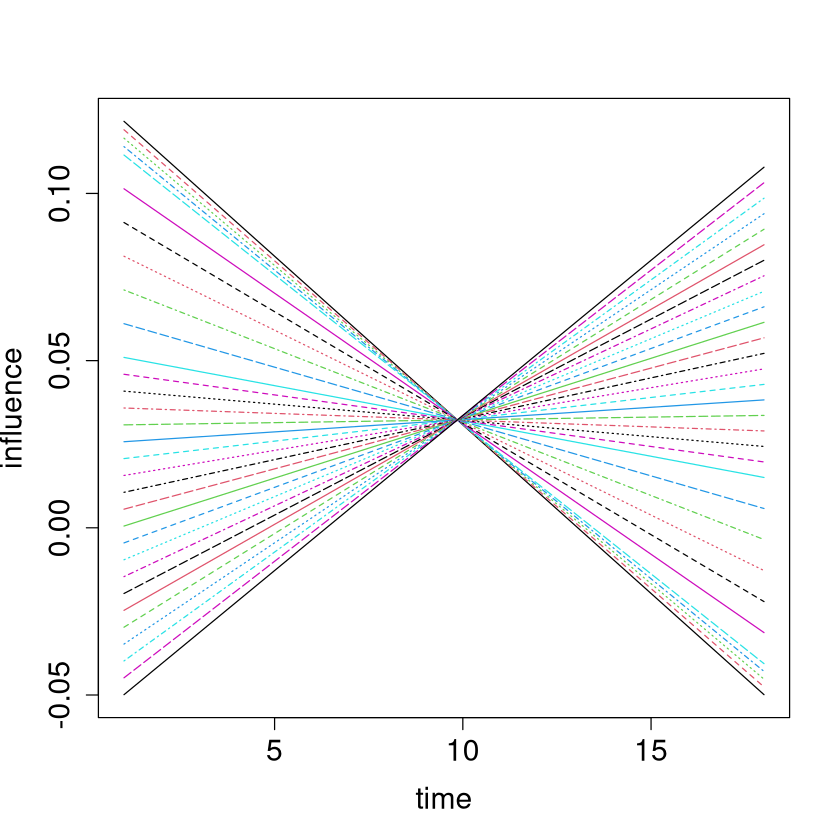

In [17]:
# Or very large lambda

D2fdPar2 = fdPar(heightbasis12, Lfdobj=int2Lfd(2), lambda=1e10)
syfd2 = smooth.basis(age, heightmat, D2fdPar2)
plotfit.fd(heightmat, age, syfd2$fd)

y2cMap2 = syfd2$y2cMap
hatMat2 = bvals%*%y2cMap2

matplot(age, hatMat2, type='l', xlab='time', ylab='influence', 
        cex.lab=1.5, cex.axis=1.5)

Multiple plots:  Click in the plot to advance to the next plot


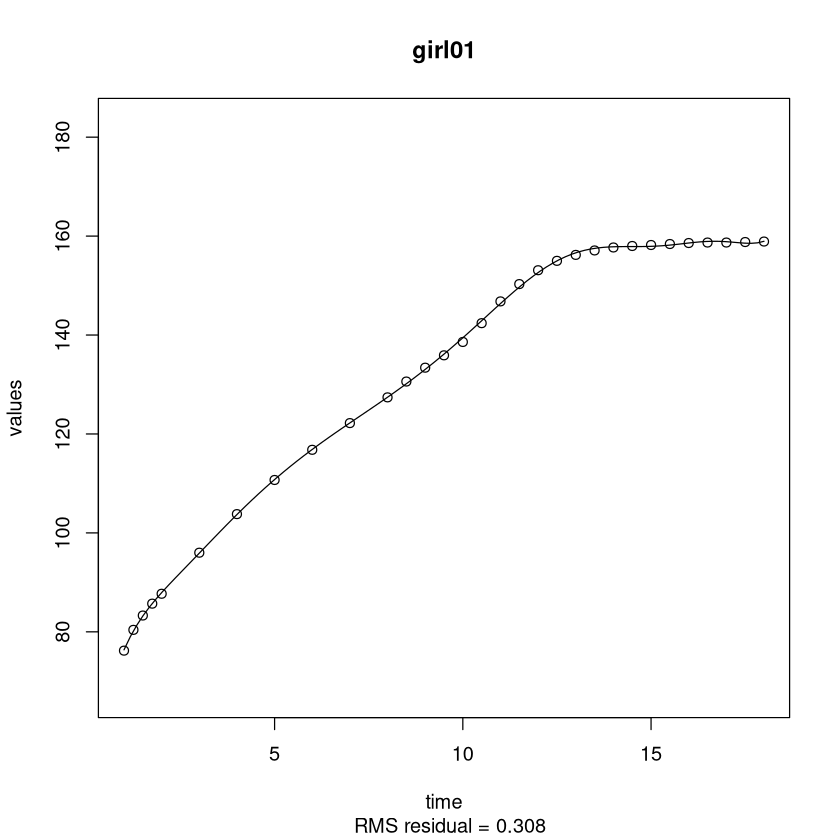

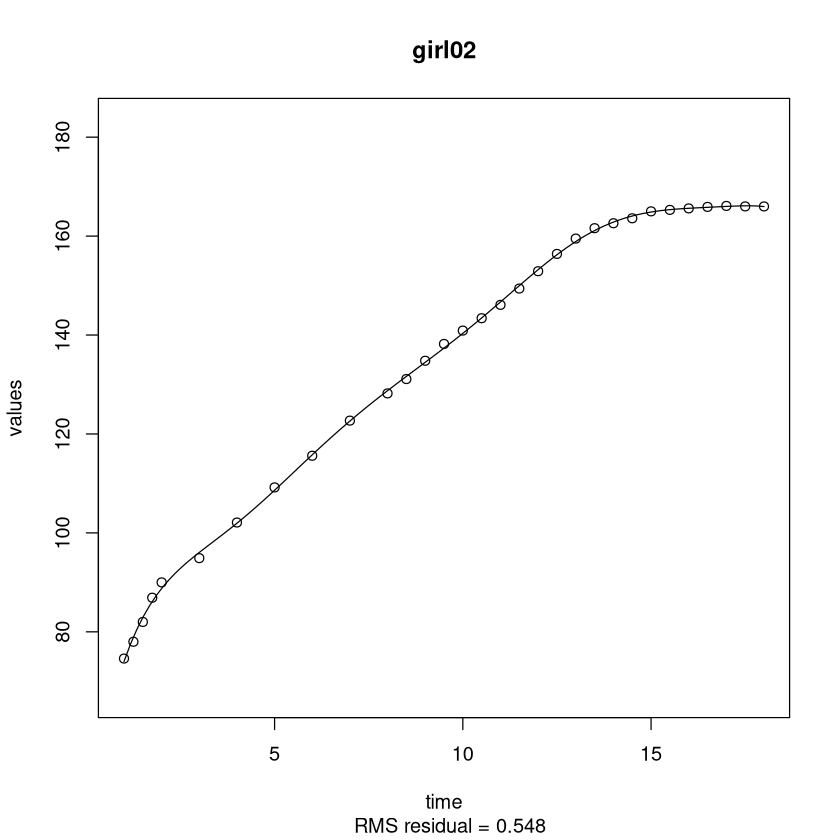

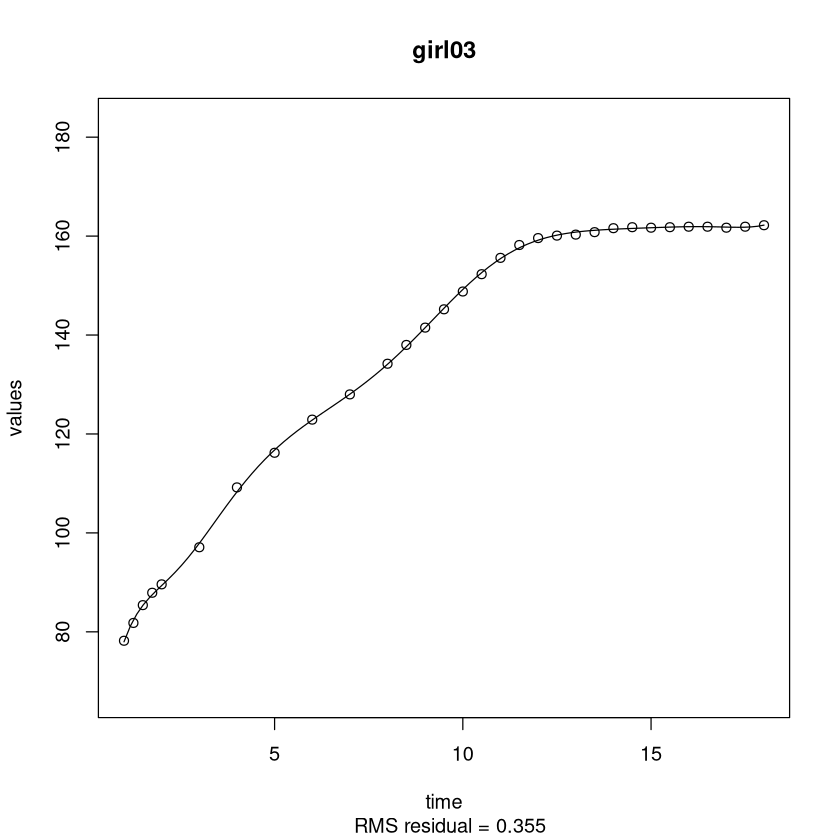

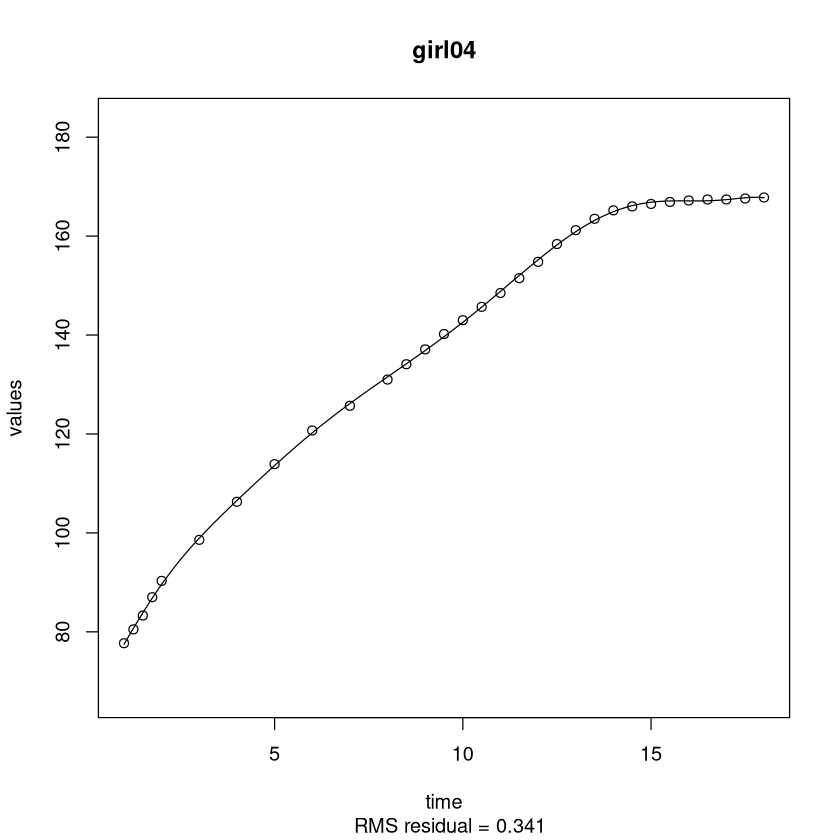

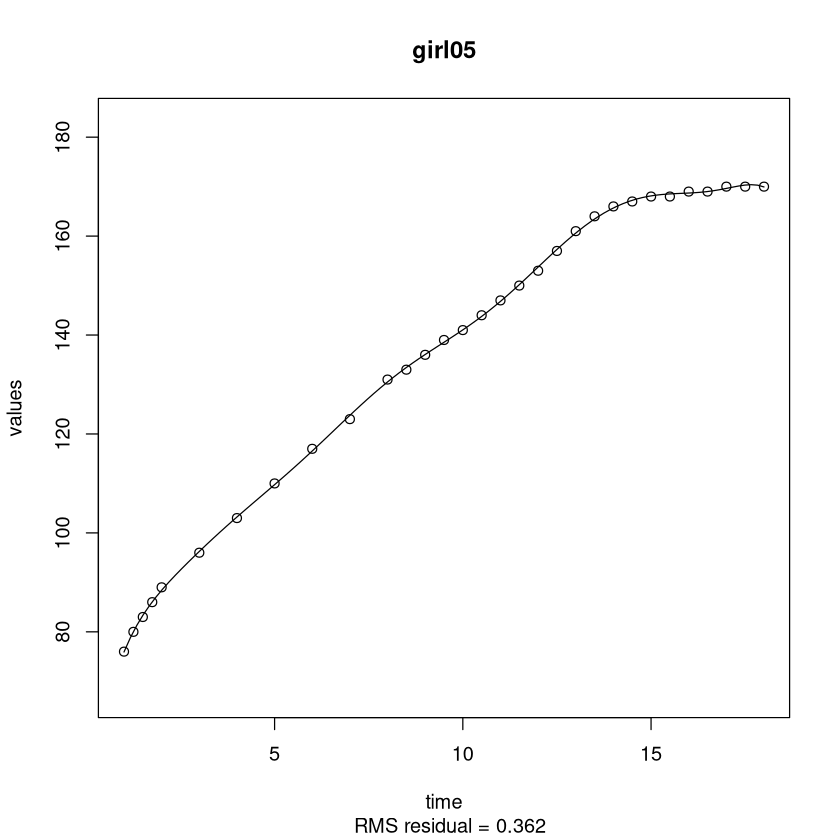

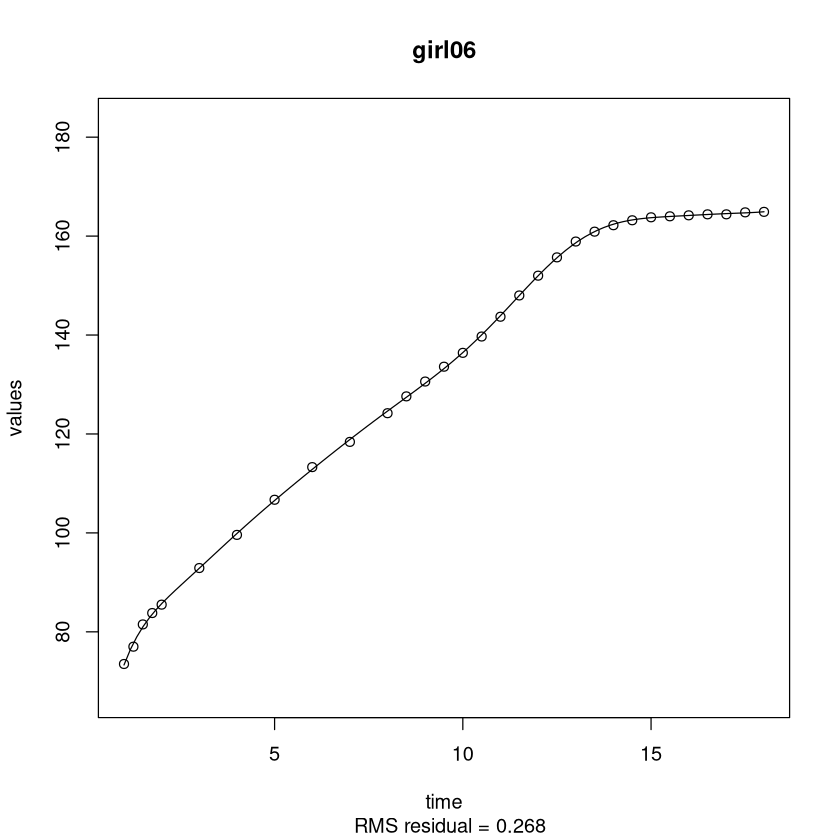

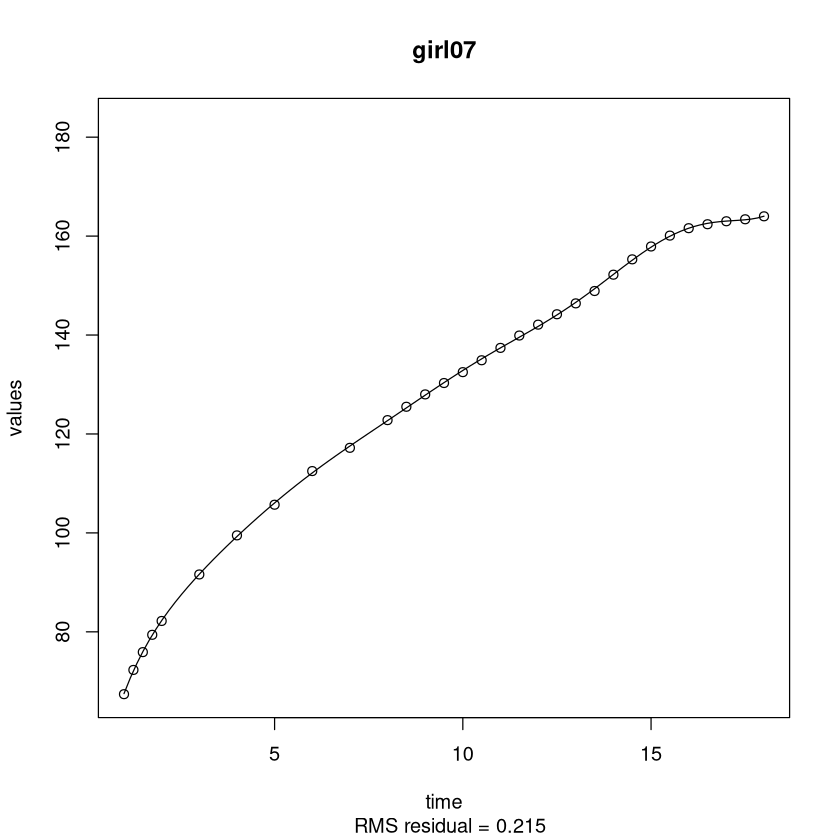

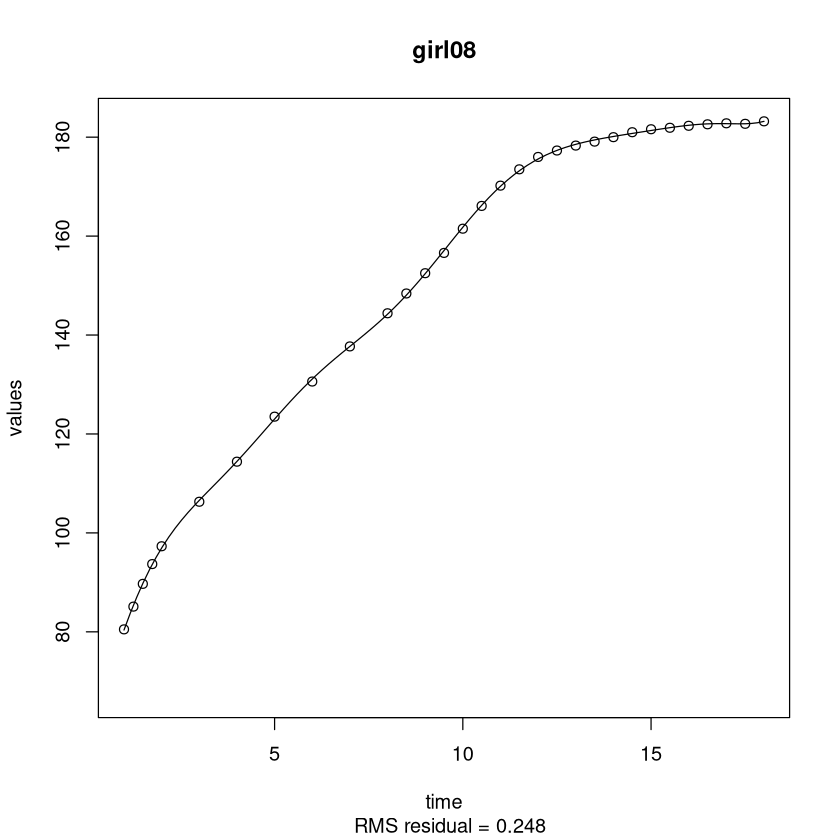

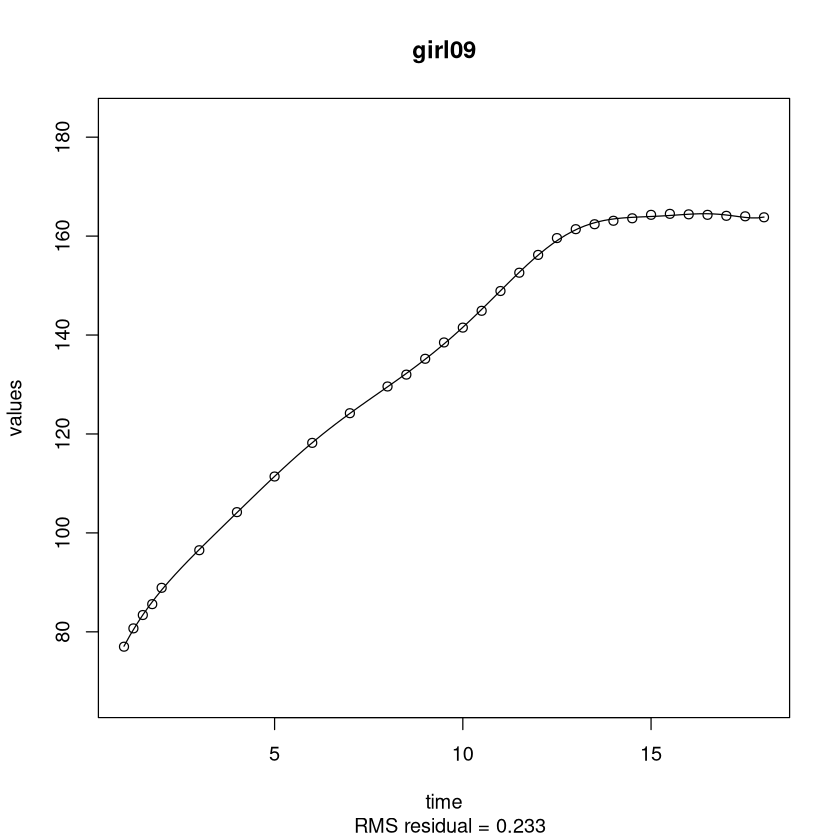

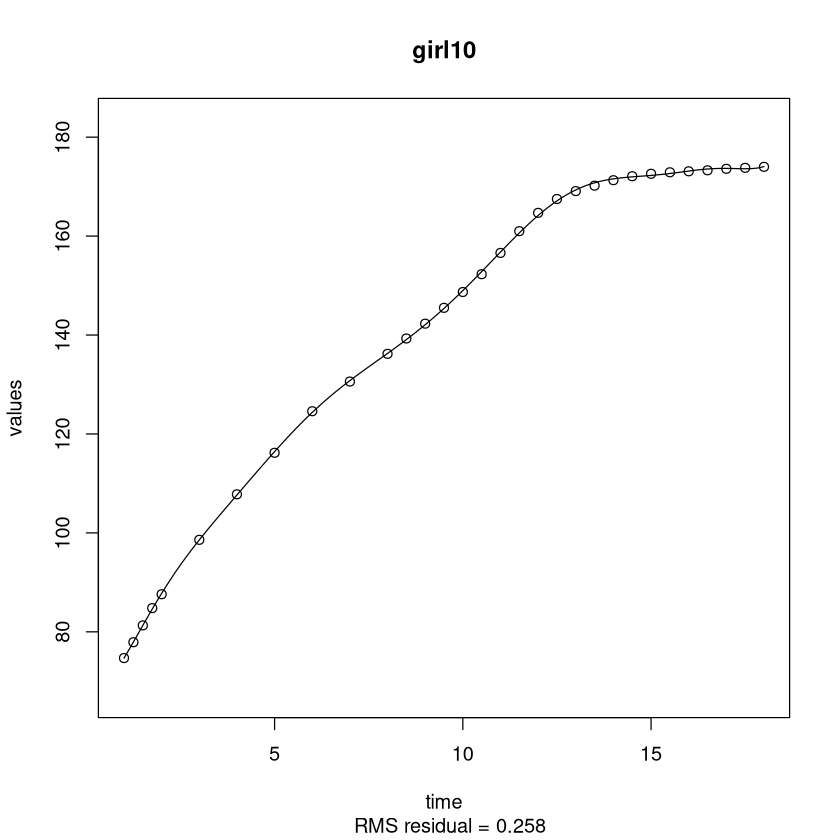

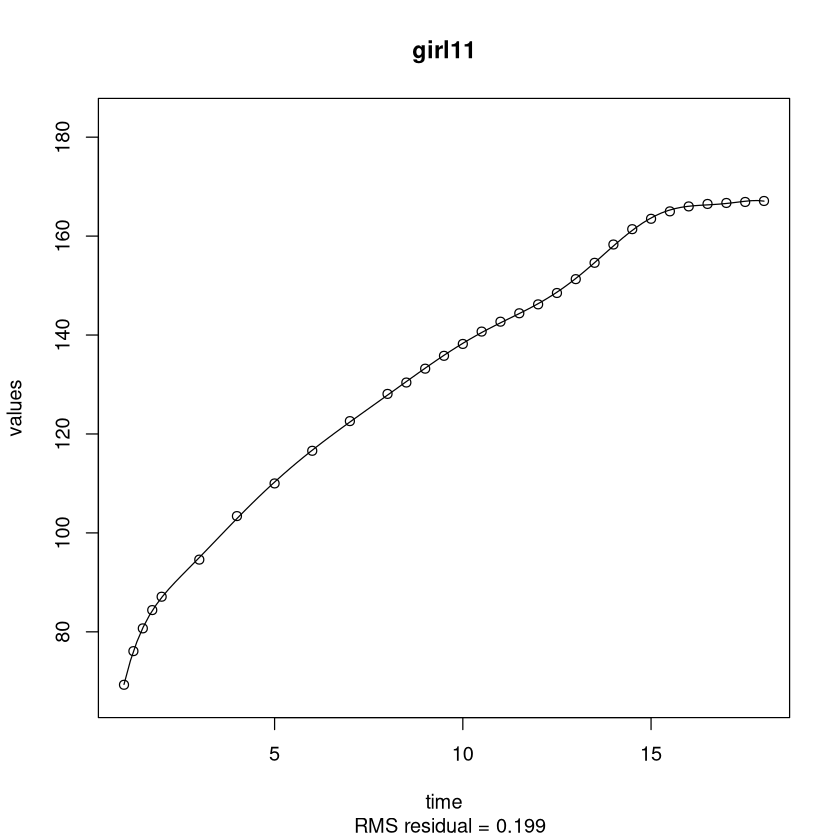

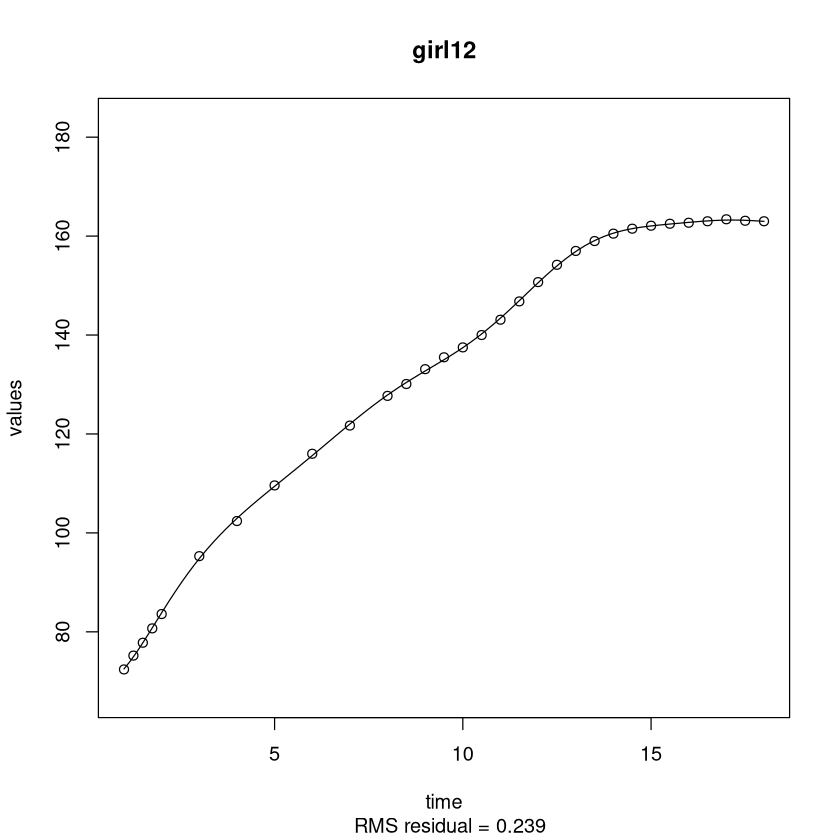

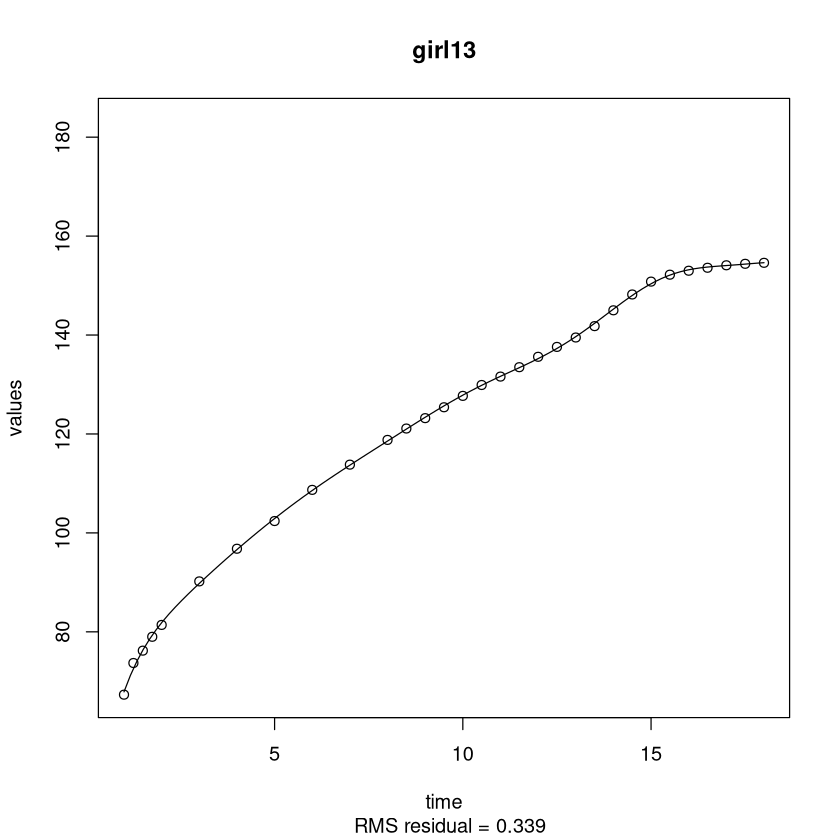

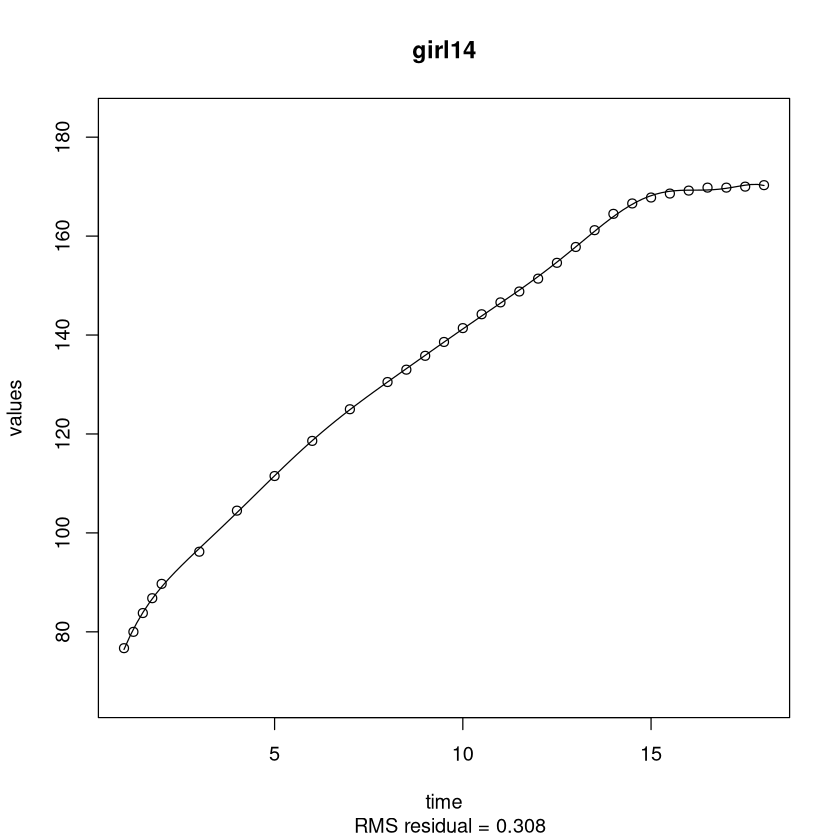

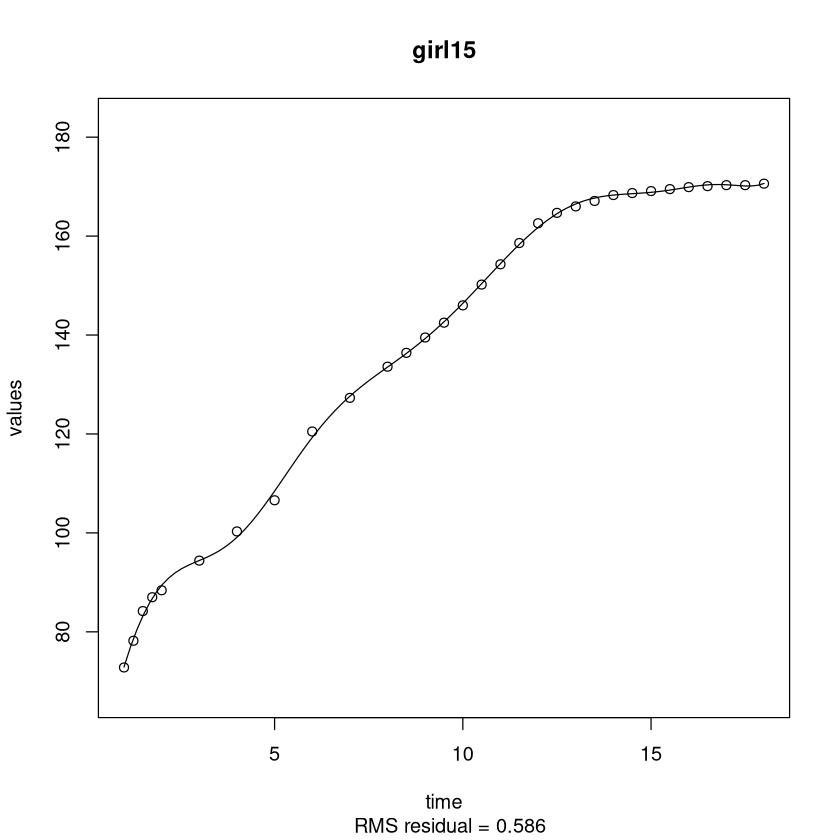

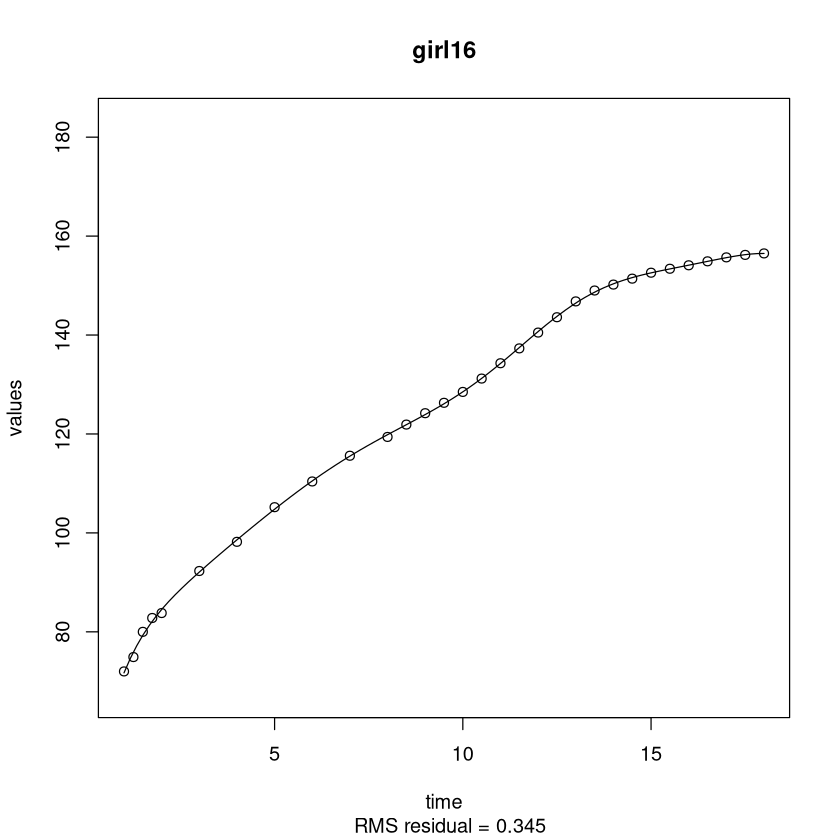

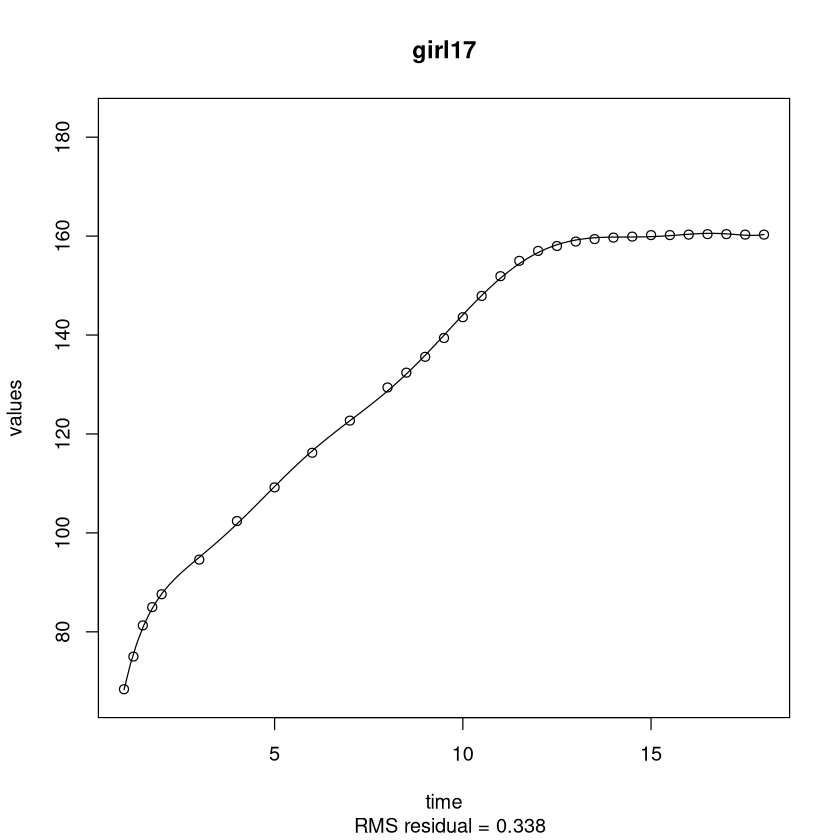

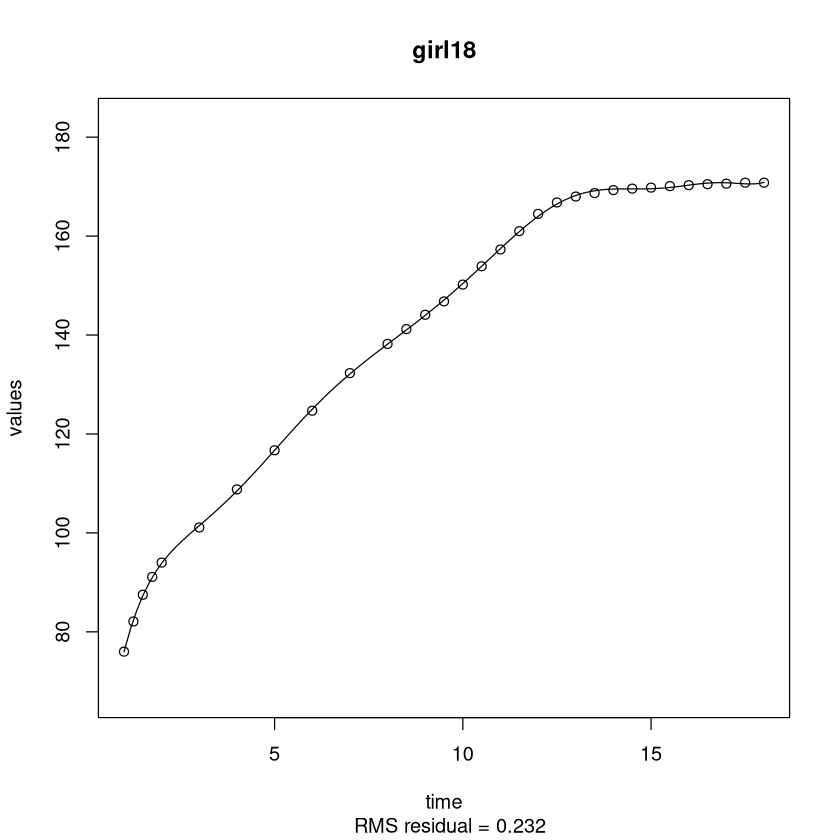

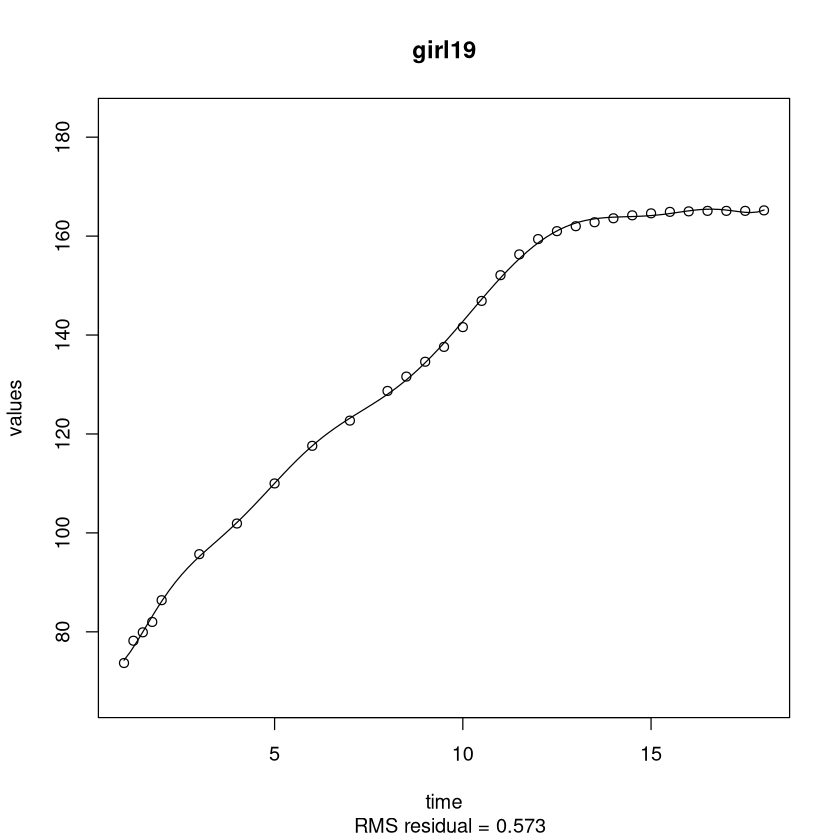

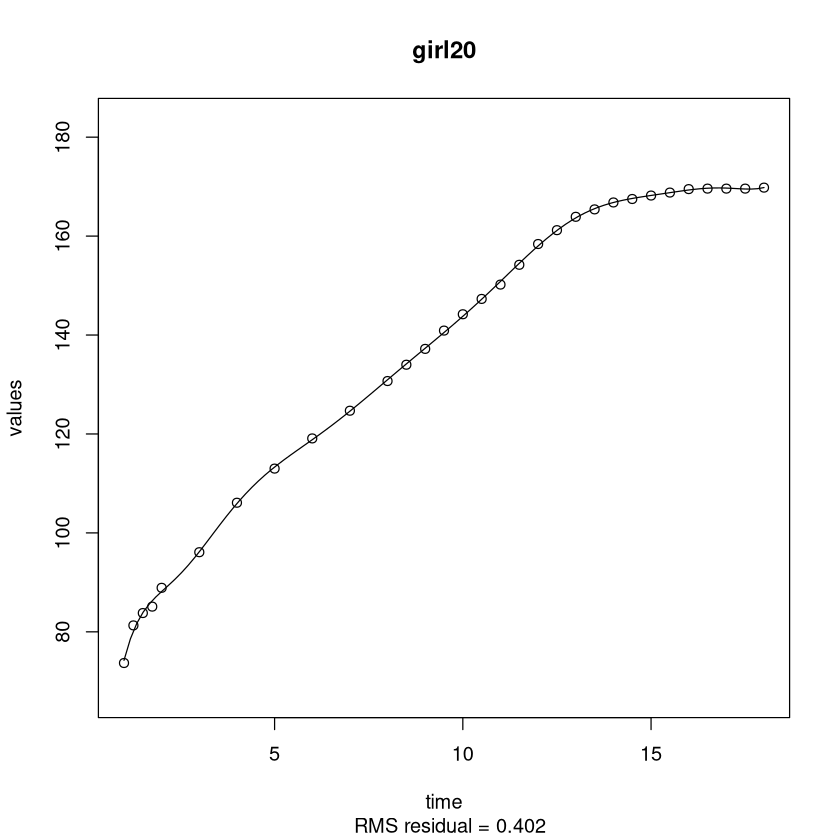

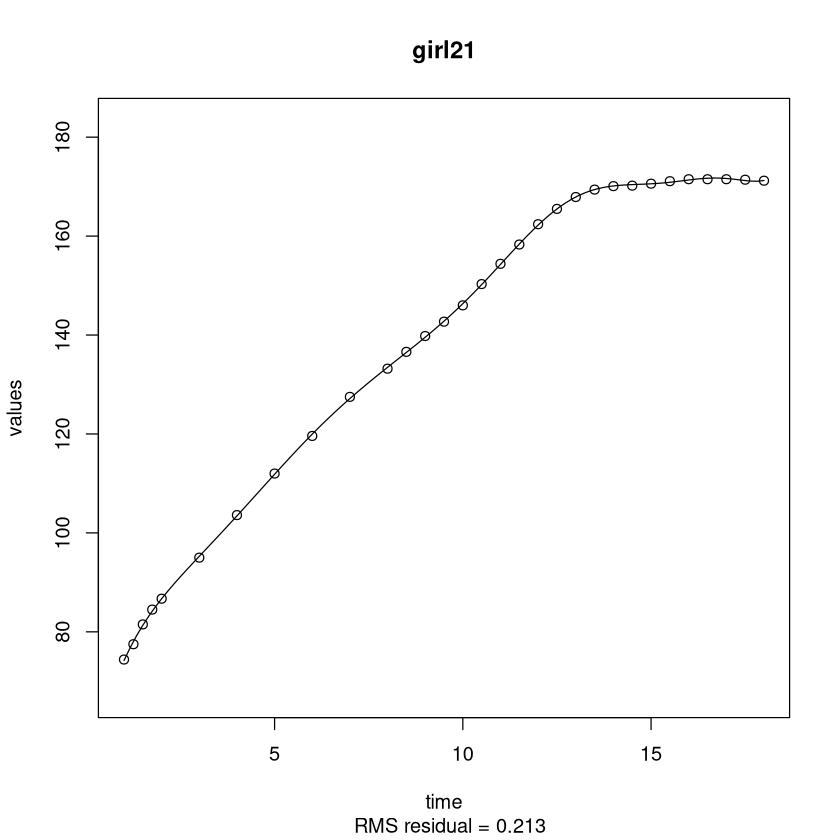

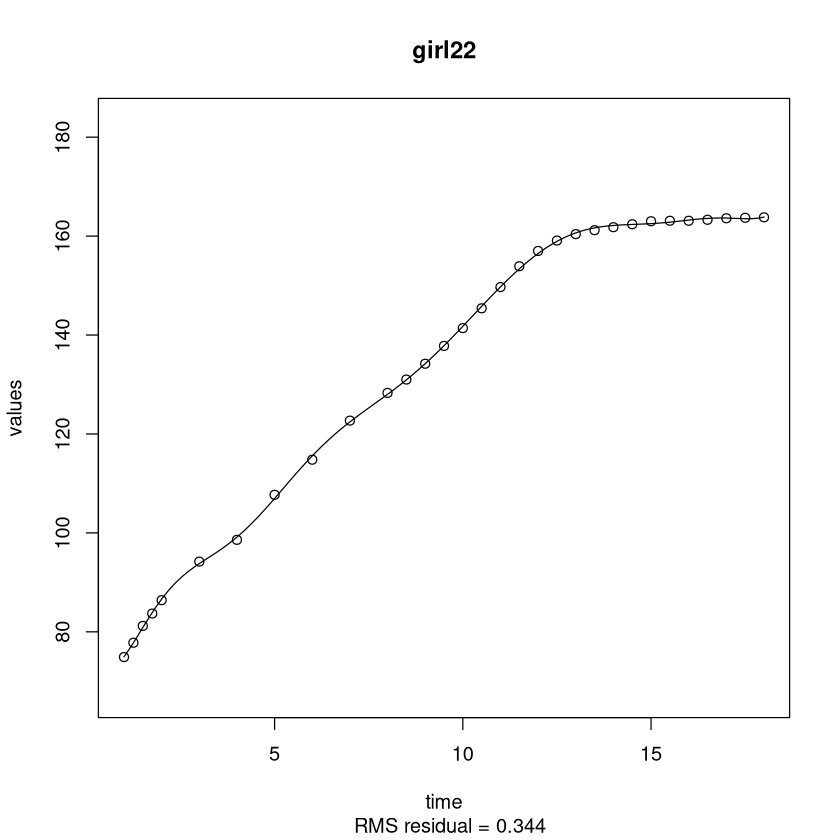

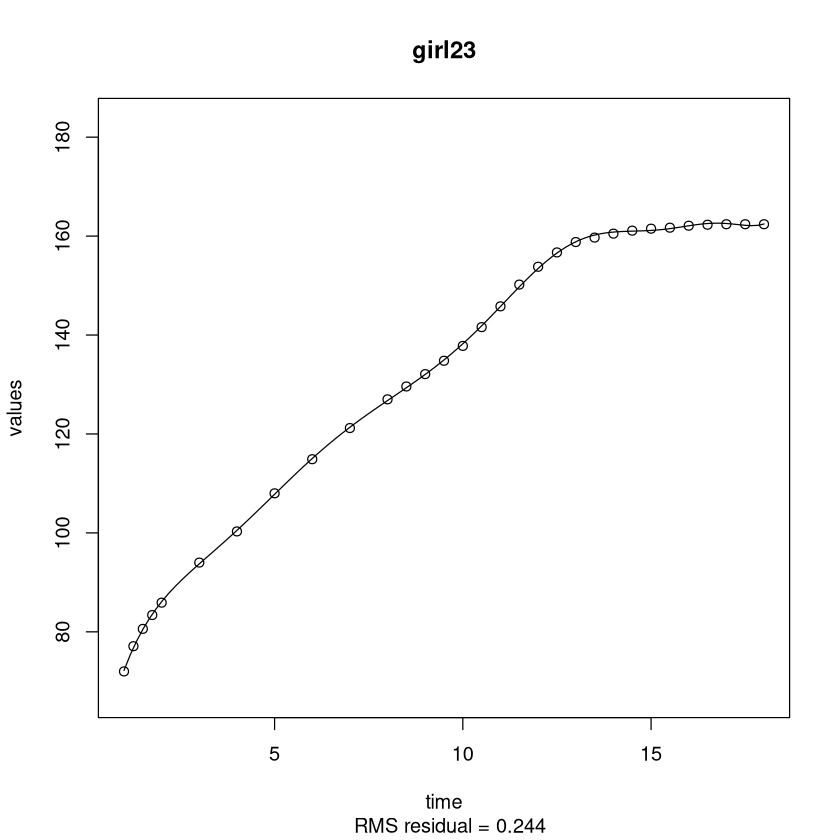

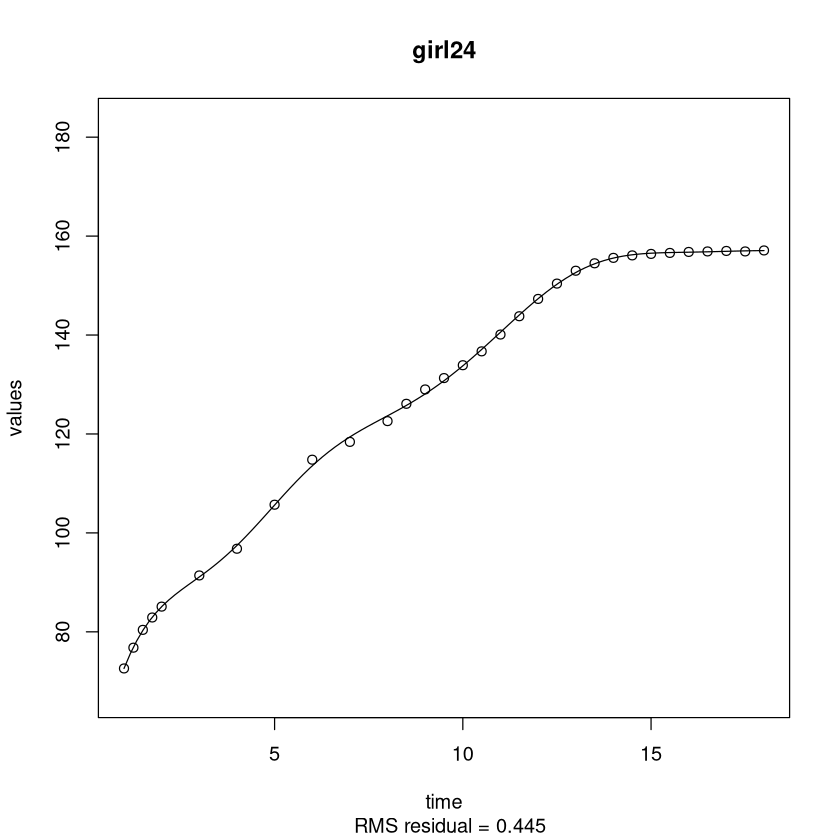

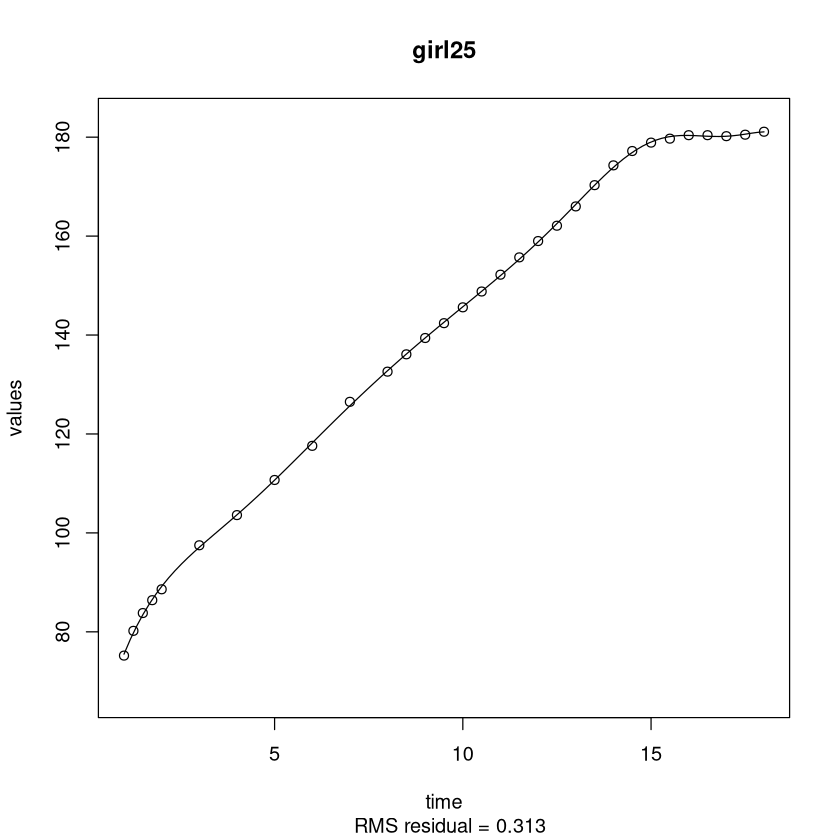

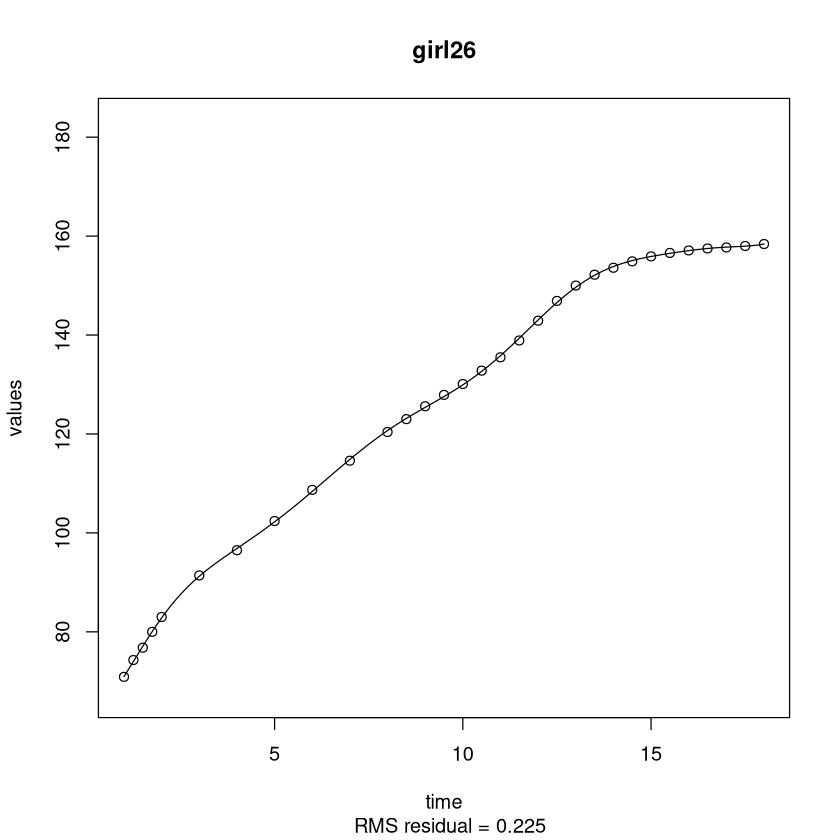

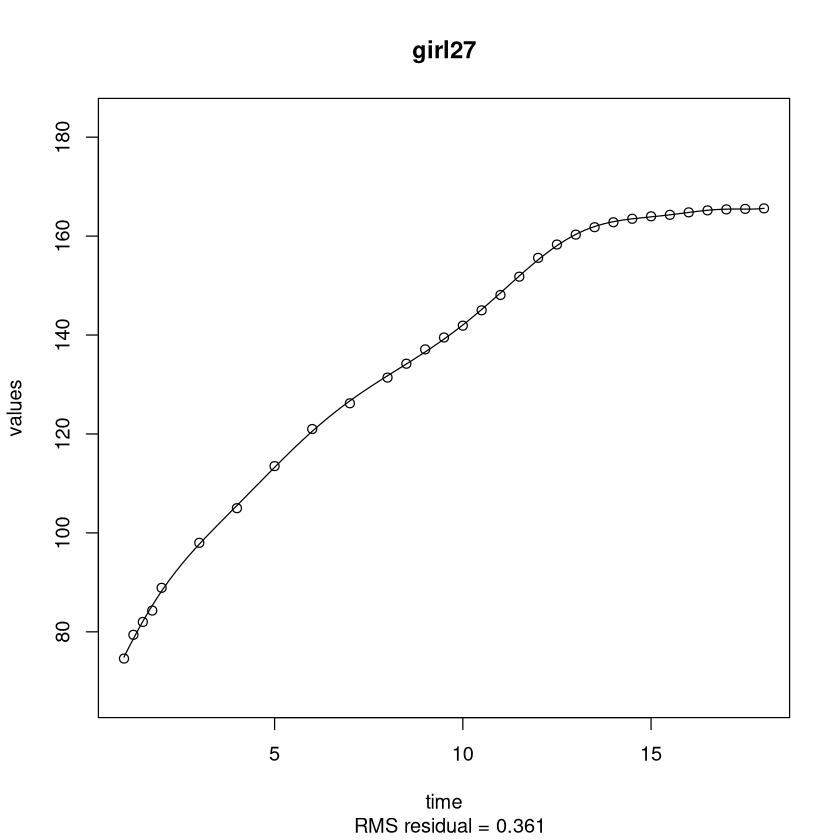

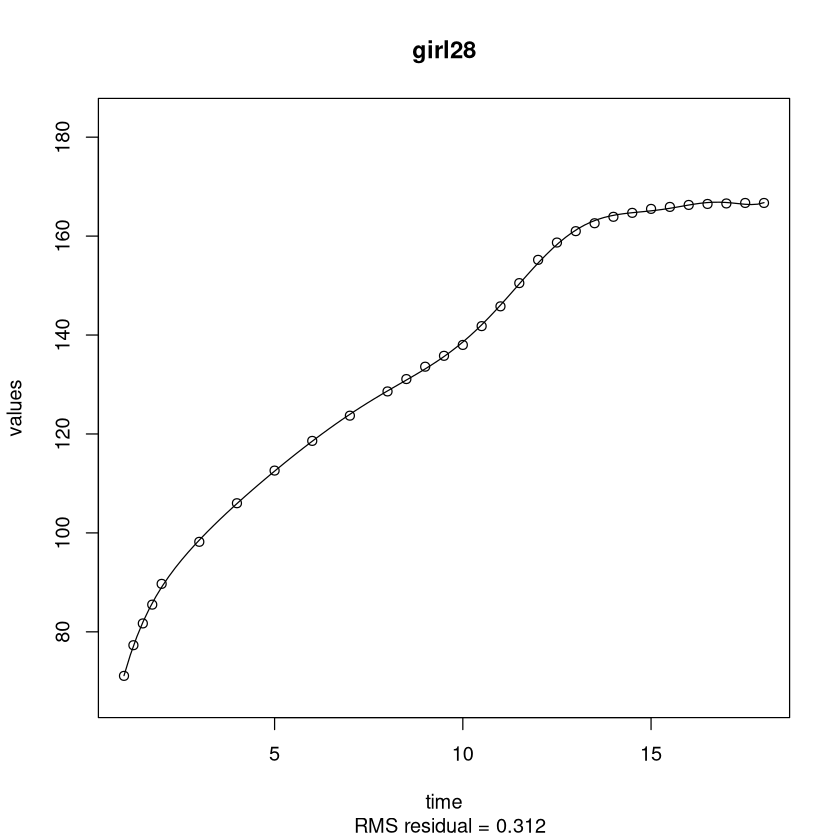

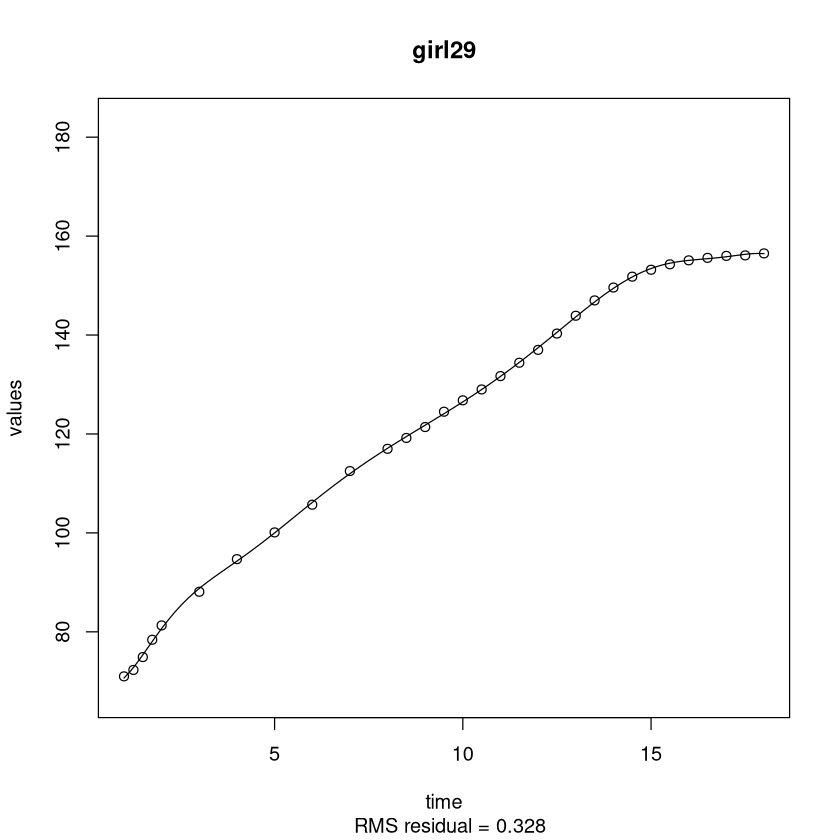

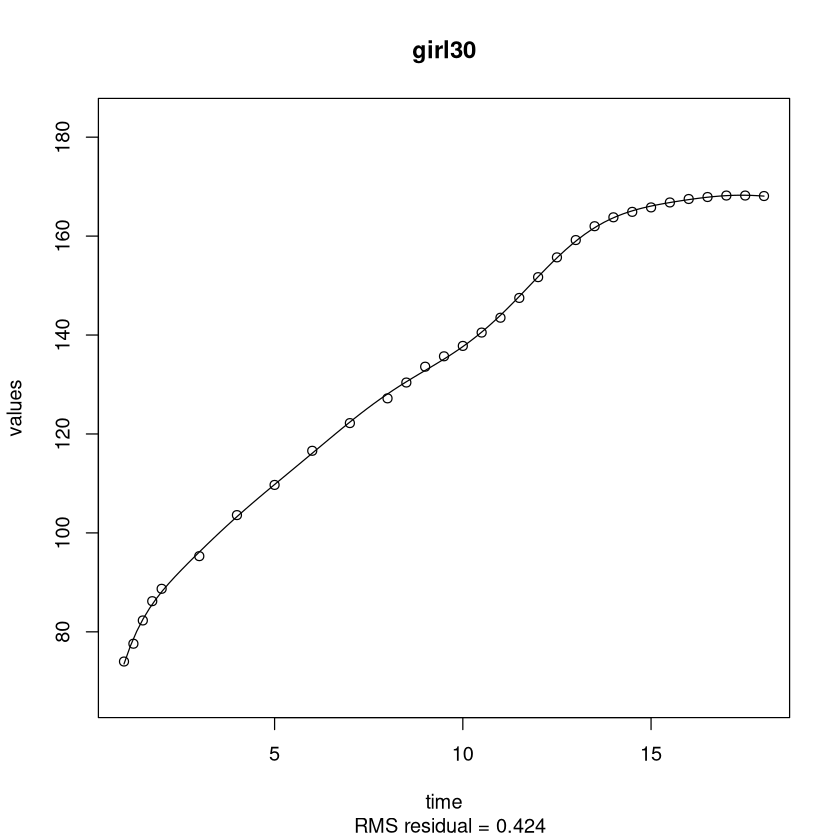

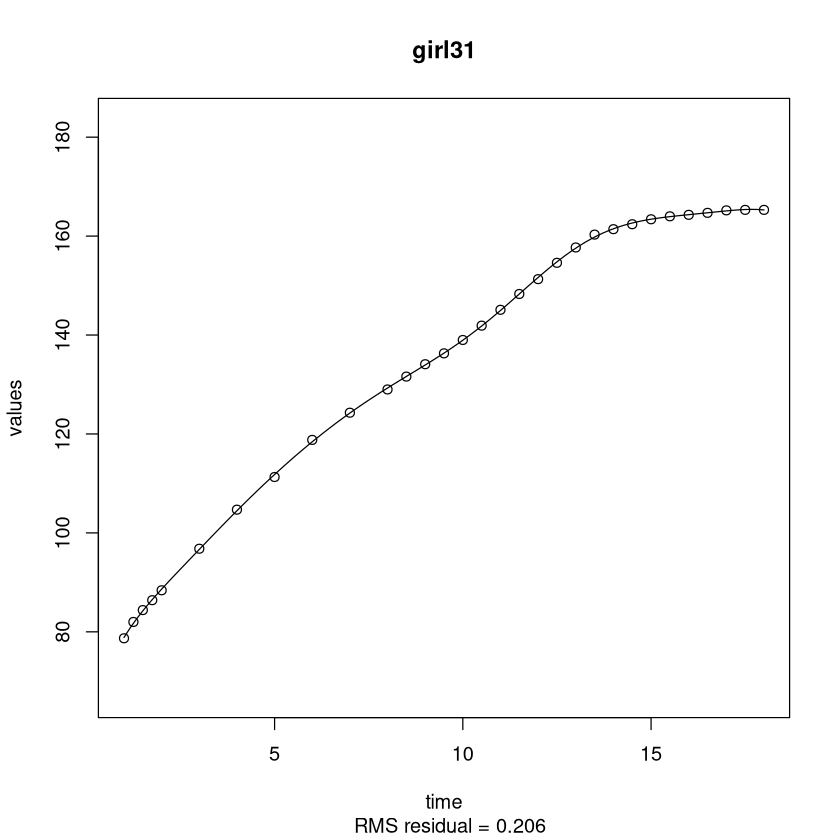

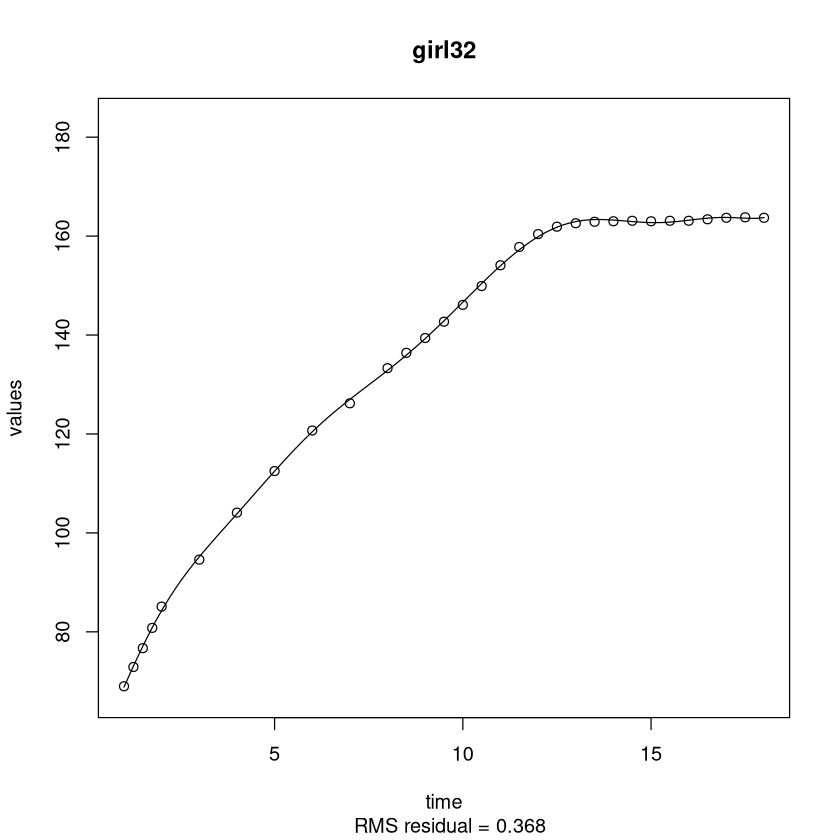

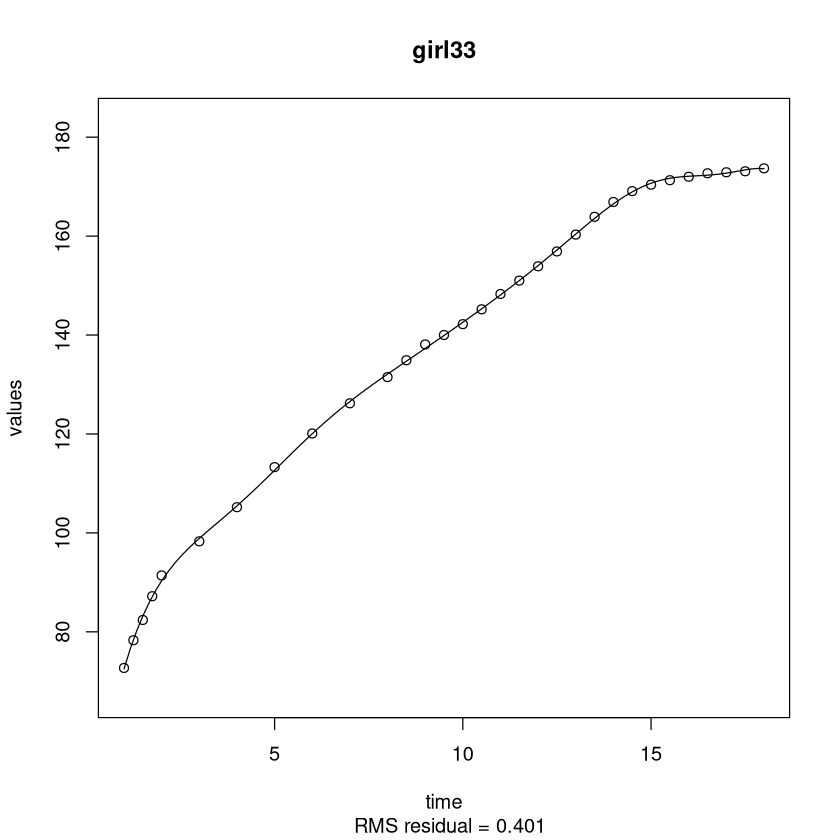

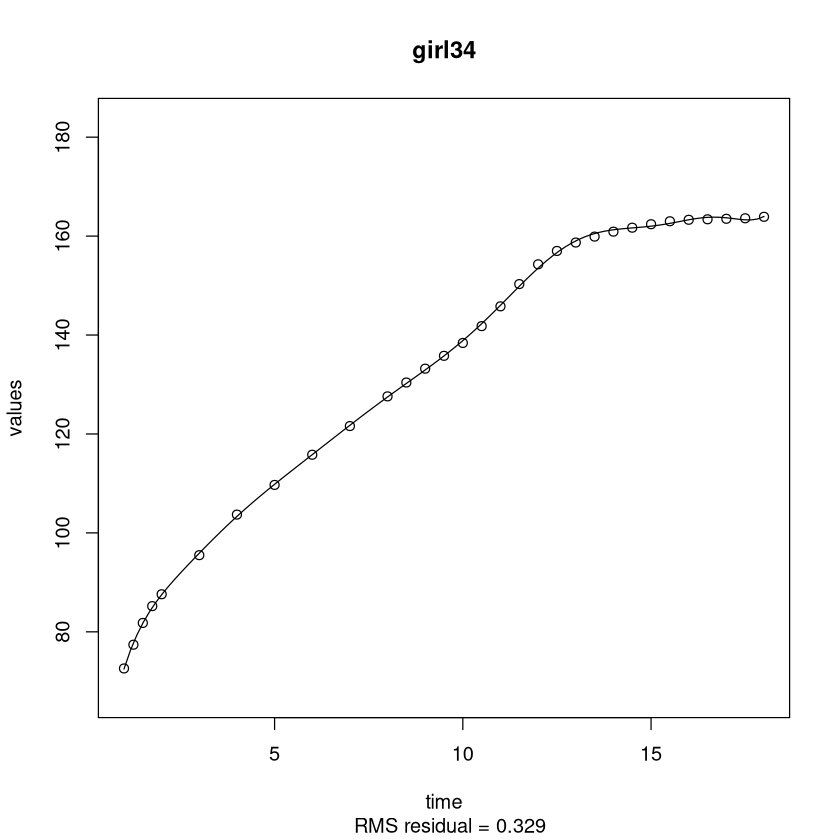

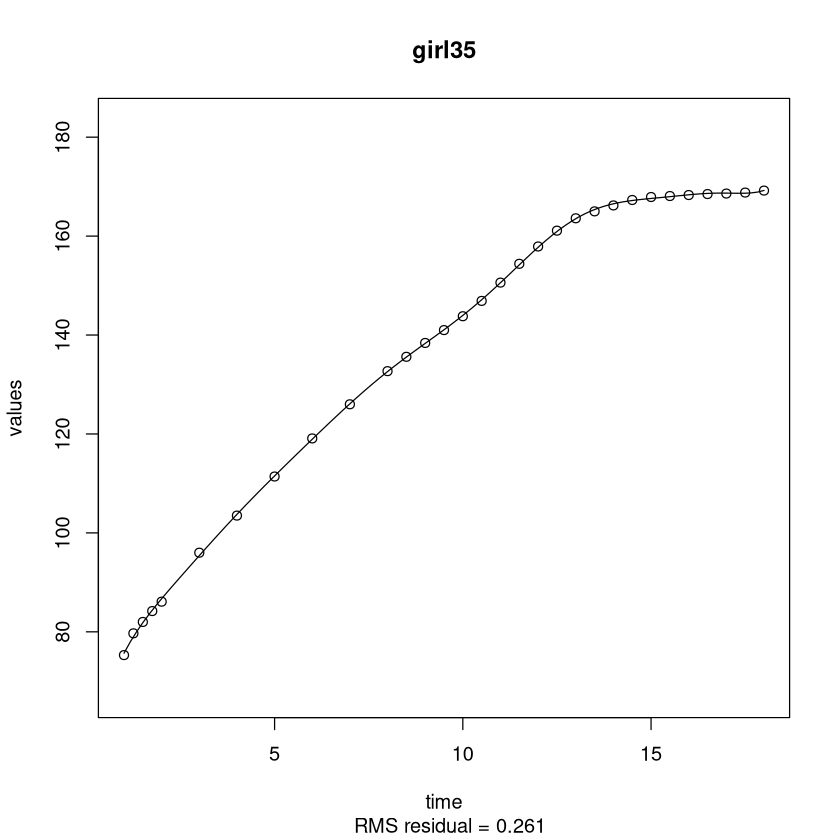

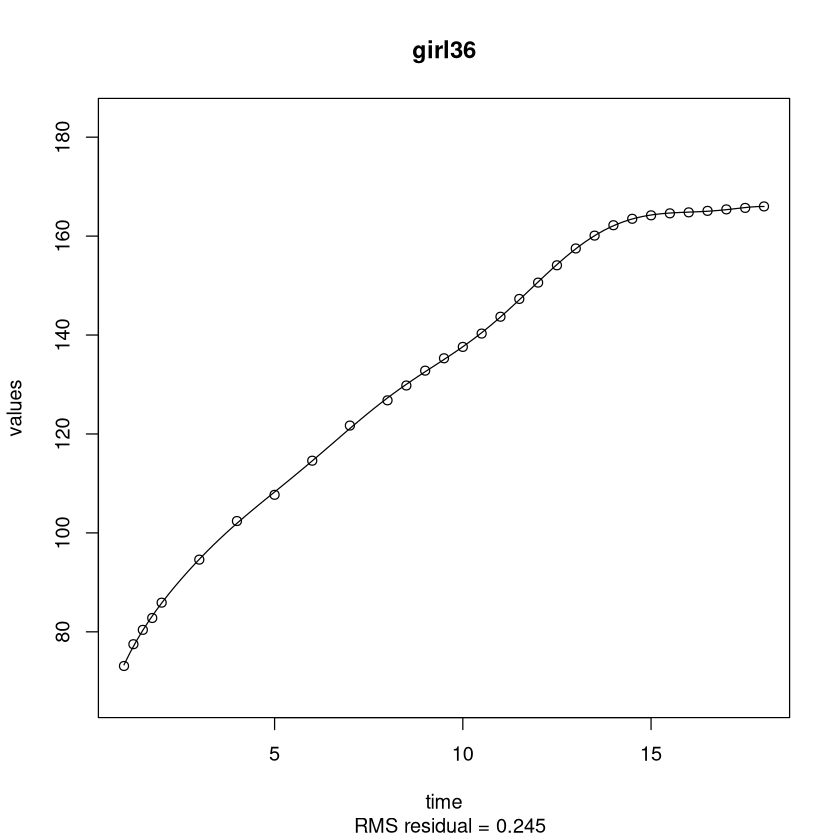

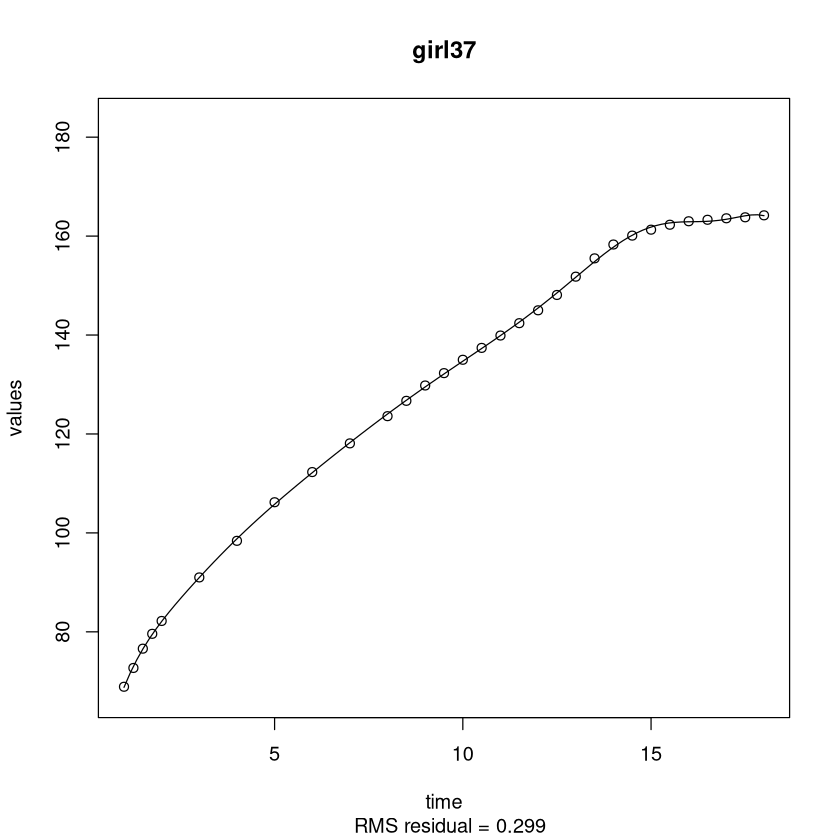

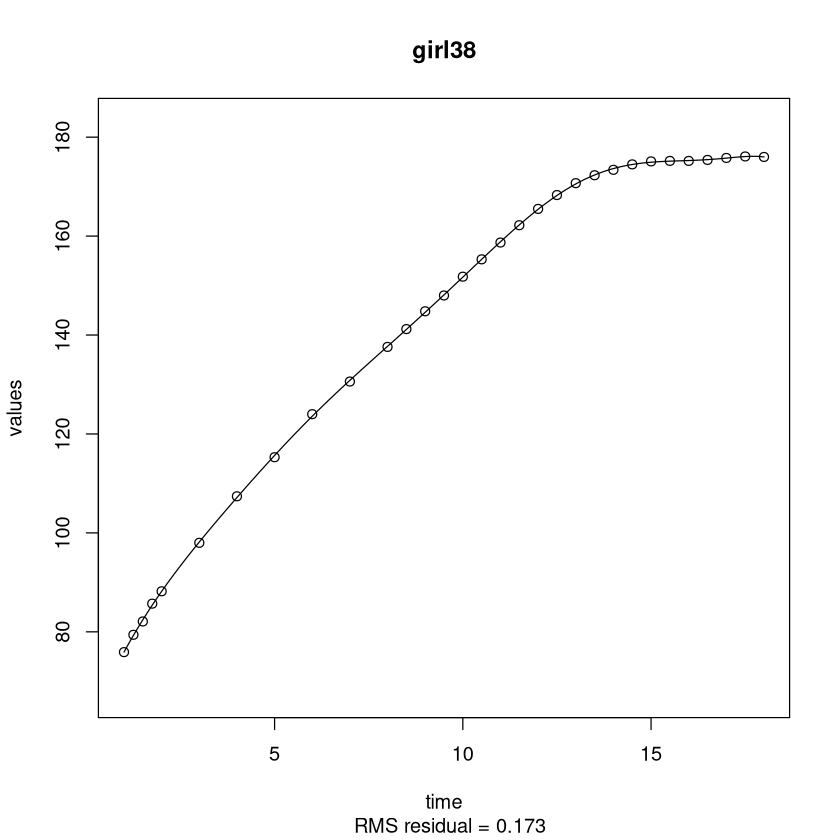

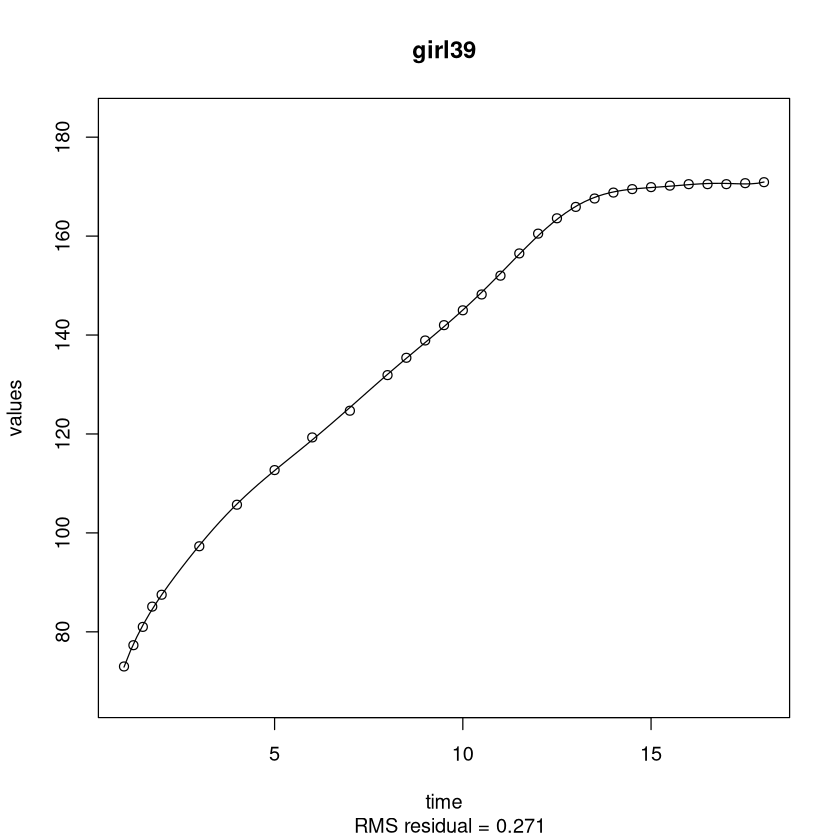

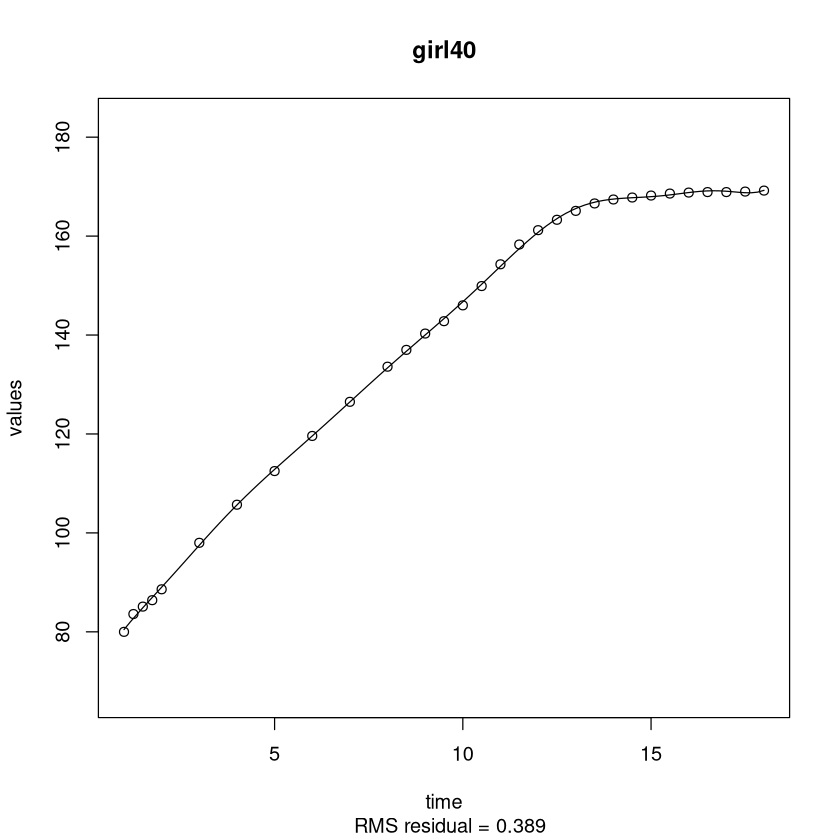

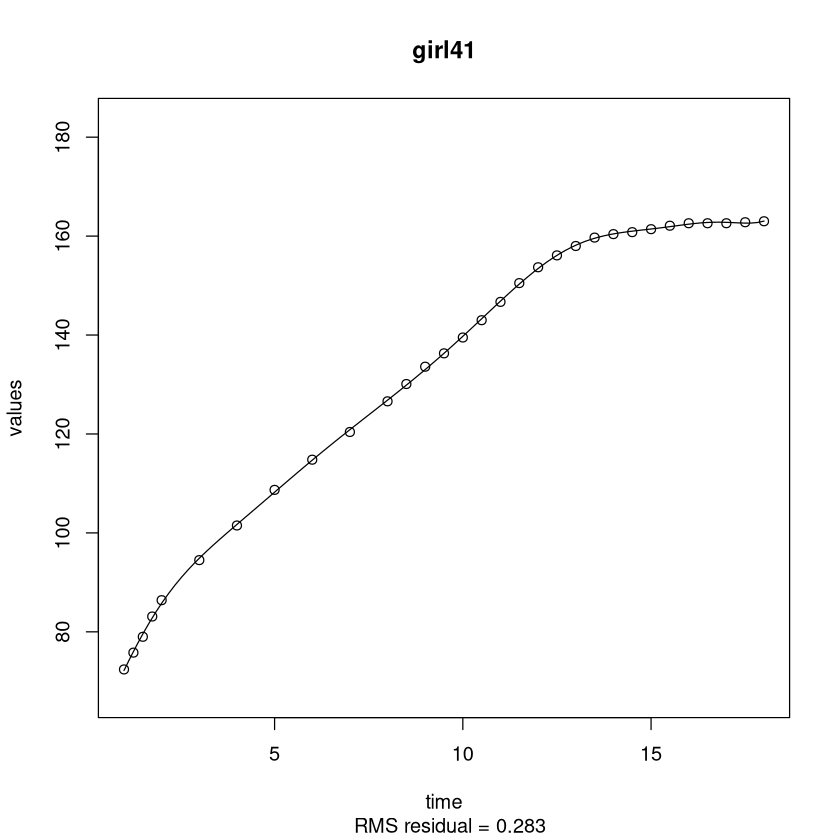

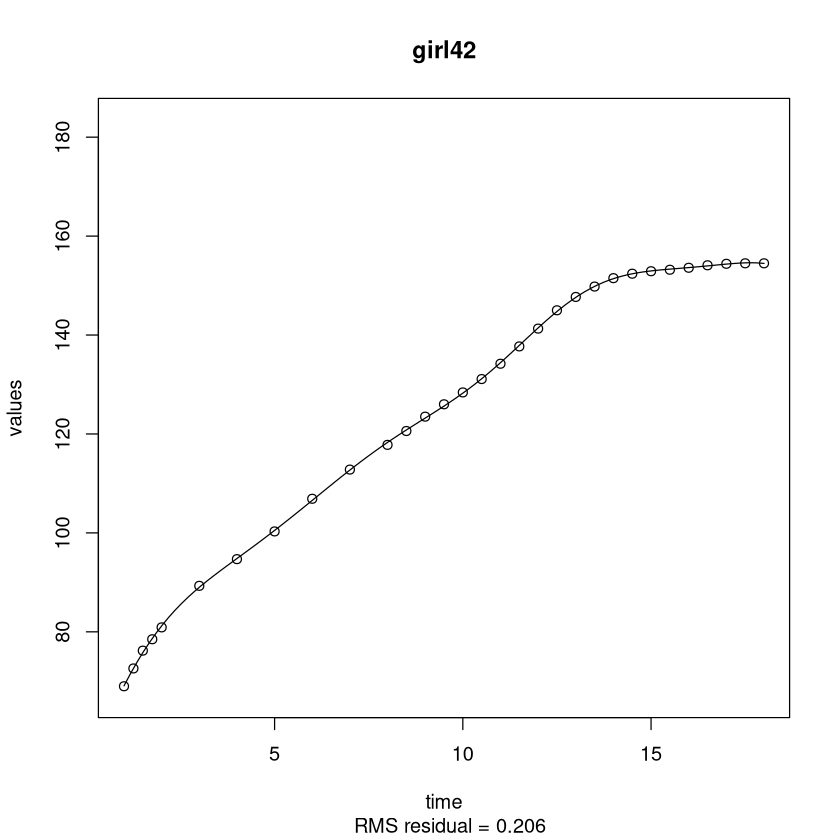

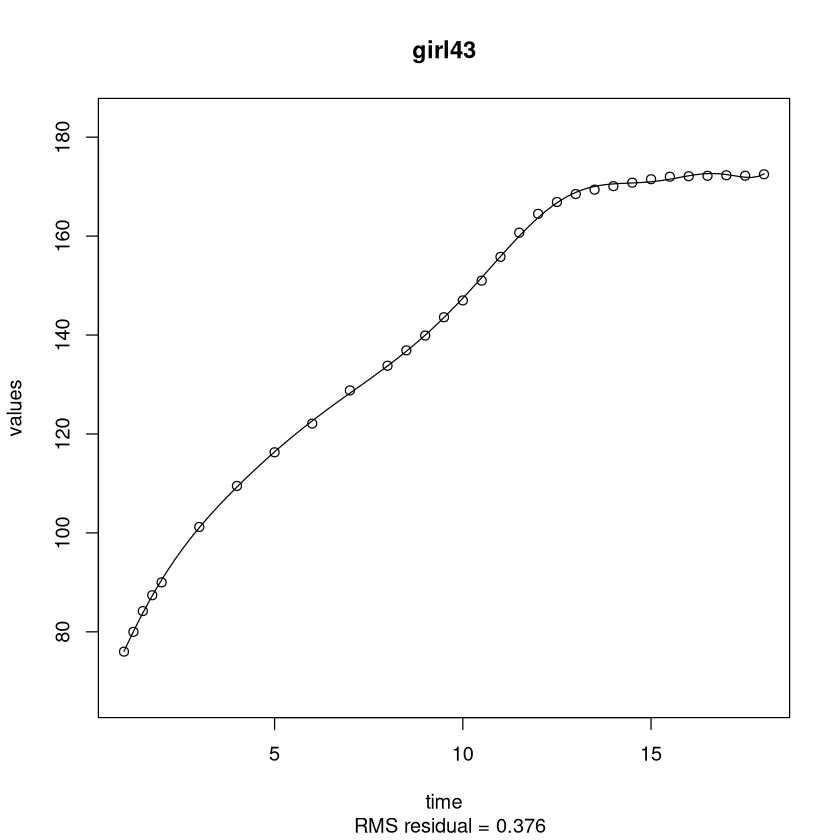

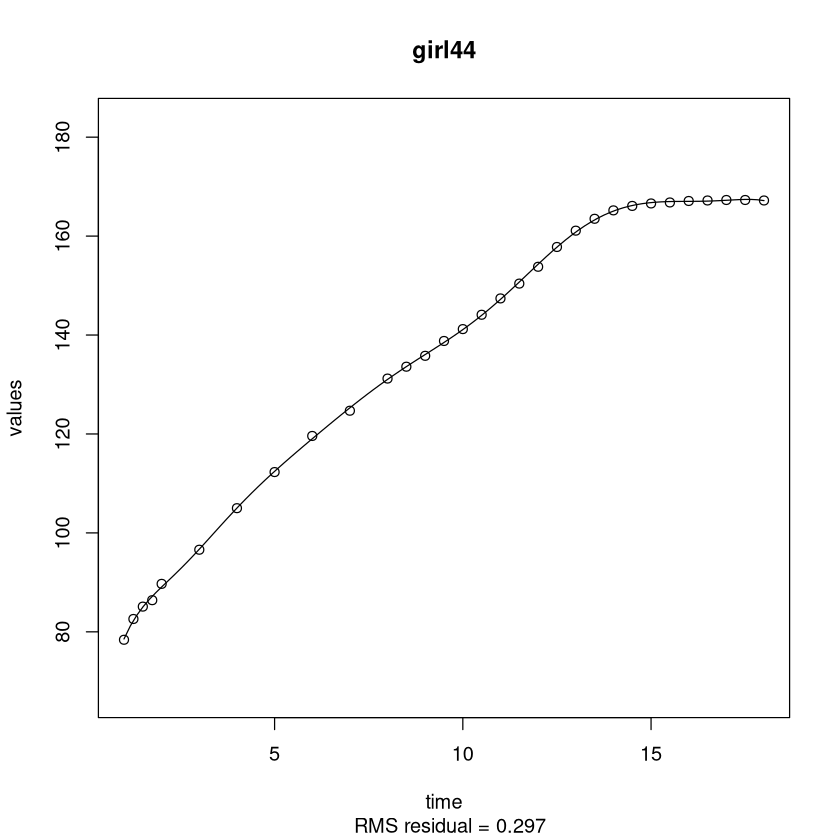

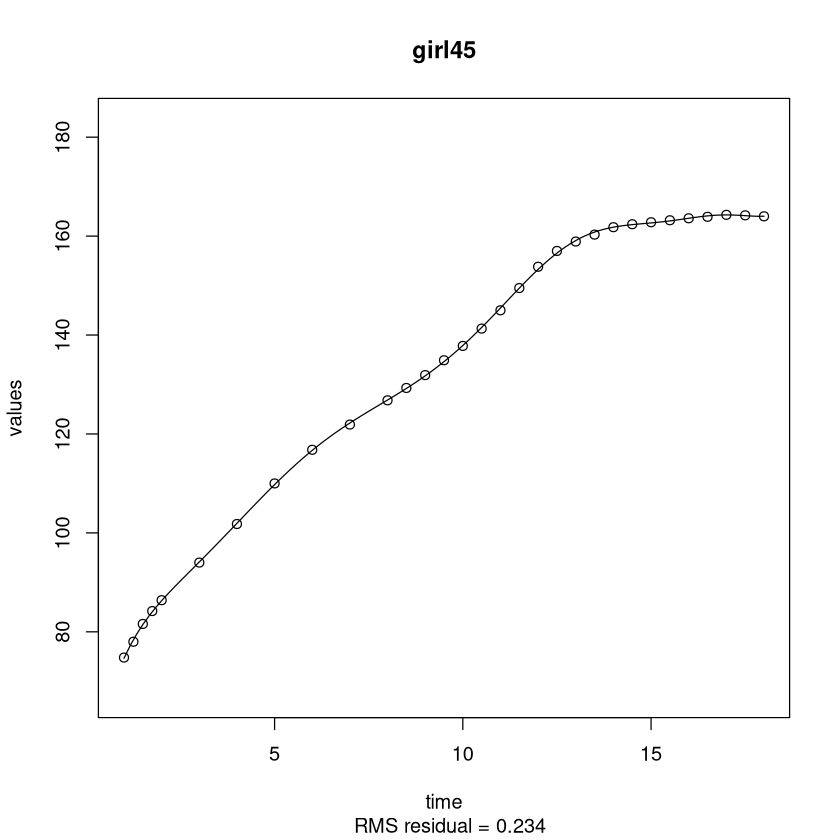

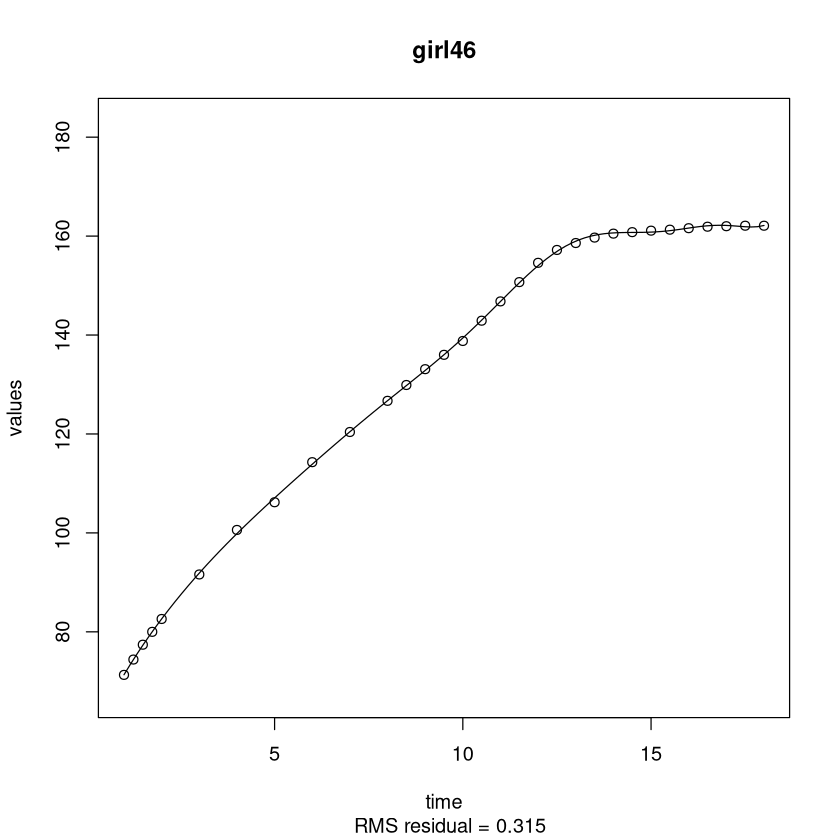

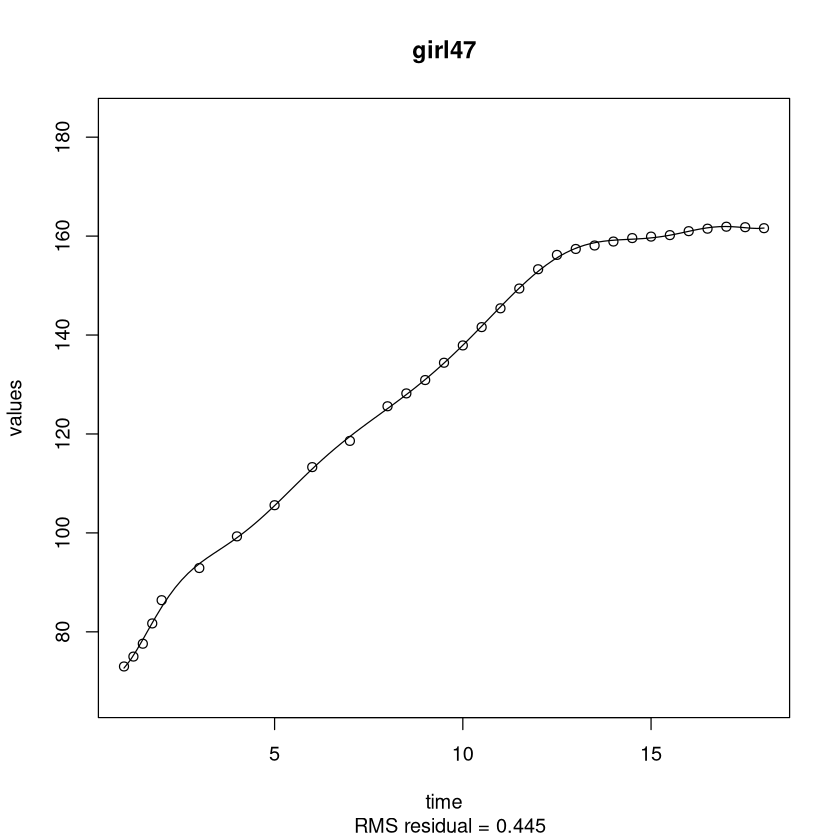

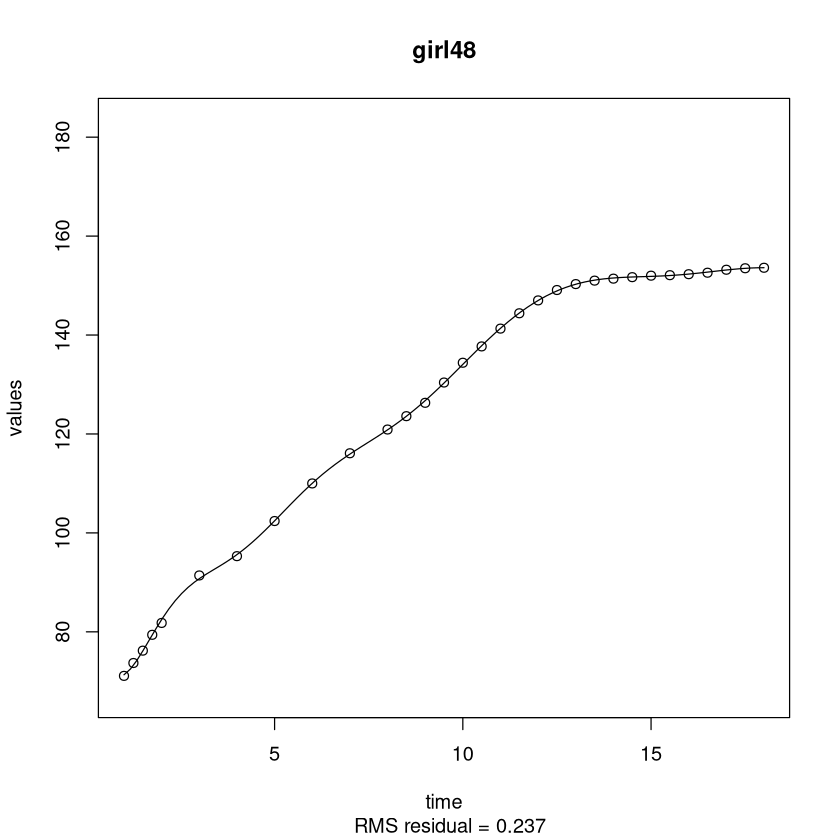

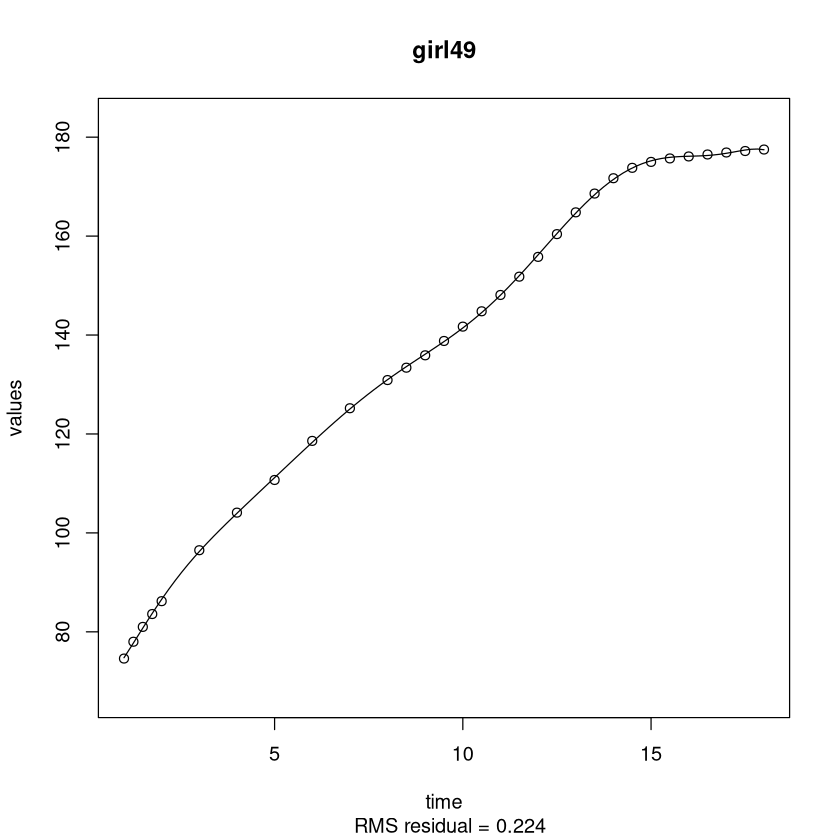

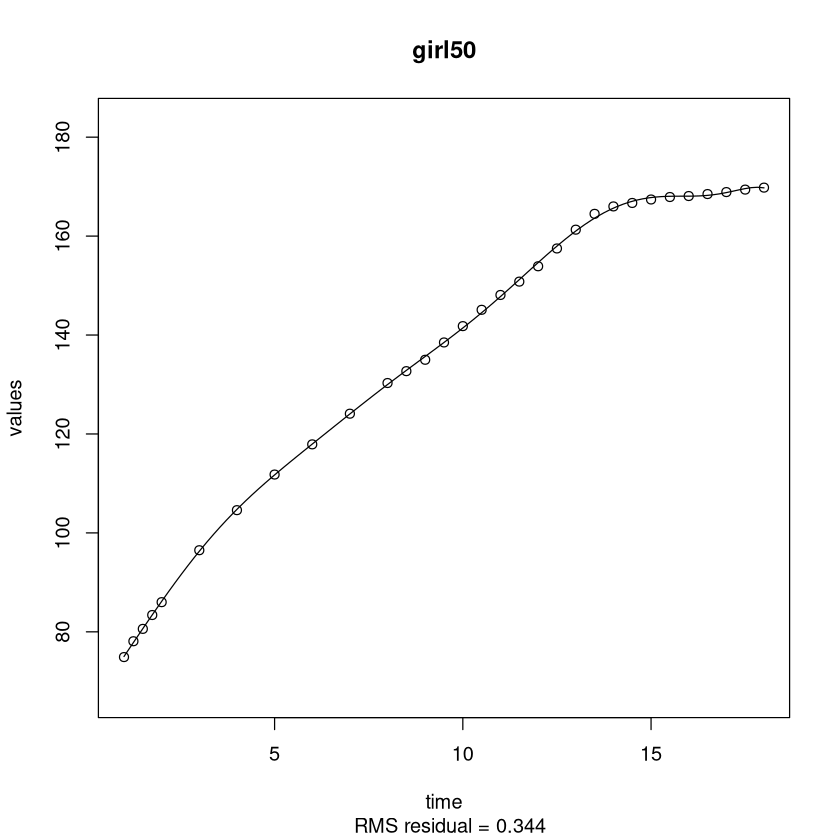

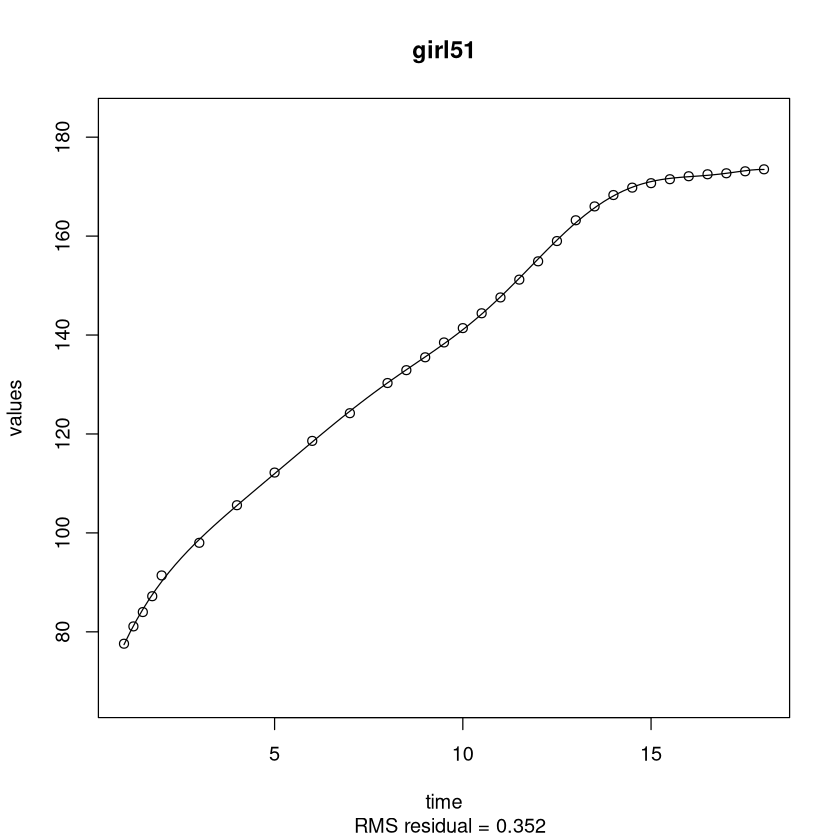

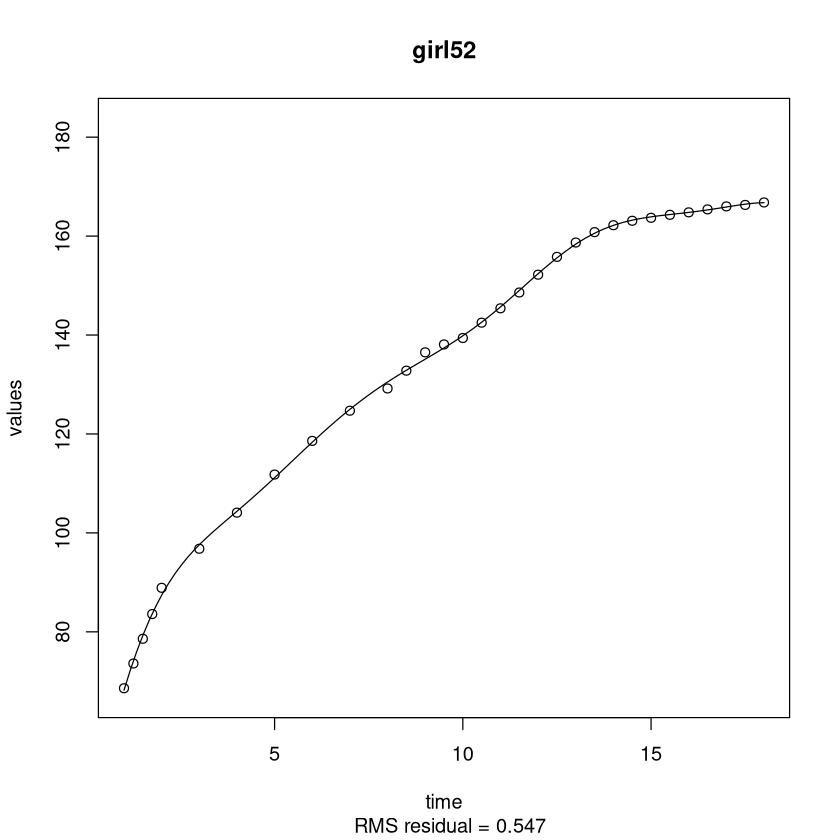

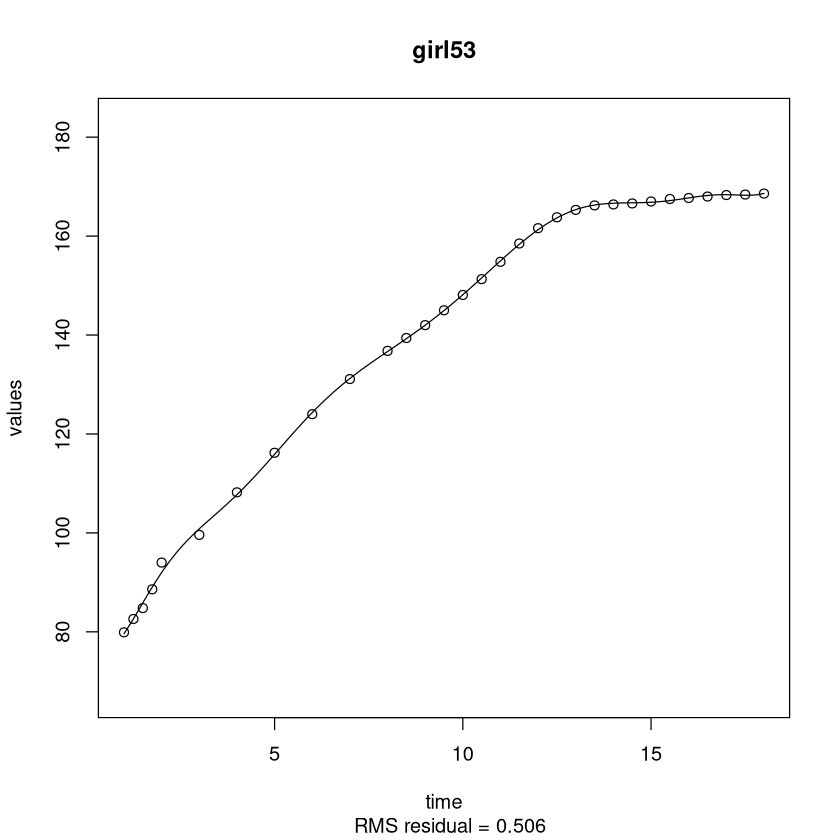

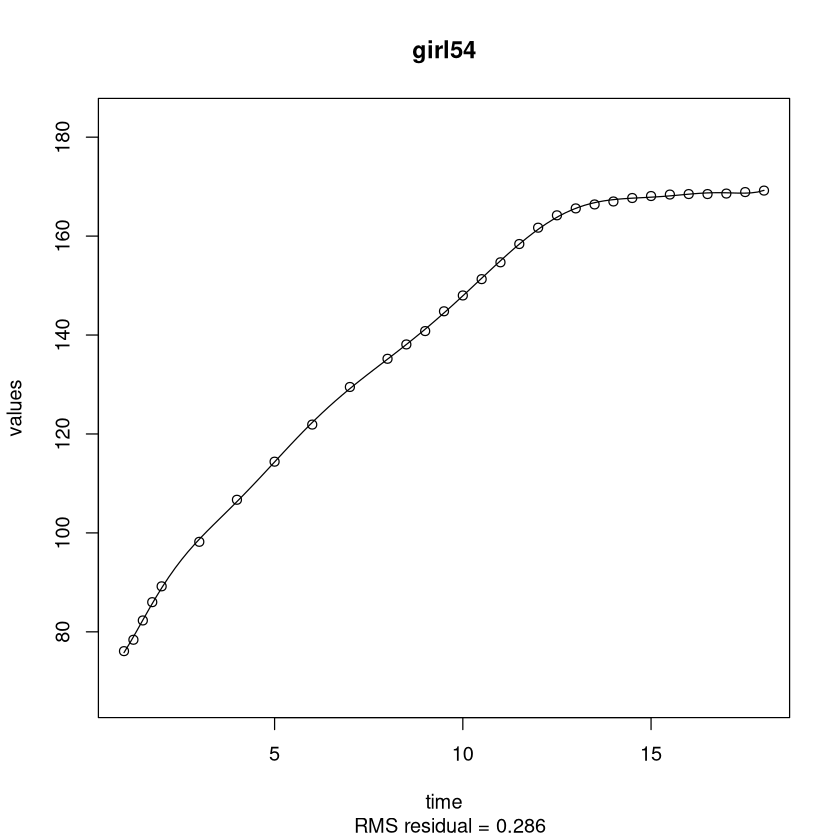

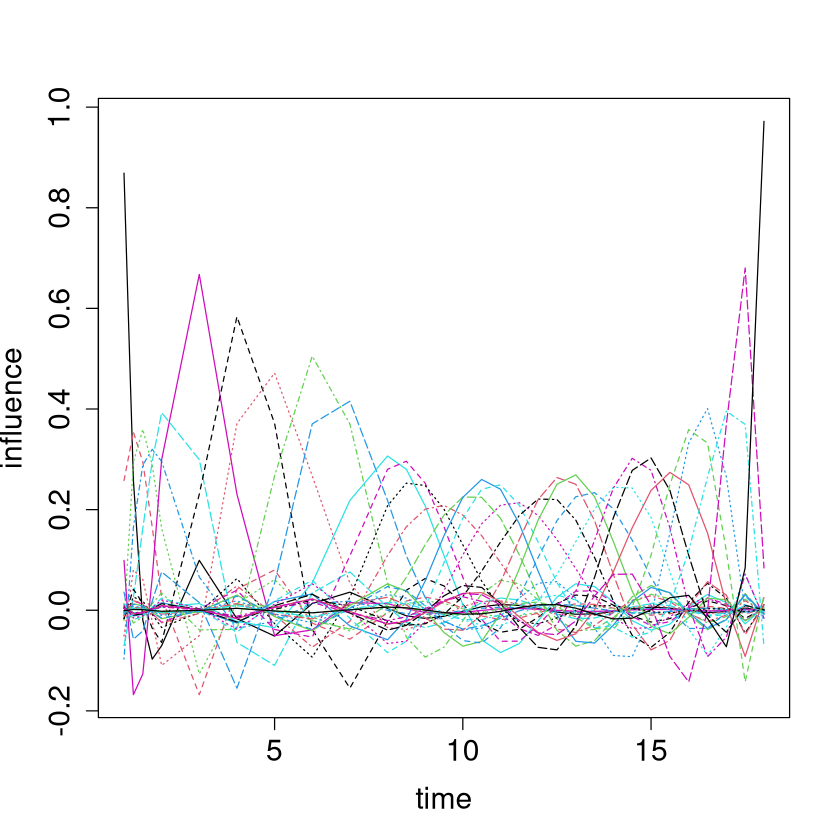

In [18]:
# Or min GCV

D2fdPar3 = fdPar(heightbasis12, Lfdobj=int2Lfd(2), lambda=0.001)
syfd3 = smooth.basis(age, heightmat, D2fdPar3)
plotfit.fd(heightmat, age, syfd3$fd)

y2cMap3 = syfd3$y2cMap
hatMat3 = bvals%*%y2cMap3

matplot(age, hatMat3, type='l', xlab='time', ylab='influence', 
        cex.lab=1.5, cex.axis=1.5)

In [19]:
# ------- Smoothing the growth data with a roughness penalty -----------

# set up a basis for the growth data
# with knots at ages of height measurement

norder = 6
nbasis = length(age) + norder - 2
heightbasis = create.bspline.basis(ageRng, nbasis, norder, age)

heightList = smooth.basis(age, heightmat, heightbasis12)
heightfd = heightList$fd

In [20]:
# define a functional parameter object for smoothing

heightLfd = 4
heightlambda = 0.01
heightfdPar = fdPar(heightbasis, heightLfd, heightlambda)

[1] "done"

[1] "done"

[1] "done"

[1] "done"

[1] "done"

[1] "done"

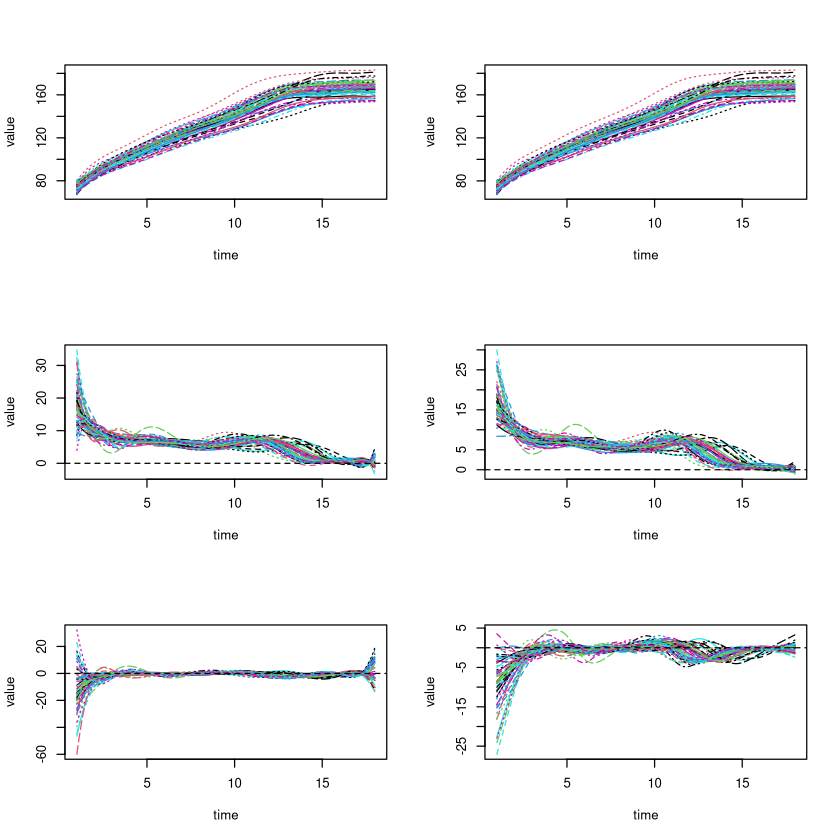

In [21]:
# smooth the data

heightfdSmooth = smooth.basis(age, heightmat, heightfdPar)
heightfdpen = heightfdSmooth$fd

opar <- par(mfrow=c(3,2))
plot(heightfd)
plot(heightfdpen)
plot(heightfd, Lfdobj=1)
plot(heightfdpen, Lfdobj=1)
plot(heightfd, Lfdobj=2)
plot(heightfdpen, Lfdobj=2)
par(opar)

In [22]:
# section 5.2.5 Choosing Smoothing Parameter lambda

loglam = seq(-6, 0, 0.25)
Gcvsave = rep(NA, length(loglam))
names(Gcvsave) = loglam
Dfsave = Gcvsave

for(i in 1:length(loglam)){
  hgtfdPari = fdPar(heightbasis, Lfdobj=4, 10^loglam[i])
  hgtSm.i = smooth.basis(age, heightmat, hgtfdPari)
  Gcvsave[i] = sum(hgtSm.i$gcv)
  Dfsave[i] = hgtSm.i$df
}

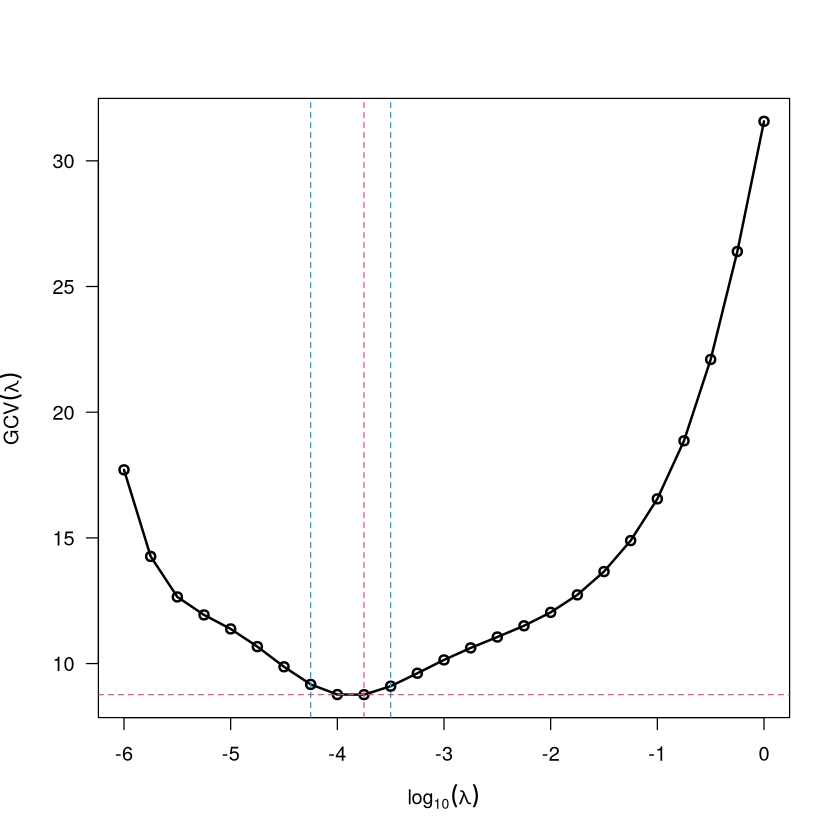

In [23]:
# Figure 5.1.

par(mfrow=c(1,1))
plot(loglam, Gcvsave, 'o', las=1, xlab=expression(log[10](lambda)), 
     ylab=expression(GCV(lambda)), lwd=2)
abline(h=min(Gcvsave), col=2, lty=2)
abline(v=loglam[which.min(Gcvsave)], col=2, lty=2)
abline(v=loglam[which.min(Gcvsave)+1], col=4, lty=2)
abline(v=loglam[which.min(Gcvsave)-2], col=4, lty=2)

In [24]:

############################################################
# TASK 2: Lfd operator
############################################################

##########################################################
## The Linear Differential Operator or Lfd Class ###
##########################################################

# Define a B-spline basis over one year (0–365 days).
# This is needed because the Lfd construction requires a basis object,
# and specifically its range (thawbasis$rangeval).
# The choice of nbasis/norder here is arbitrary for testing purposes.
thawbasis = create.bspline.basis(c(0, 365), nbasis = 25, norder = 4)

omega = 2*pi/365
thawconst.basis = create.constant.basis(thawbasis$rangeval)

betalist = vector("list", 3)
betalist[[1]] = fd(0, thawconst.basis)
betalist[[2]] = fd(omega^2, thawconst.basis)
betalist[[3]] = fd(0, thawconst.basis)
harmaccelLfd  = Lfd(3, betalist)

accelLfd = int2Lfd(2)

harmaccelLfd.thaw = vec2Lfd(c(0, omega^2, 0), thawbasis$rangeval)
all.equal(harmaccelLfd[-1], harmaccelLfd.thaw[-1])

class(accelLfd)
class(harmaccelLfd)

# Create a functional data object (fd) from synthetic temperature data.
# A sinusoidal signal is generated with yearly periodicity (matching omega),
# evaluated at day.5 (midpoints of days of the year).
# smooth.basis() converts discrete observations into basis coefficients.
temp.fd = smooth.basis(
  day.5,
  sin(2 * pi * day.5 / 365),
  thawbasis
)$fd

Ltempmat = eval.fd(day.5, temp.fd, harmaccelLfd)

D2tempfd = deriv.fd(temp.fd, 2)
Ltempfd = deriv.fd(temp.fd, harmaccelLfd)

[1] TRUE

[1] "Lfd"

[1] "Lfd"



 Results for curve 1 

Iter.   PENSSE   Grad Length Intercept   Slope
0        49.7544      36.7926      87.6342      5.0963
1        5.5785      4.0678      83.0646      4.613
2        0.4035      1.3208      76.591      4.4491
3        0.1899      0.3375      76.6529      4.4333
4        0.1527      0.1251      76.7122      4.4239
5        0.1479      0.0449      76.7118      4.4234
6        0.1478      0.0044      76.7079      4.4237


 Results for curve 2 

Iter.   PENSSE   Grad Length Intercept   Slope
0        36.0196      32.9827      85.3473      5.606
1        5.008      1.5033      81.7036      5.2088
2        0.6301      2.273      74.3752      5.0816
3        0.3729      0.1844      74.2868      5.0734
4        0.3681      0.0561      74.2572      5.0749
5        0.3676      0.0431      74.1785      5.0801
6        0.3675      0.012      74.1721      5.0806


 Results for curve 3 

Iter.   PENSSE   Grad Length Intercept   Slope
0        82.053      50.2742      92.0217   

[1] "done"

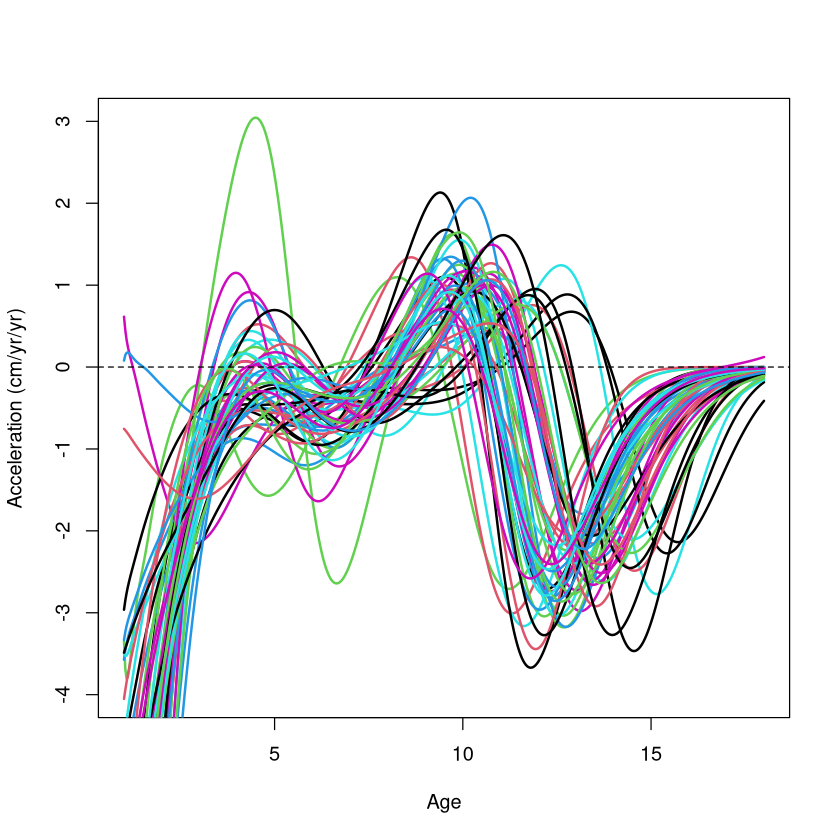

In [25]:
############################################################
# TASK 3: Monotone smoothing the Berkeley female data
############################################################

## Compute the monotone smoothing of the Berkeley female growth data.

# set up ages of measurement and an age mesh

age = growth$age
nage = length(age)
ageRng = range(age)
nfine = 101
agefine = seq(ageRng[1], ageRng[2], length=nfine)

# the data

hgtf = growth$hgtf
ncasef = dim(hgtf)[2]

# an order 6 bspline basis with knots at ages of measurement

norder = 6
nbasis = nage + norder - 2
wbasis = create.bspline.basis(ageRng, nbasis, norder, age)

# define the roughness penalty for function W

Lfdobj = 3 # penalize curvature of acceleration
lambda = 10^(-0.5) # smoothing parameter
cvecf = matrix(0, nbasis, ncasef)
Wfd0 = fd(cvecf, wbasis)
growfdPar = fdPar(Wfd0, Lfdobj, lambda)

# monotone smoothing

growthMon = smooth.monotone(age, hgtf, growfdPar)

# (wait for an iterative fit to each of 54 girls)

Wfd = growthMon$Wfd
betaf = growthMon$beta
hgtfhatfd = growthMon$yhatfd

# Set up functional data objects for the acceleration curves
# and their mean. Suffix UN means "unregistered".

accelfdUN = deriv.fd(hgtfhatfd, 2)
accelmeanfdUN = mean.fd(accelfdUN)

# plot unregistered curves

par(ask=FALSE)
plot(accelfdUN, xlim=ageRng, ylim=c(-4,3), lty=1, lwd=2, 
     cex=2, xlab="Age", ylab="Acceleration (cm/yr/yr)")